In [1]:
import os
import sys

import torch
import torch.multiprocessing as mp

# Add the repo root (e.g.,/fairmast-data-preprocessing) to sys.path
REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__file__) if '__file__' in globals()
                                         else os.getcwd(), "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
print(f"REPO_ROOT: {REPO_ROOT}")

from scripts.main_pipeline.utils.utils import read_data_split_csv
from scripts.MAST_tools.MAST_dataset import MastDataset


REPO_ROOT: /Users/cecilerousseau/Documents/AD Fusion UKI/fairmast-data-preprocessing


In [2]:
LOCAL_FLAG = False
mp.set_start_method("spawn", force=True)

# ..................................................................................................................
# For common pipeline

SUBSET_OF_SHOTS = 2  # <- This can be None for the entire dataset, or a small integer.

train_sh, _, _ = read_data_split_csv()
train_sh = train_sh[0:SUBSET_OF_SHOTS]

/Users/cecilerousseau/Documents/AD Fusion UKI/fairmast-data-preprocessing/metadata/2025-05-12/data_splits.csv


## Access Data with transform to None --> creating windows 

In [3]:
train_sh = train_sh[0:SUBSET_OF_SHOTS]

source_signal_list = ['magnetics-flux_loop_flux', 
                      ]
source_signal_list = [
    ('equilibrium', 'lcfs_r'),
    ('equilibrium', 'lcfs_z')
]

train_dataset = MastDataset(
                            local=LOCAL_FLAG,
                            shots_list=train_sh,
                            source_signal_list=source_signal_list,
                            signal_level_transform_map=None,
                            shot_level_transform=None
                        )

In [4]:
data_shot = train_dataset[0]
data_shot


{'equilibrium-lcfs_r': {'time': array([-0.05580001, -0.05080001, -0.04580001, -0.04080001, -0.03580001,
         -0.03080001, -0.02580001, -0.02080001, -0.01580001, -0.01080001,
         -0.00580001, -0.00080001,  0.00419999,  0.00919999,  0.01419999,
          0.01919999,  0.02419999,  0.02919999,  0.03419999,  0.03919999,
          0.04419999,  0.04919999,  0.05419999,  0.05919999,  0.06419999,
          0.06919999,  0.07419999,  0.07919999,  0.08419999,  0.08919999,
          0.09419999,  0.09919999,  0.10419999,  0.10919999,  0.11419999,
          0.11919999,  0.12419999,  0.12919999,  0.13419999,  0.13919999,
          0.14419999,  0.14919999,  0.15419999,  0.15919999,  0.16419999,
          0.16919999,  0.17419999,  0.17919999,  0.18419999,  0.18919999,
          0.19419999,  0.19919999,  0.20419999,  0.20919999,  0.21419999,
          0.21919999,  0.22419999,  0.22919999,  0.23419999,  0.23919999,
          0.24419999,  0.24919999,  0.25419999,  0.25919999,  0.26419999,
        

(109,)
(109, 161)
(109,)
(109, 161)
(147,)
(147, 139)
(147,)
(147, 139)


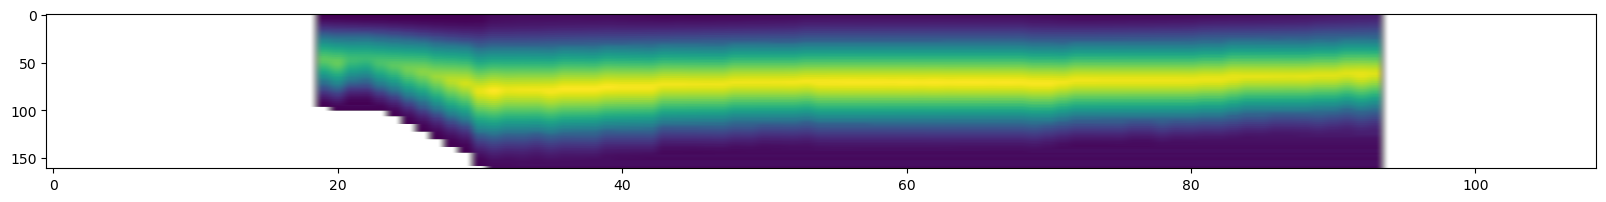

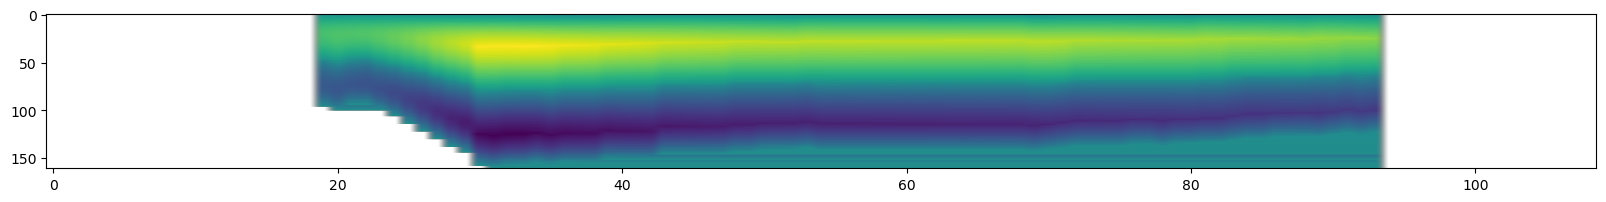

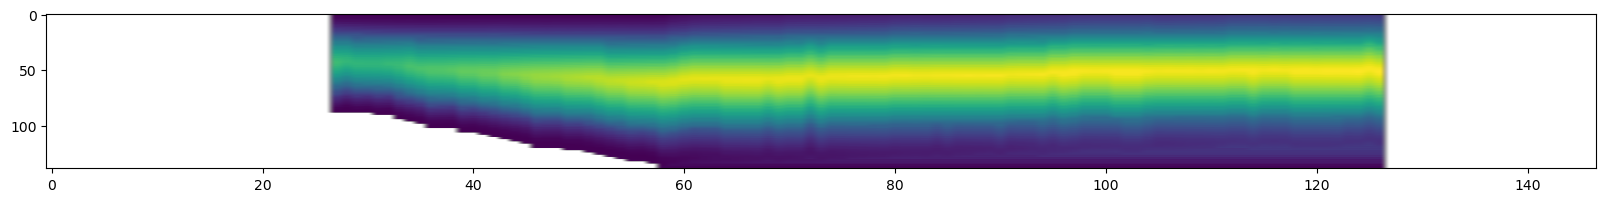

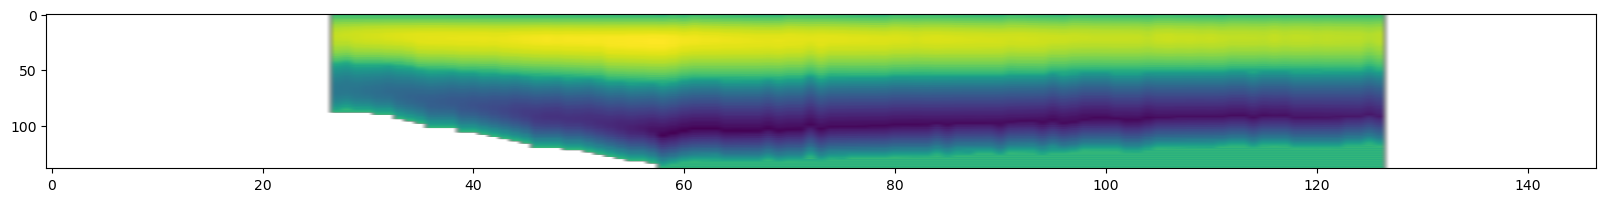

In [5]:
import matplotlib.pyplot as plt

for data_shot in train_dataset:
    for var in data_shot.keys():
        print(data_shot[var]['time'].shape)
        print(data_shot[var]['values'].shape)

        fig, ax = plt.subplots(figsize=(20, 2))
        ax.imshow(data_shot[var]['values'].T, aspect='auto')
        # plt.tight_layout()


In [6]:
train_sh = train_sh[0:SUBSET_OF_SHOTS]

source_signal_list = ['magnetics-flux_loop_flux', 
                      ]
source_signal_list = [
    ('equilibrium', 'psi') 
]

train_dataset = MastDataset(
                            local=LOCAL_FLAG,
                            shots_list=train_sh,
                            source_signal_list=source_signal_list,
                            signal_level_transform_map=None,
                            shot_level_transform=None
                        )

/var/folders/0s/09_rjjs504vdtfg7jr_4t7k00000gn/T/ipykernel_51406/1330633.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 10))


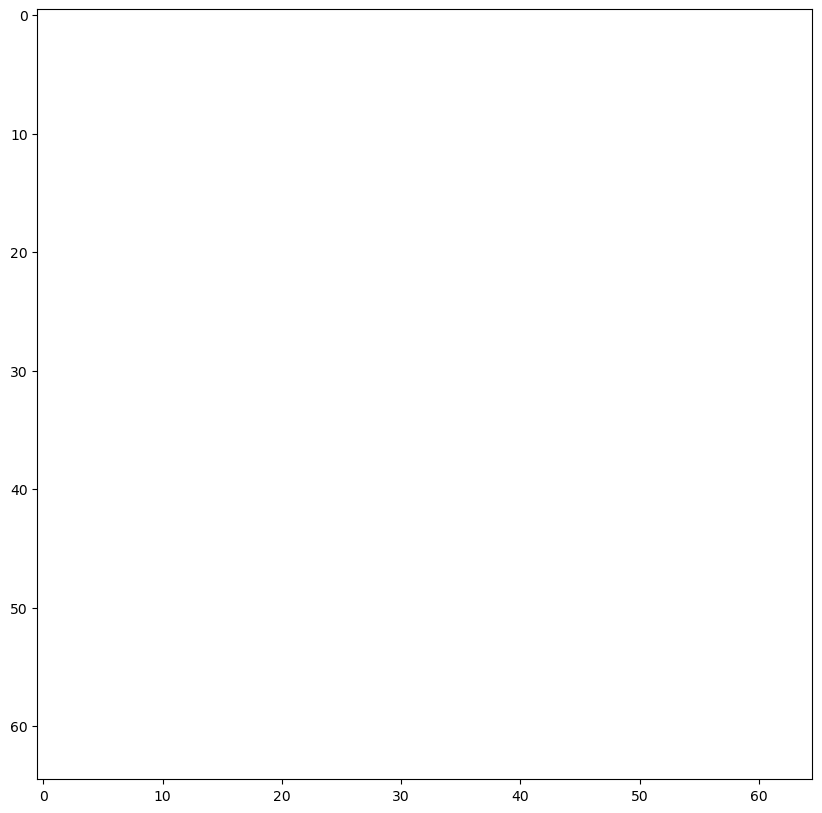

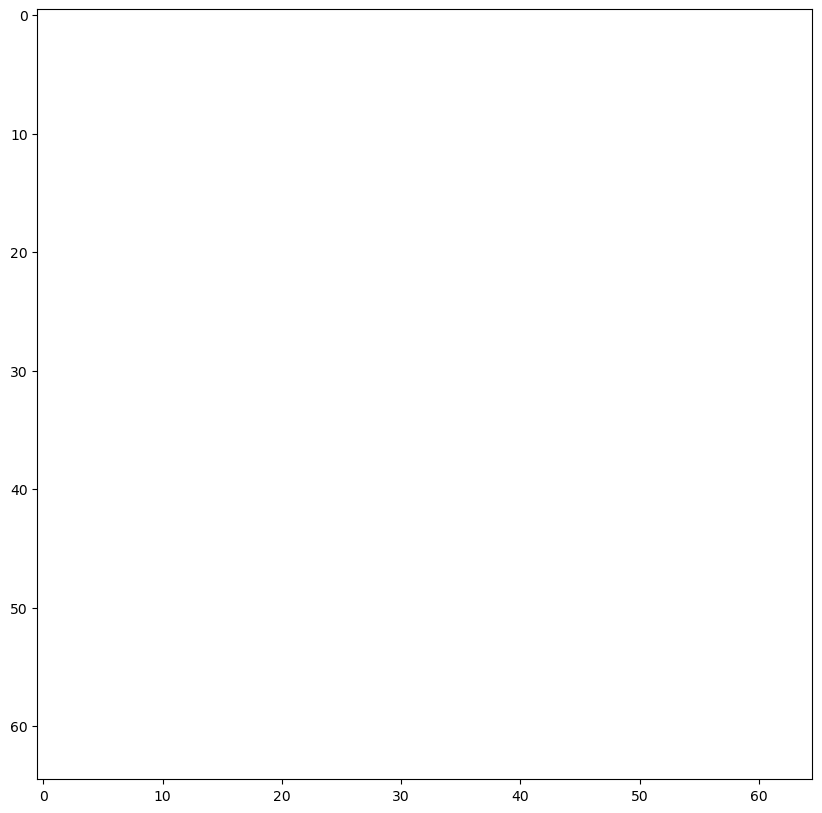

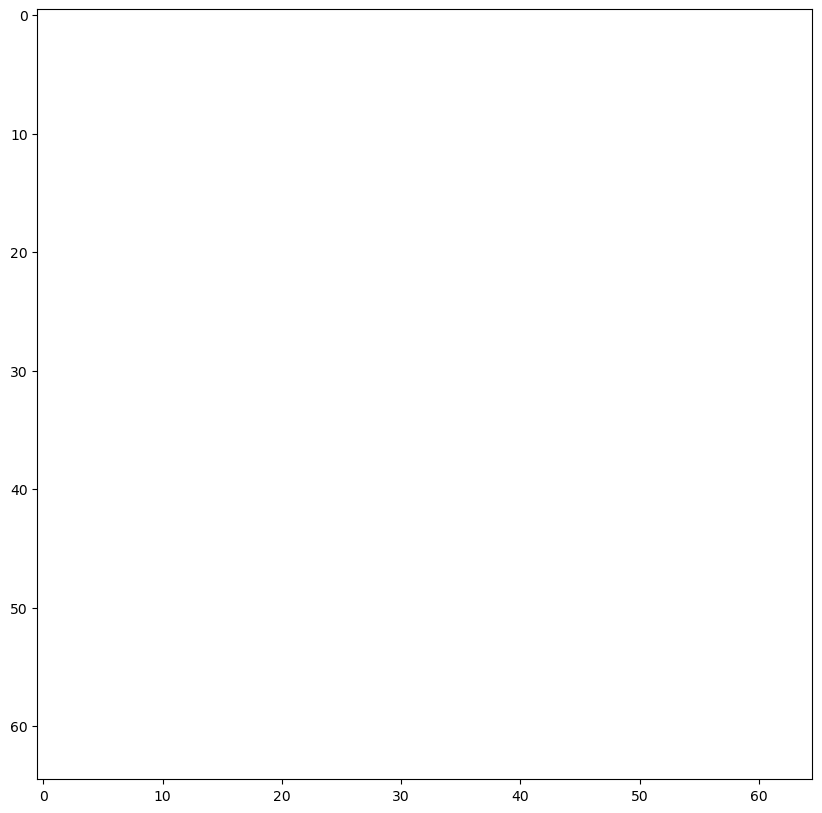

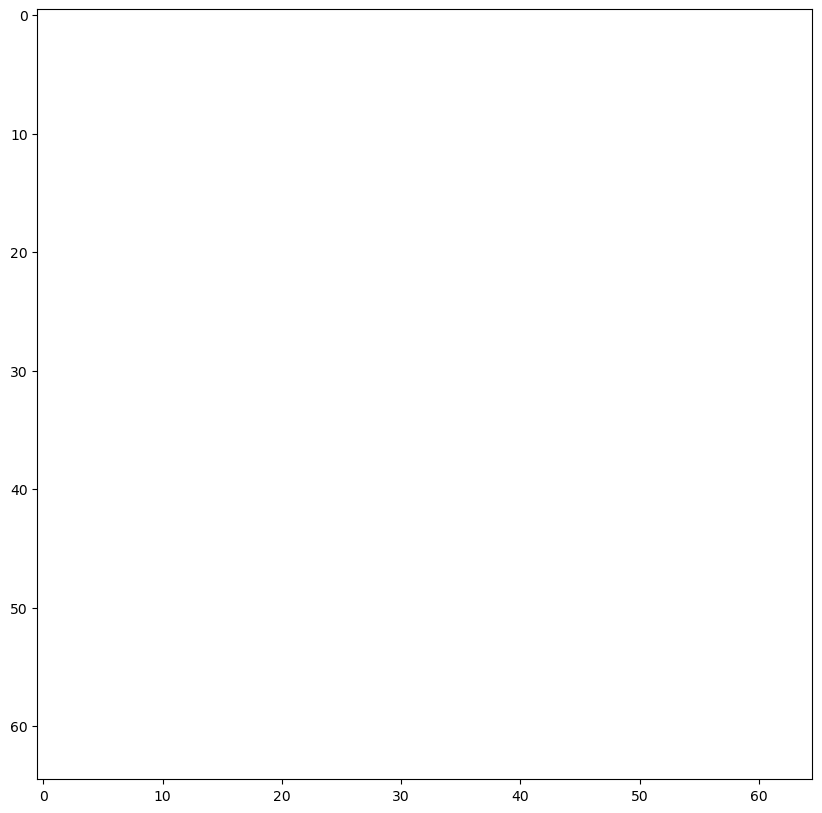

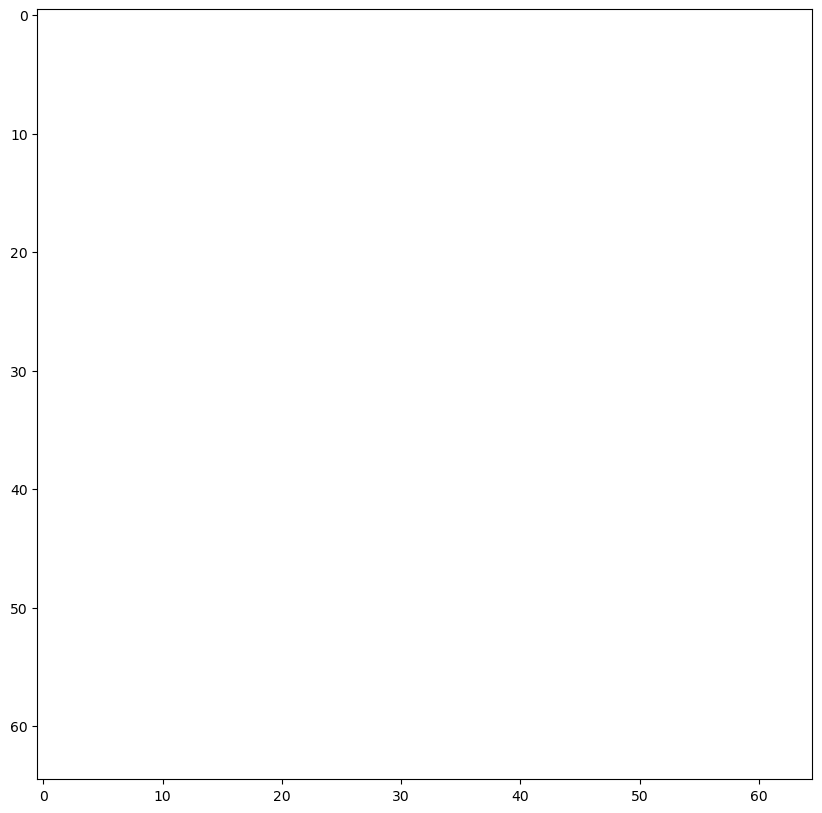

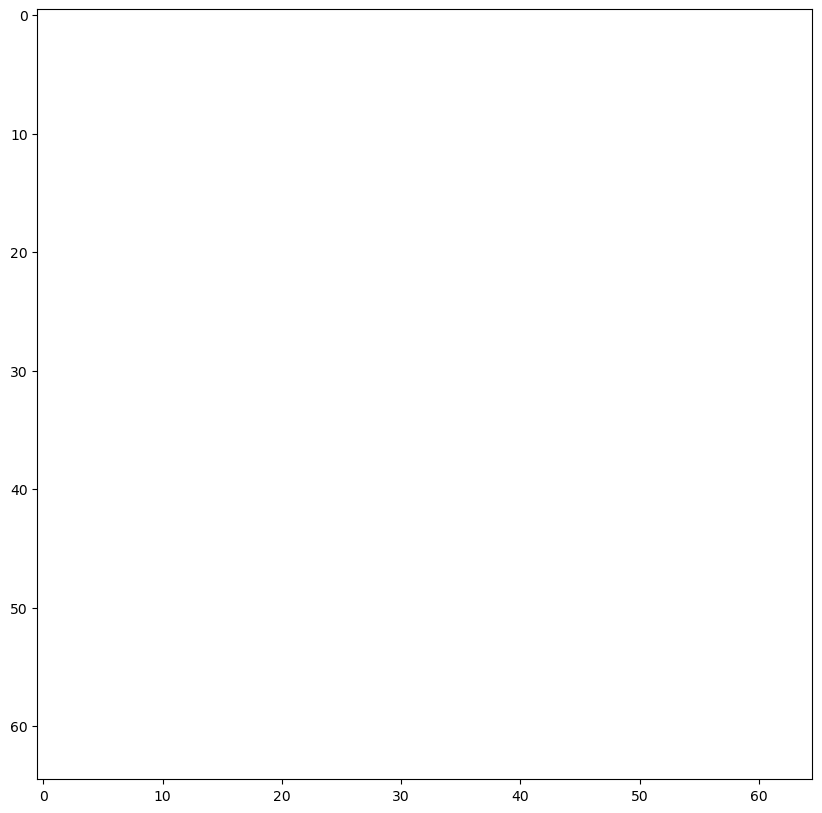

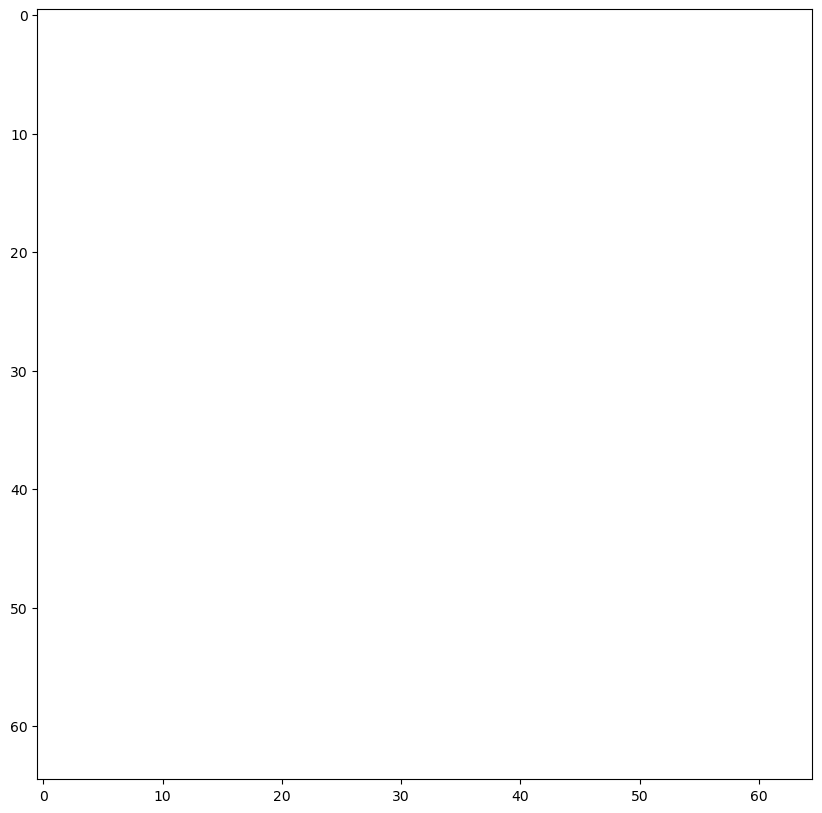

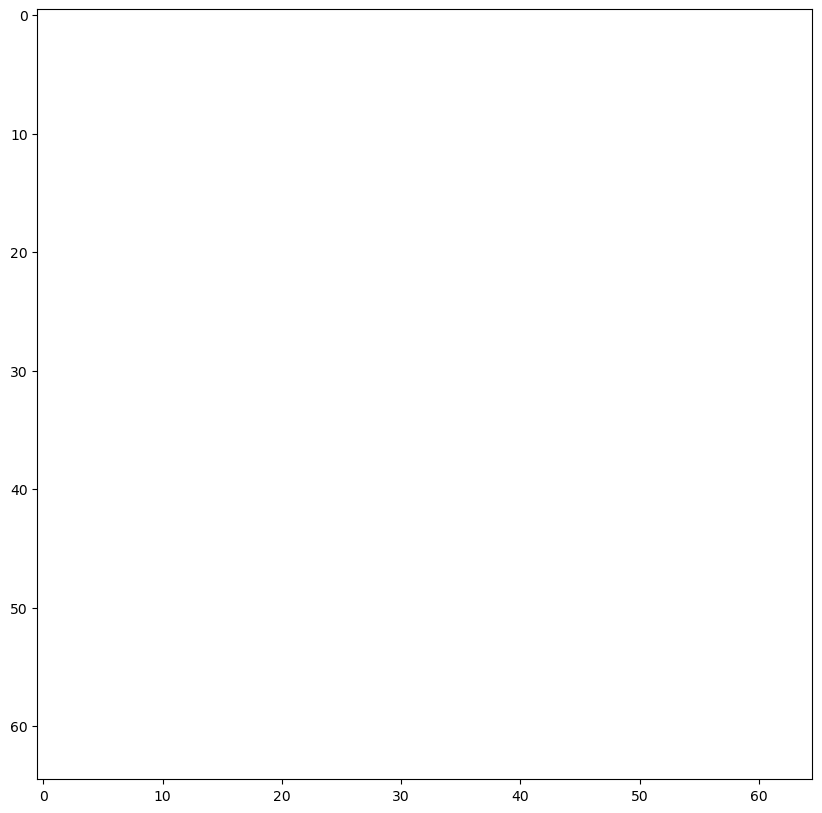

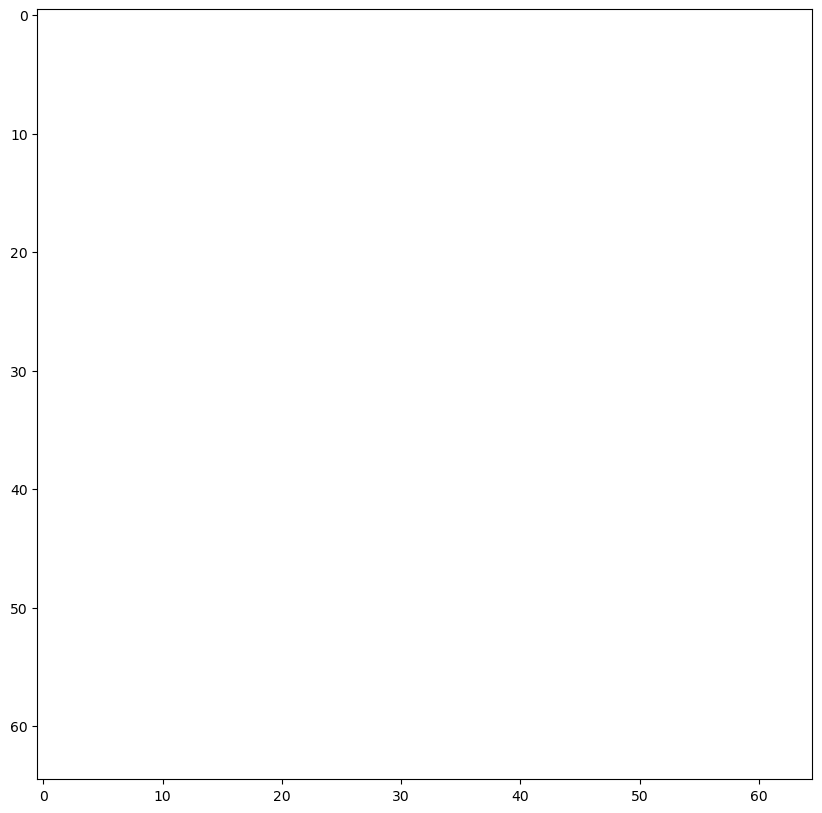

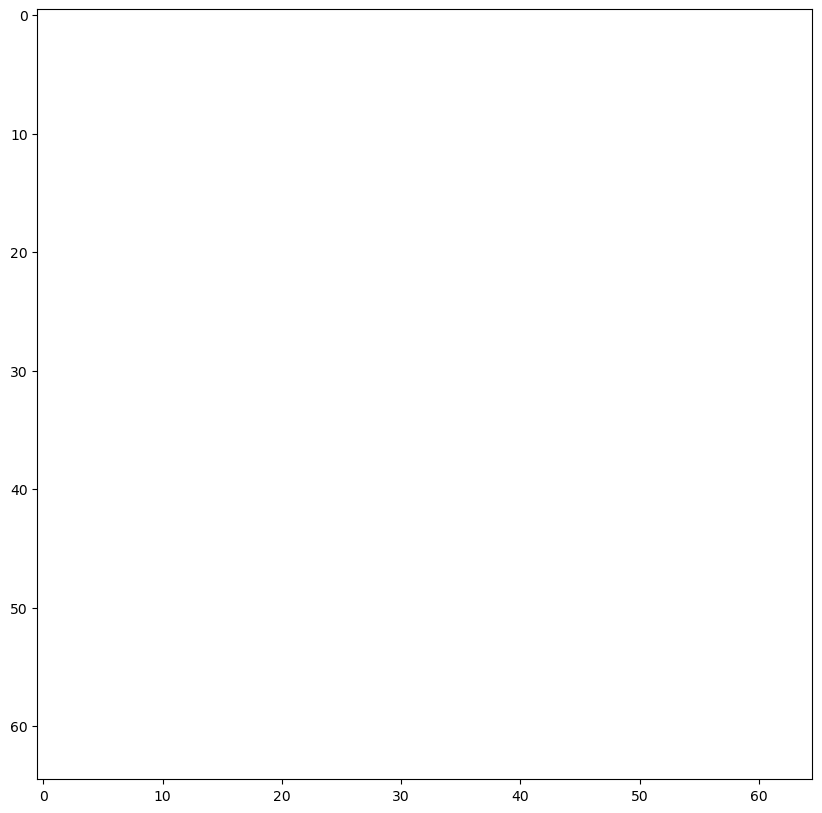

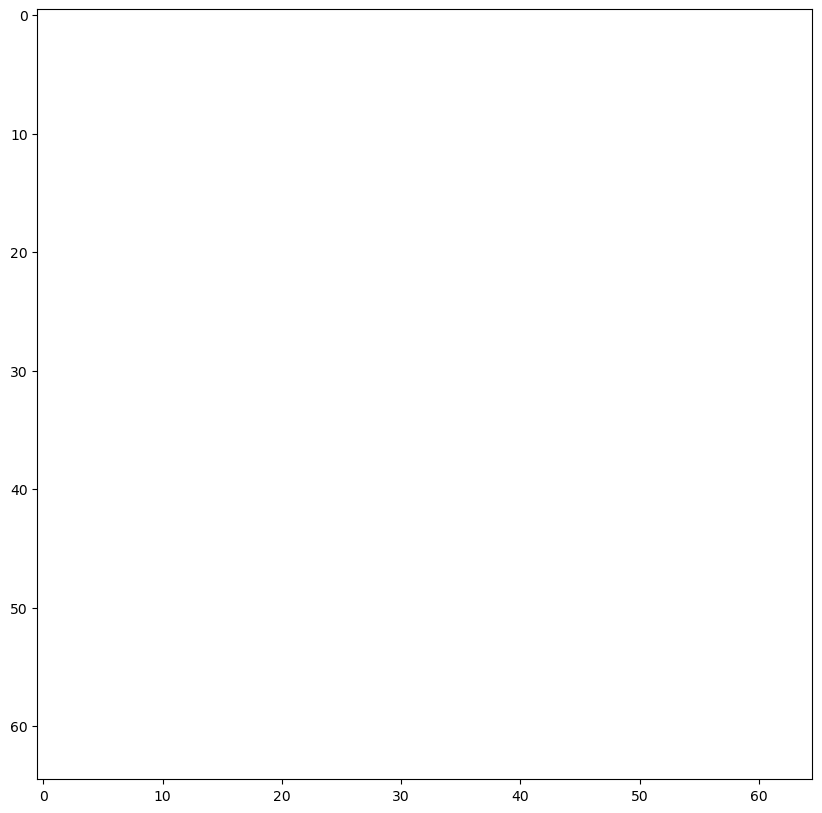

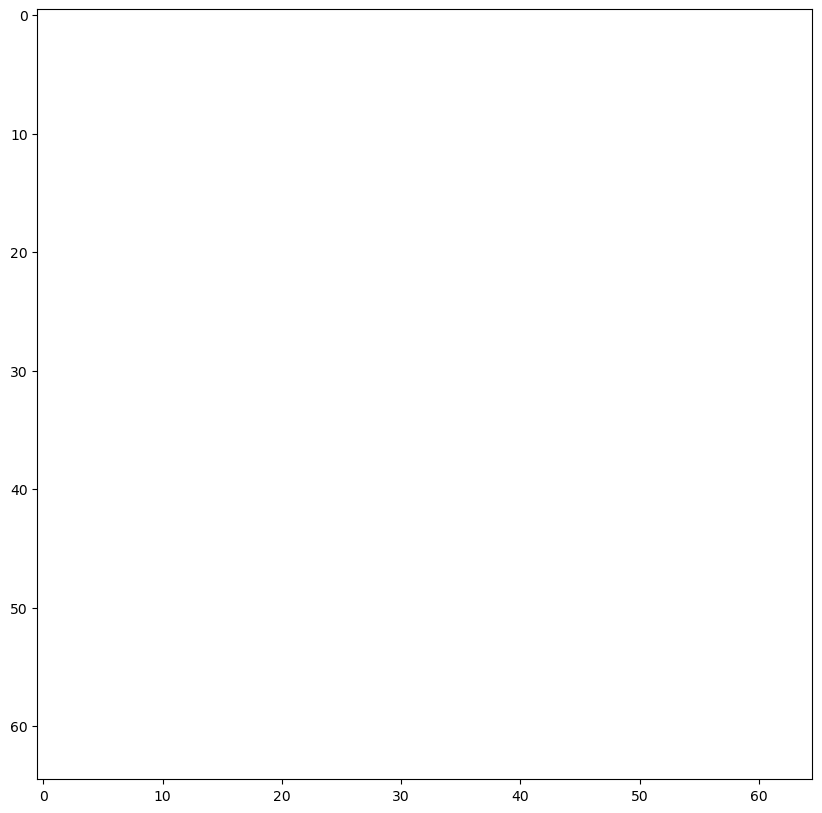

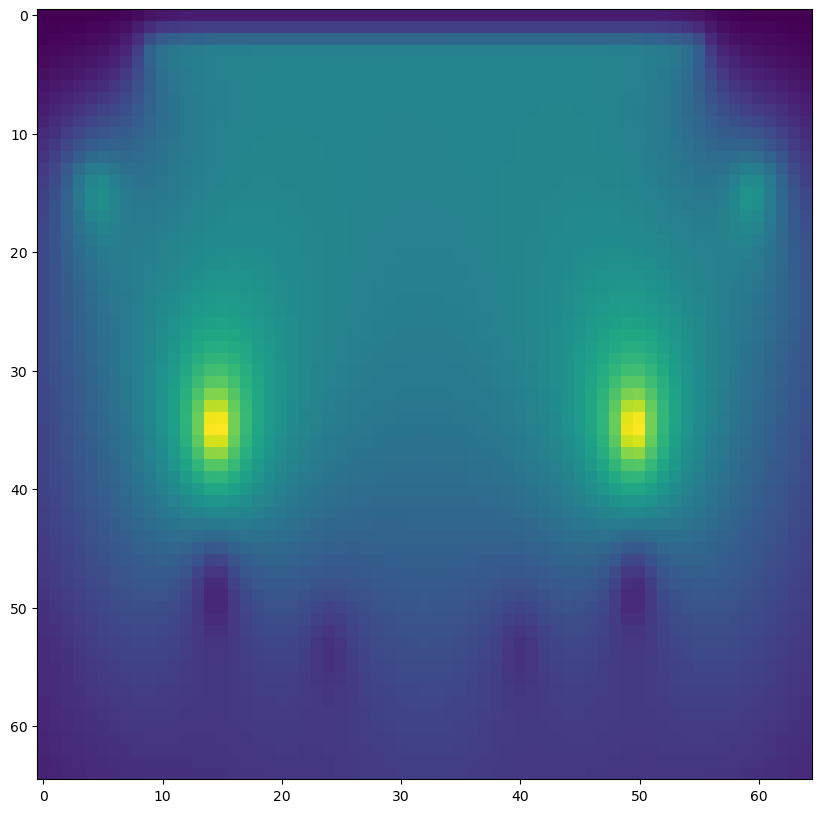

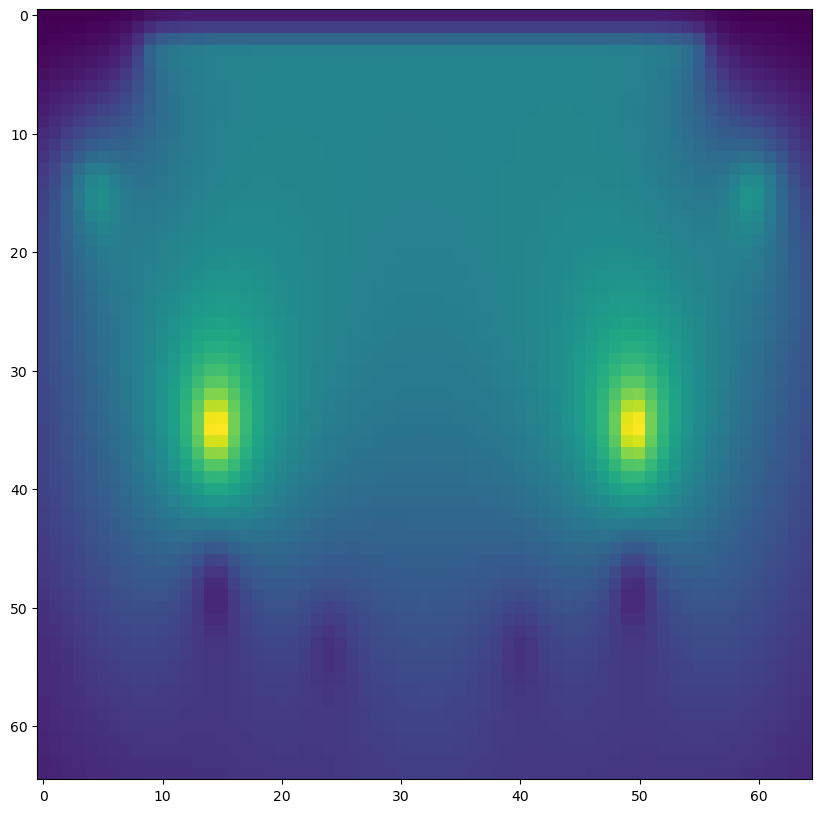

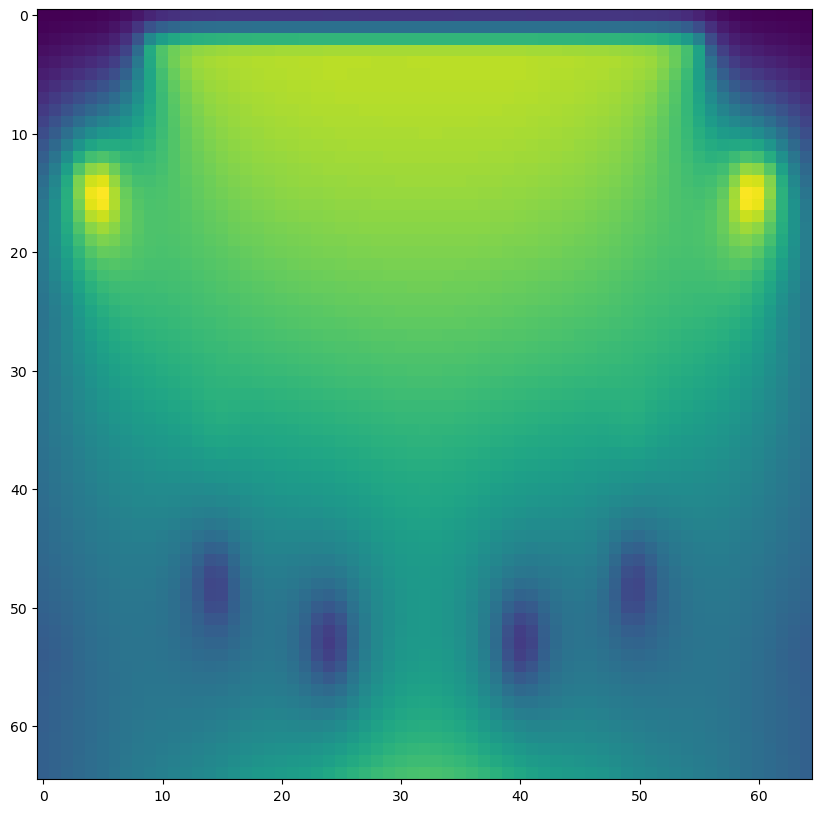

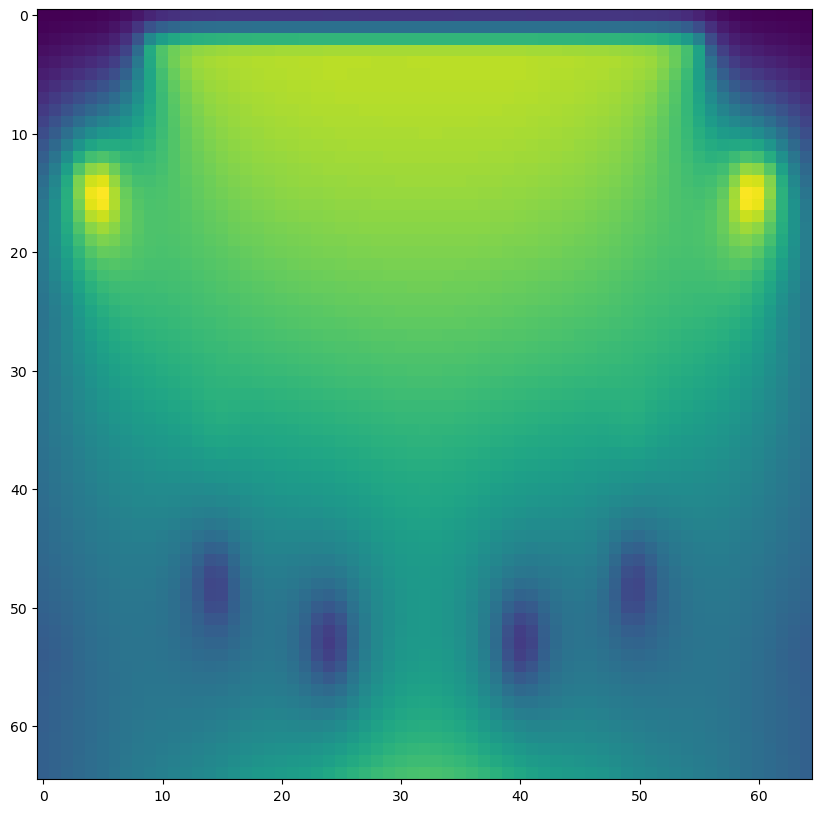

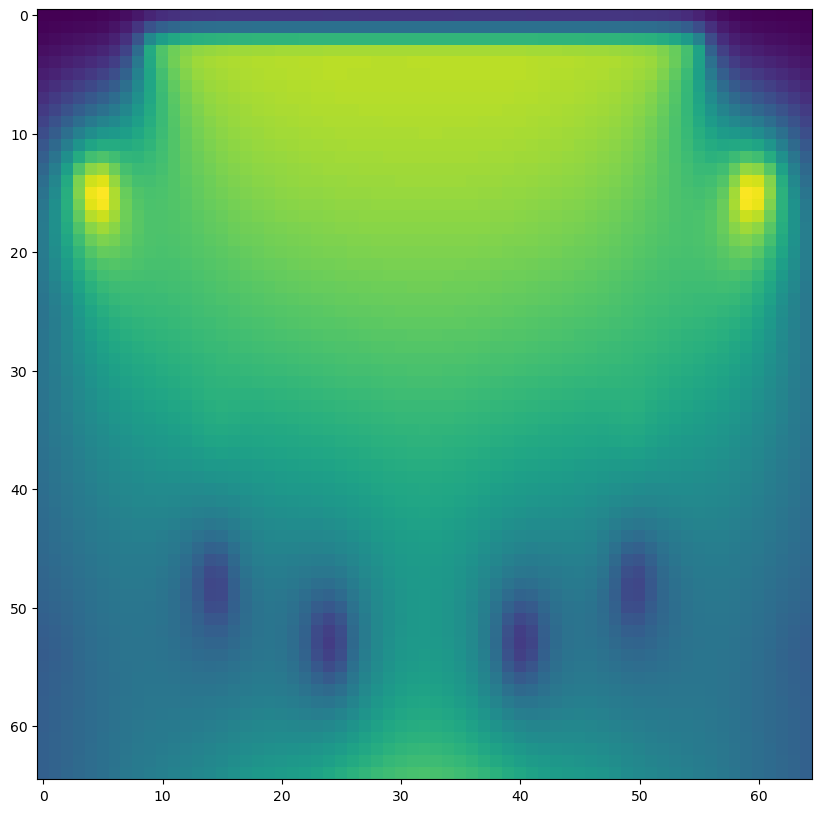

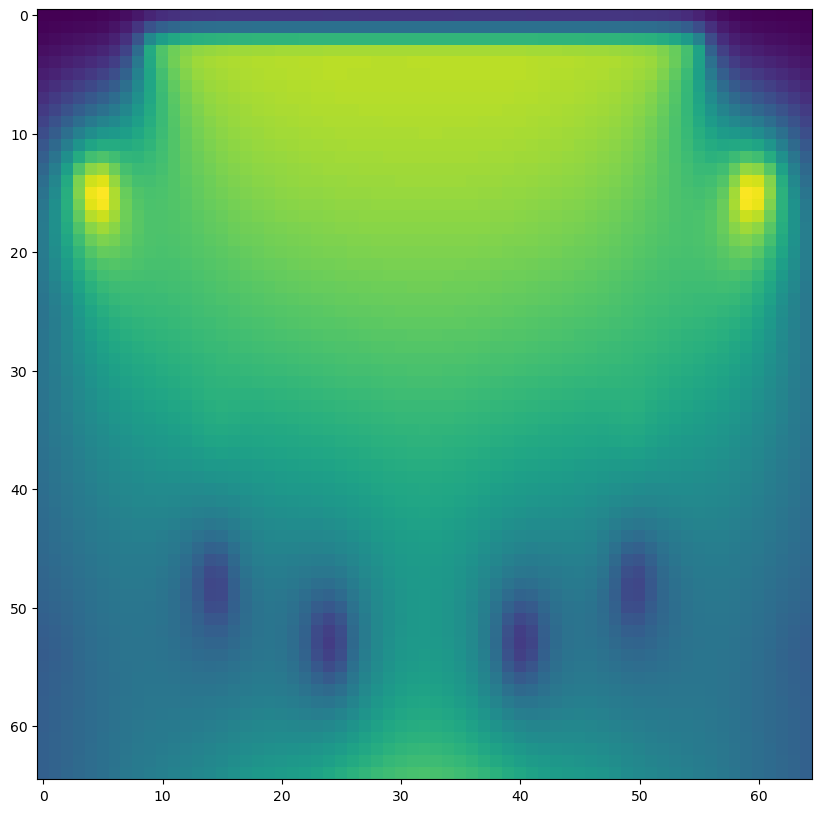

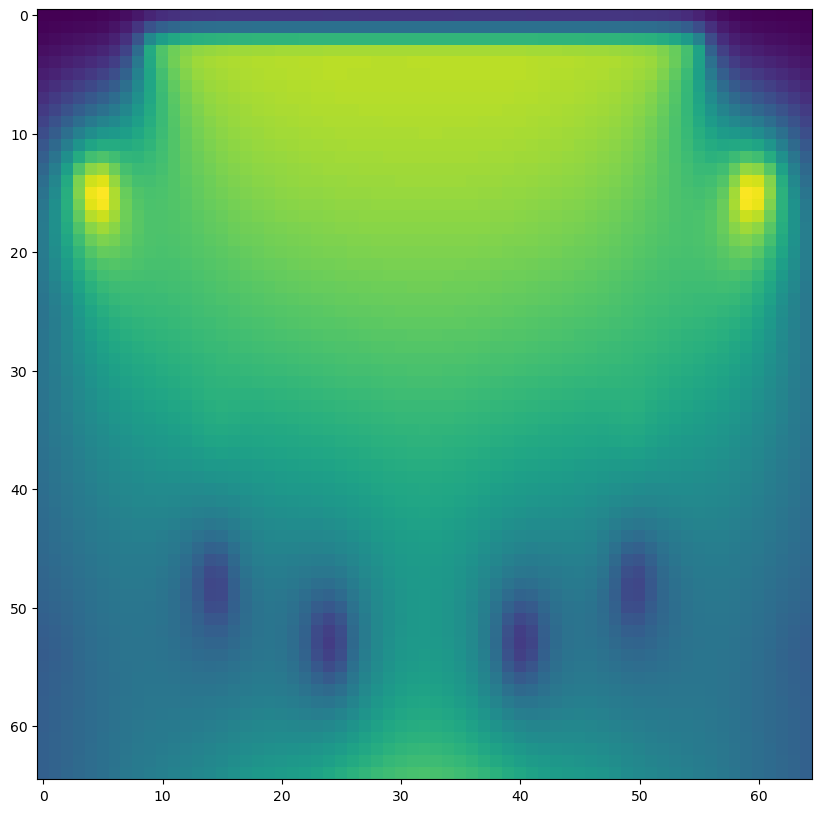

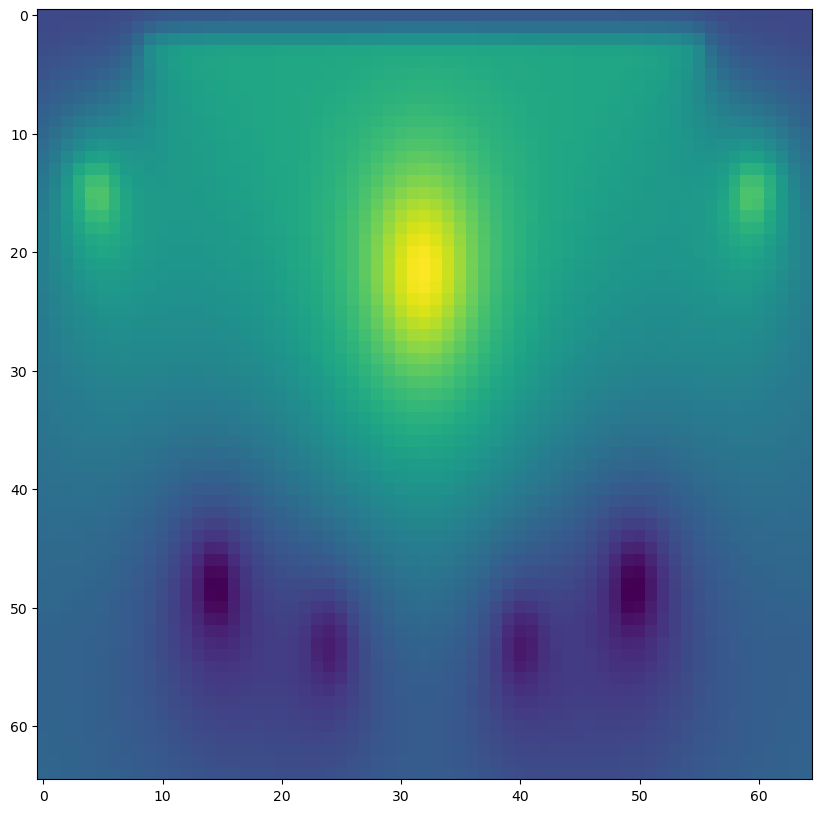

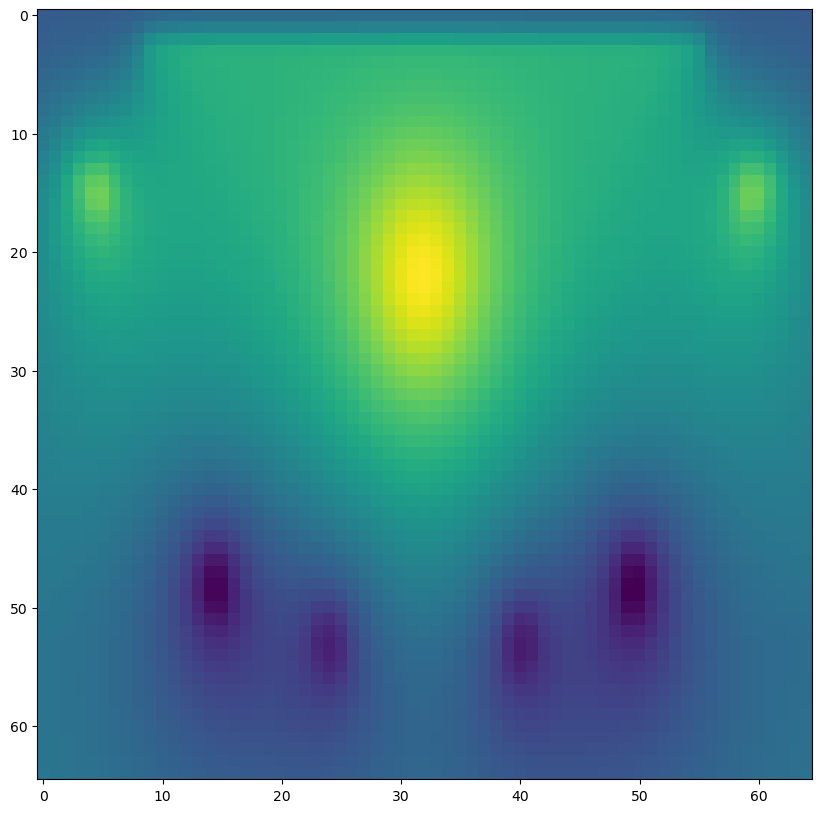

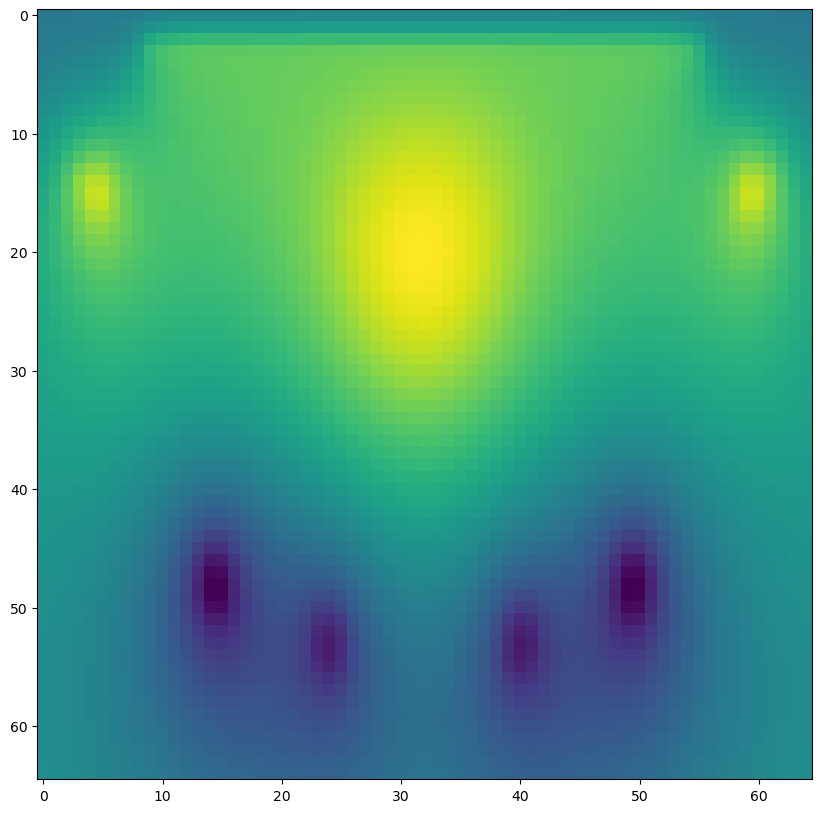

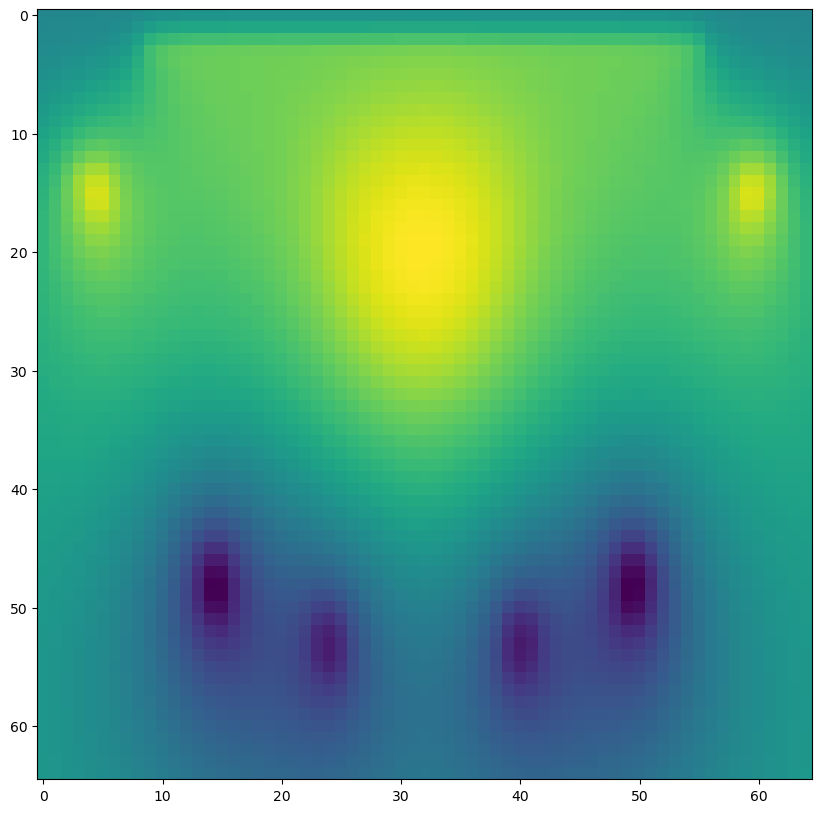

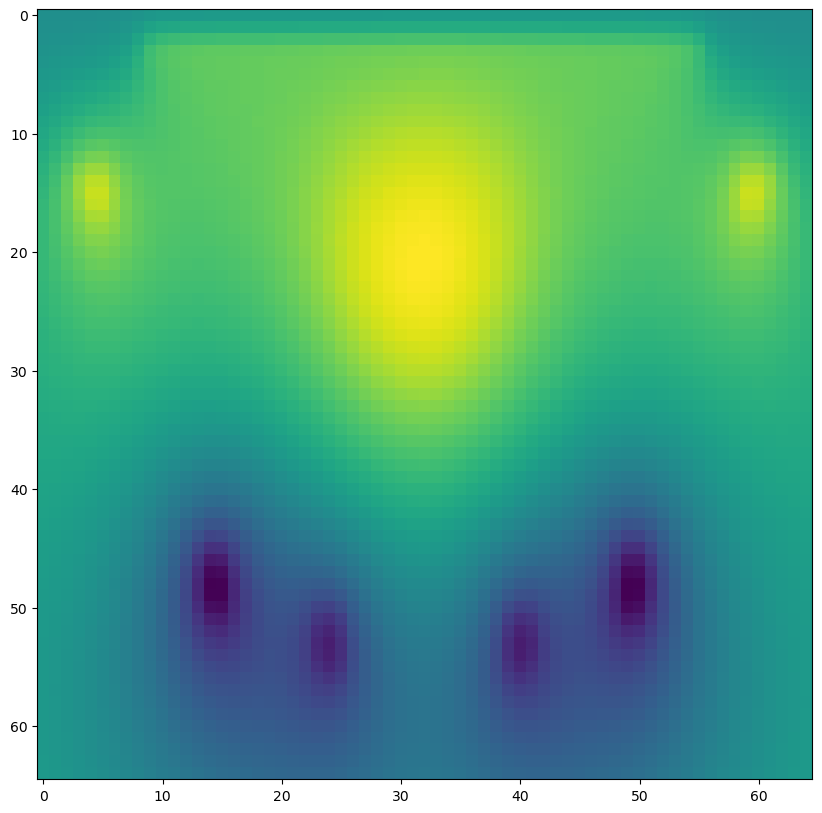

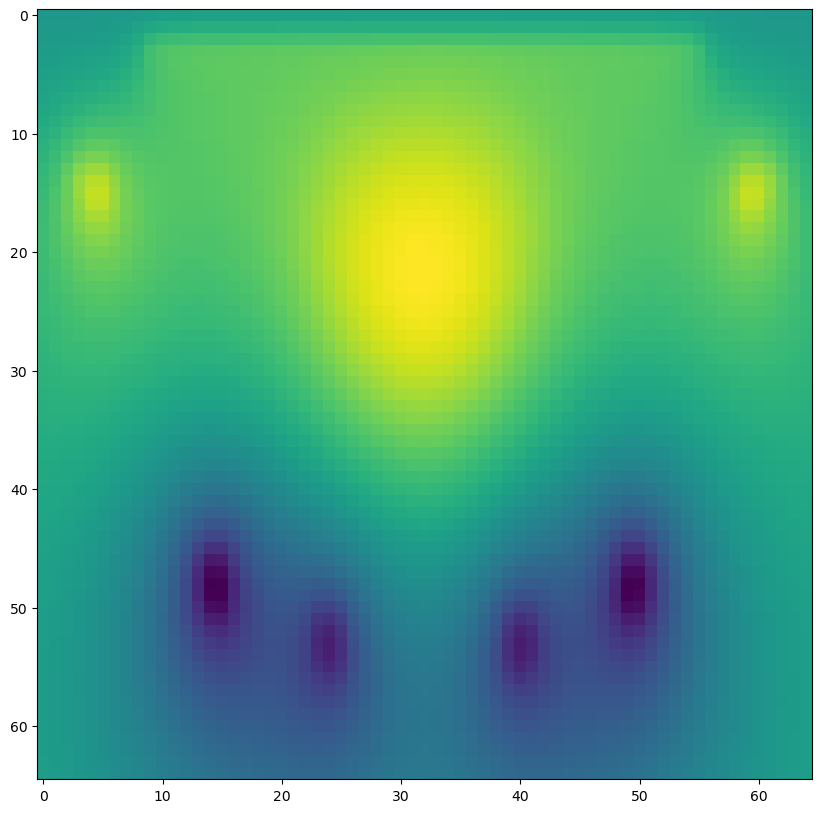

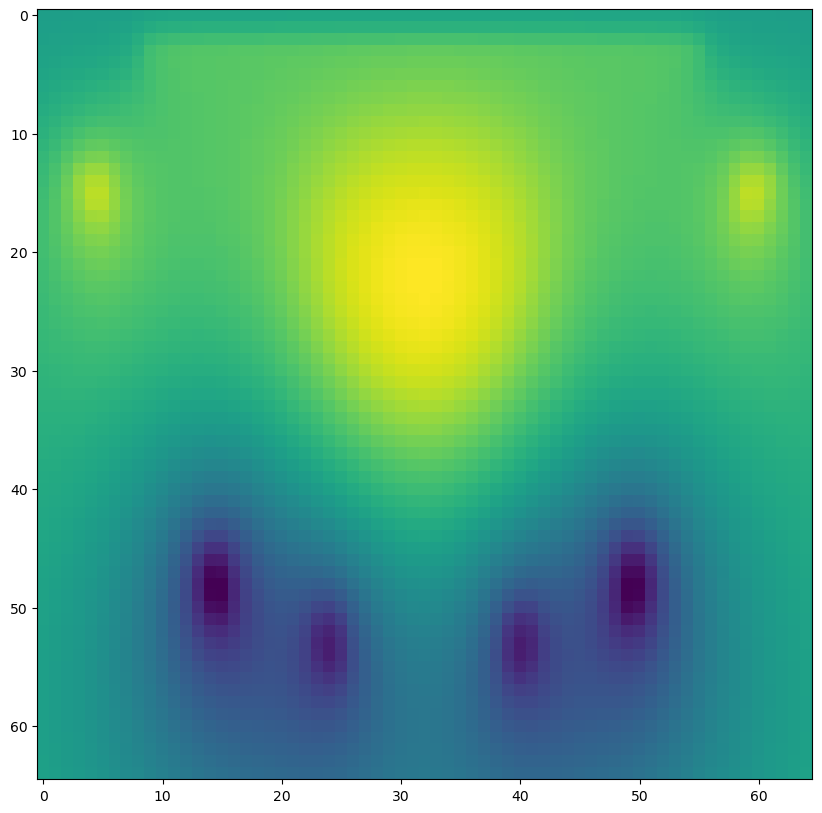

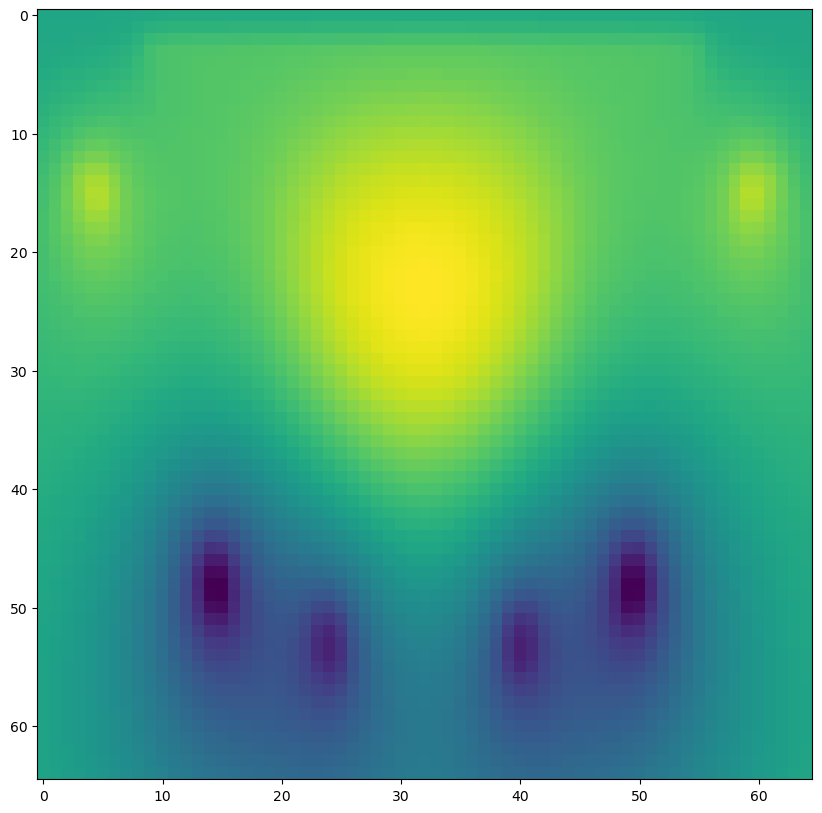

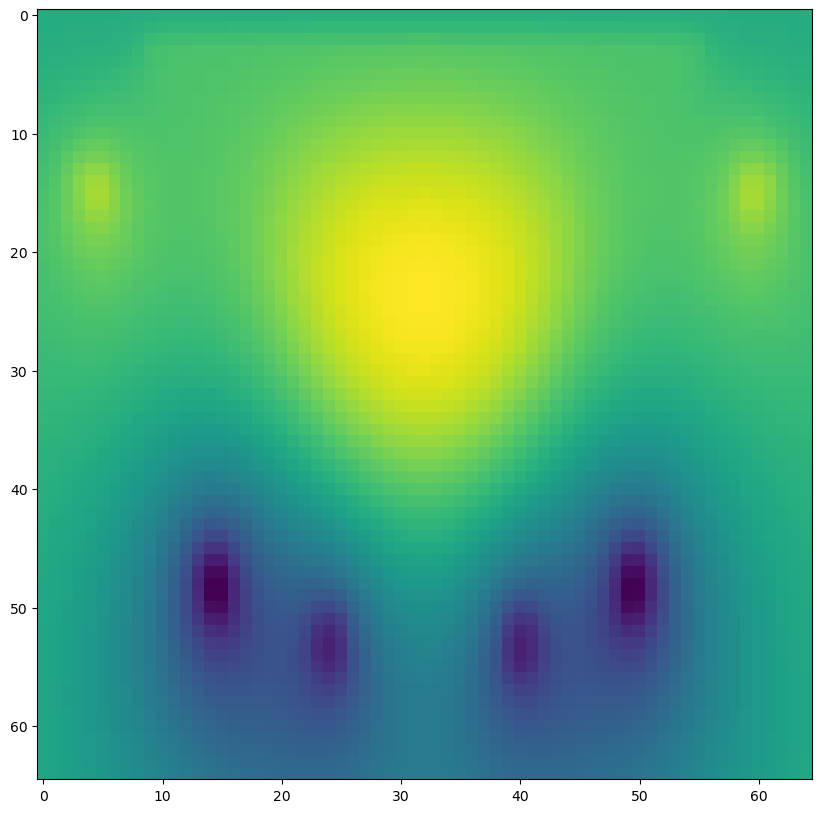

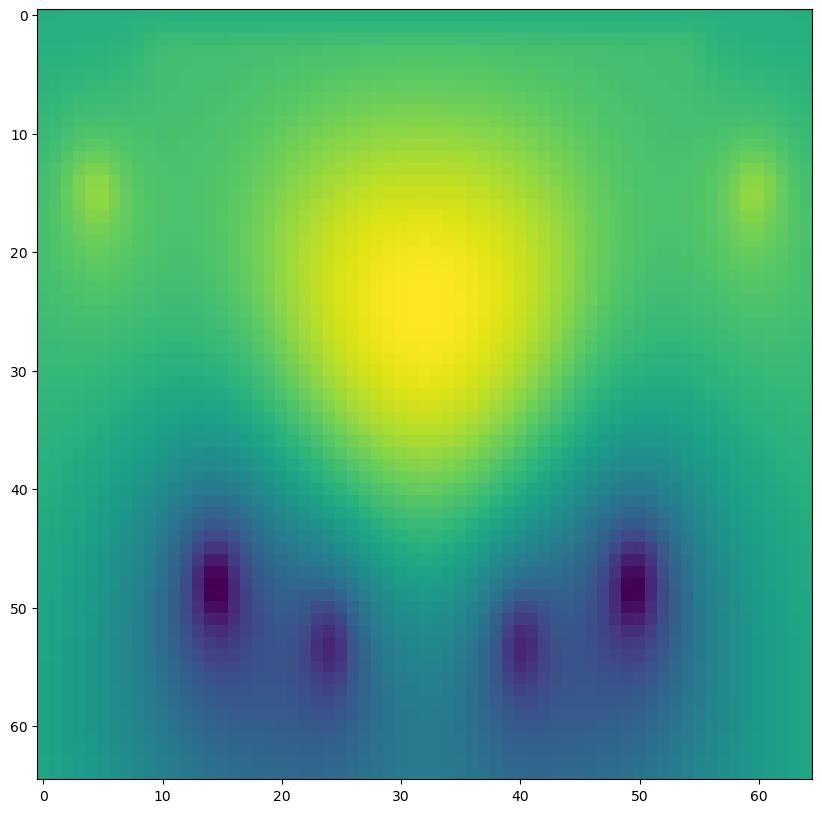

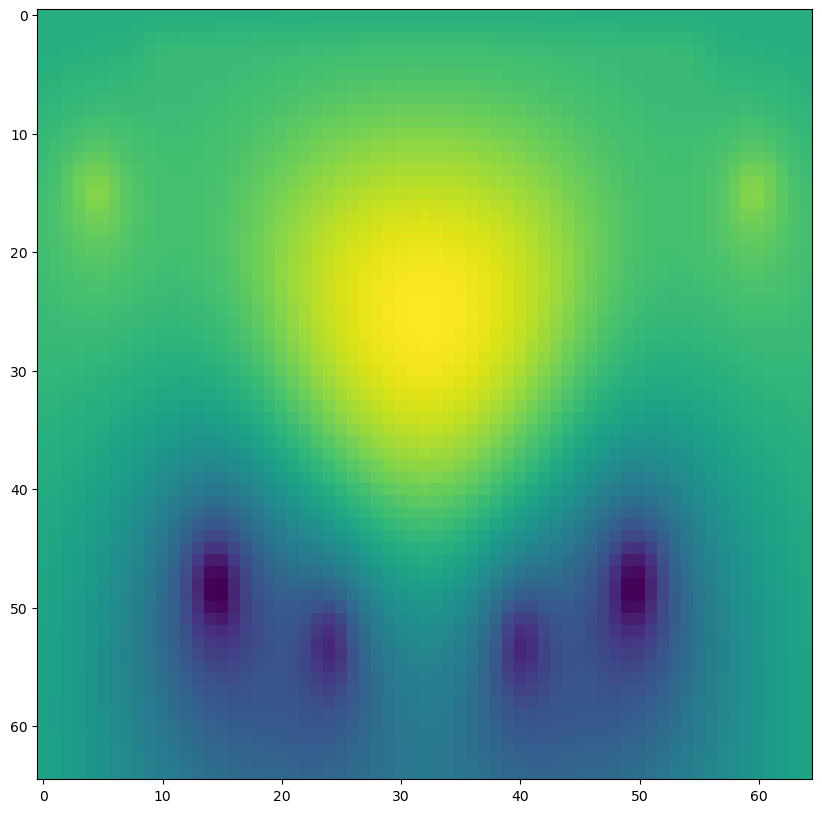

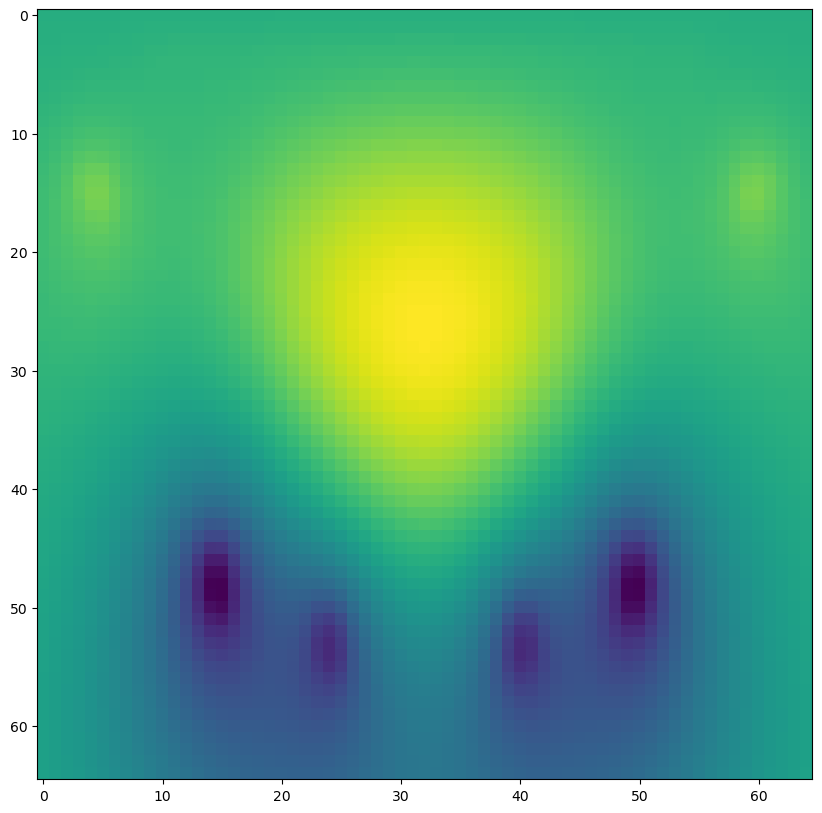

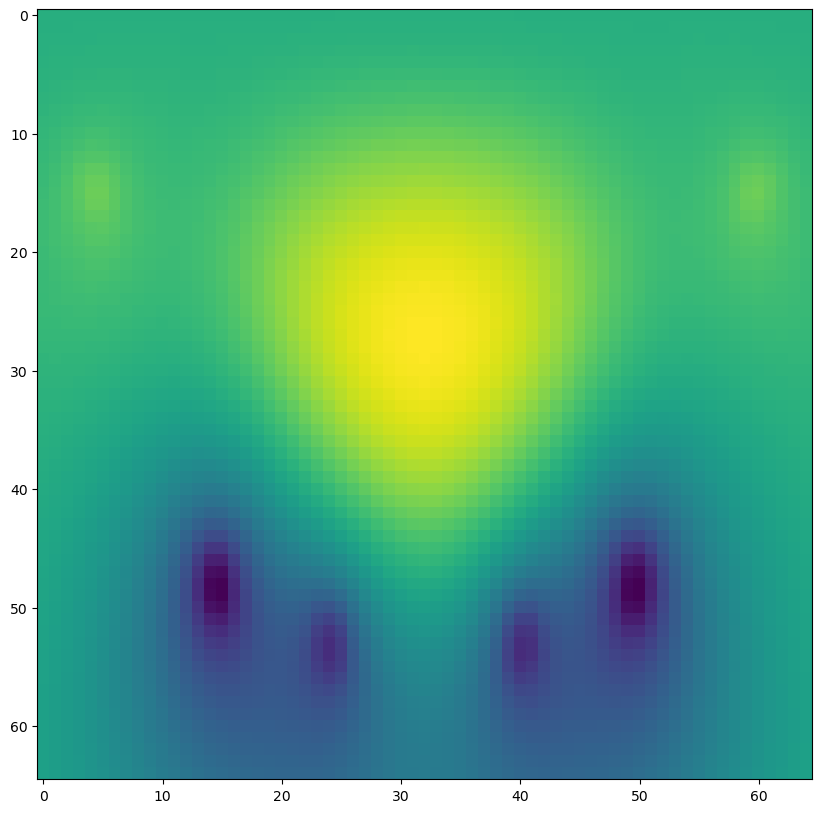

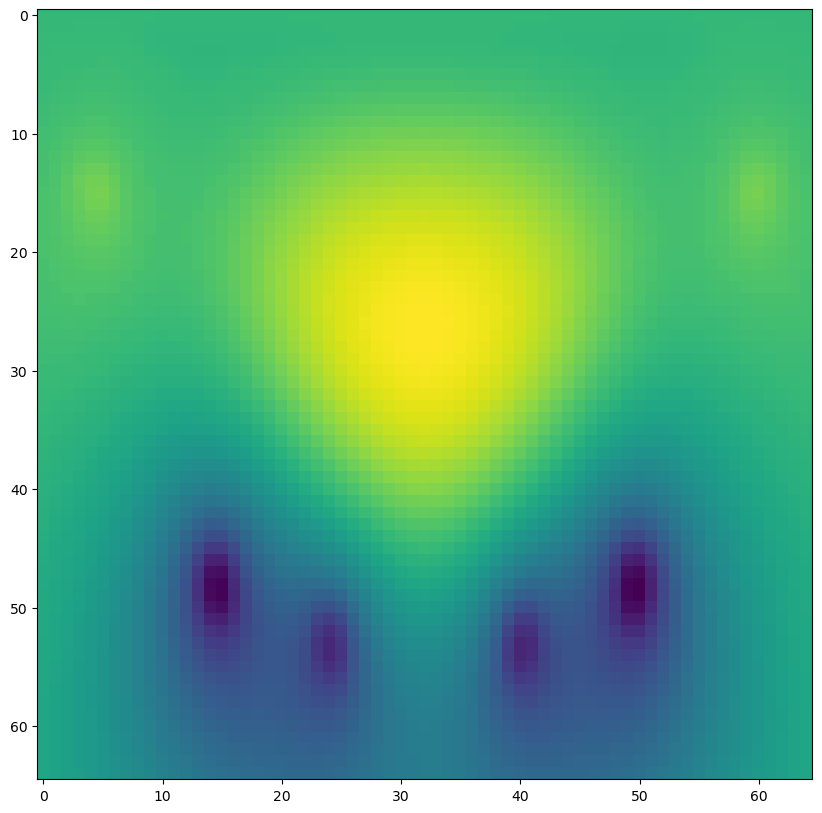

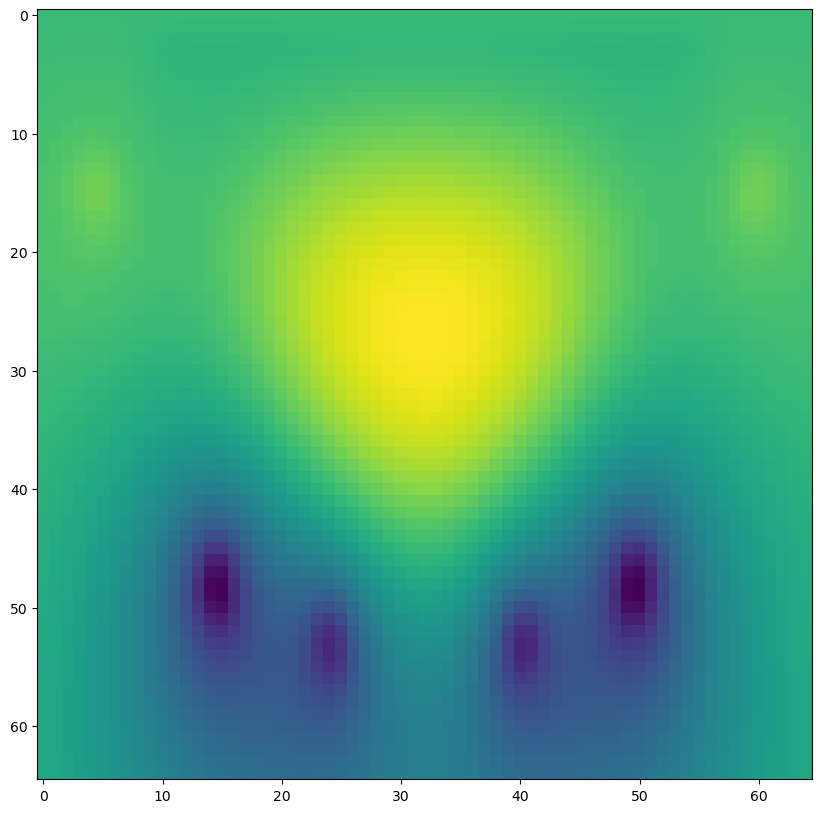

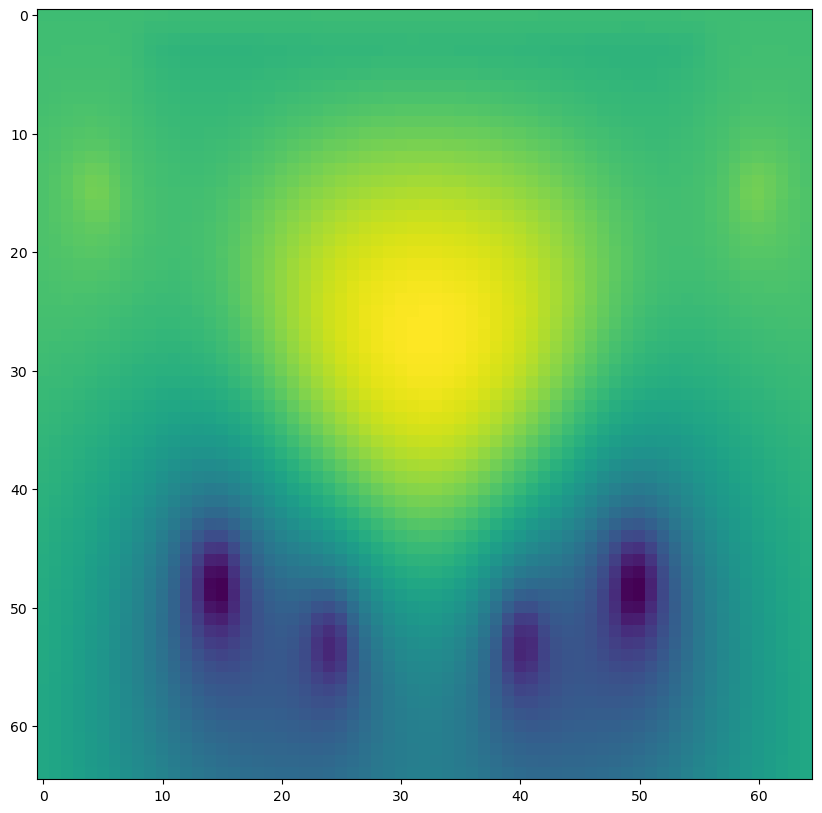

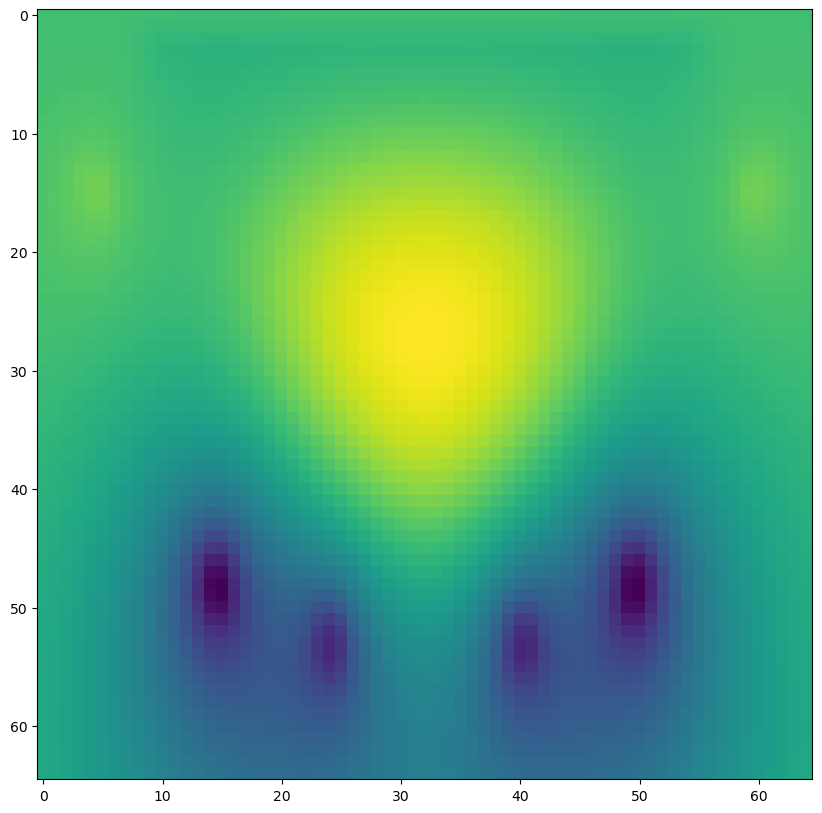

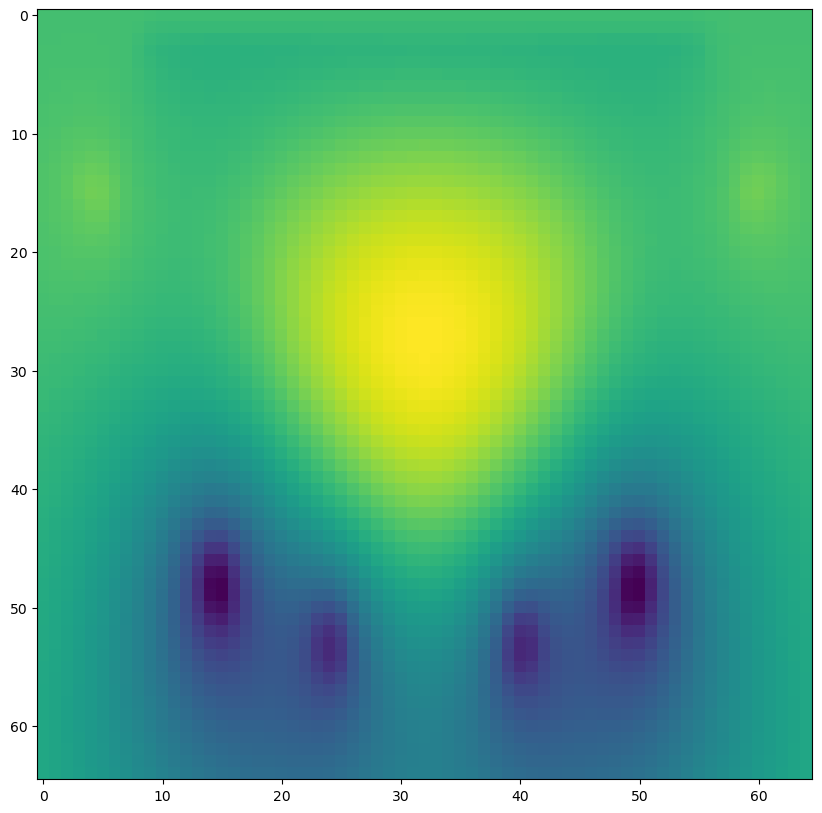

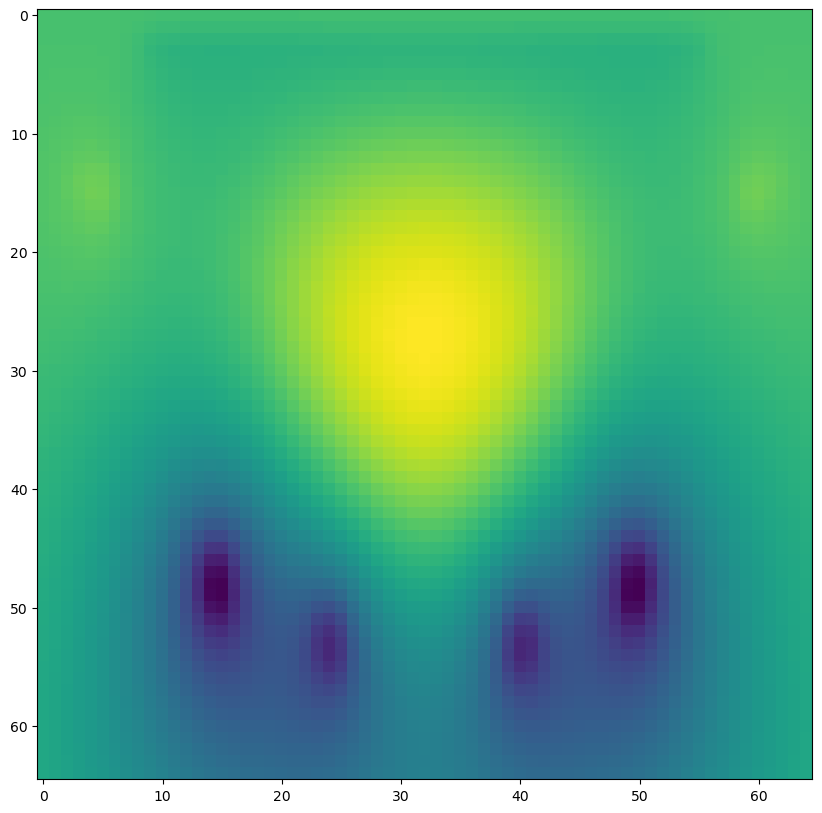

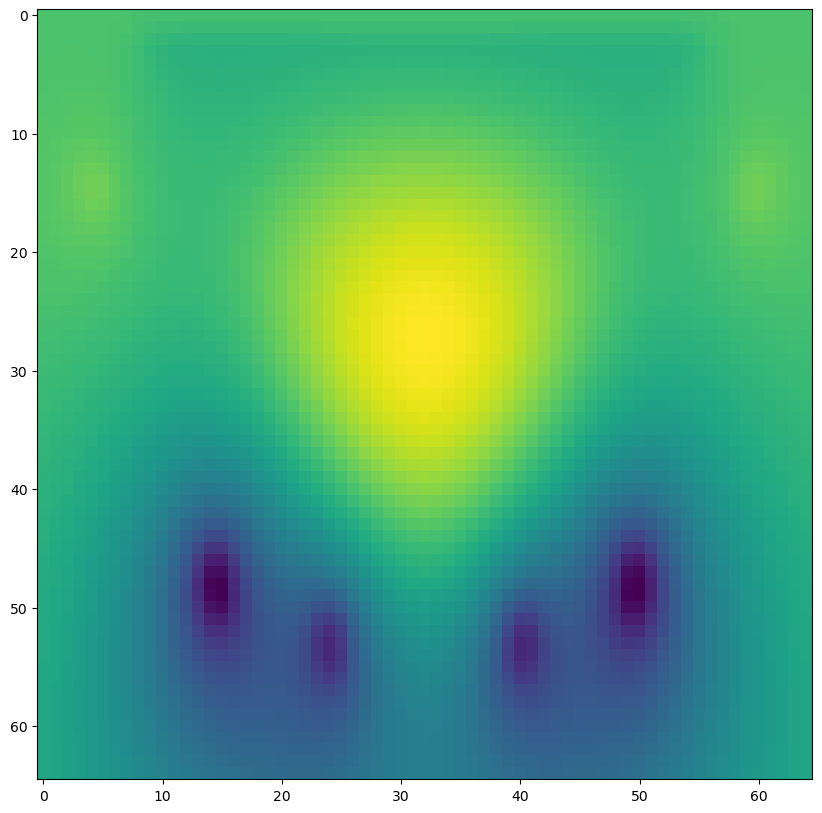

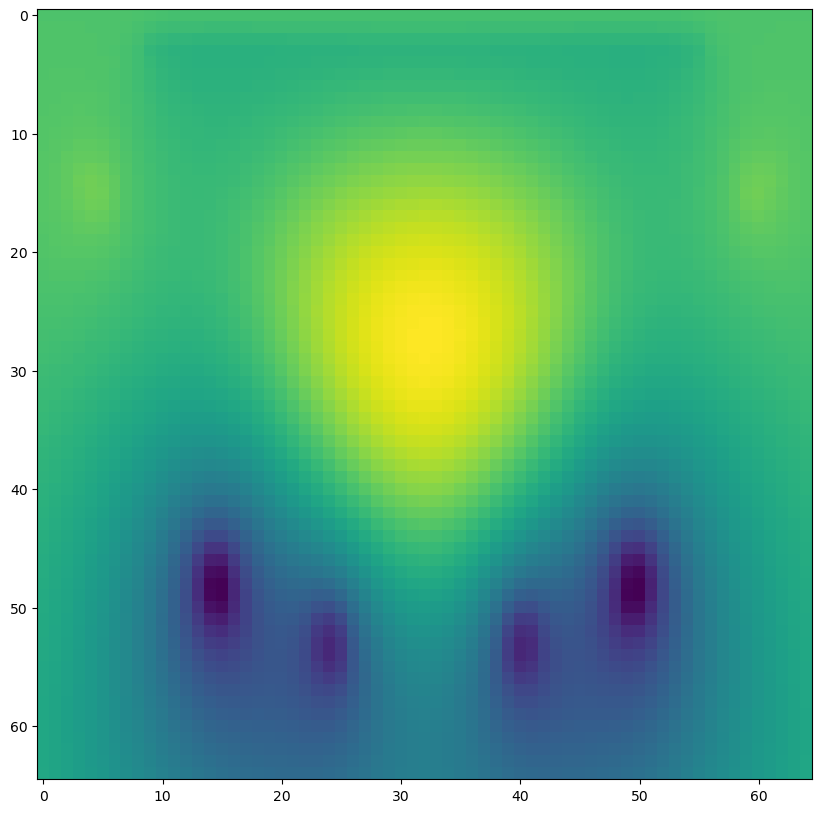

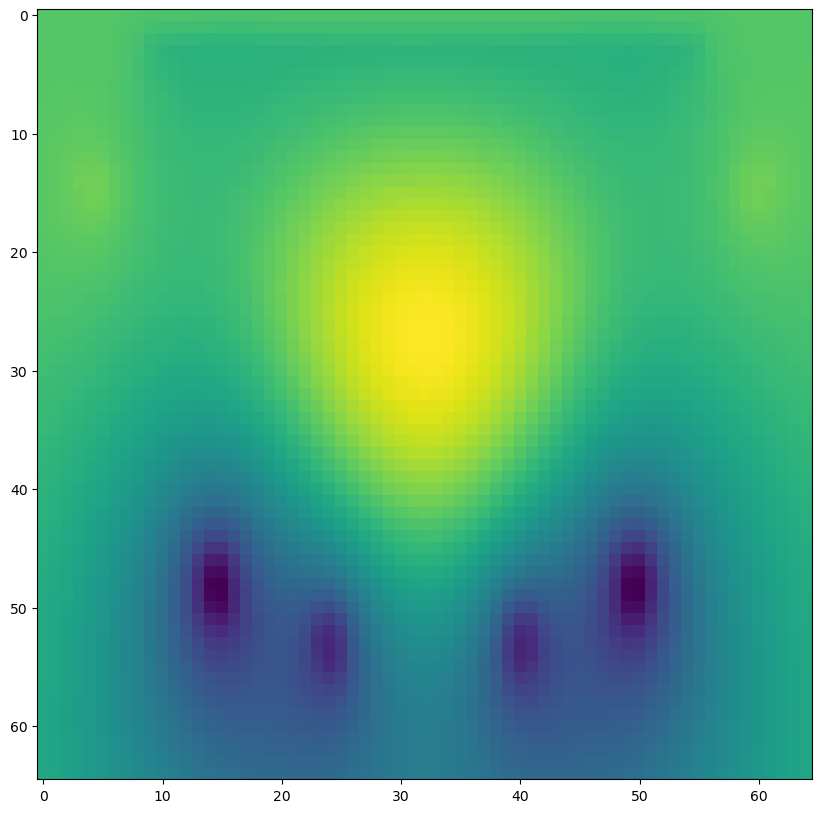

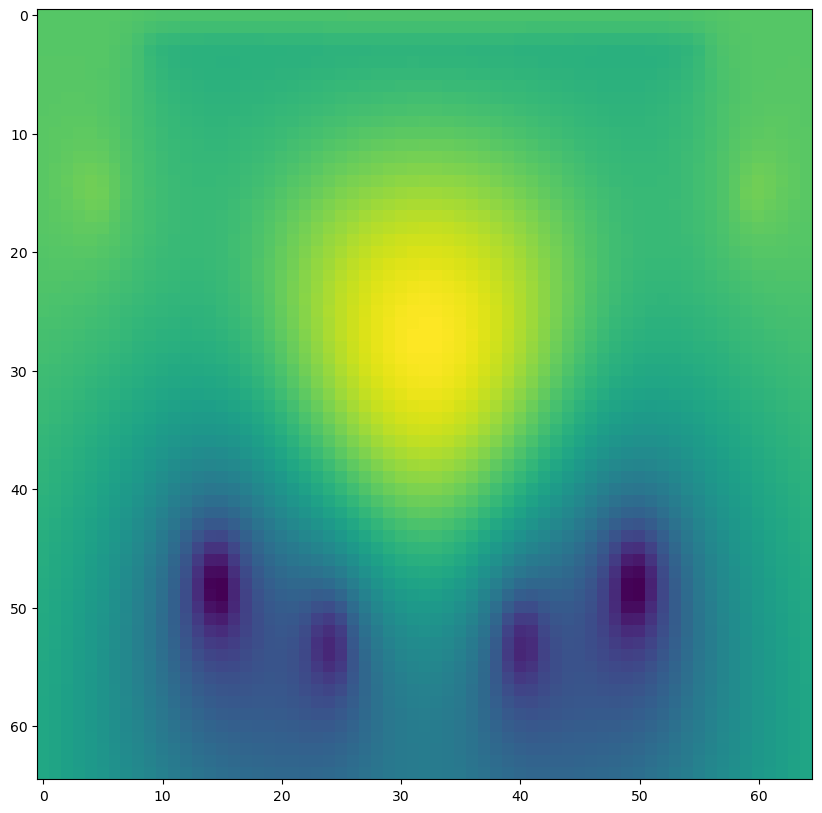

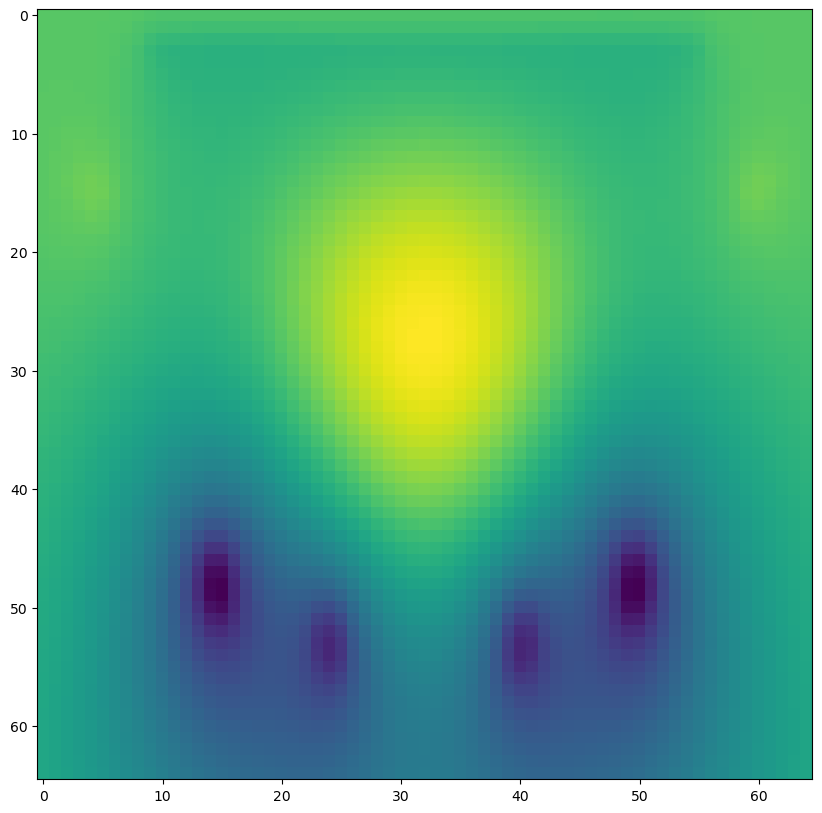

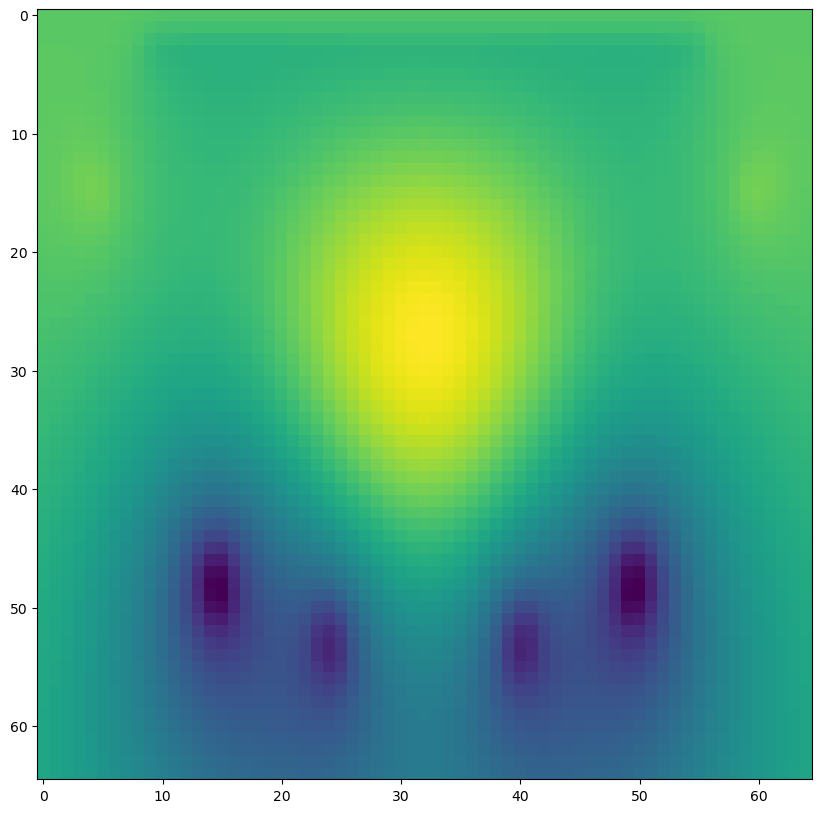

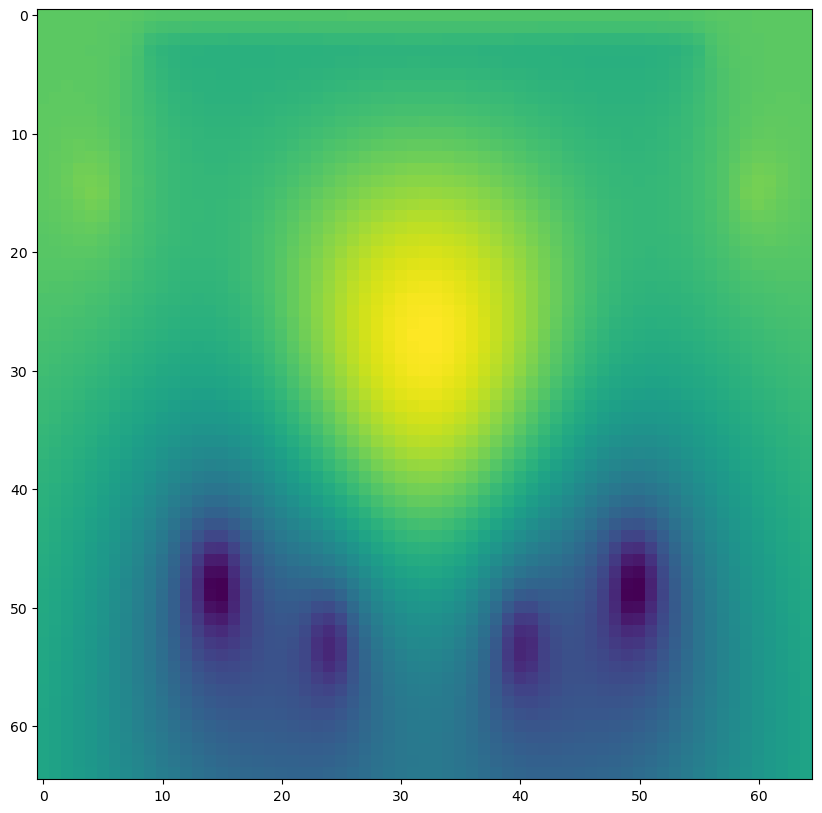

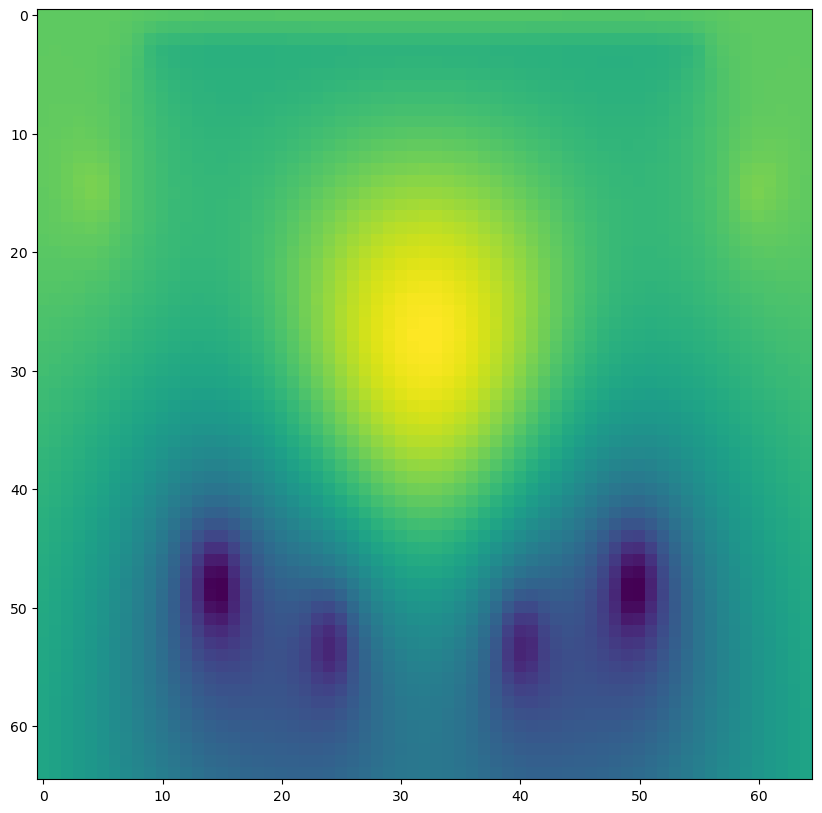

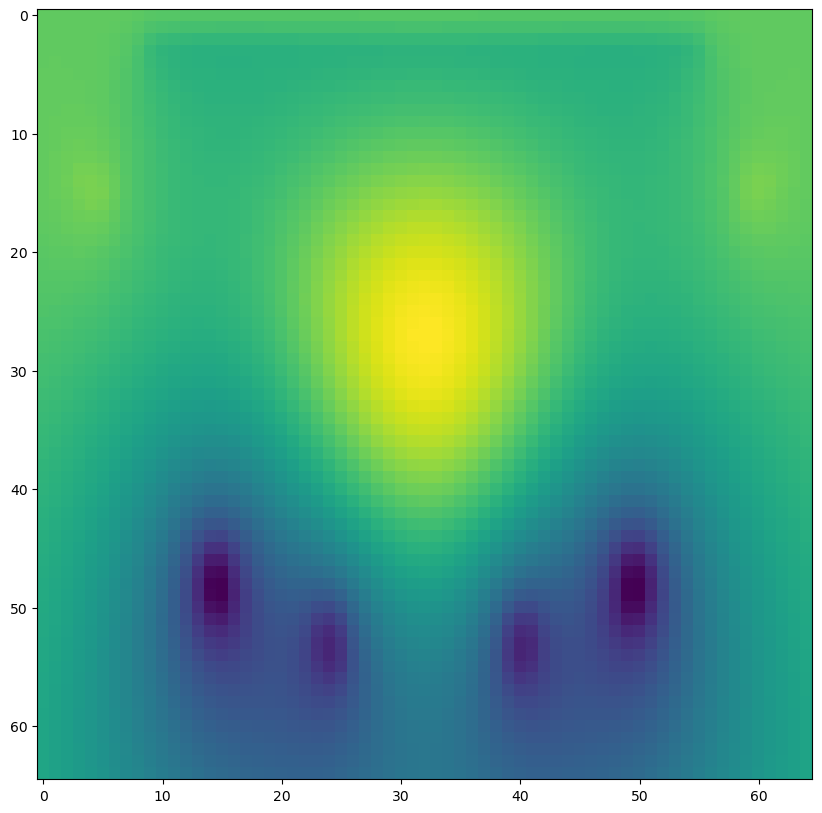

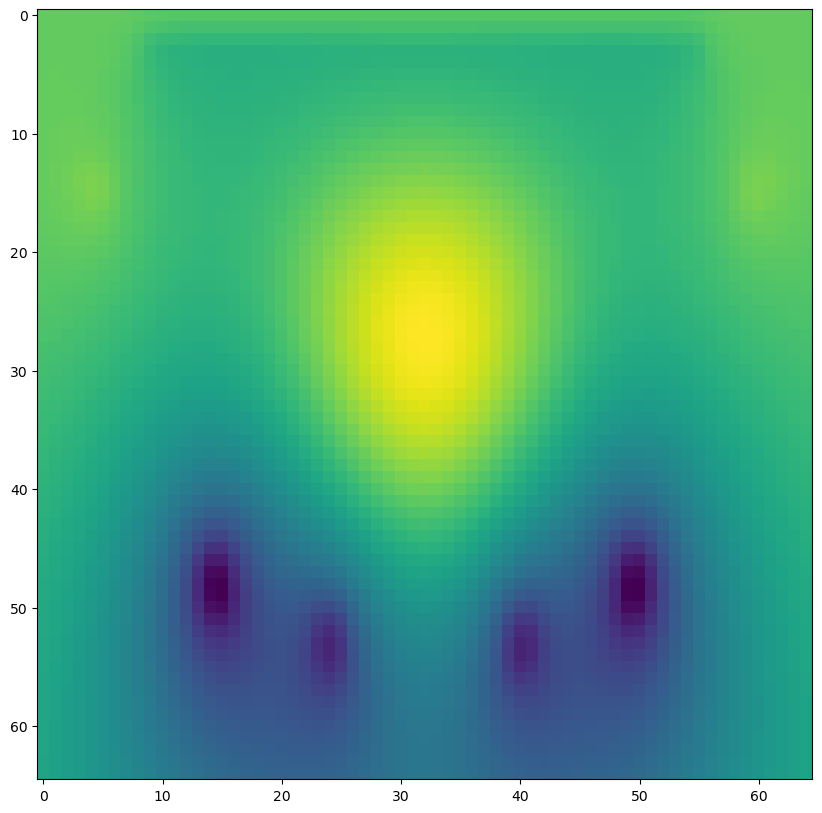

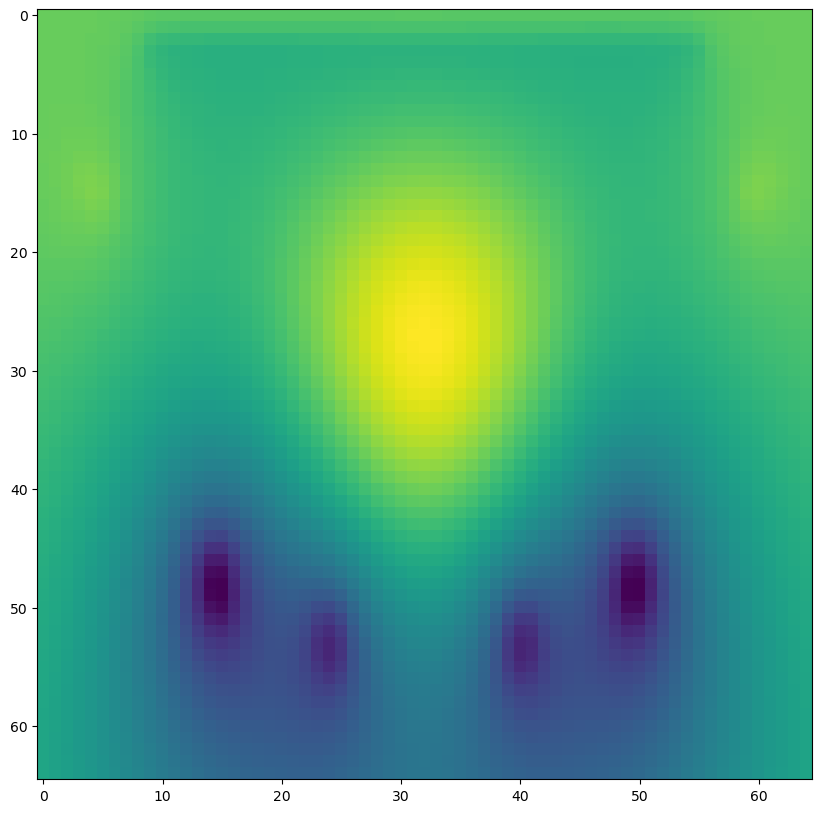

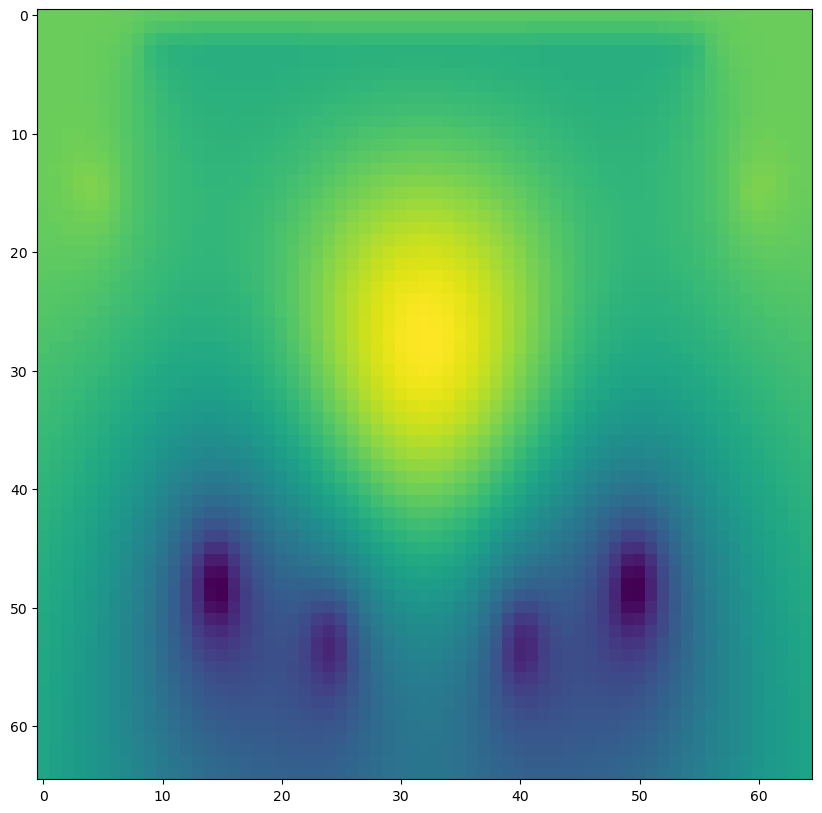

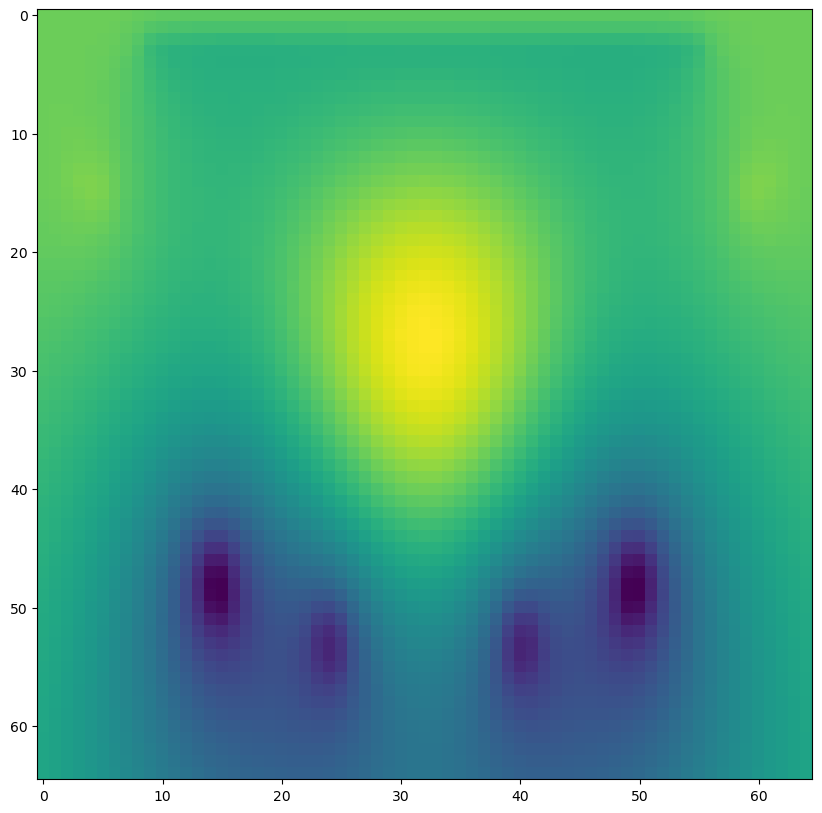

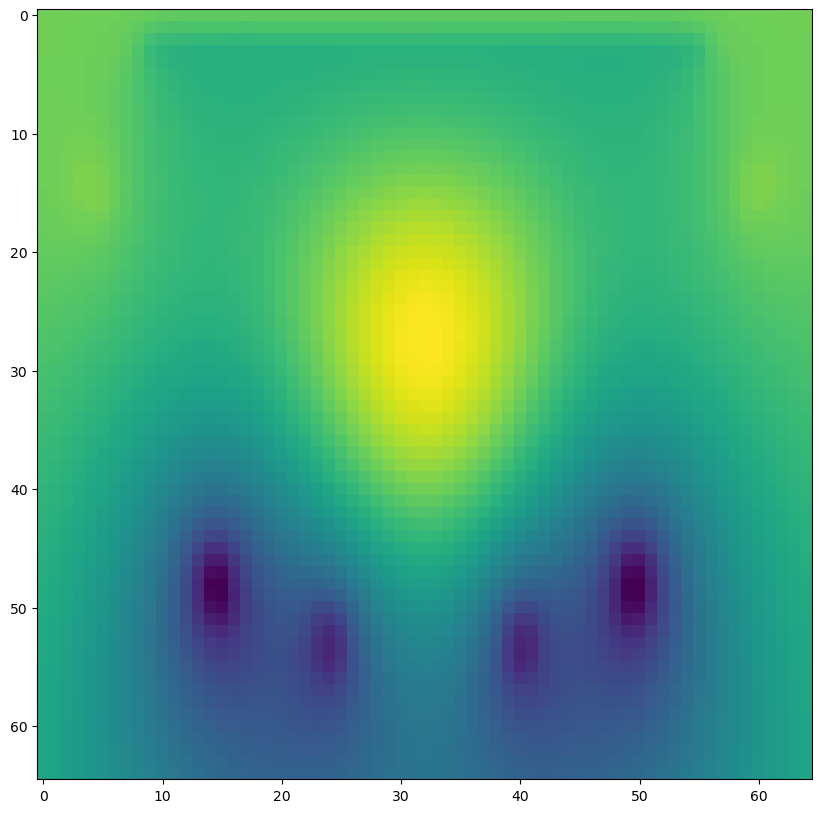

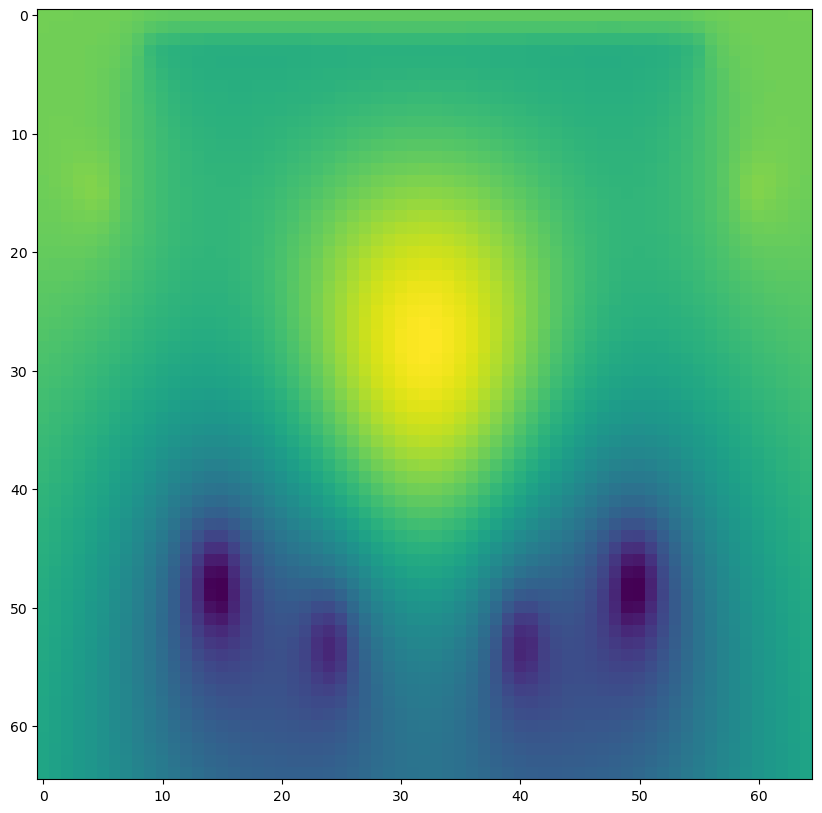

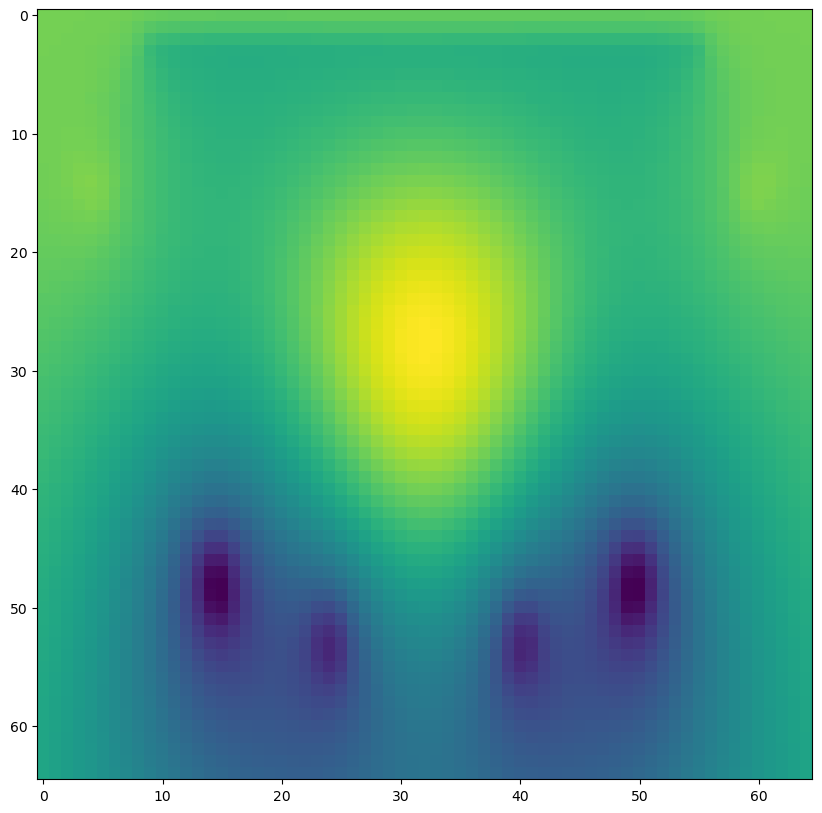

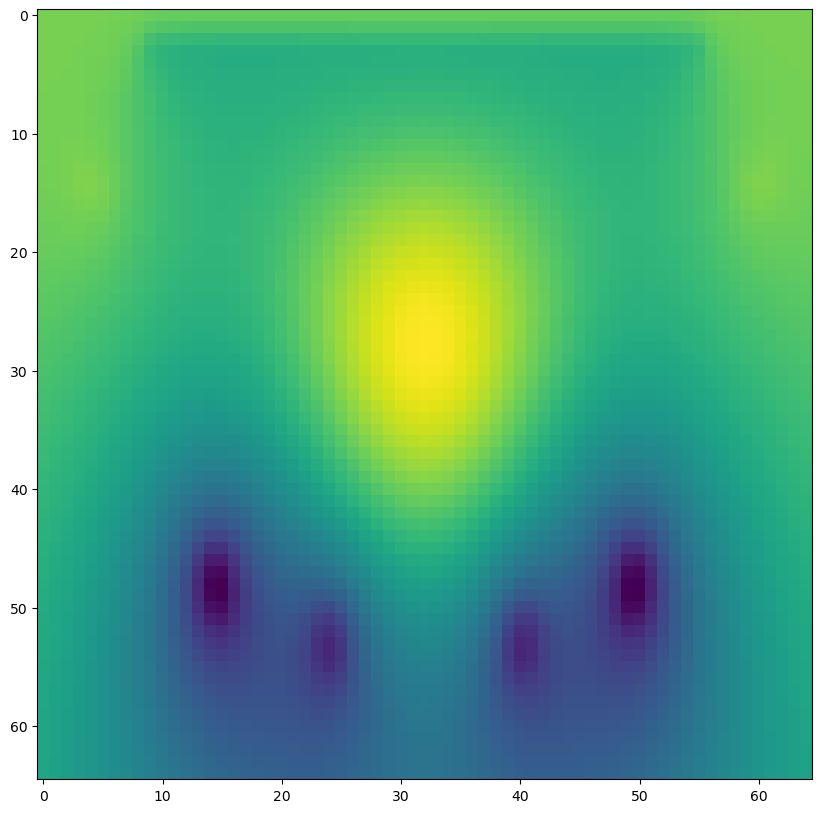

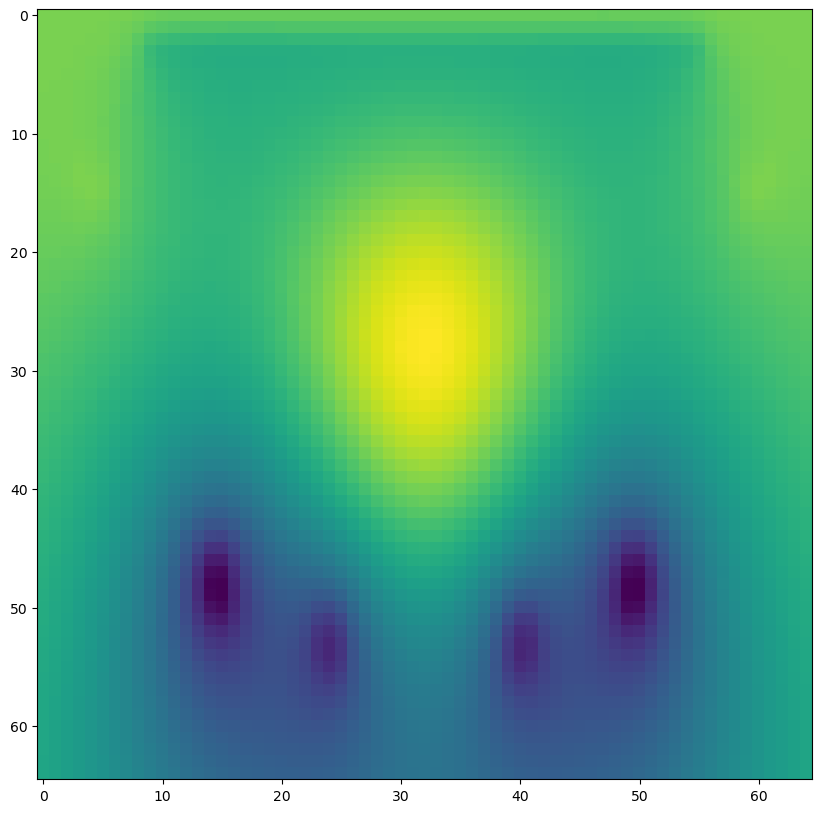

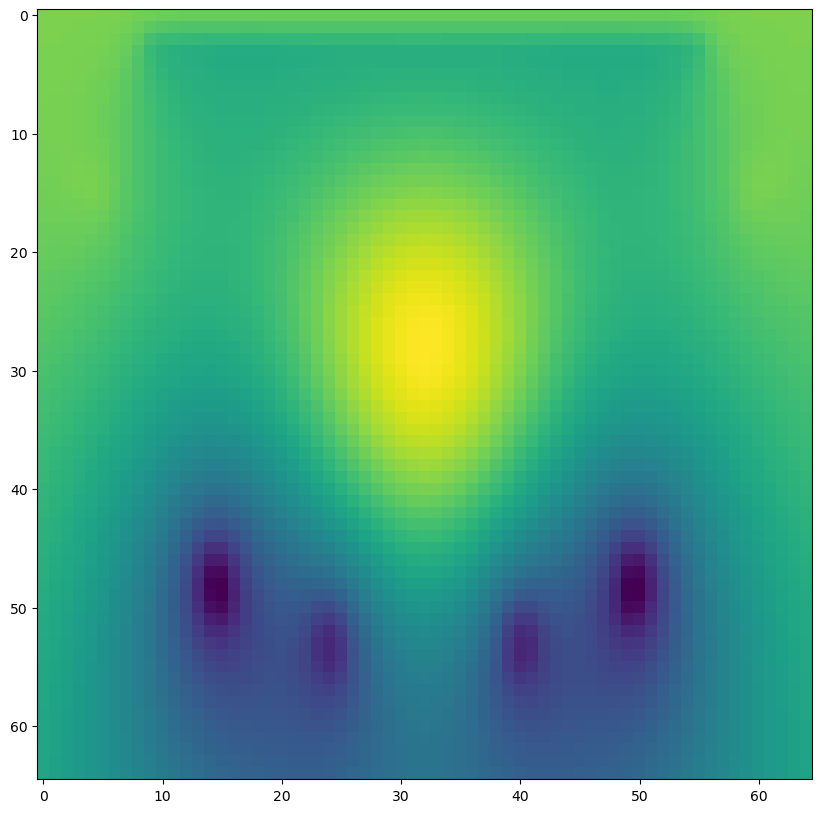

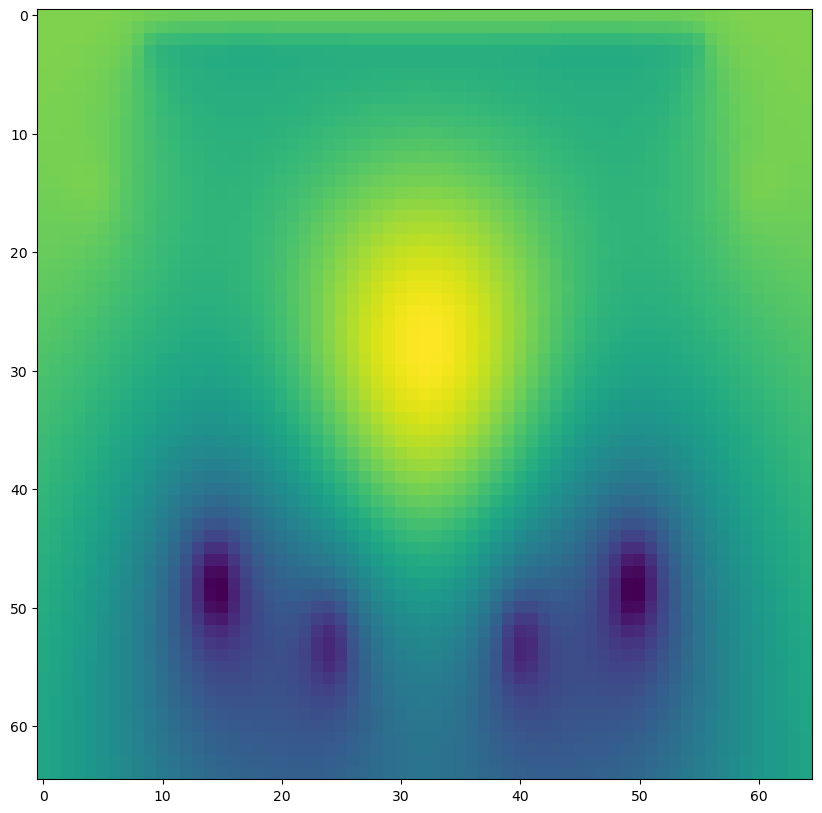

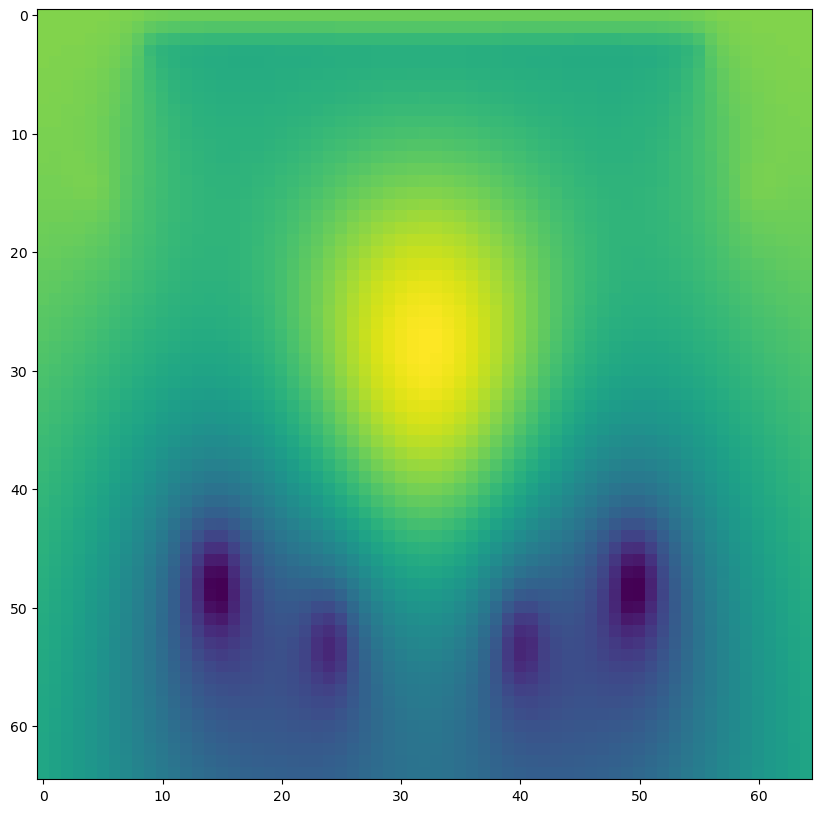

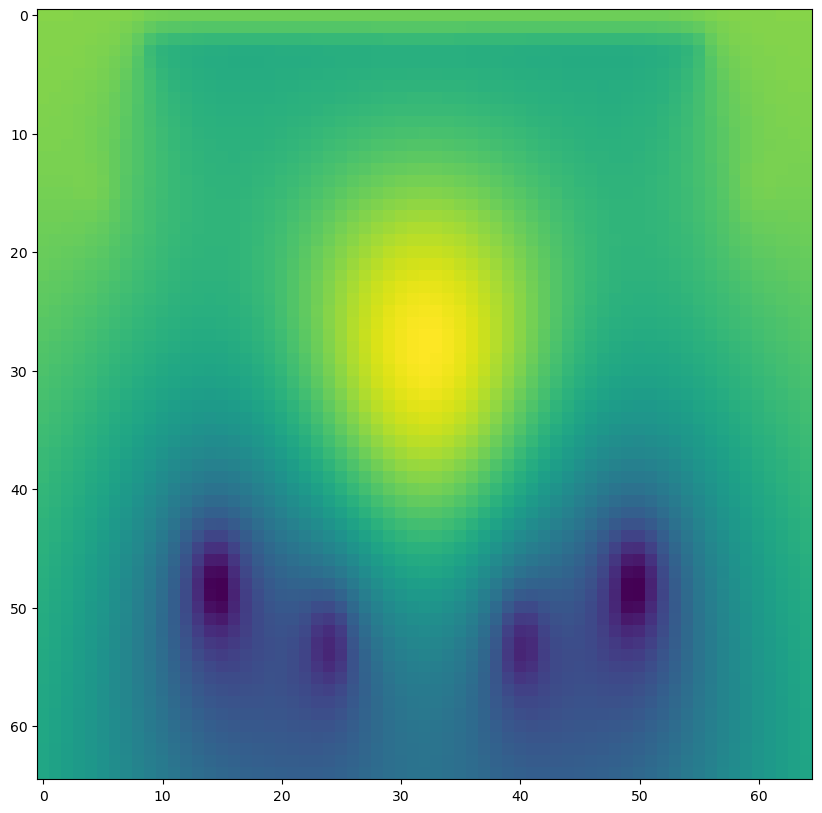

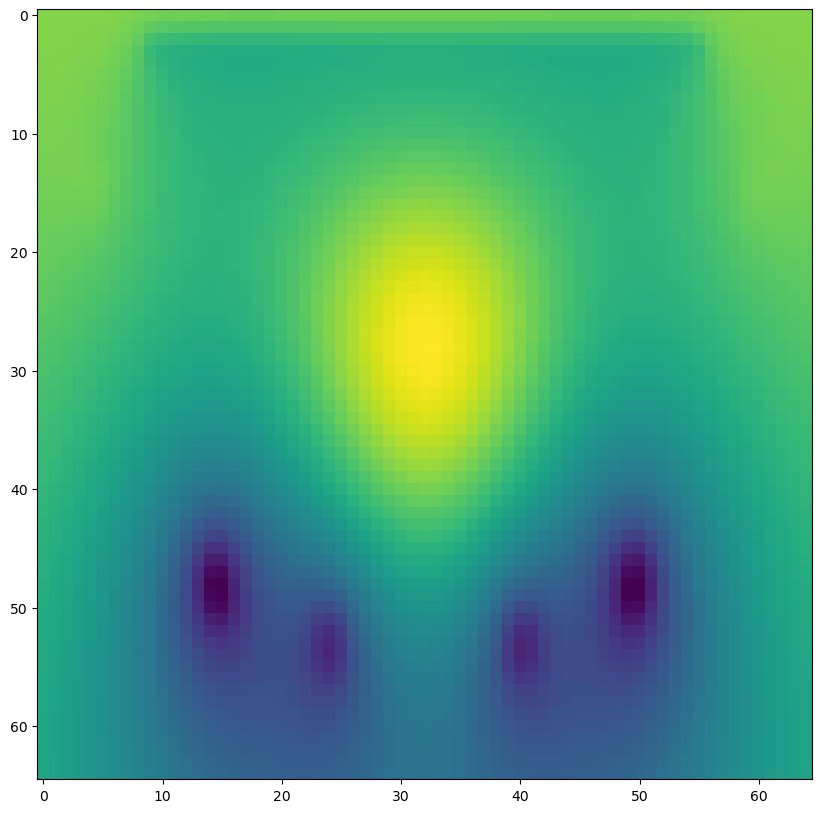

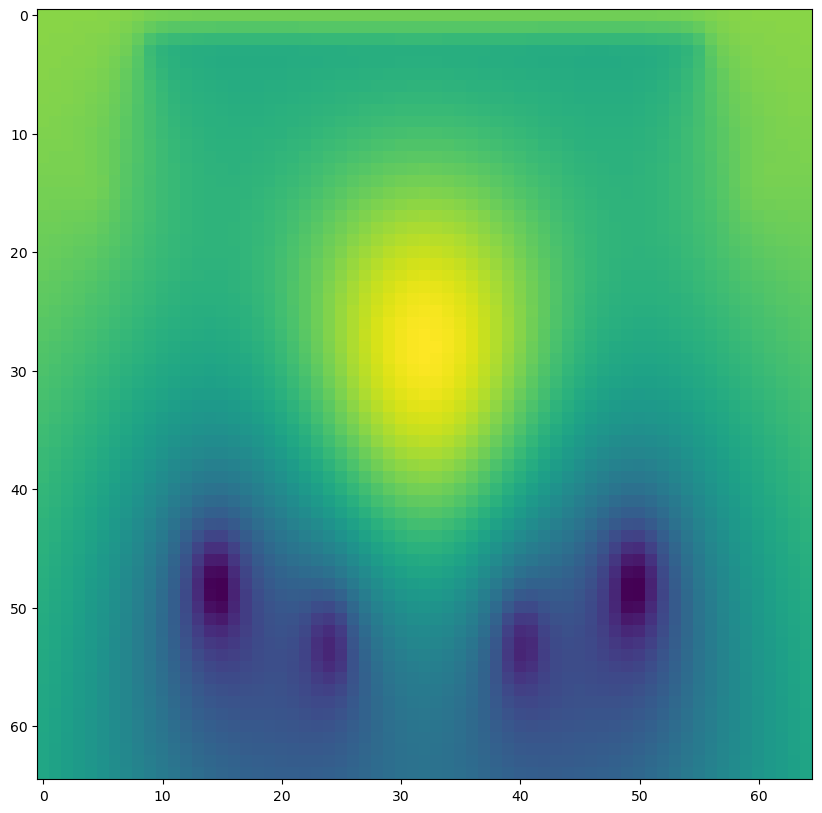

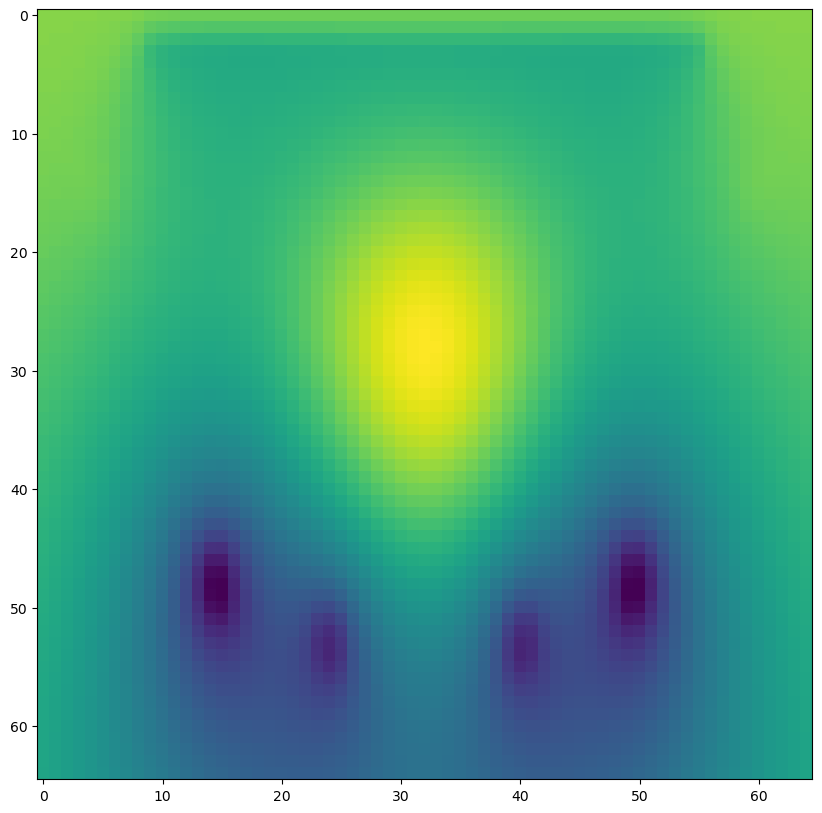

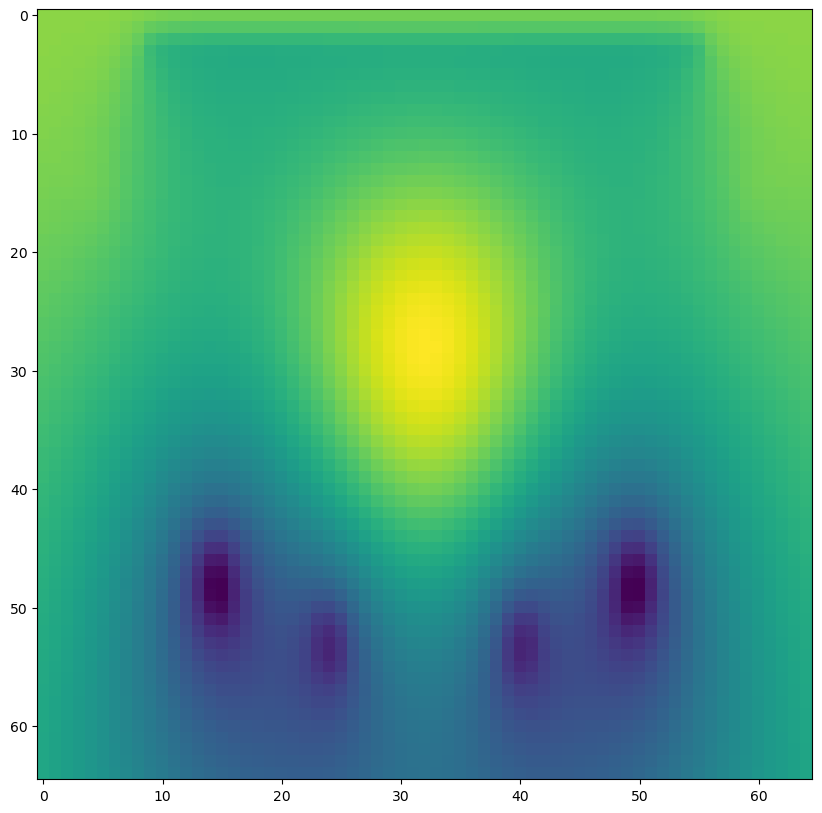

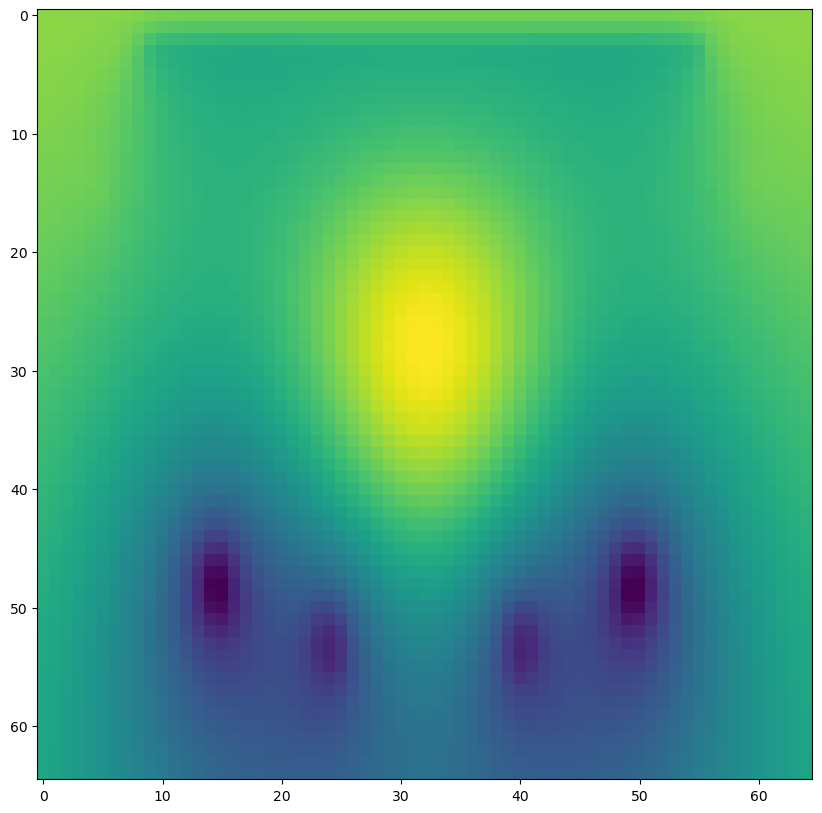

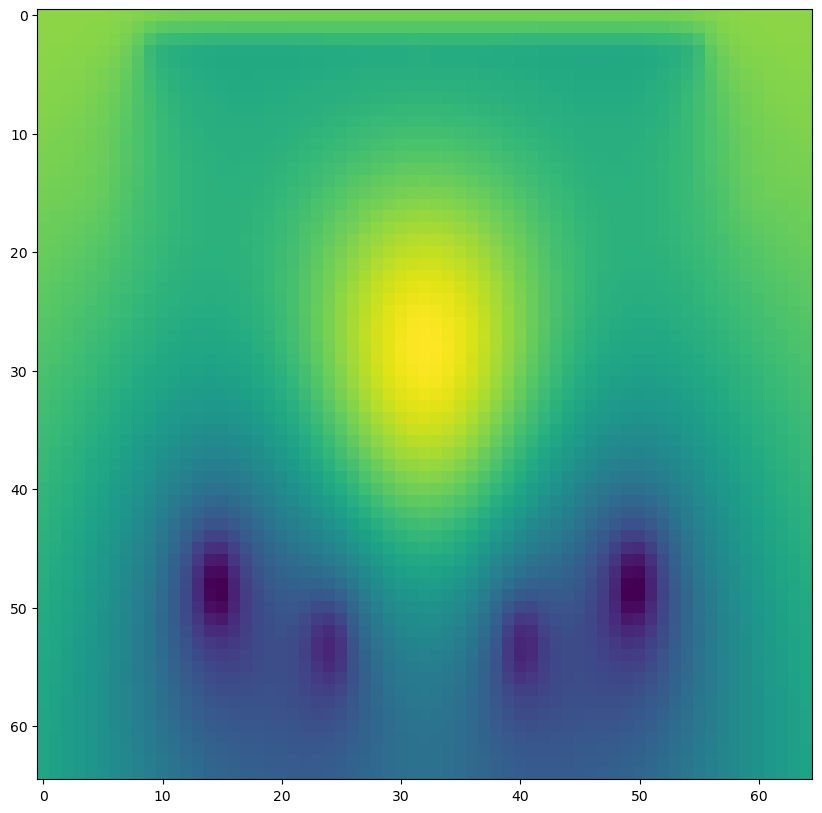

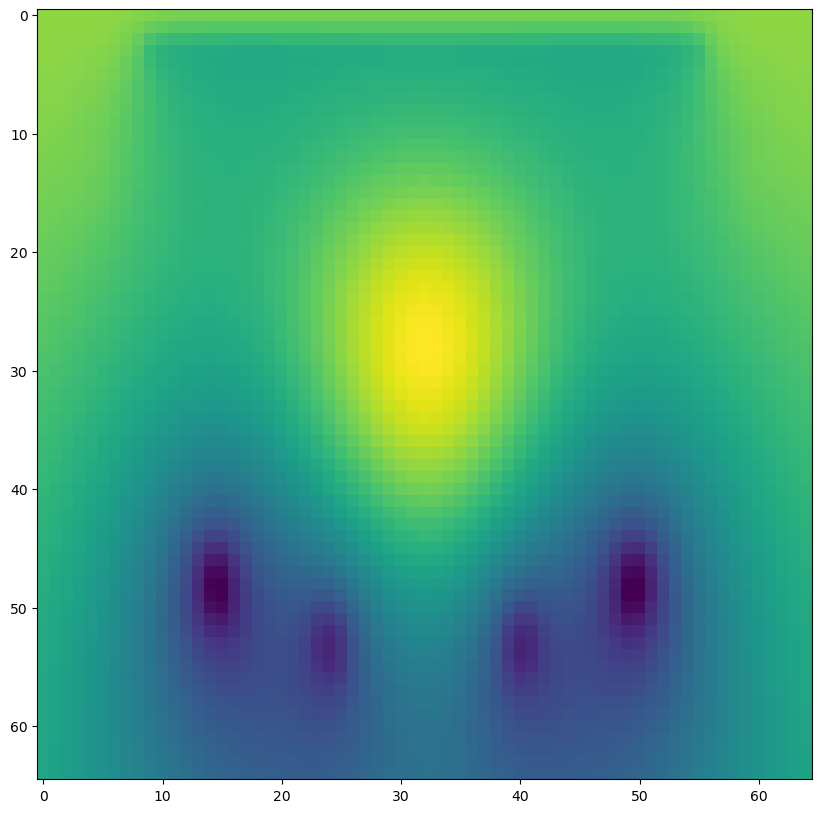

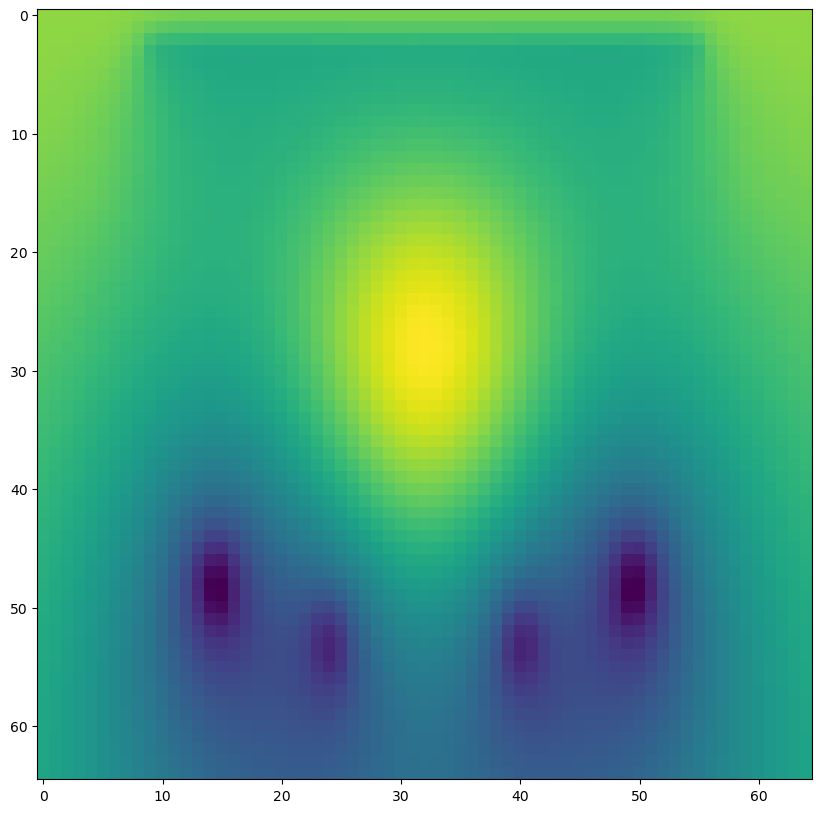

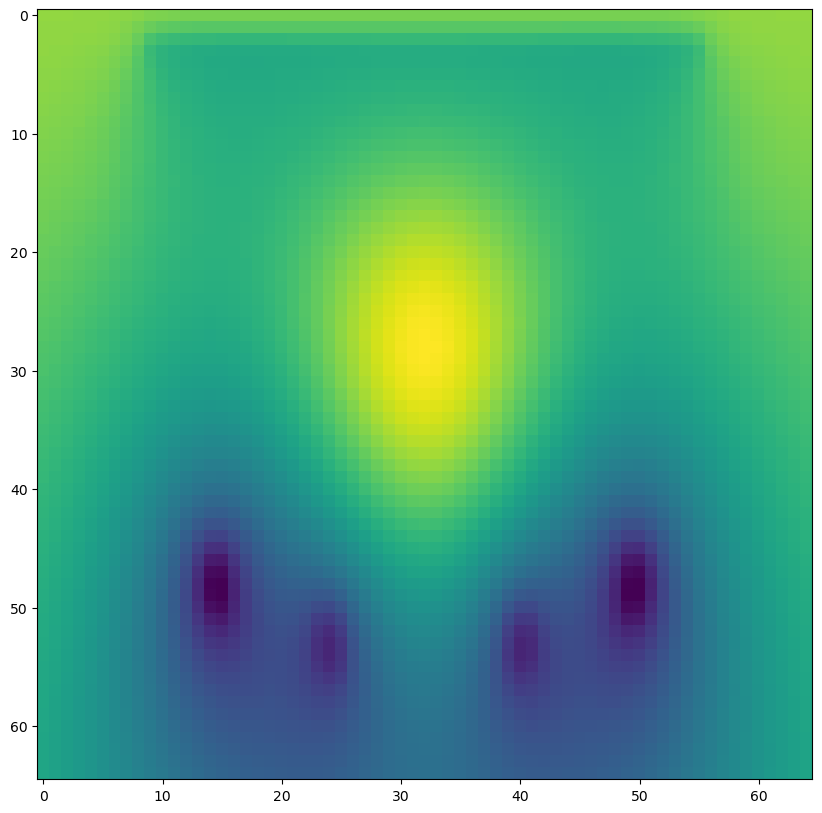

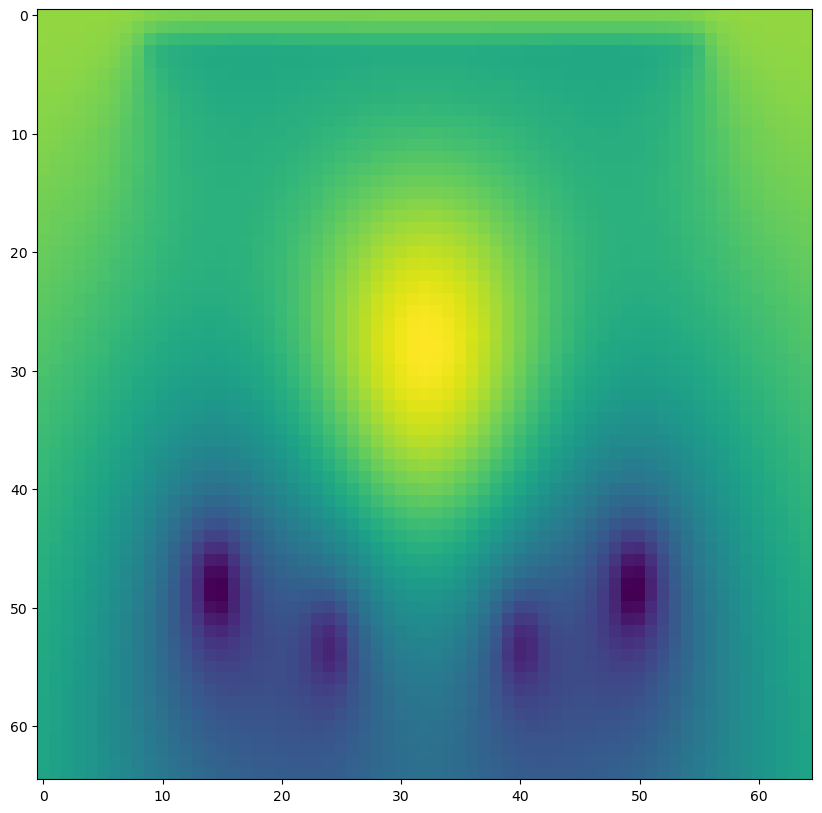

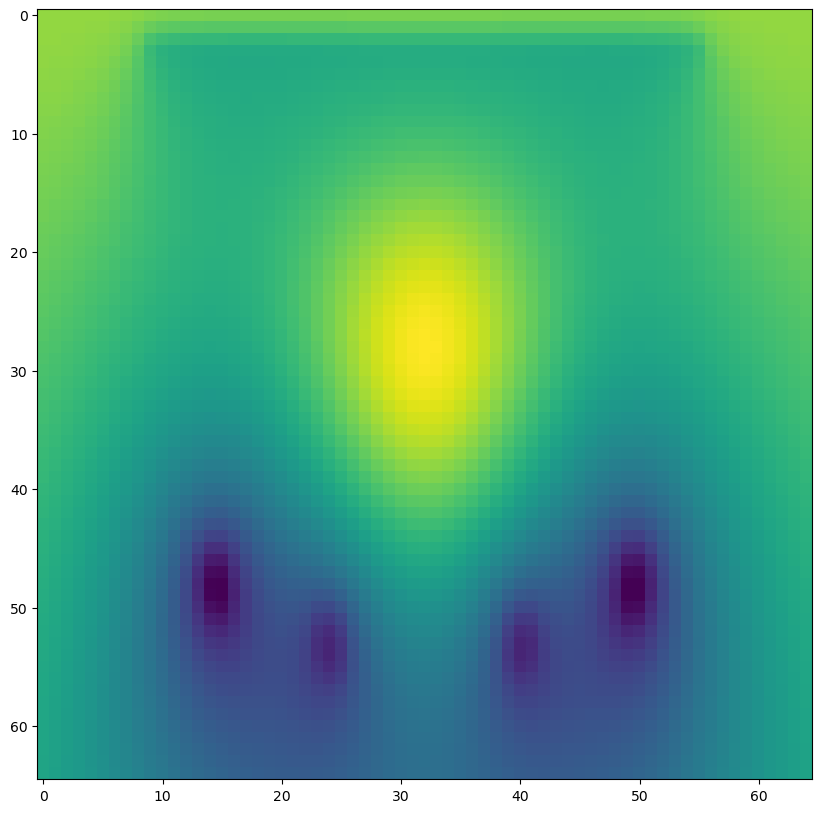

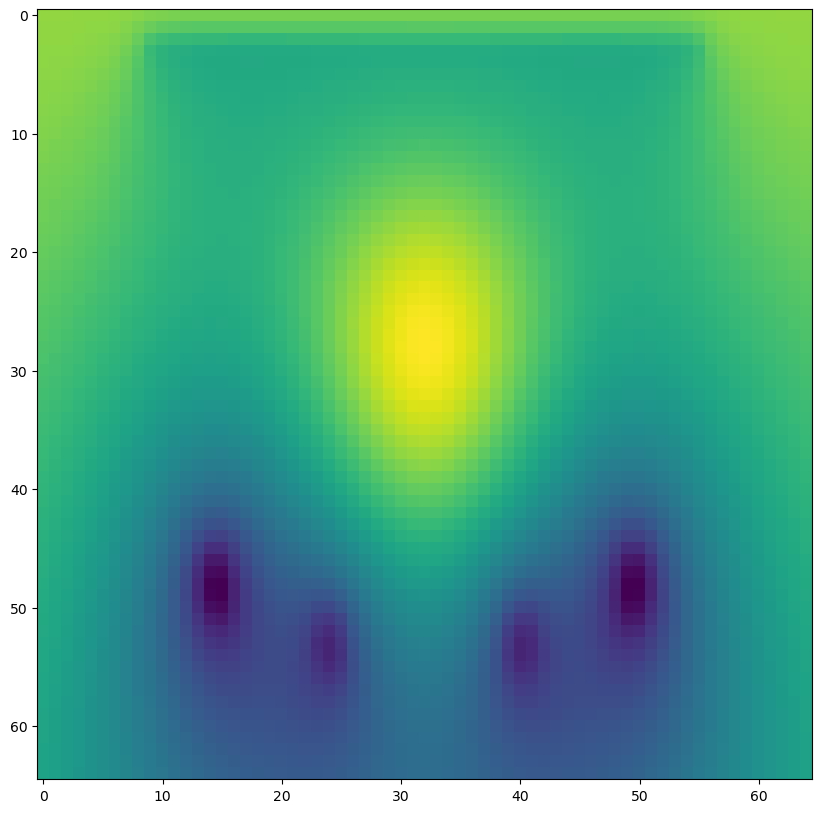

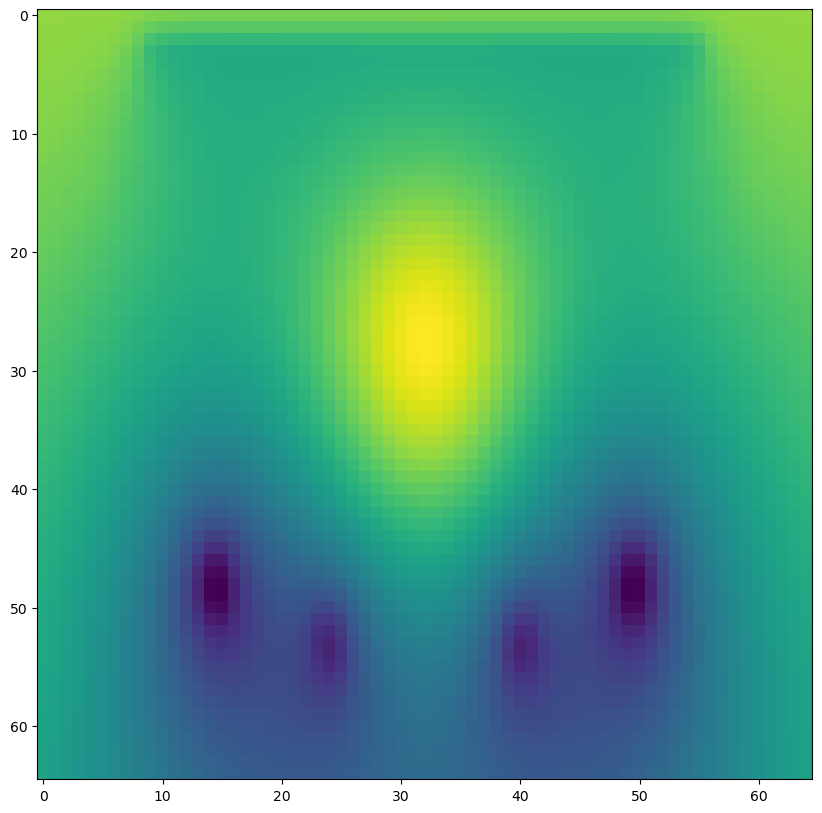

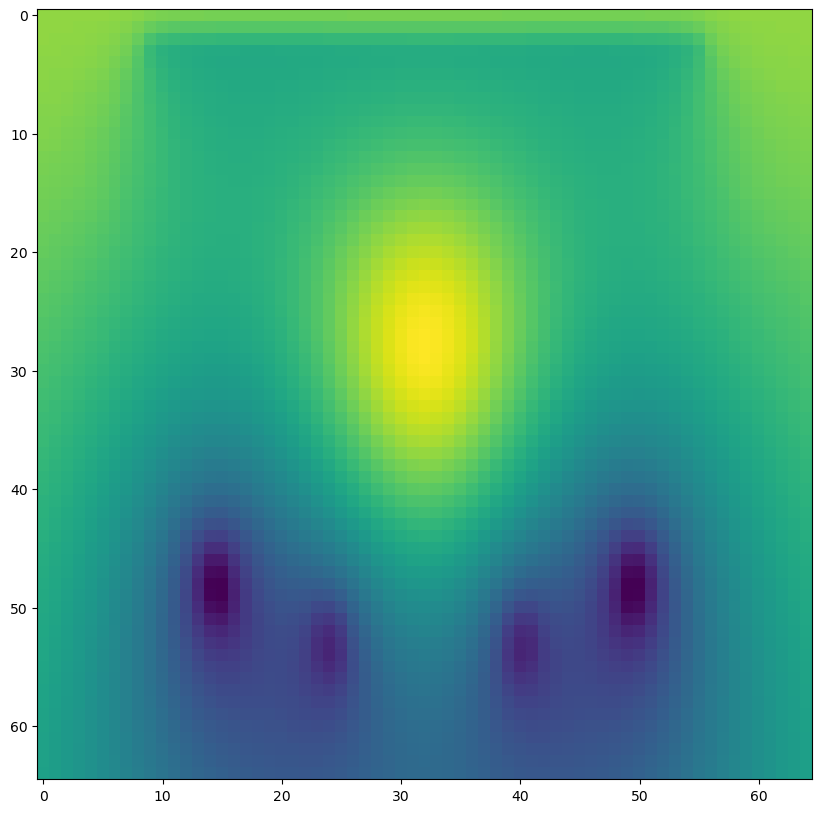

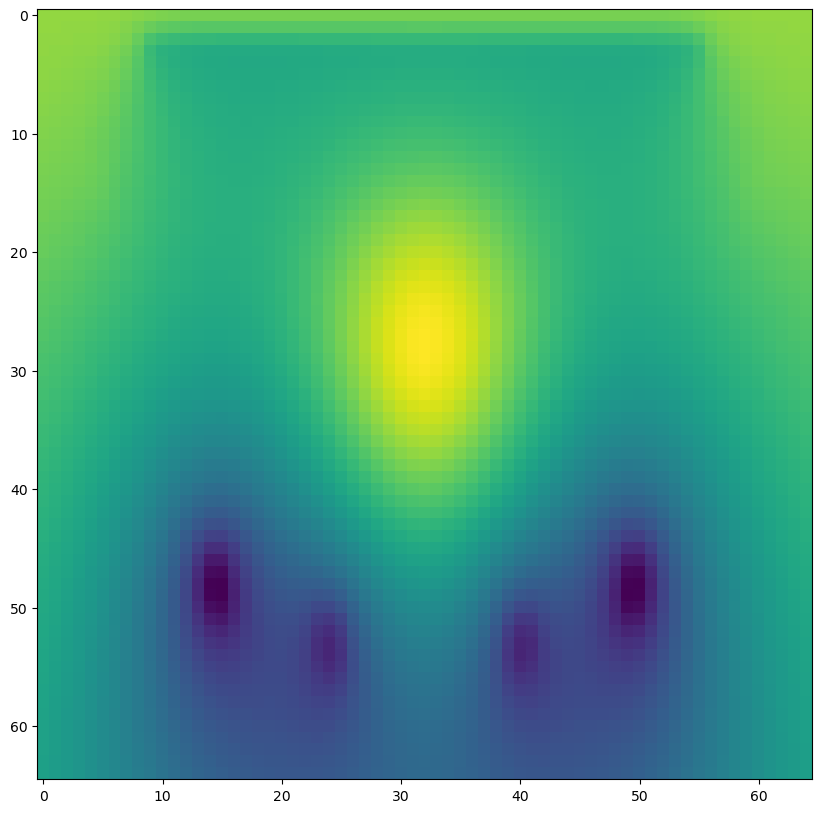

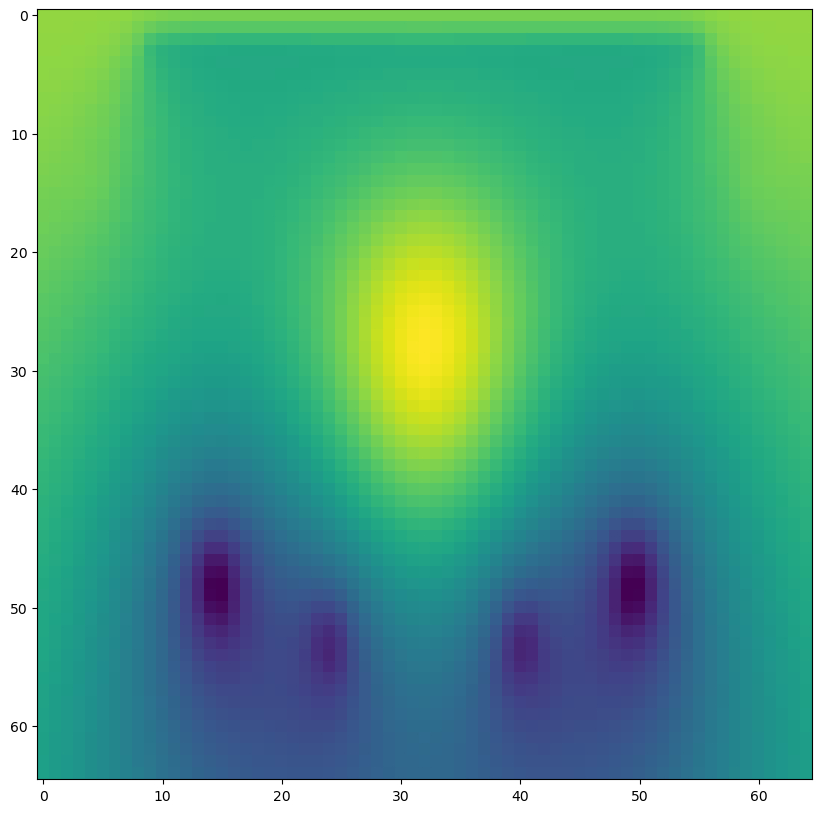

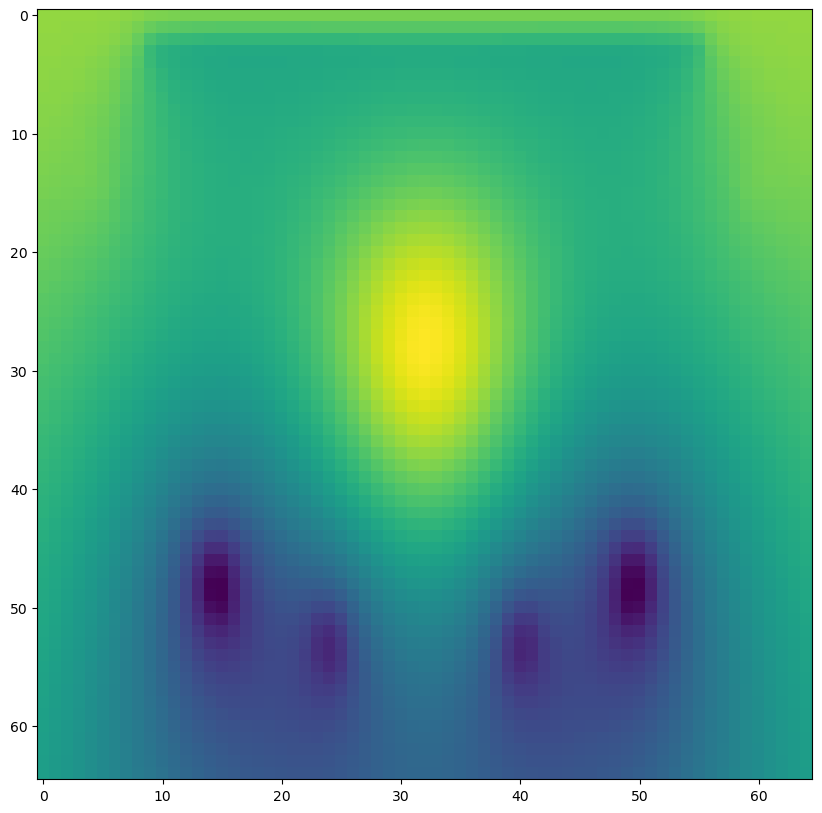

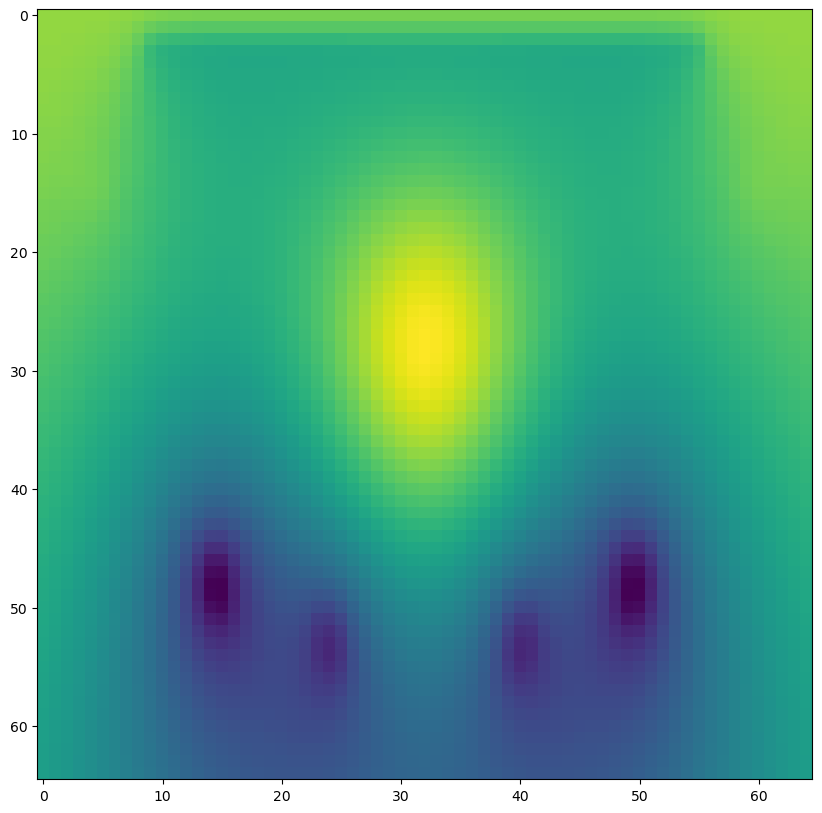

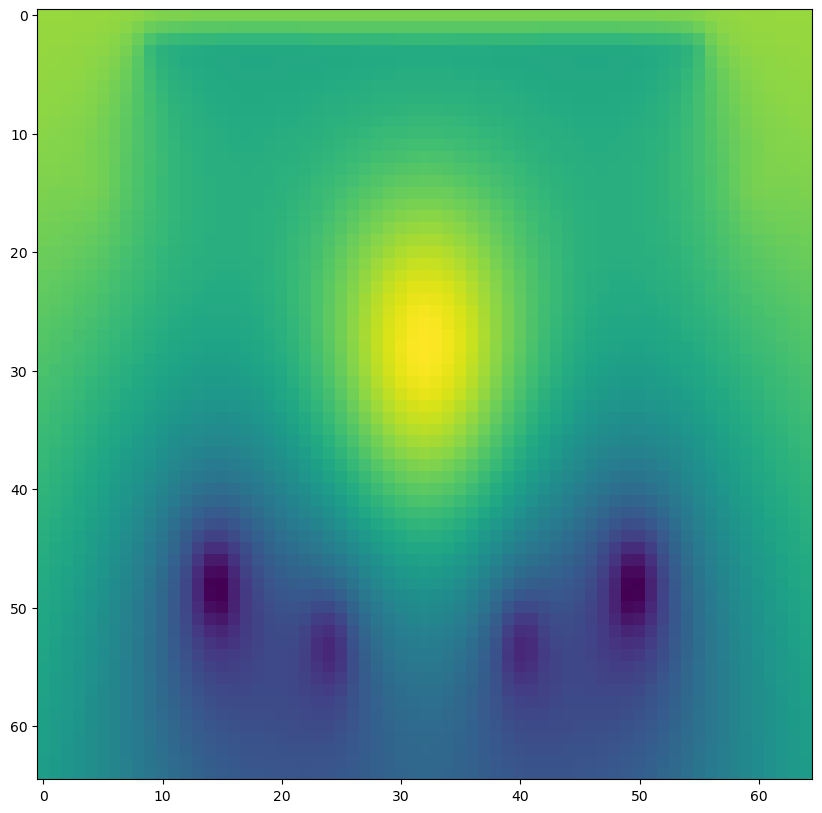

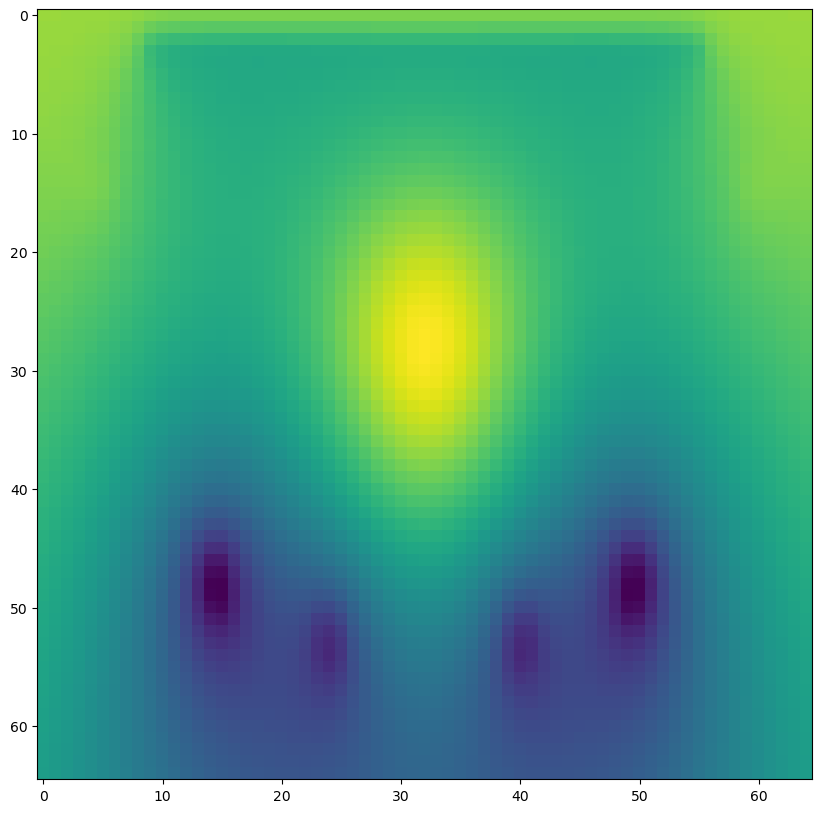

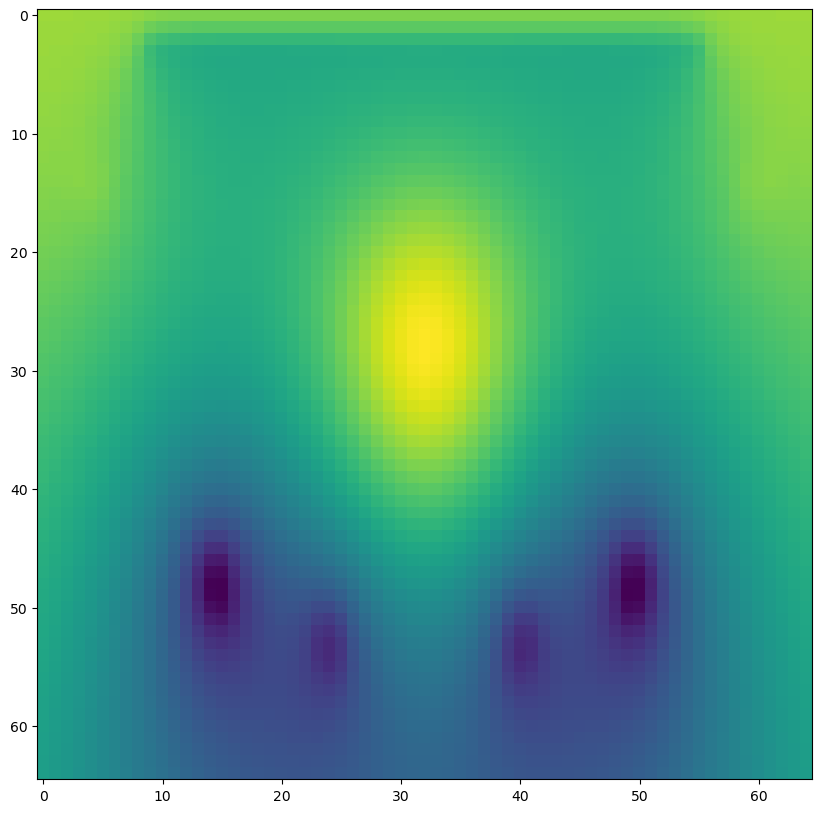

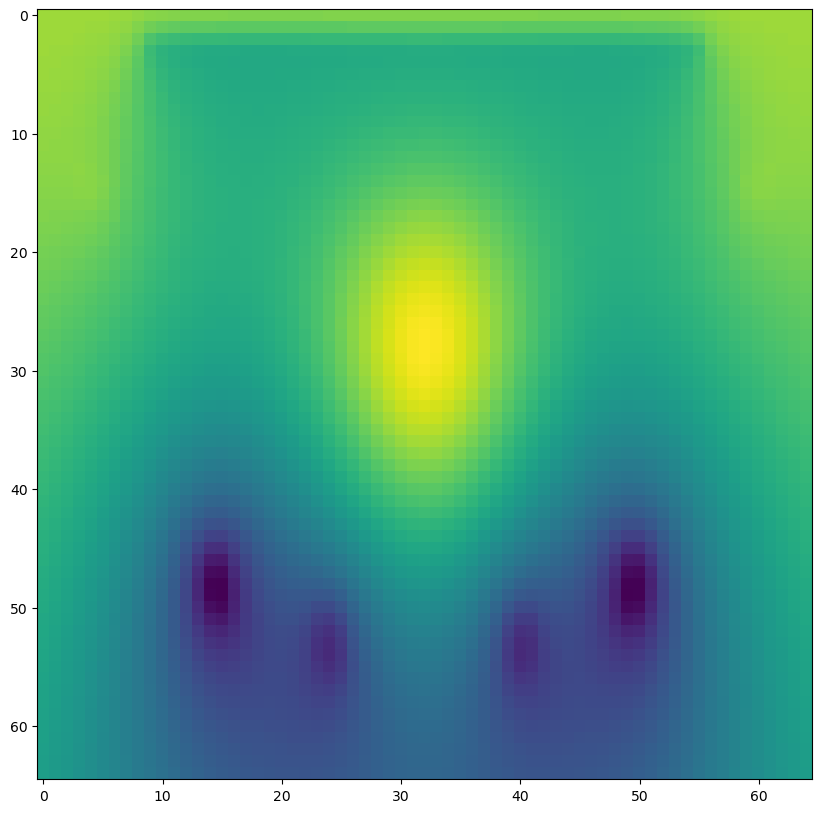

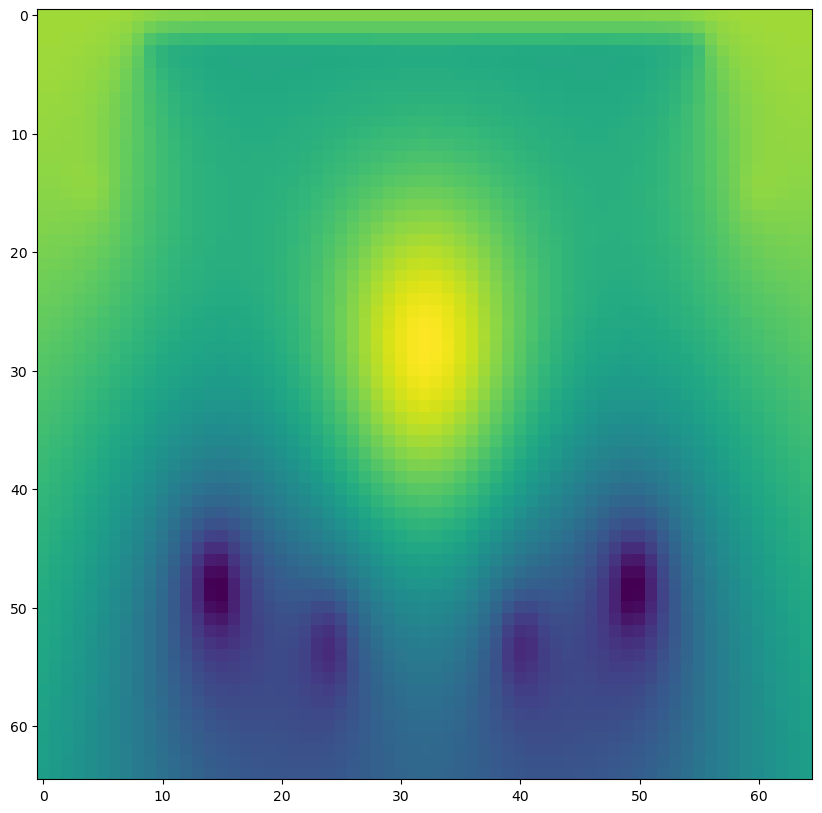

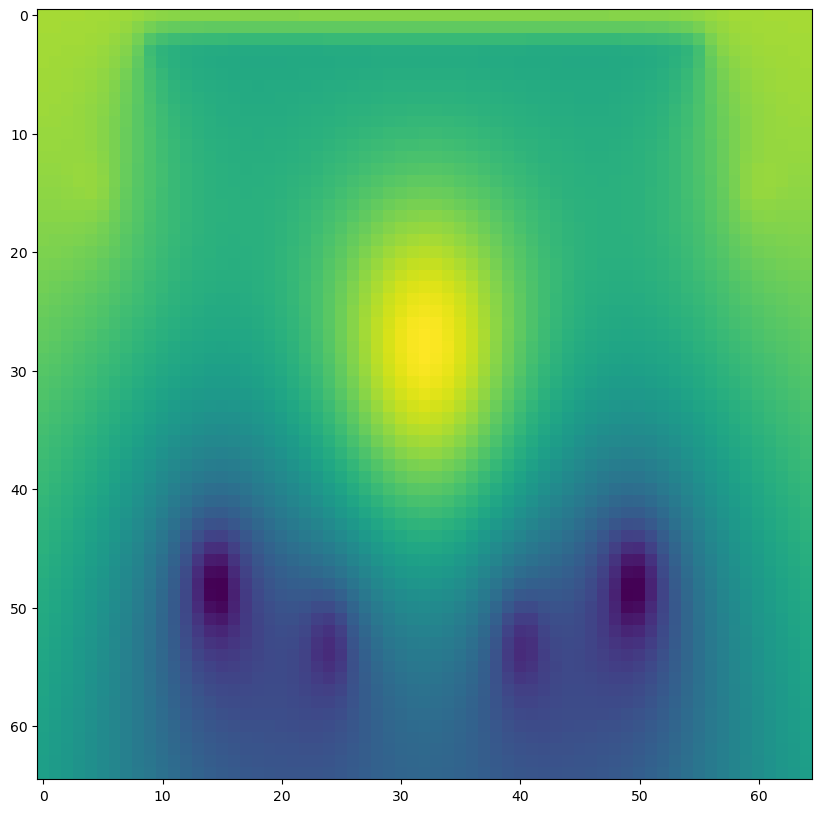

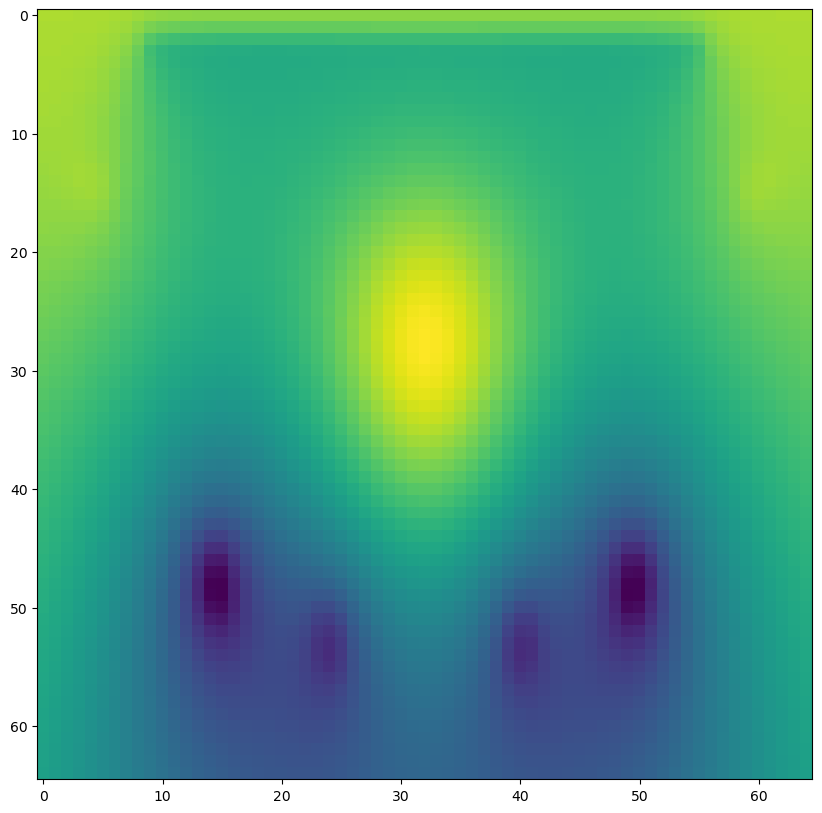

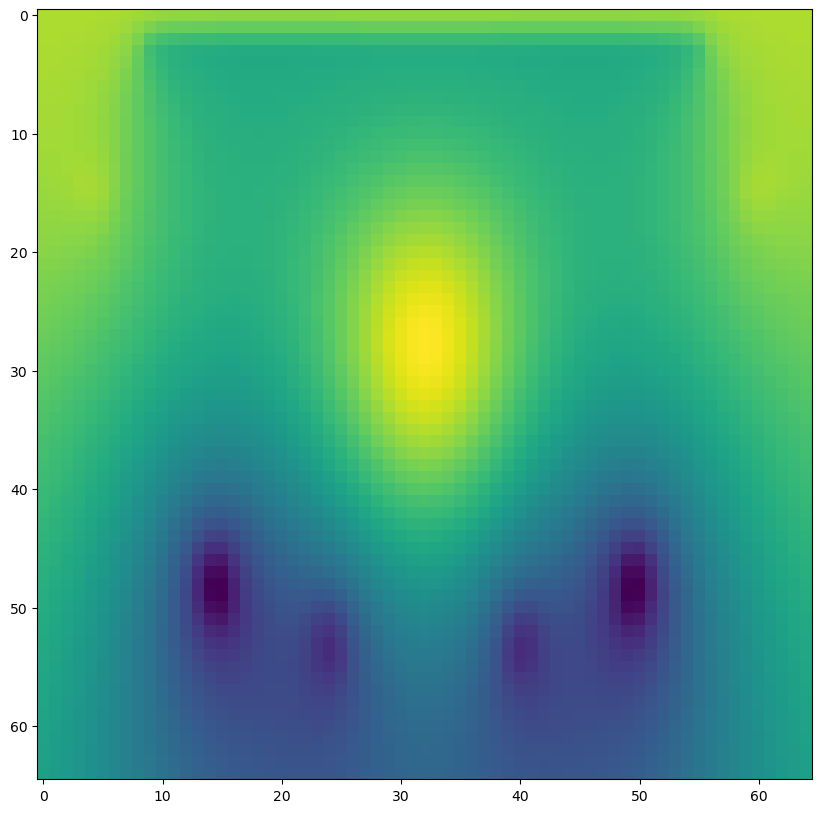

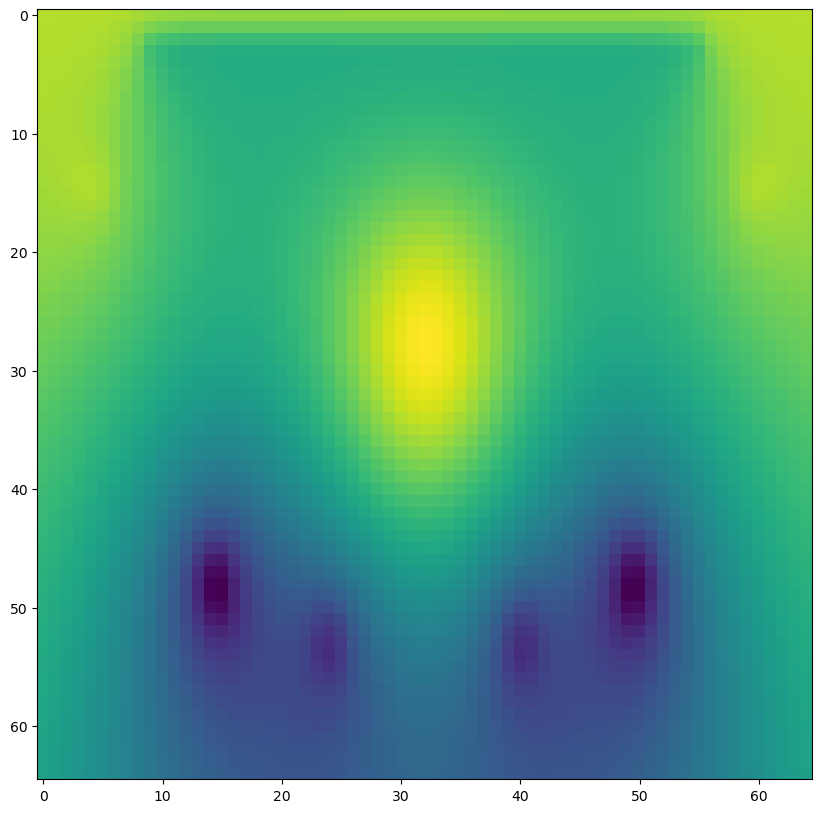

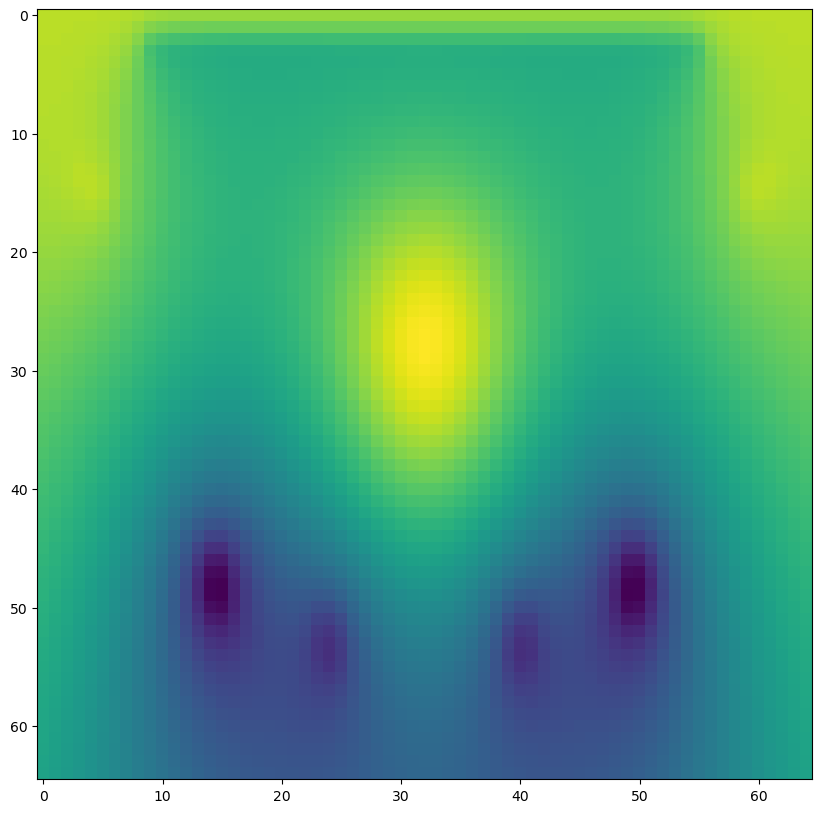

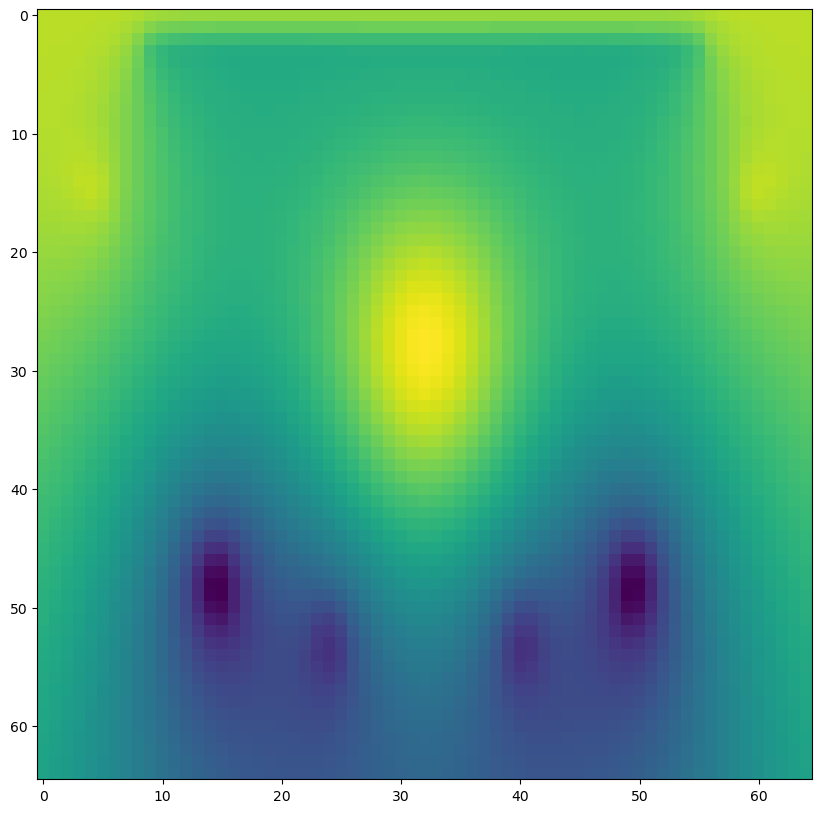

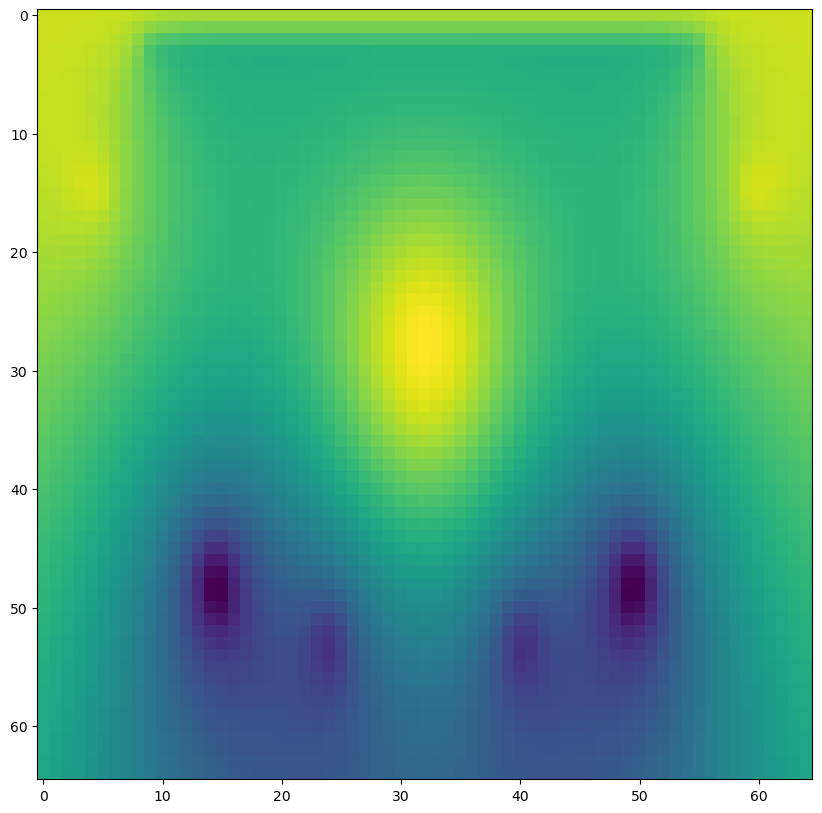

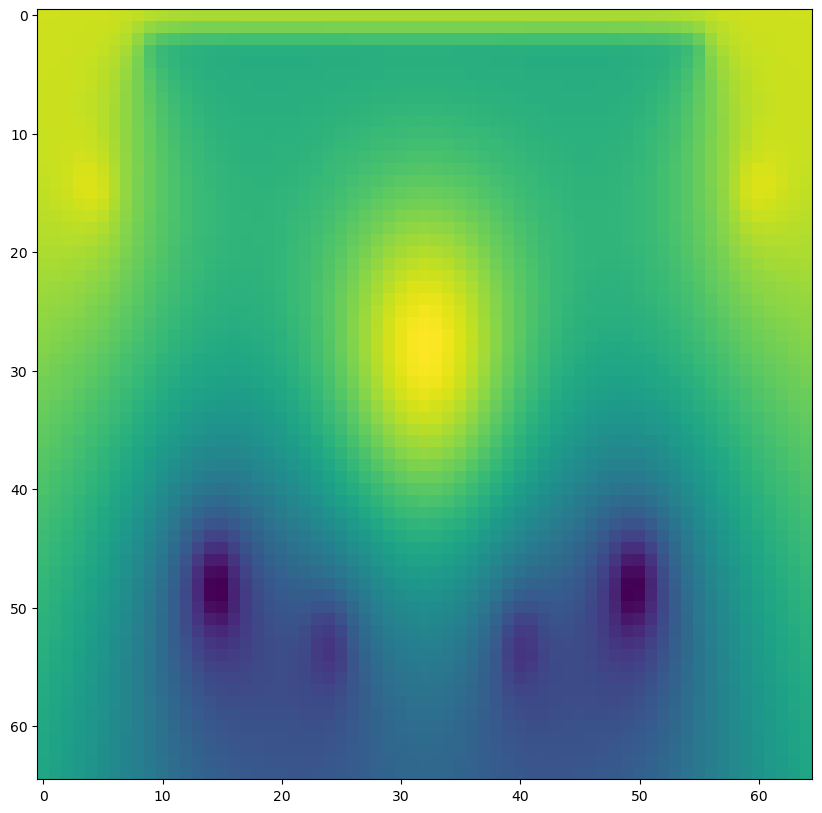

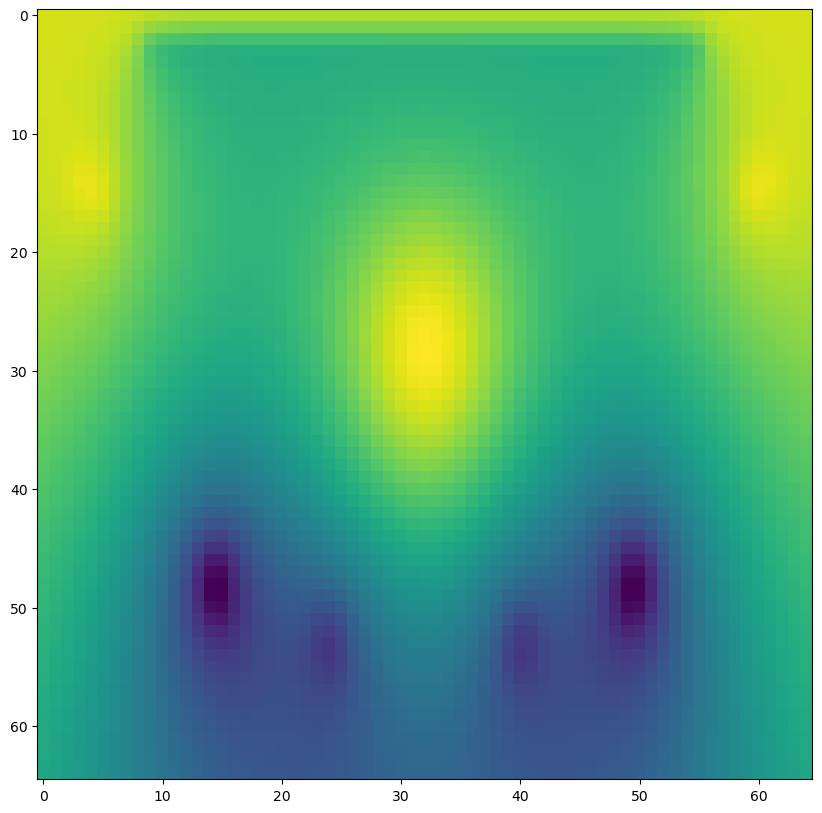

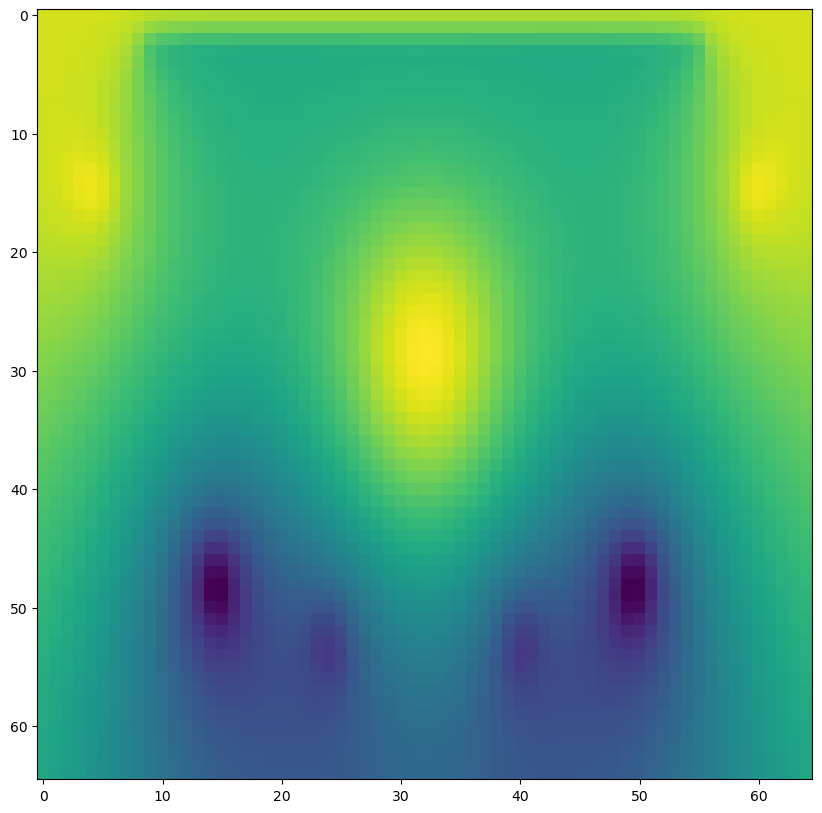

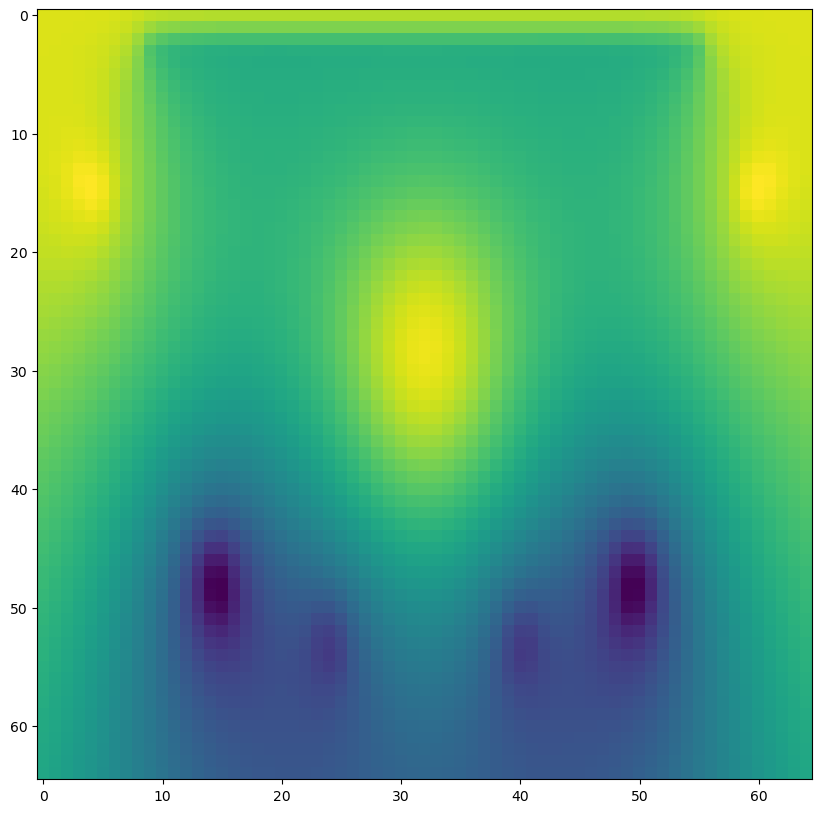

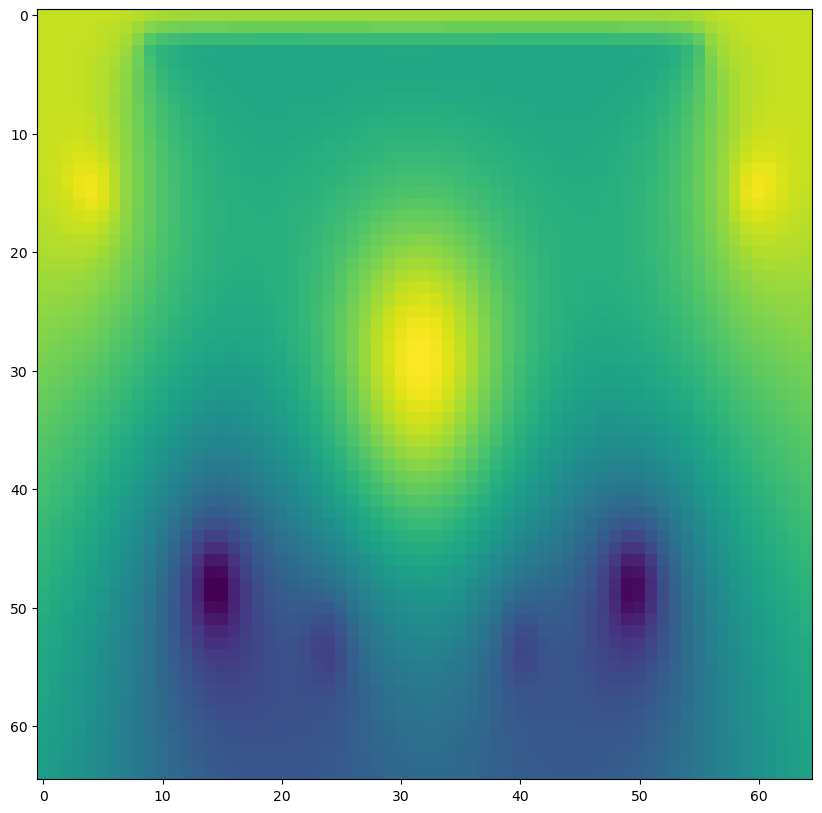

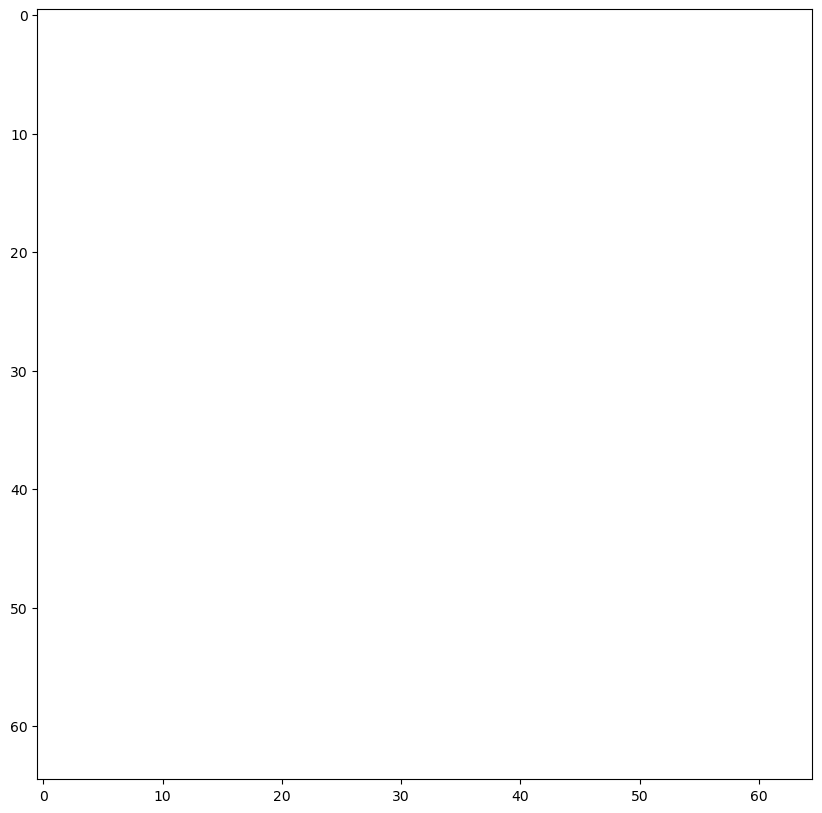

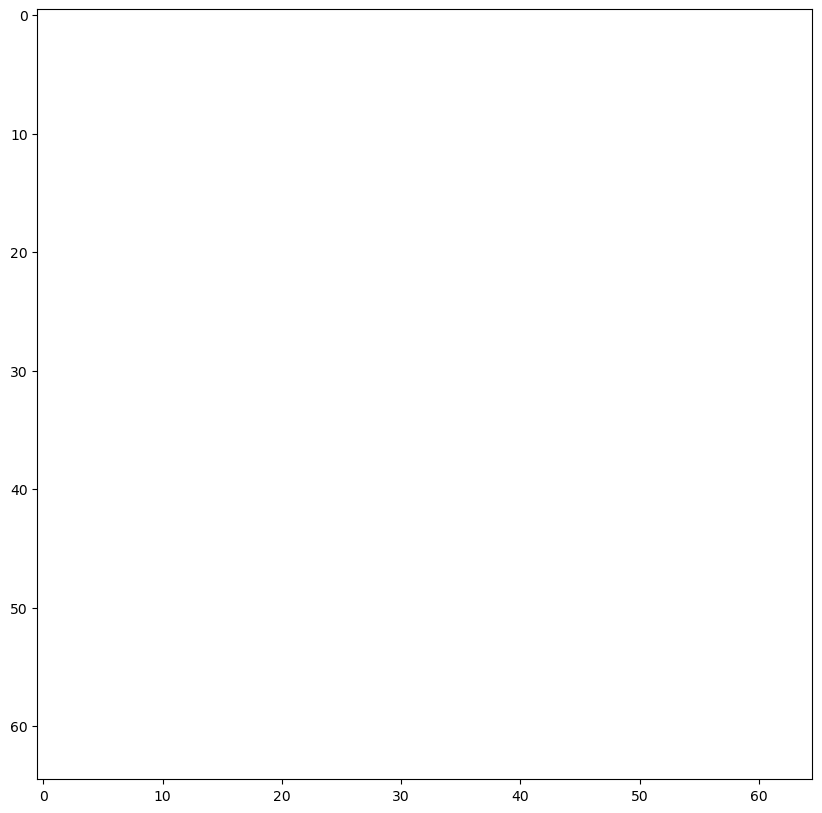

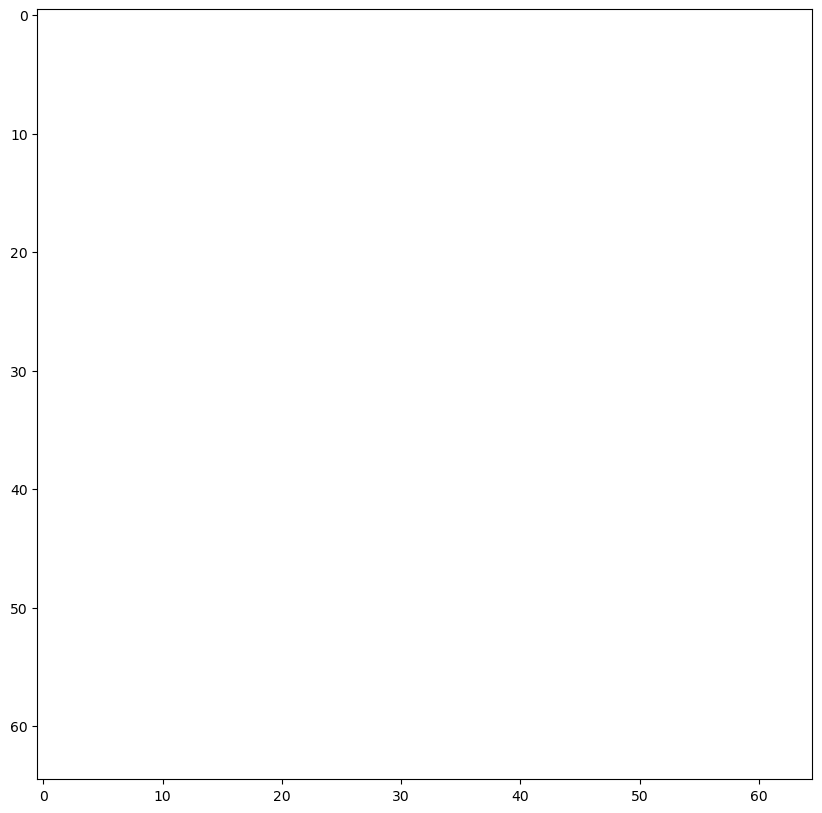

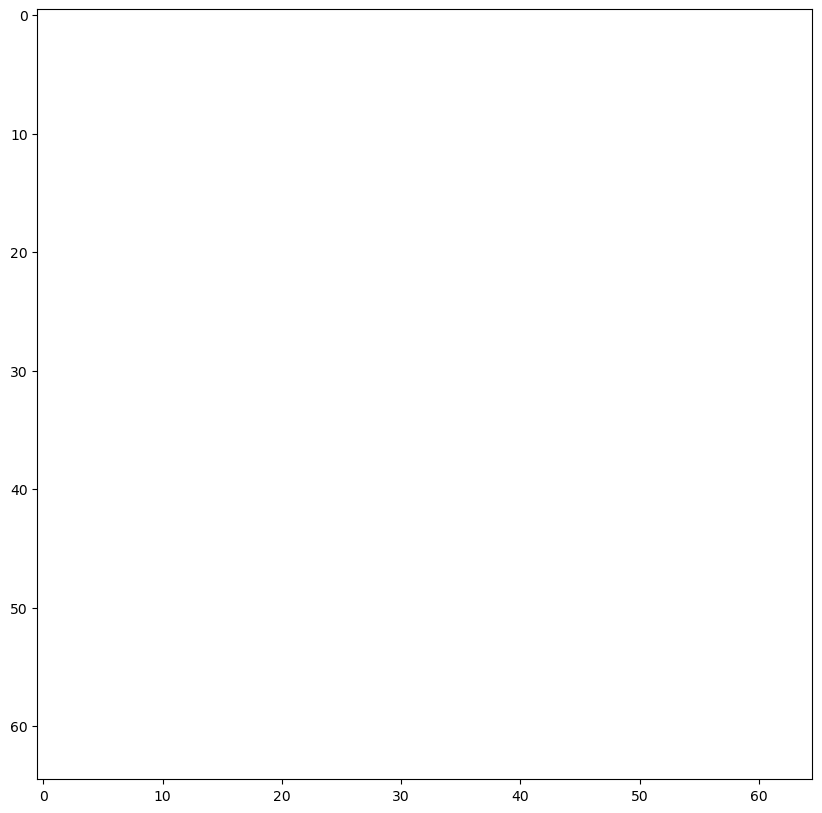

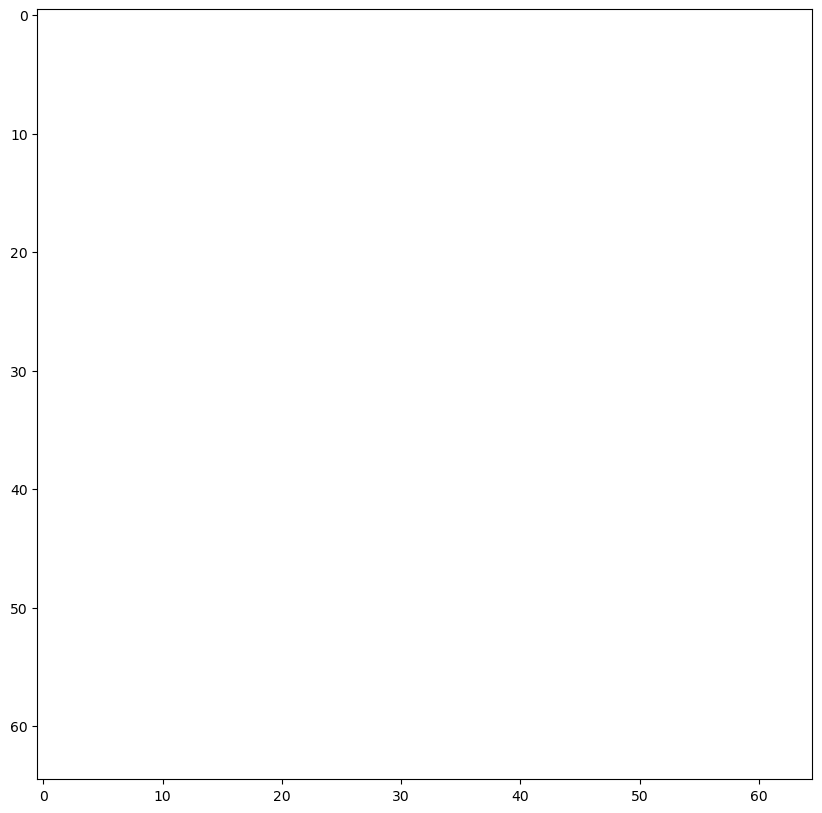

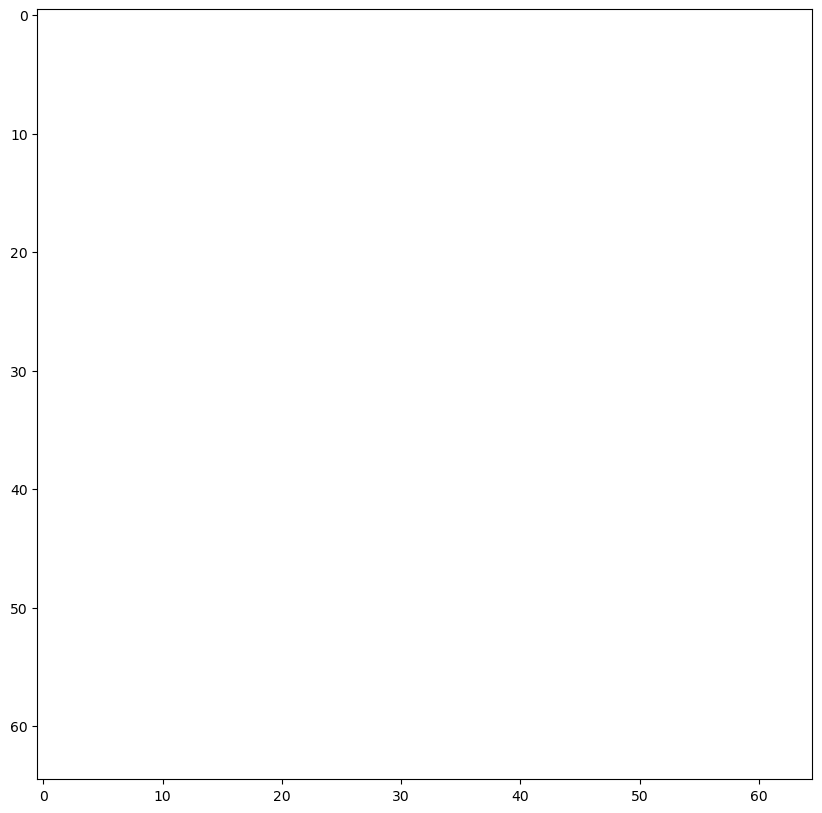

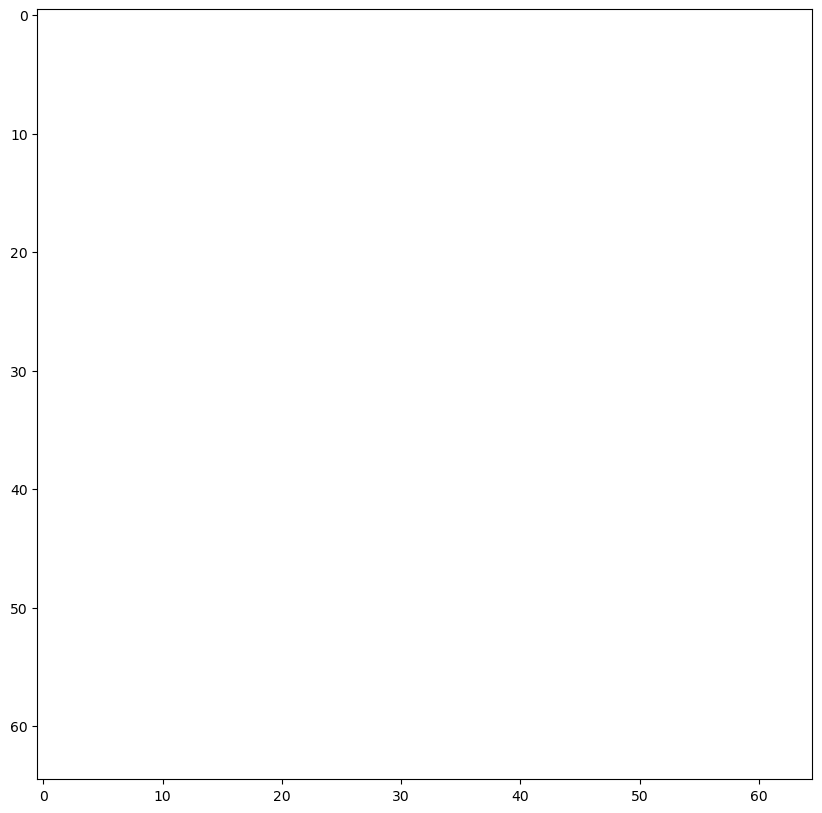

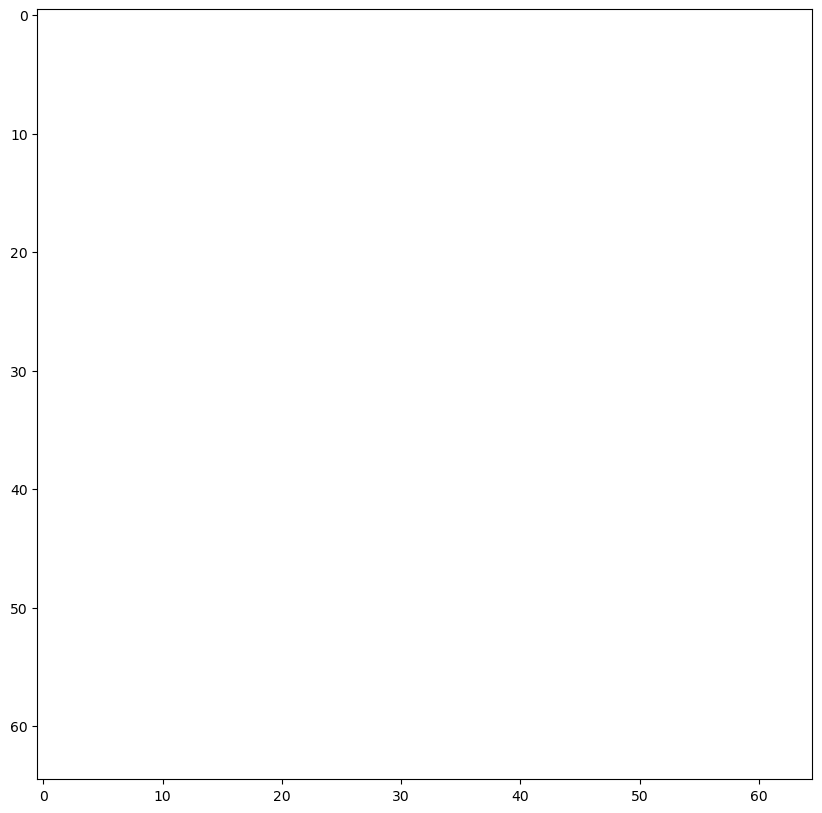

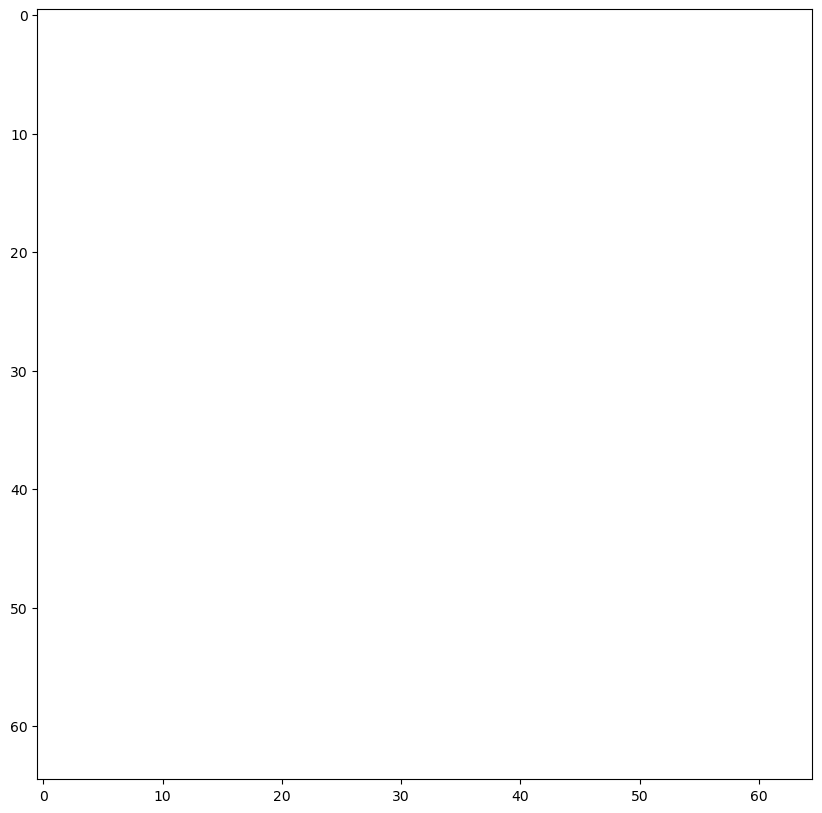

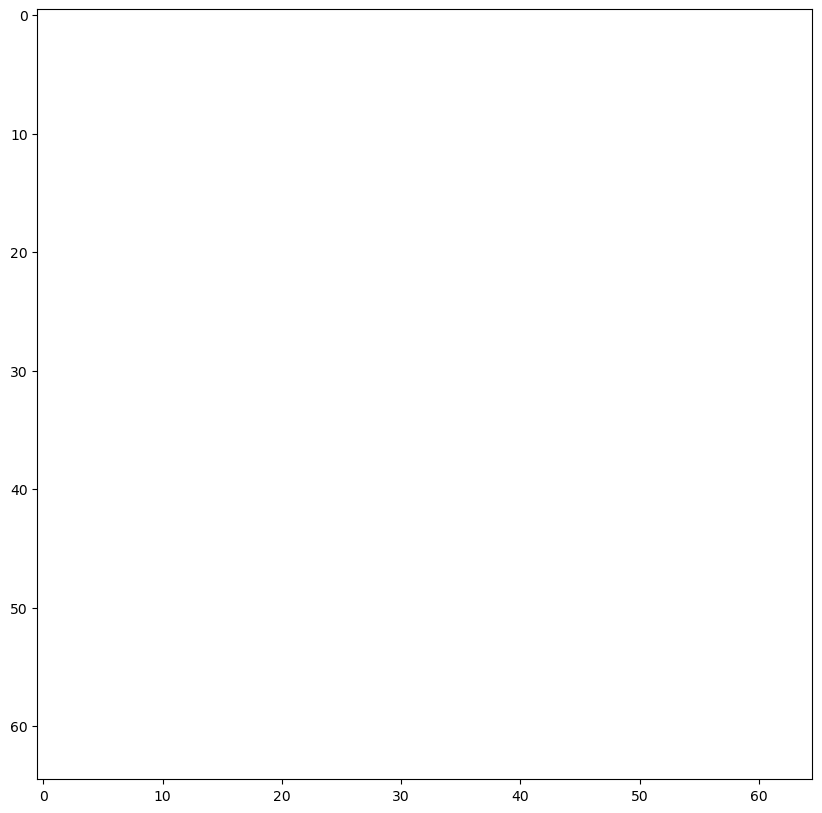

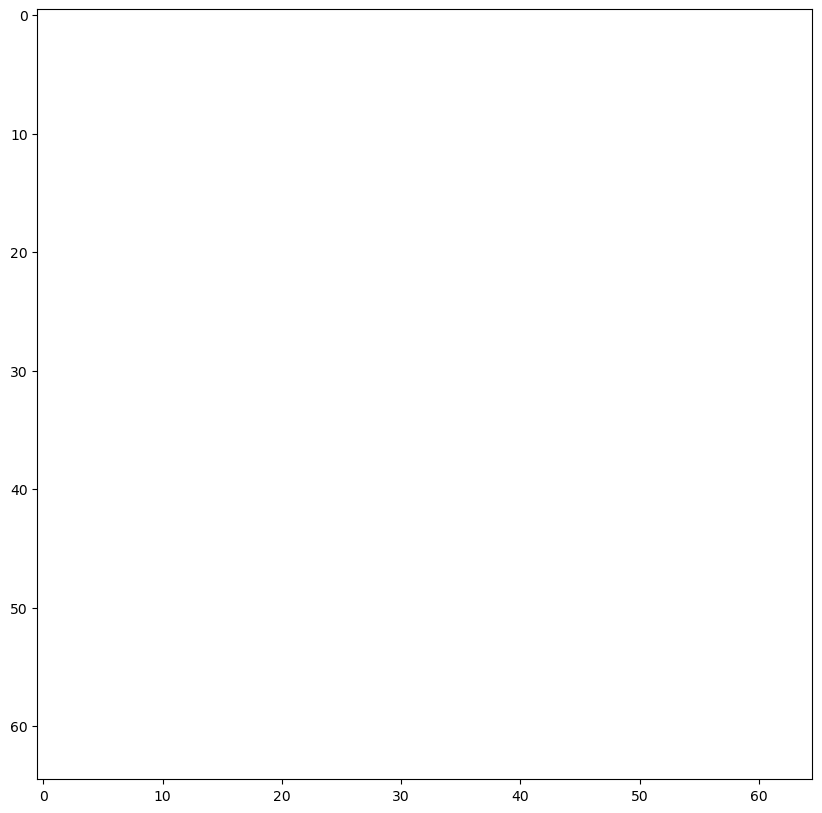

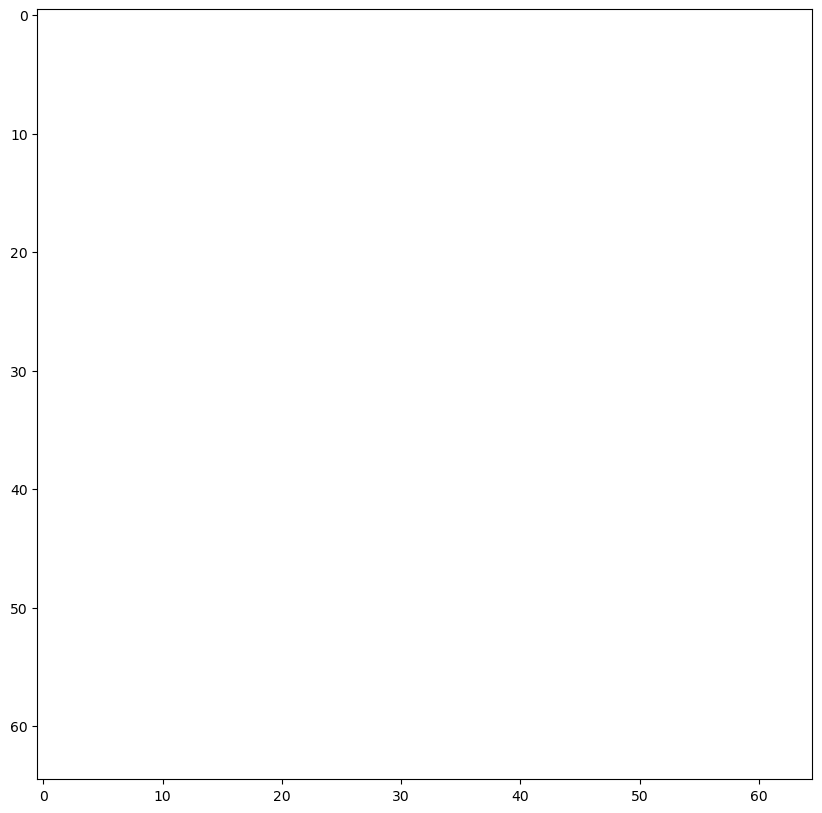

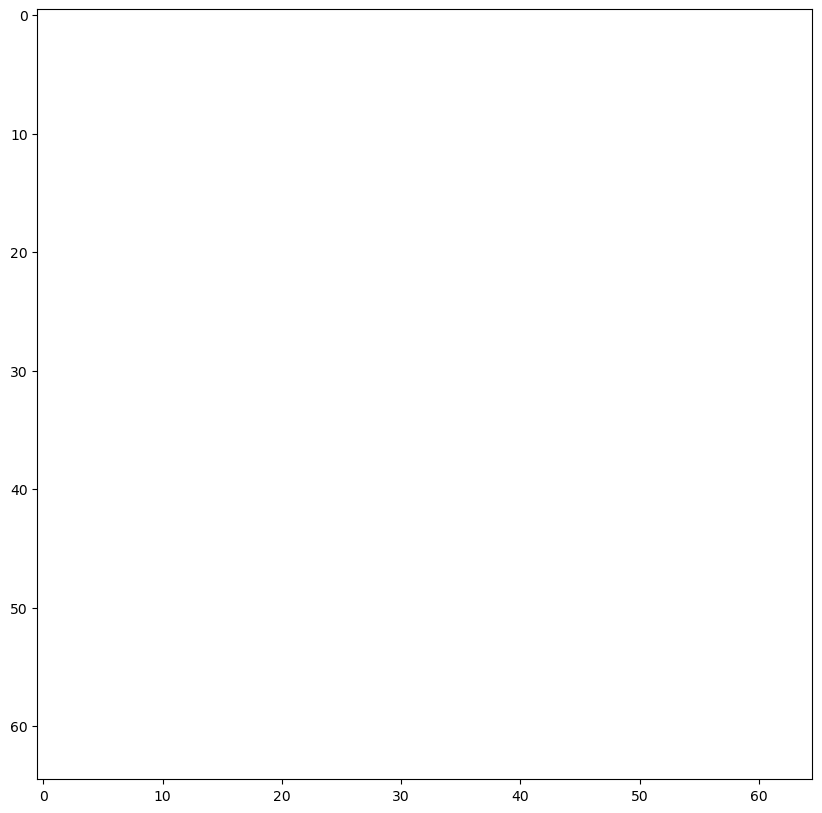

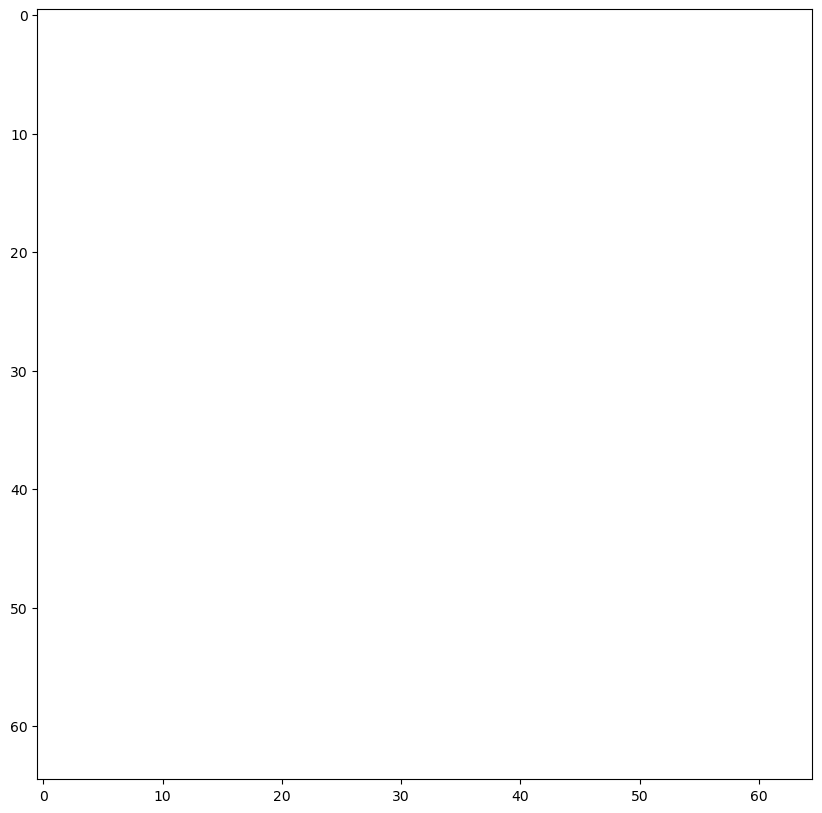

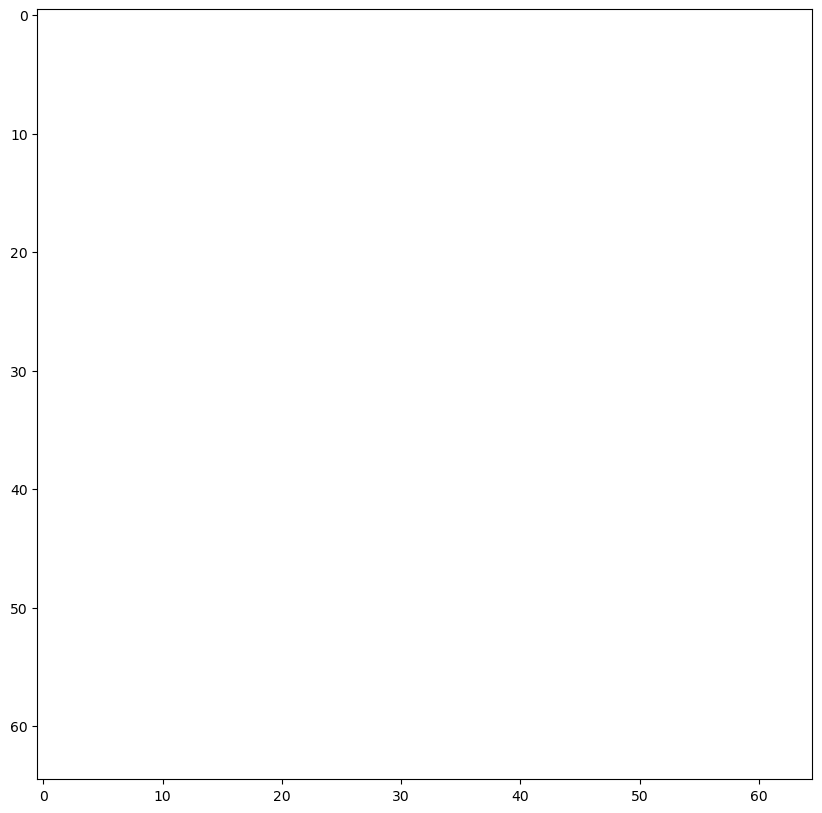

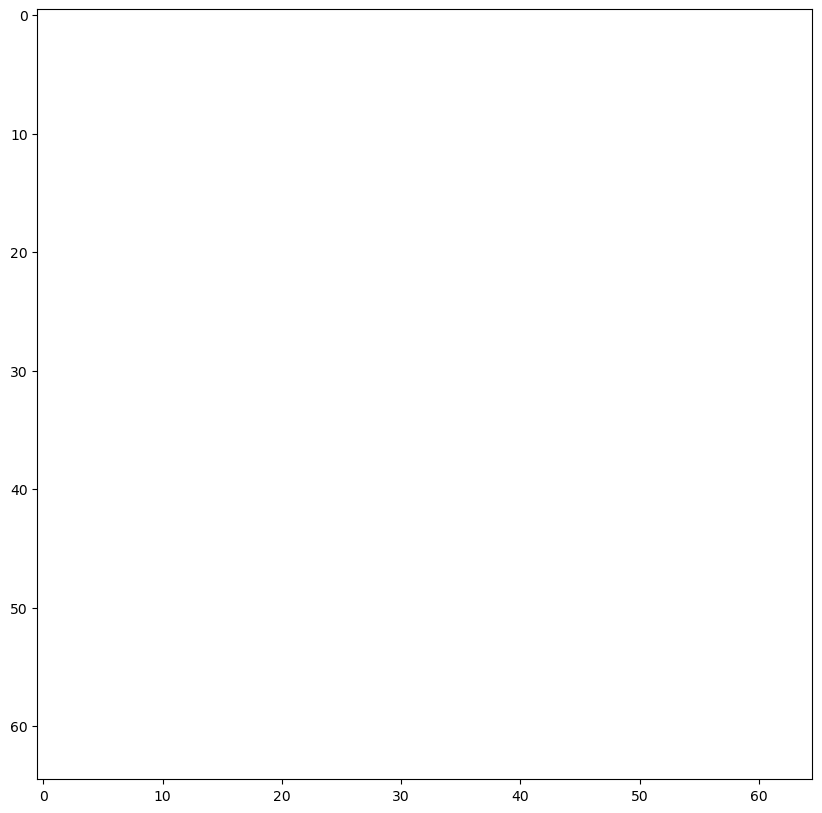

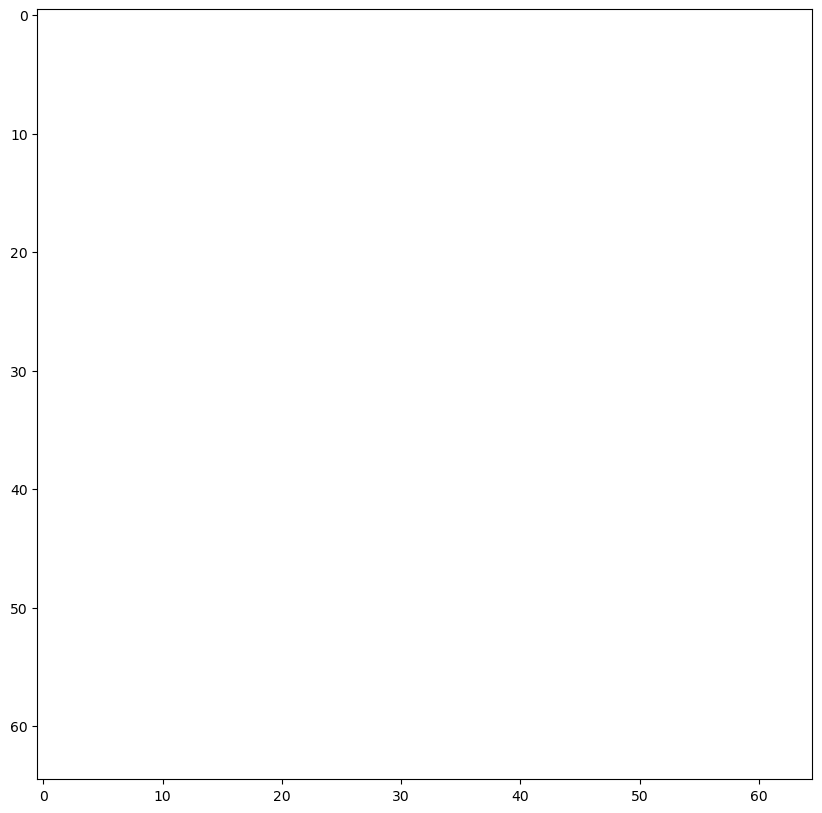

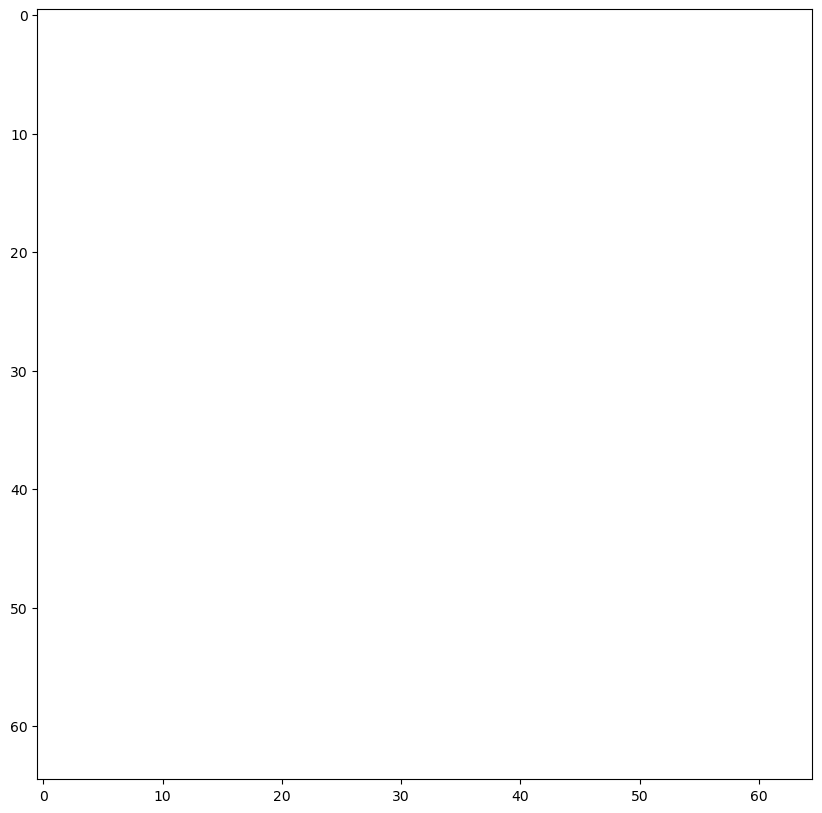

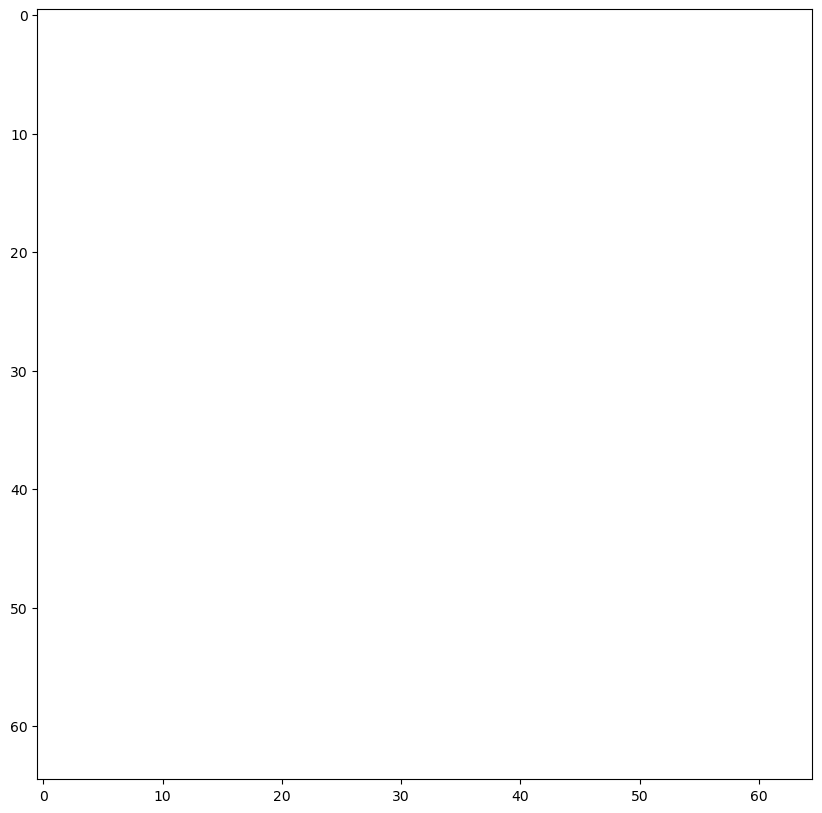

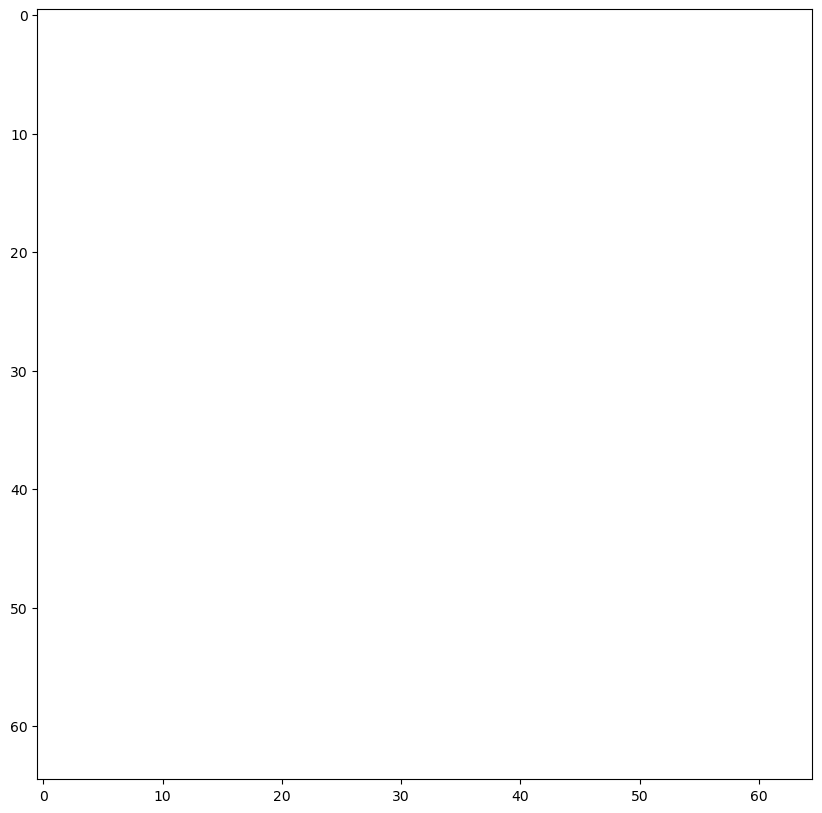

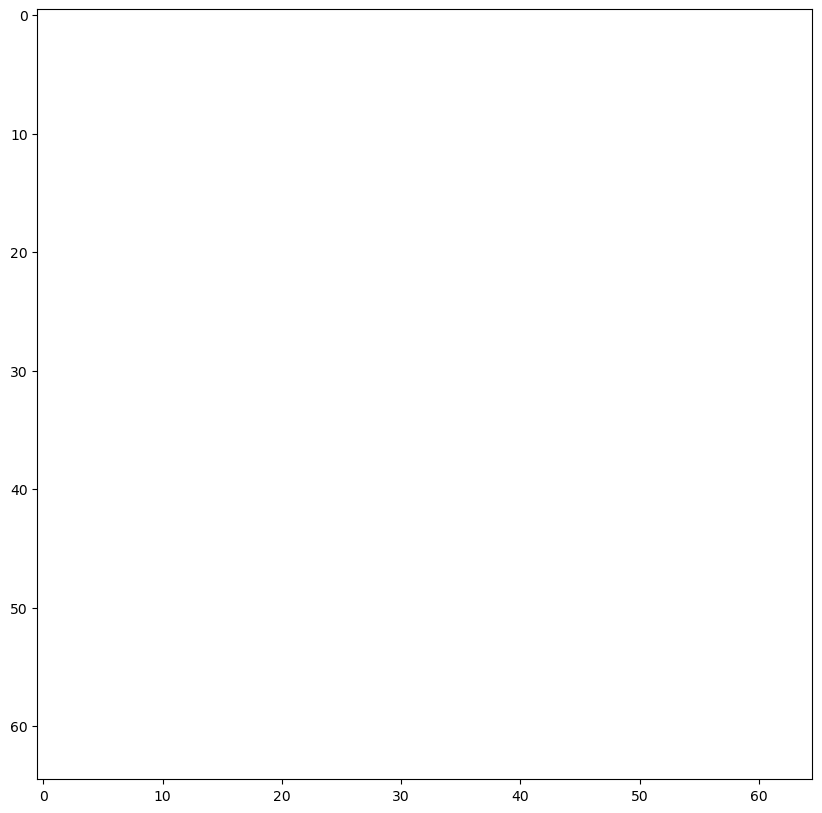

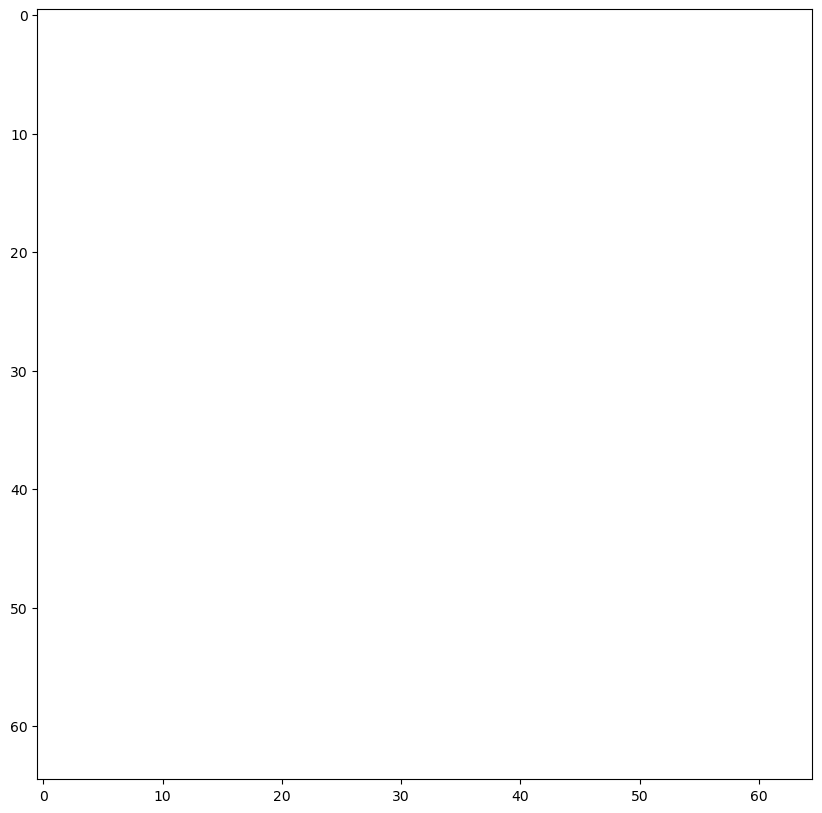

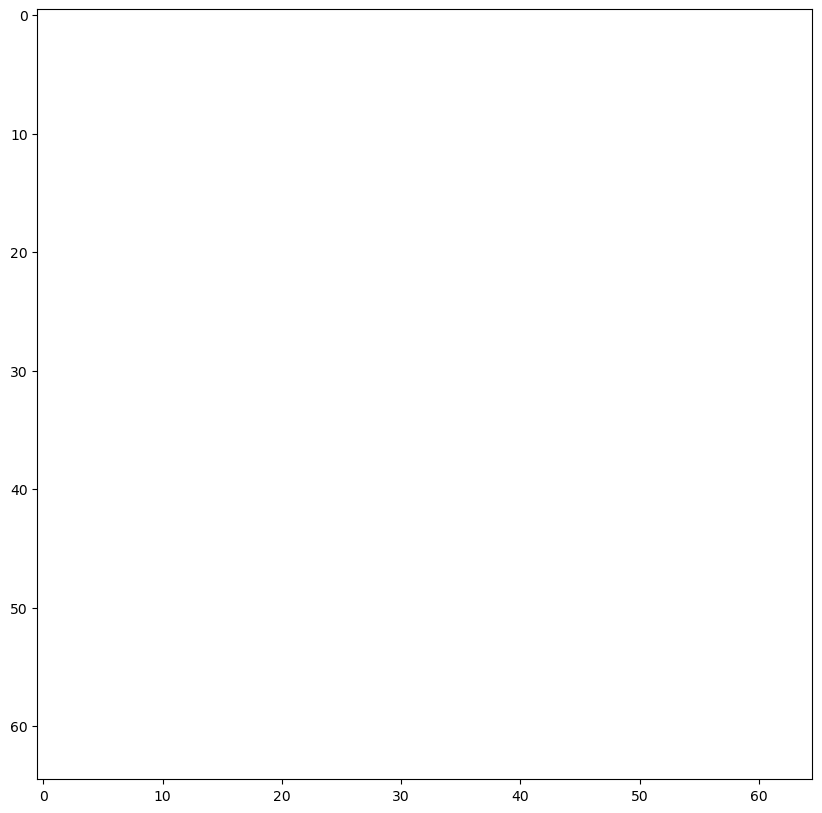

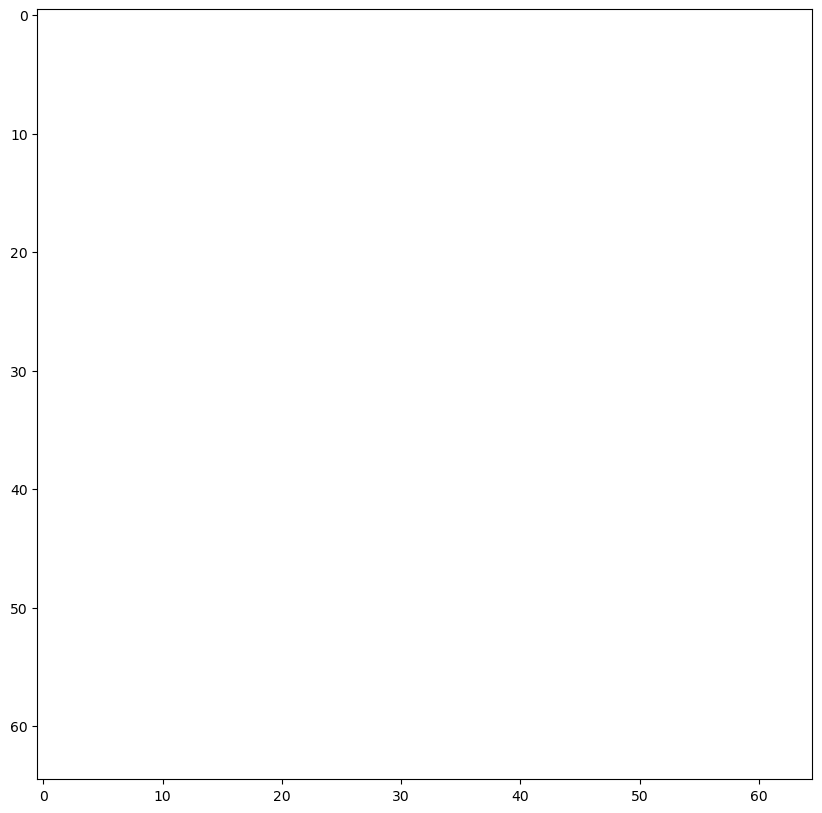

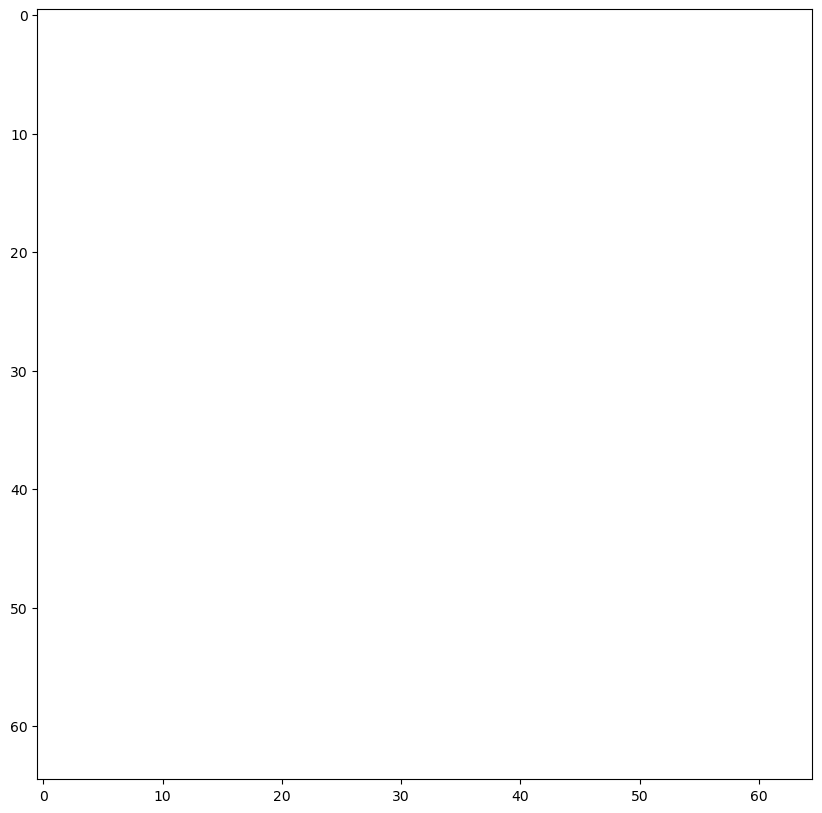

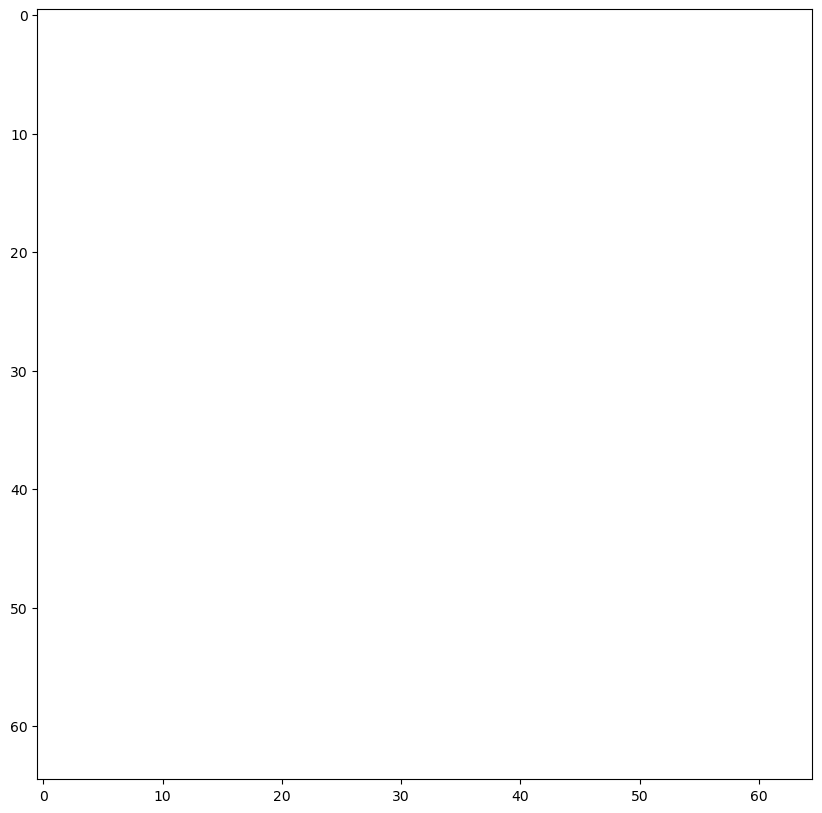

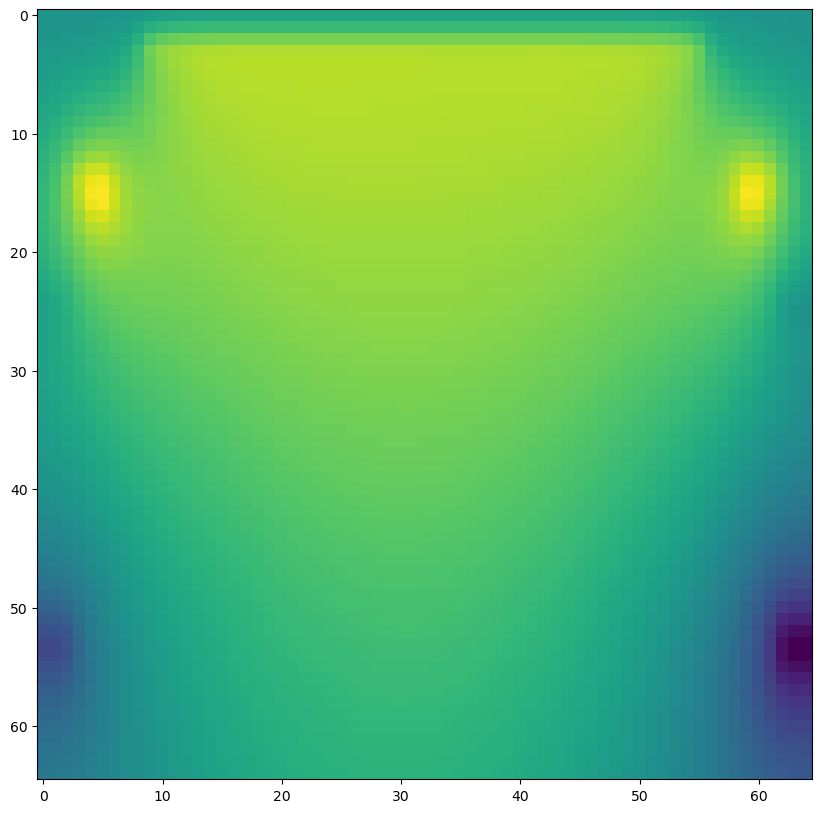

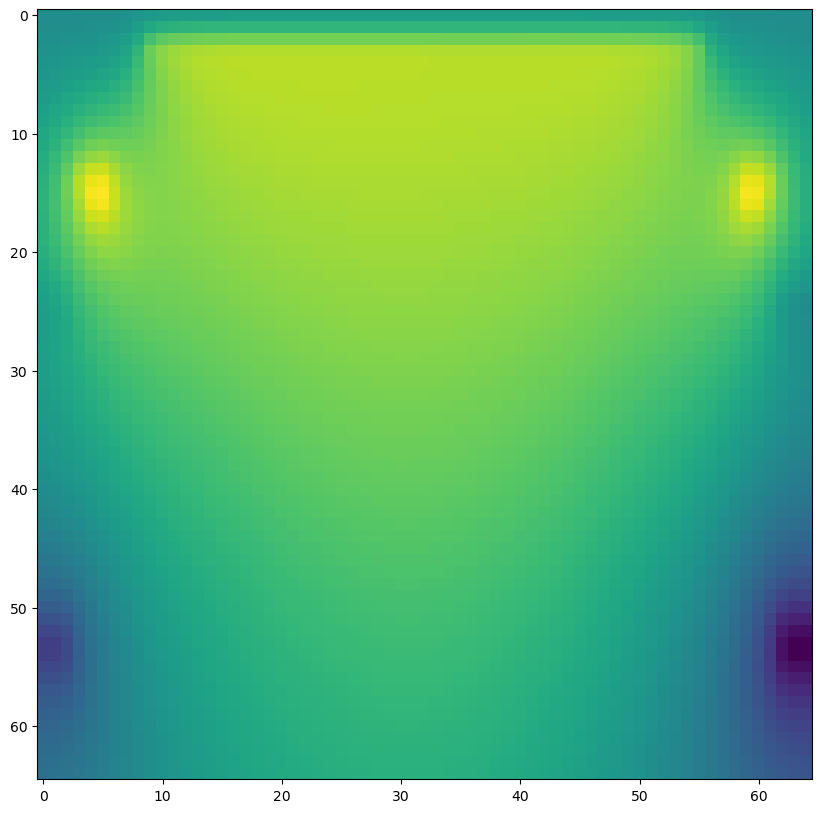

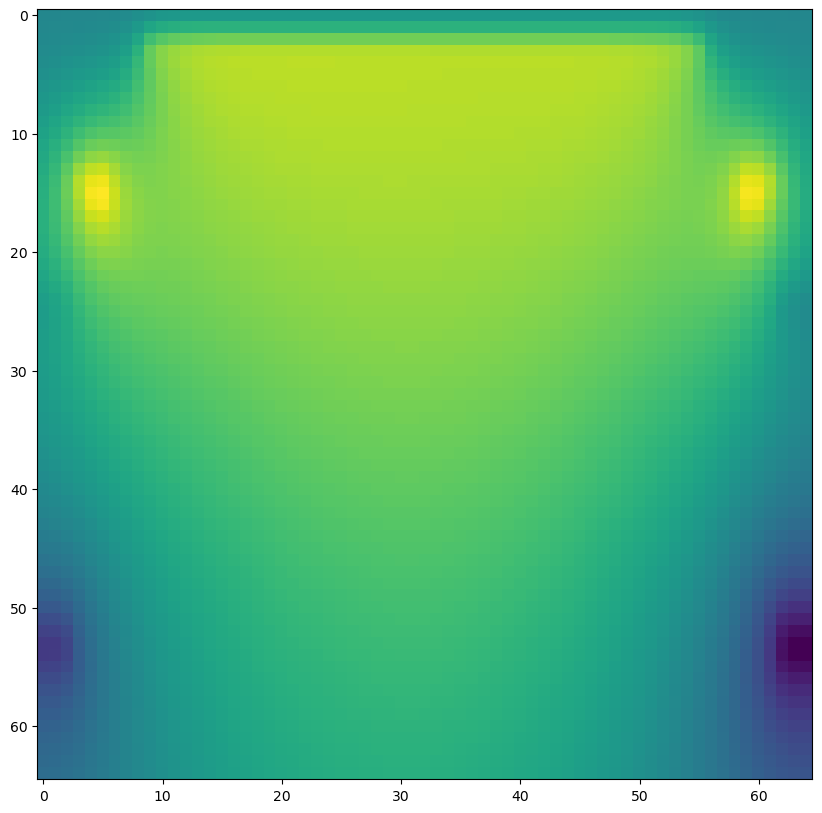

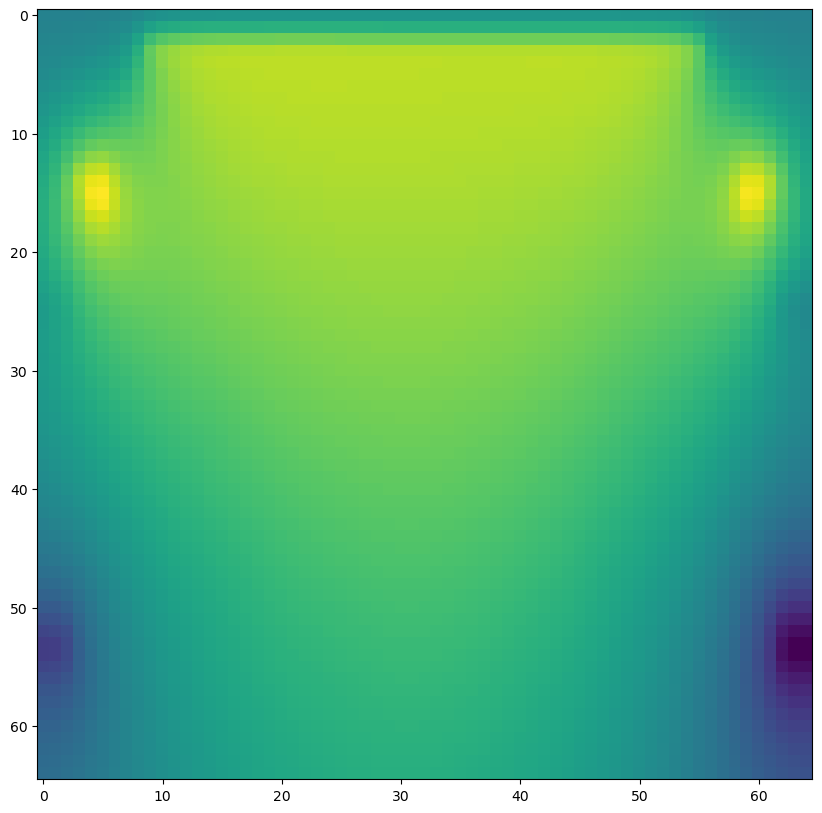

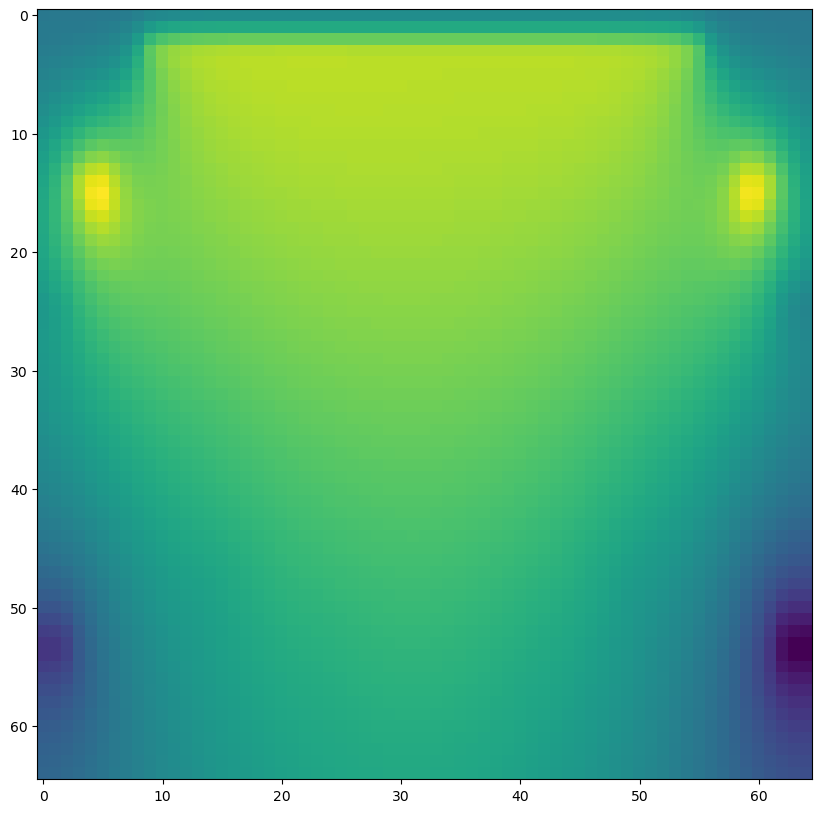

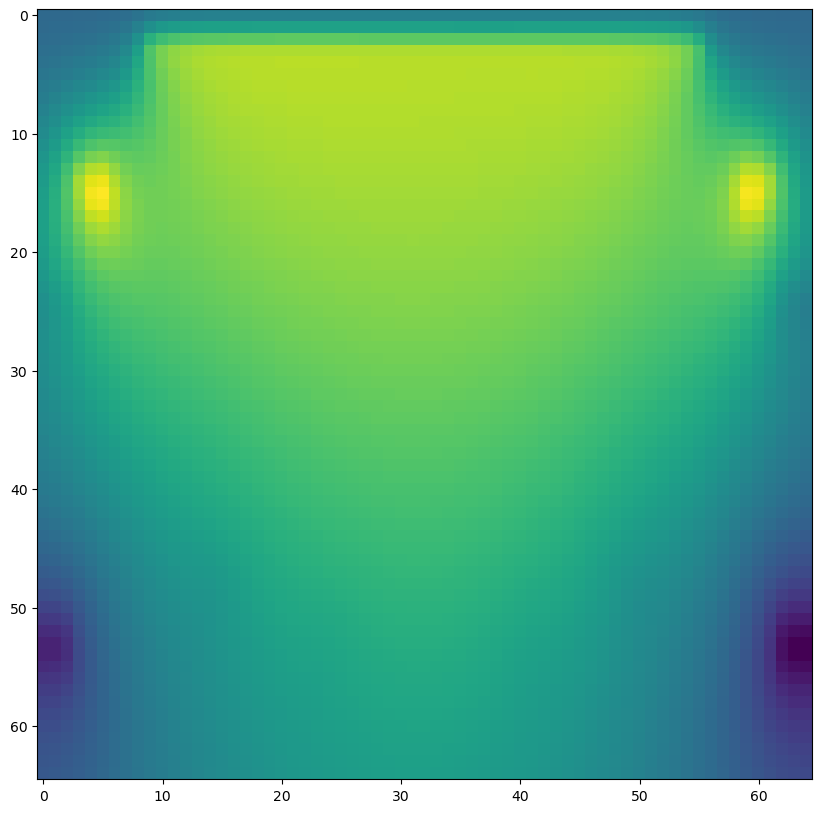

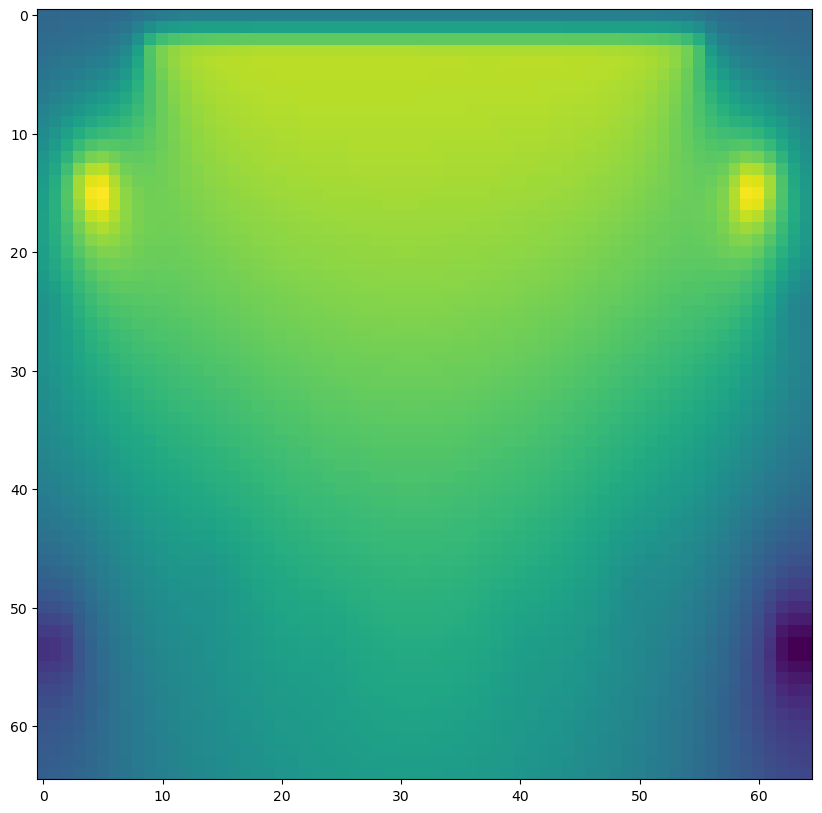

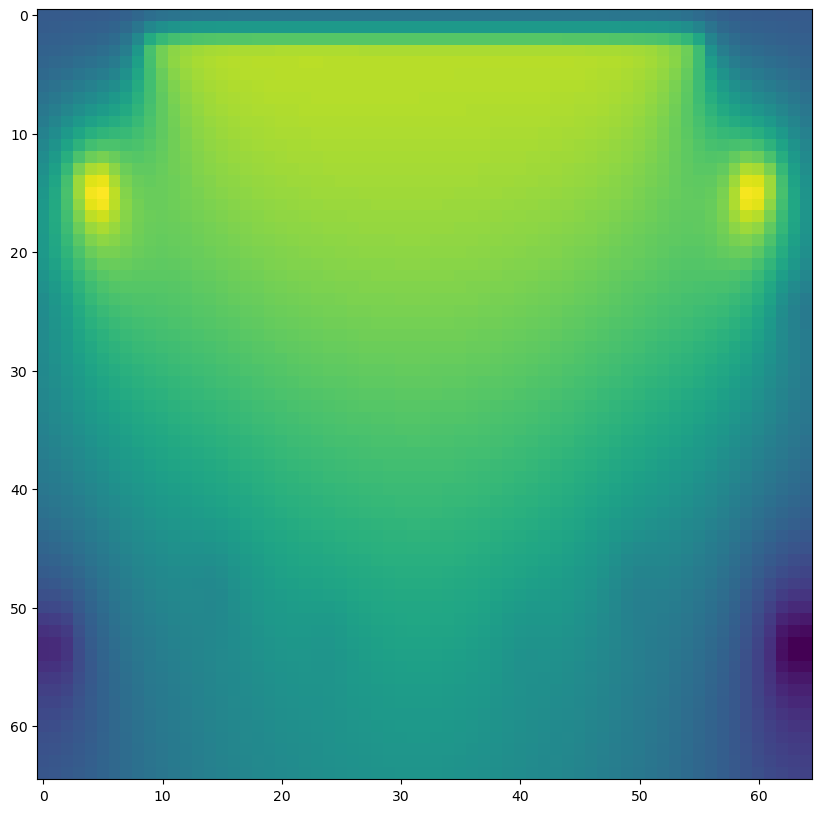

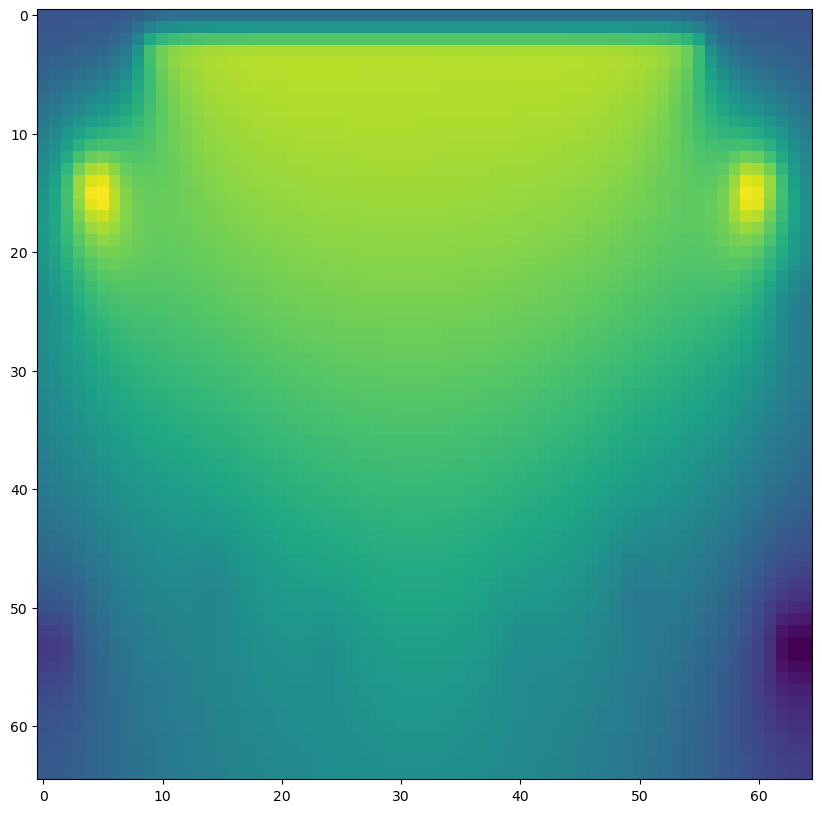

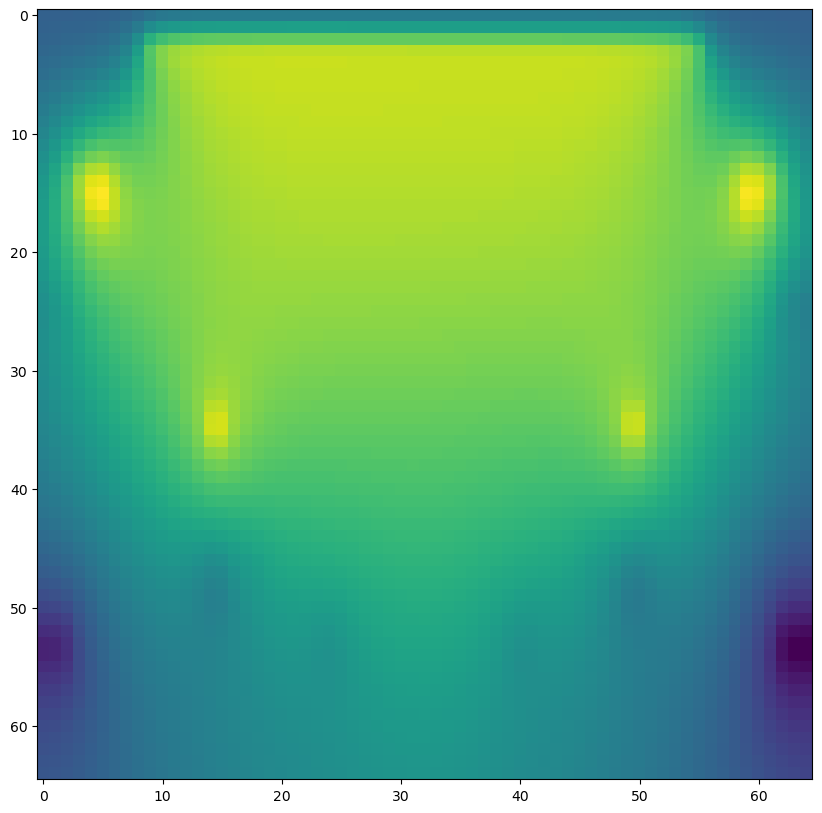

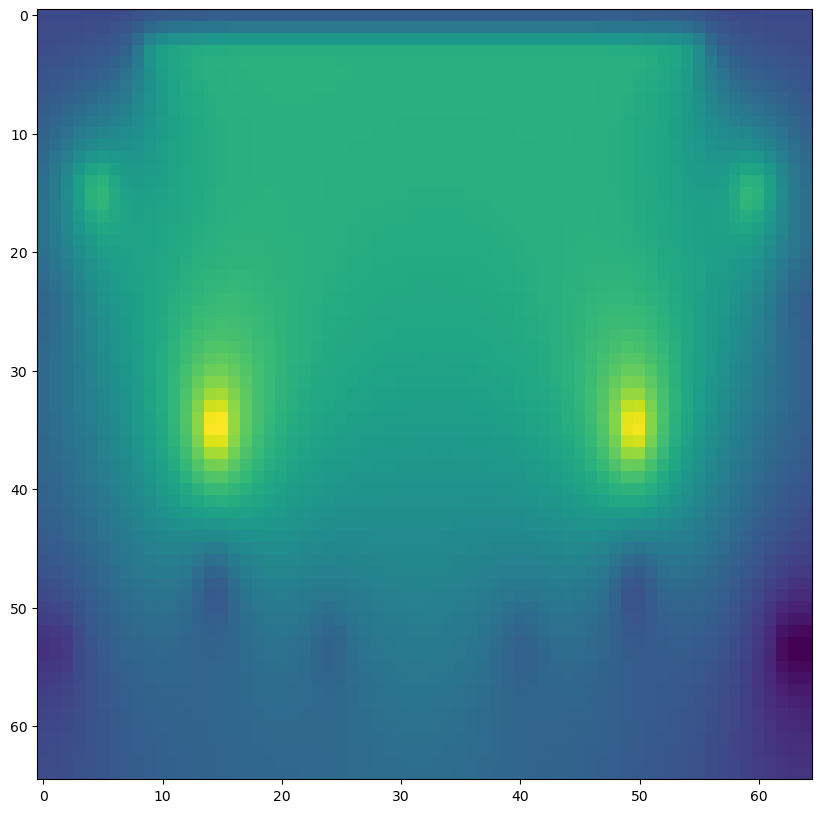

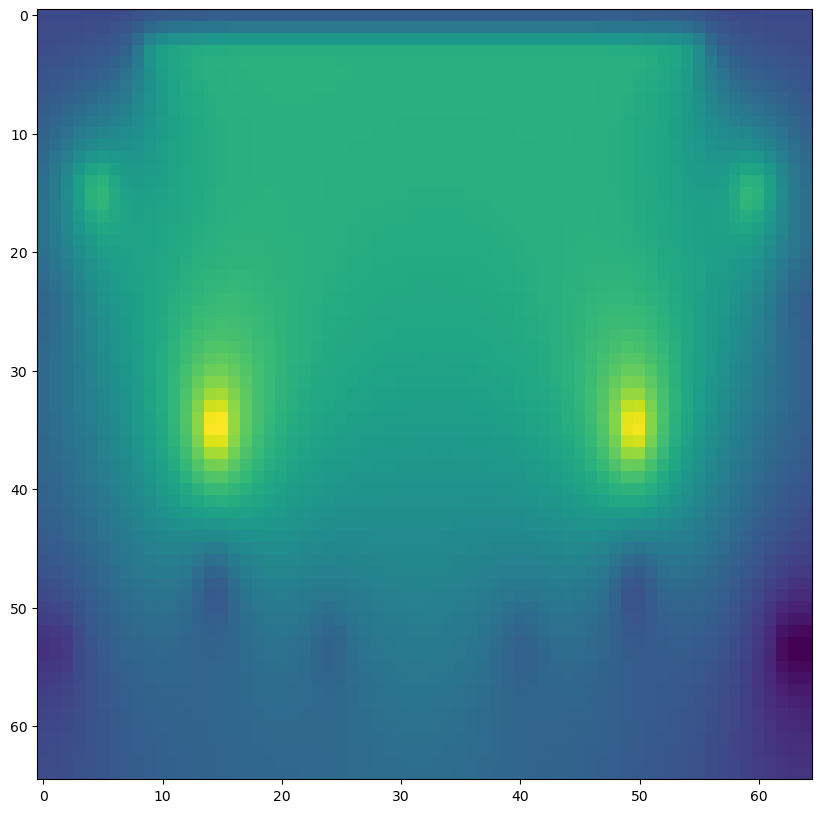

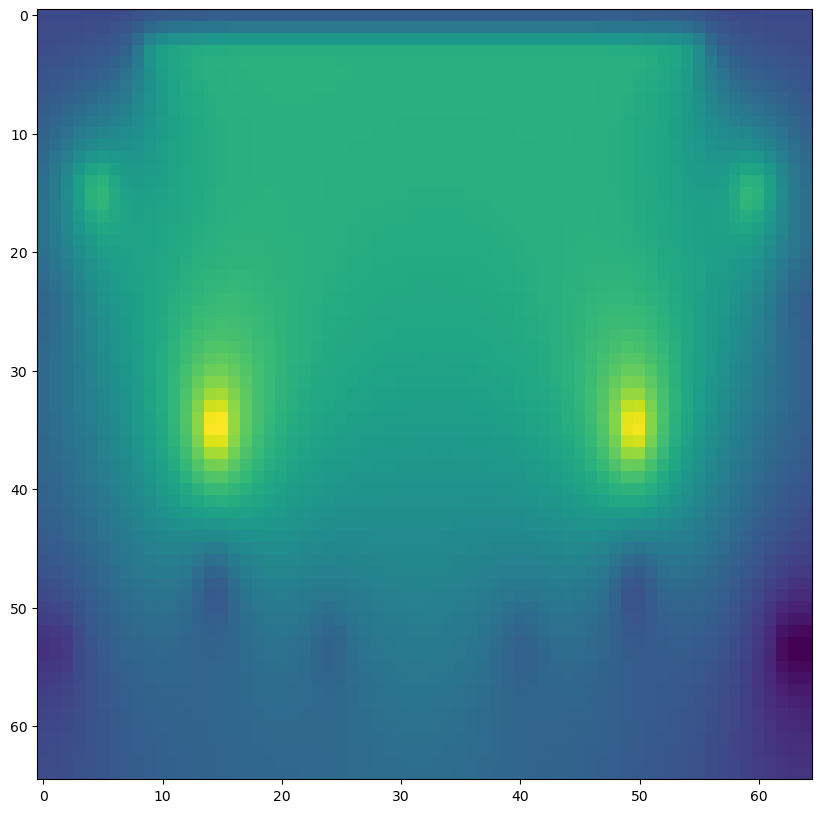

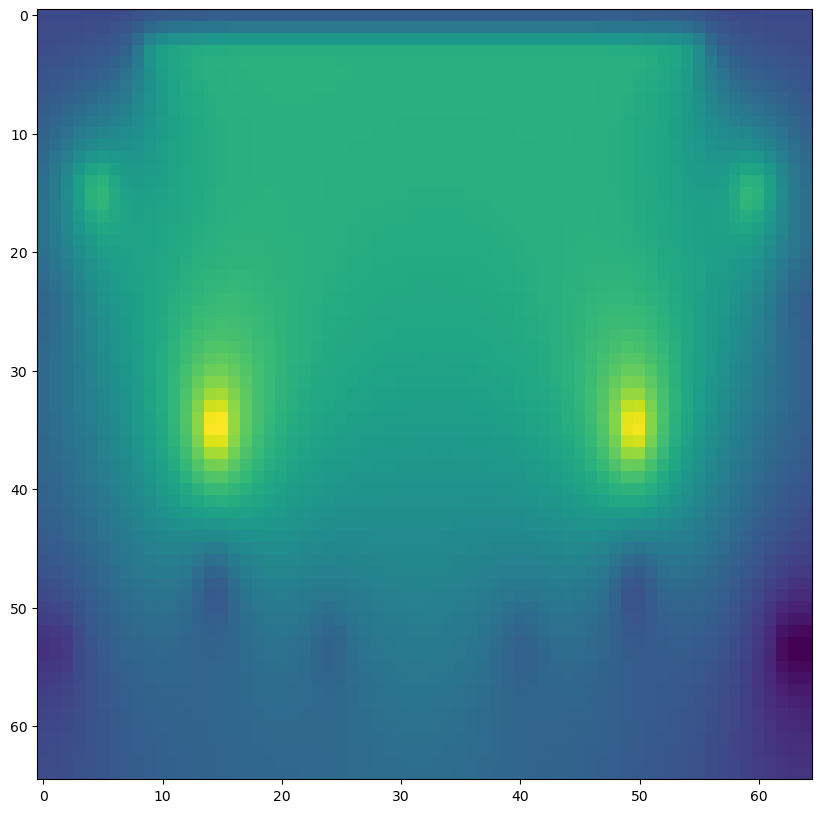

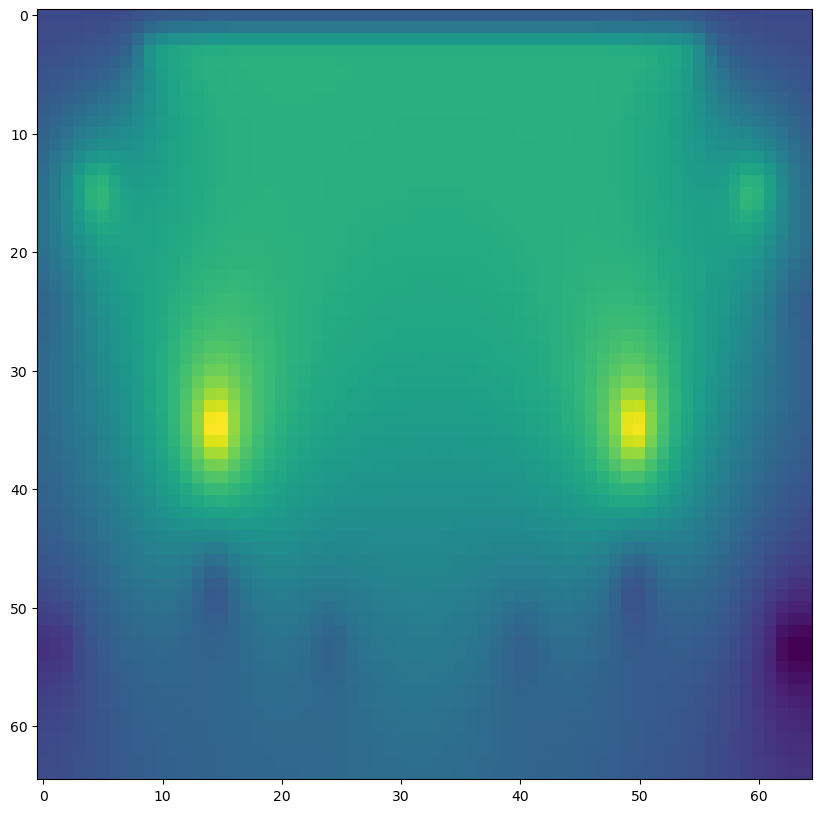

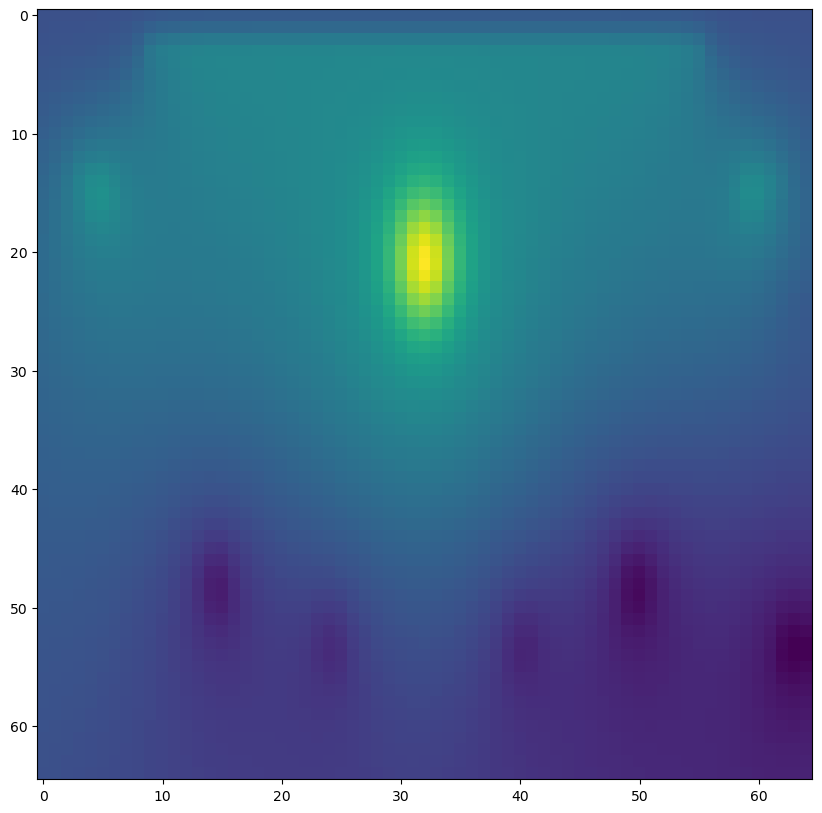

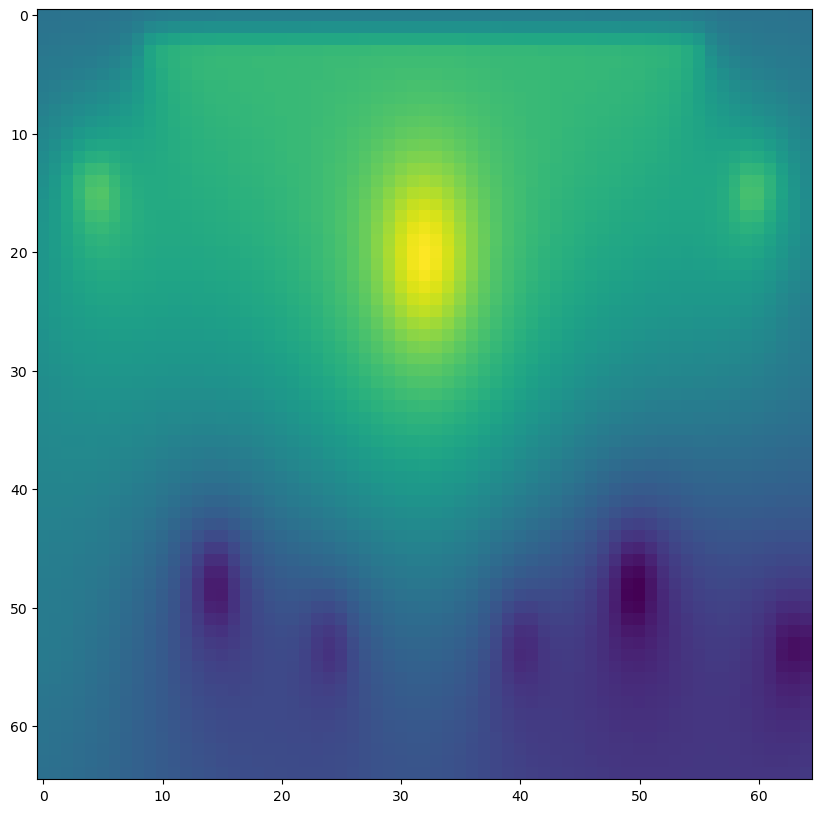

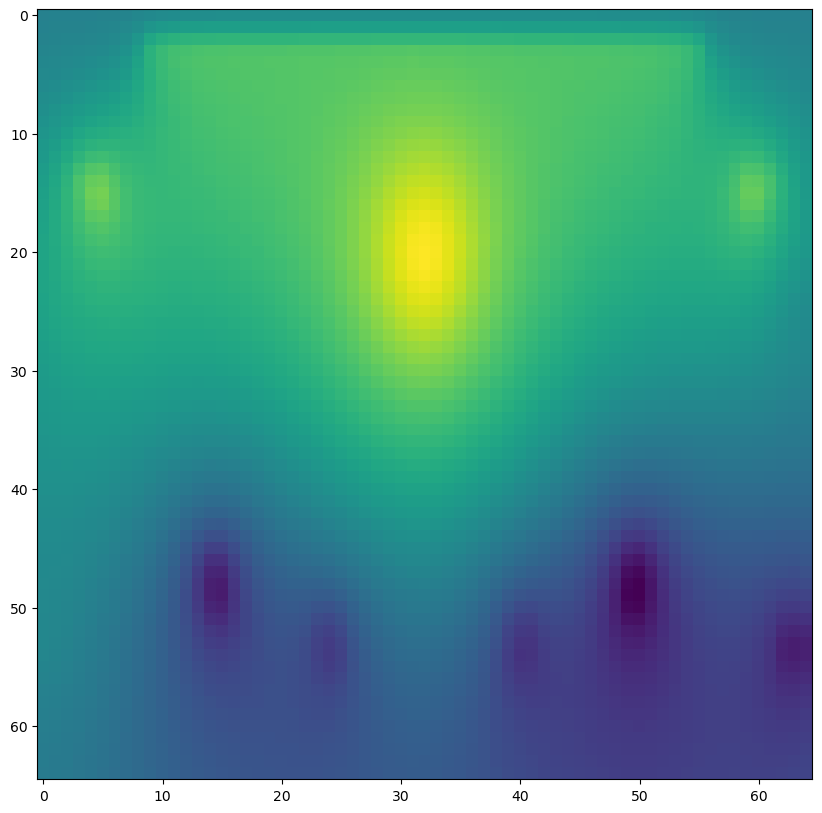

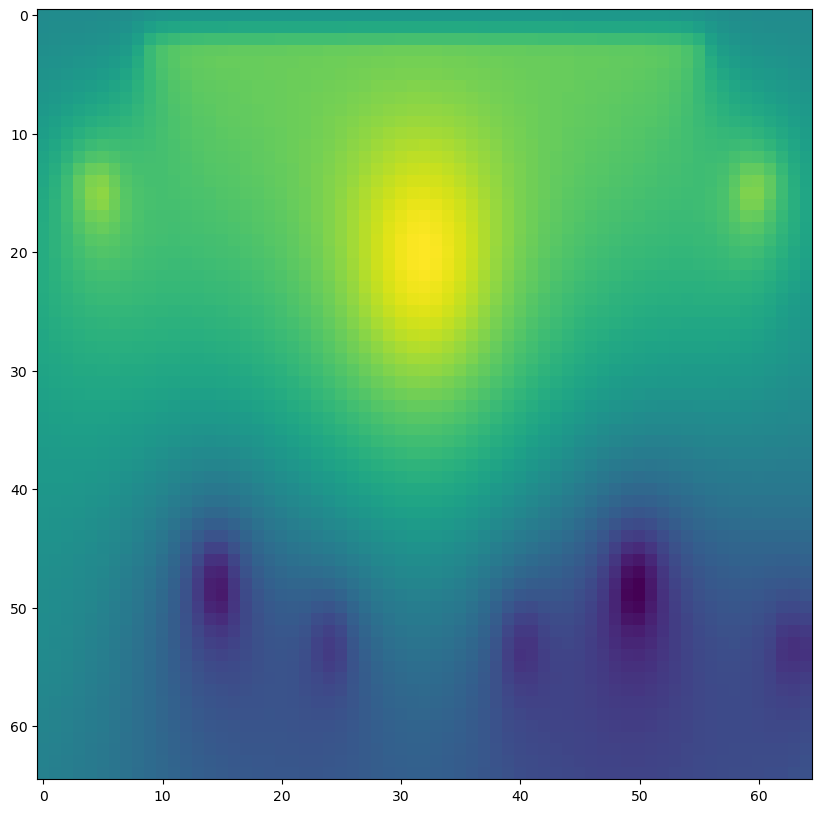

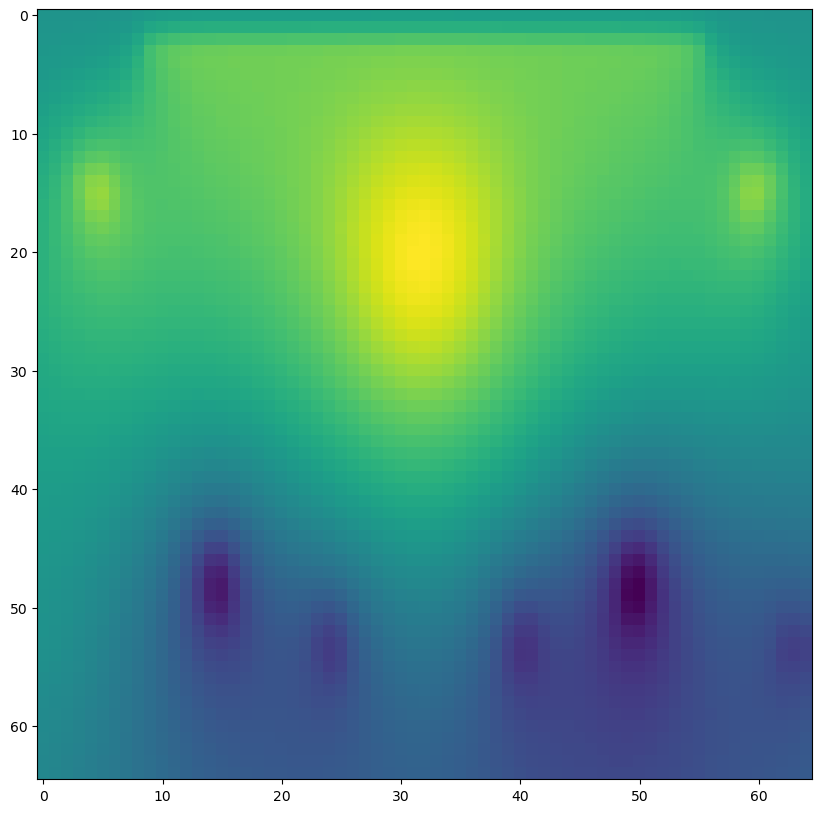

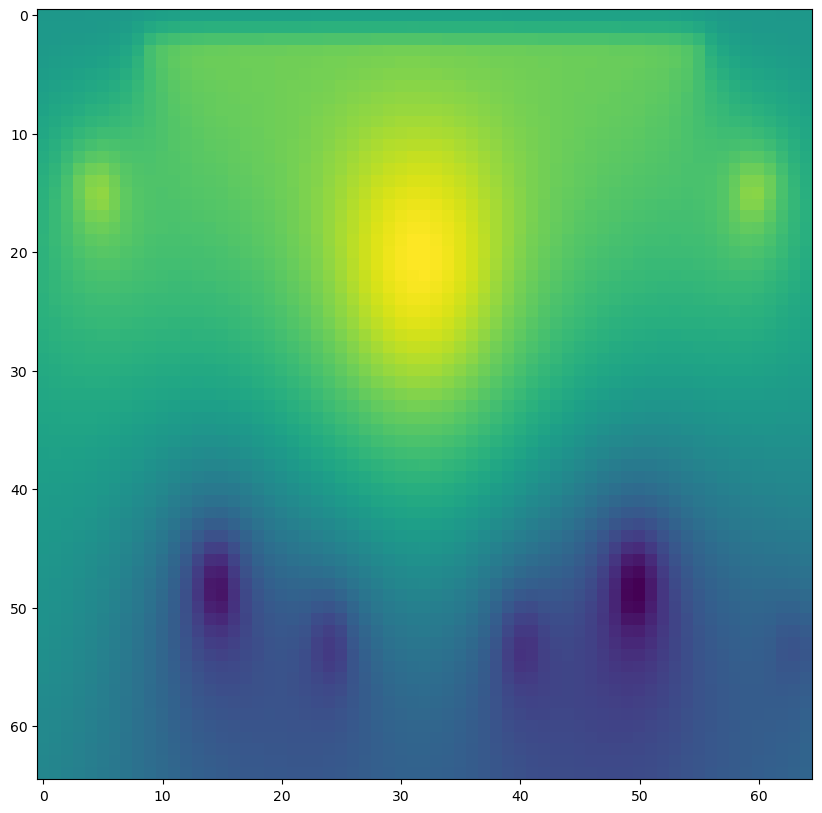

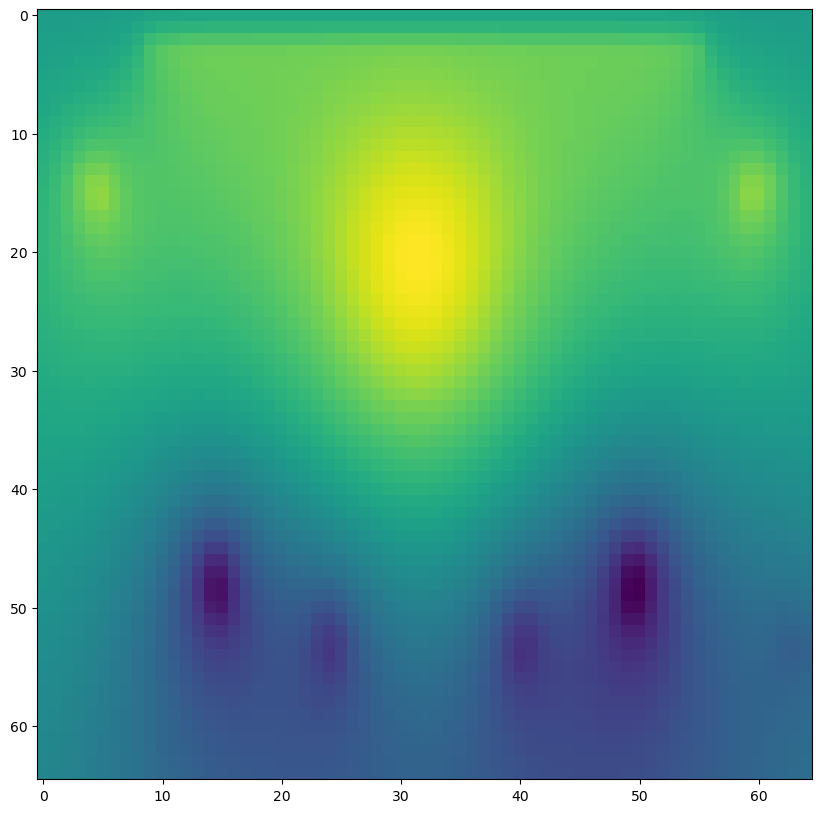

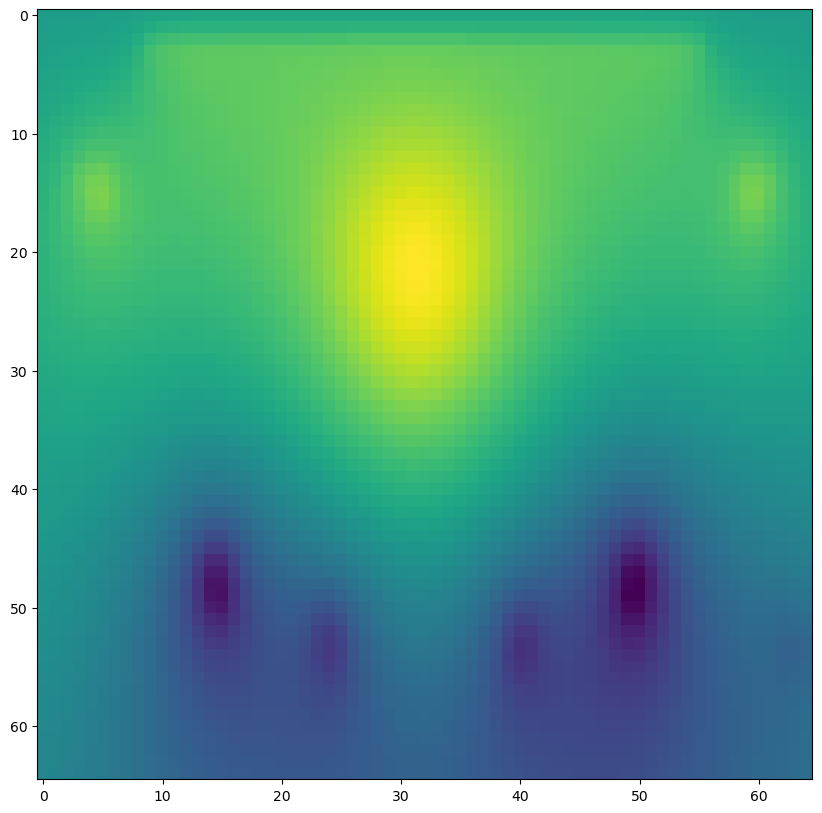

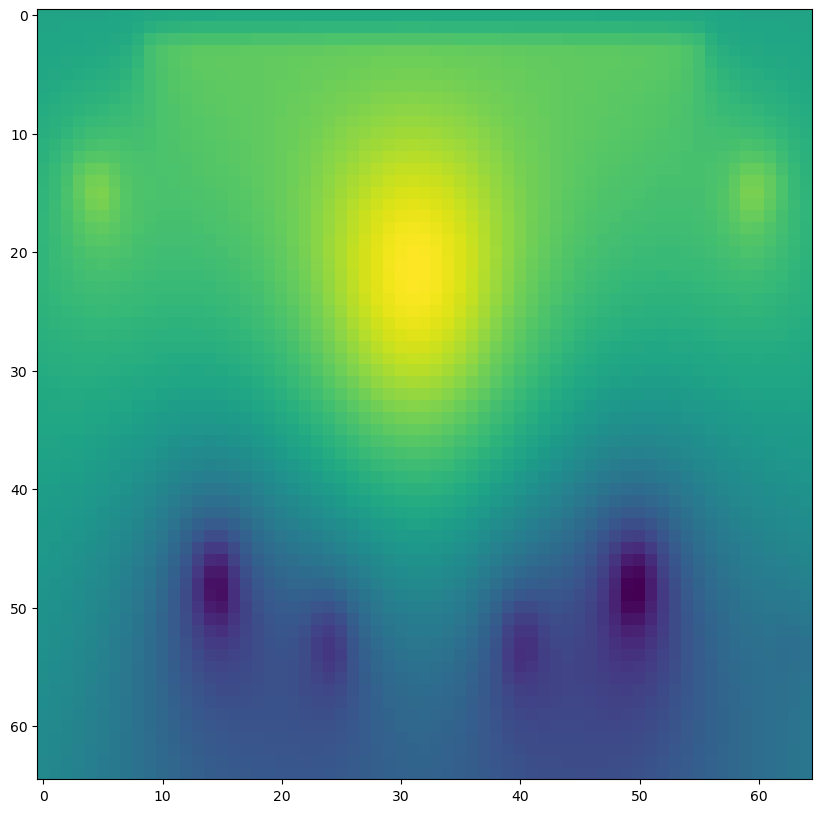

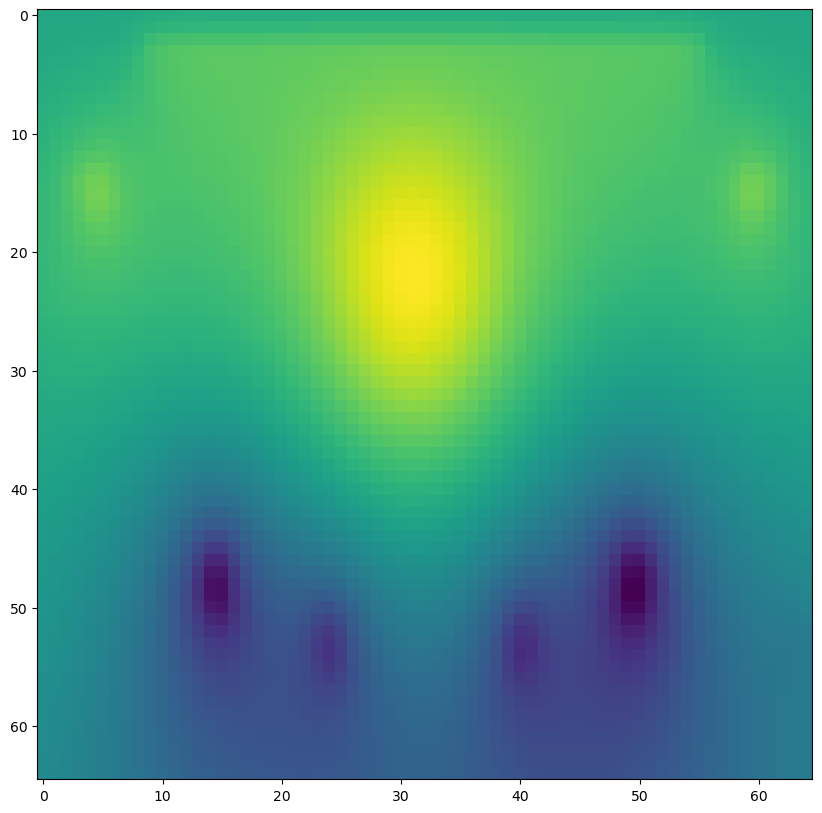

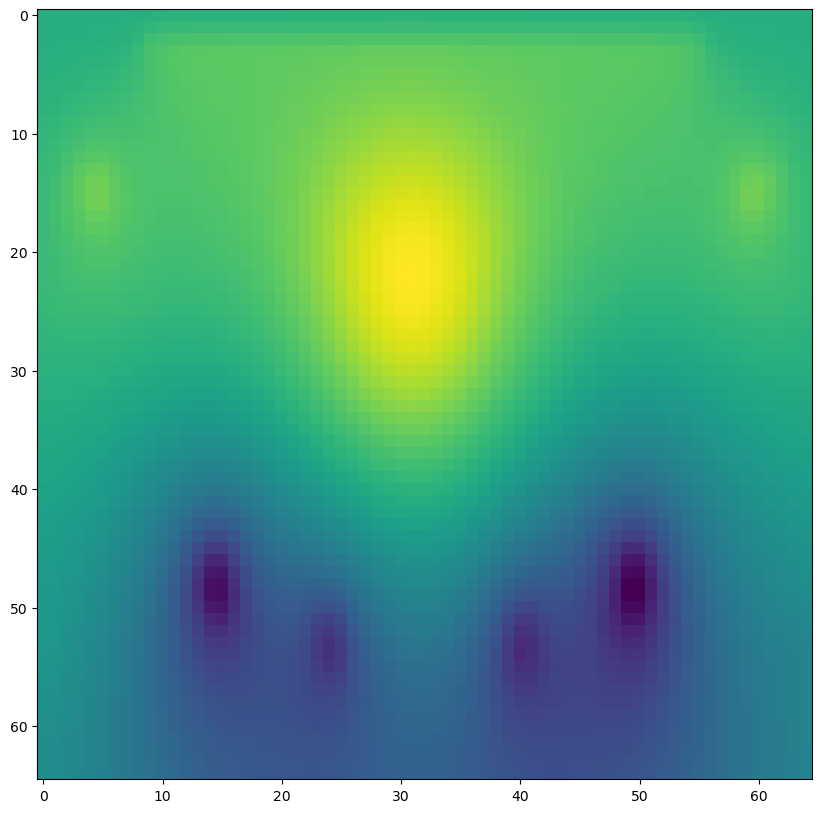

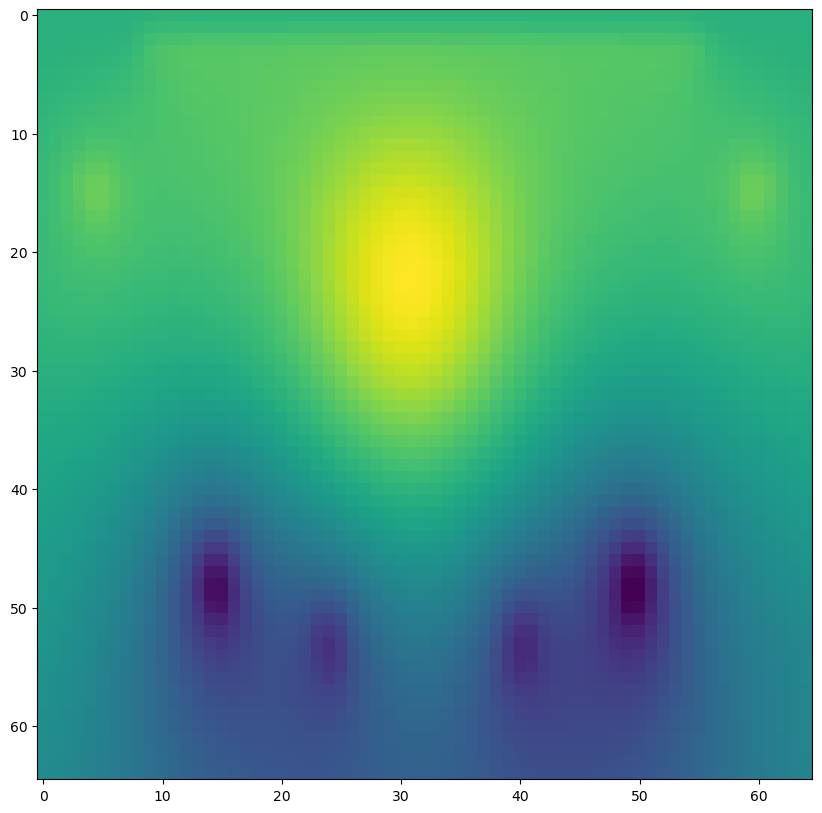

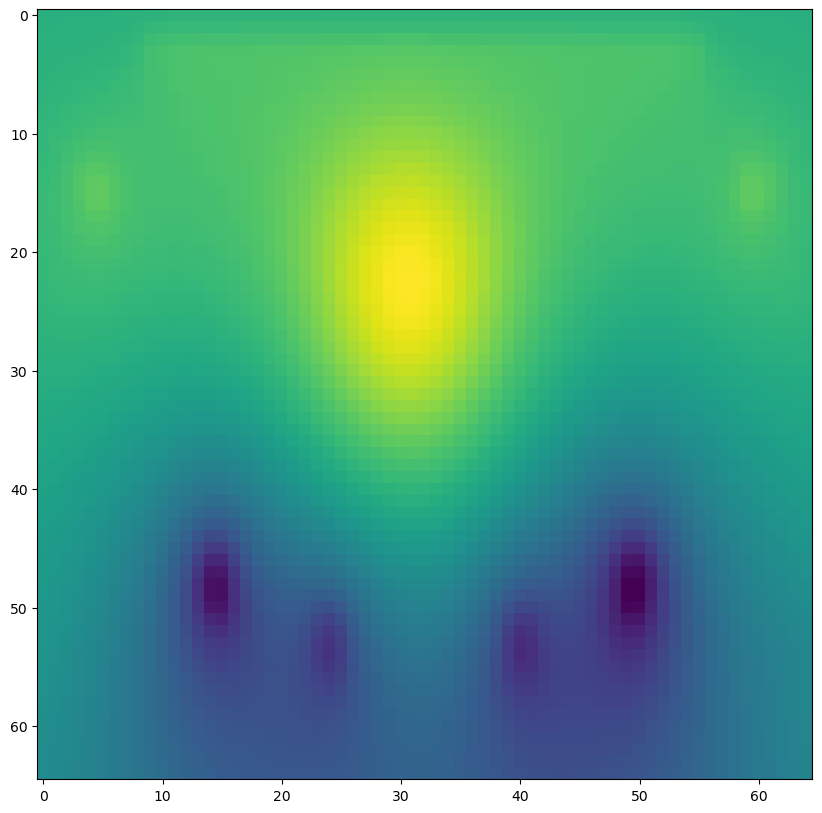

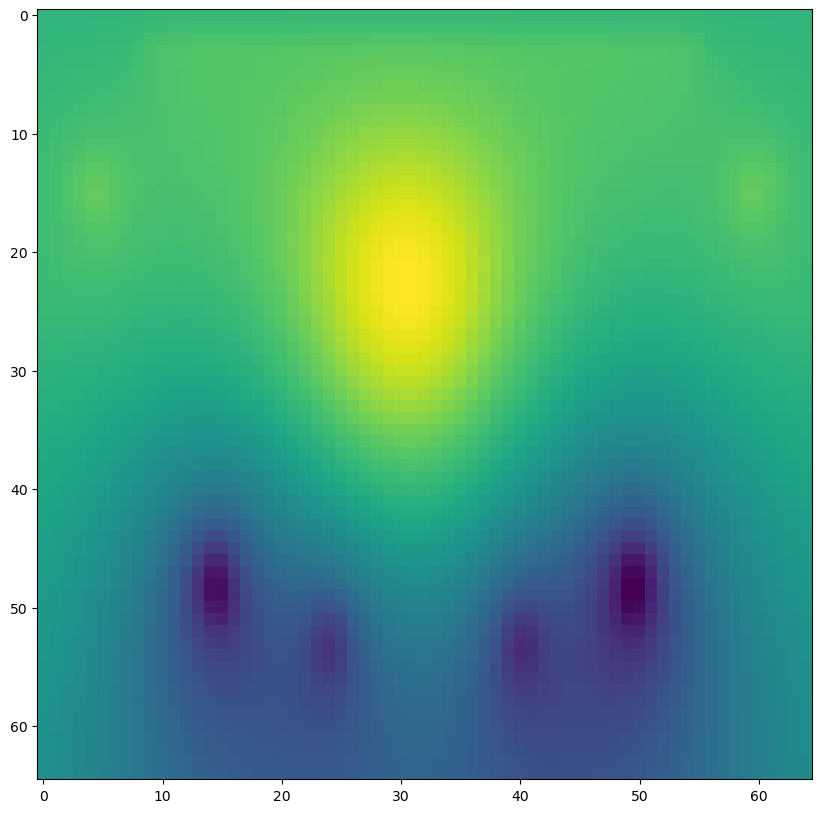

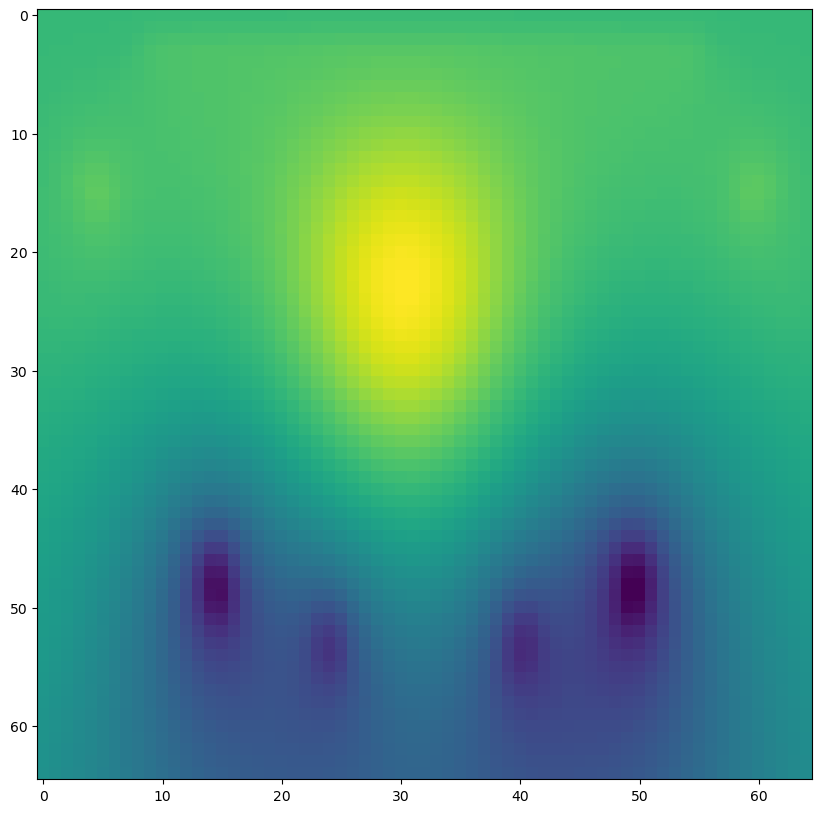

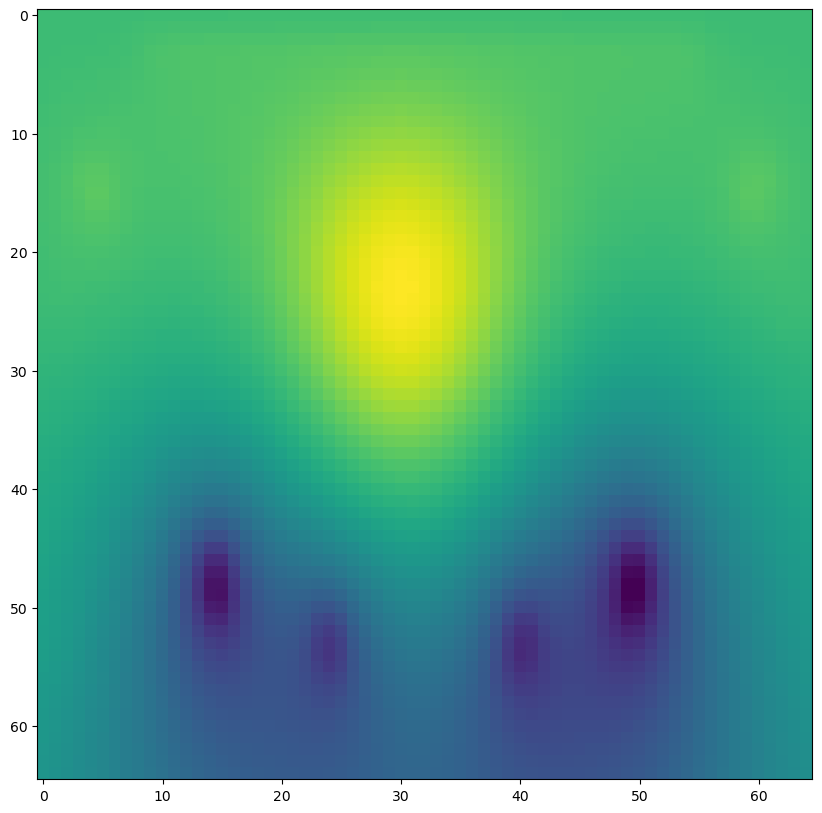

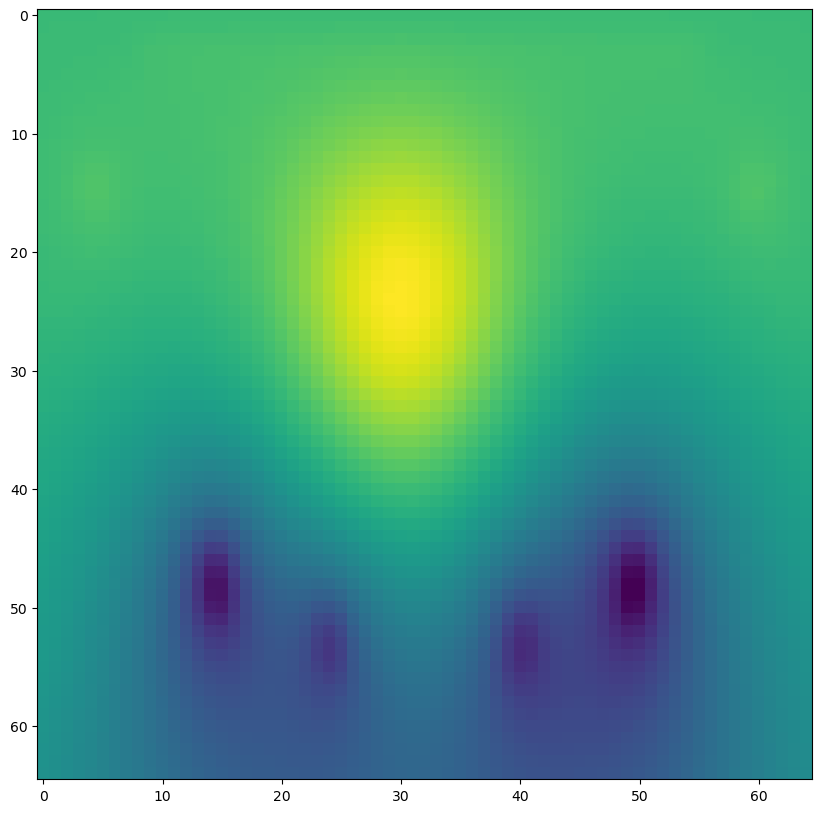

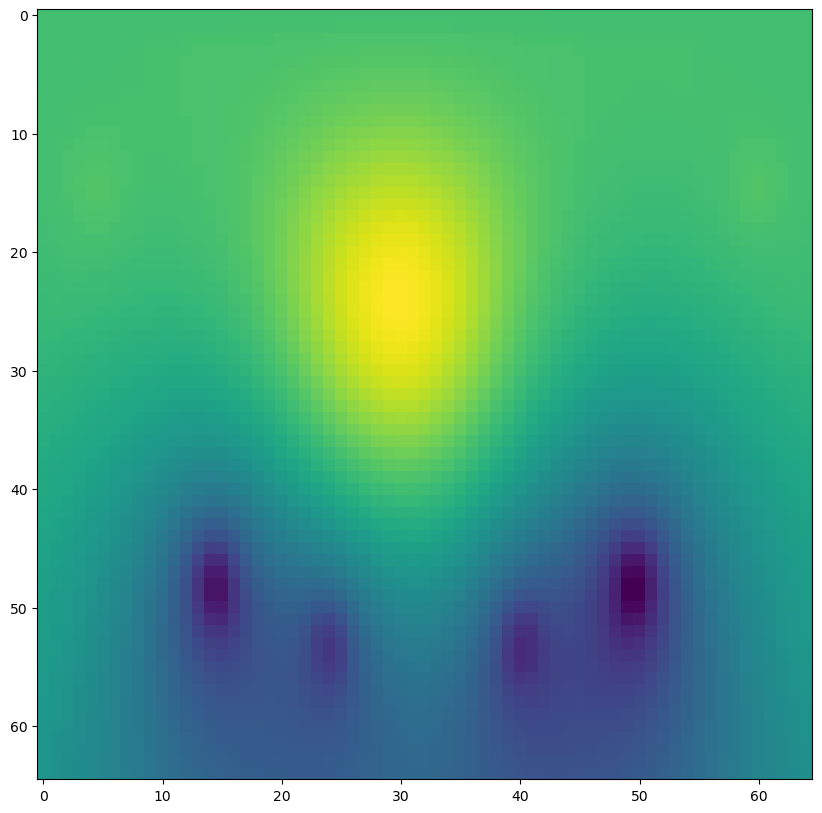

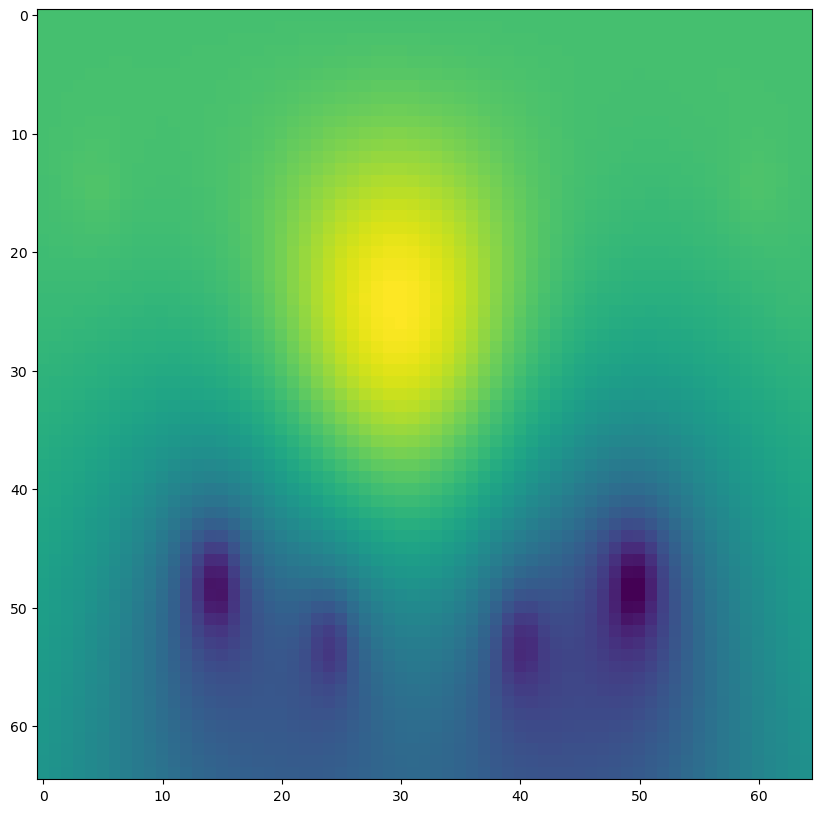

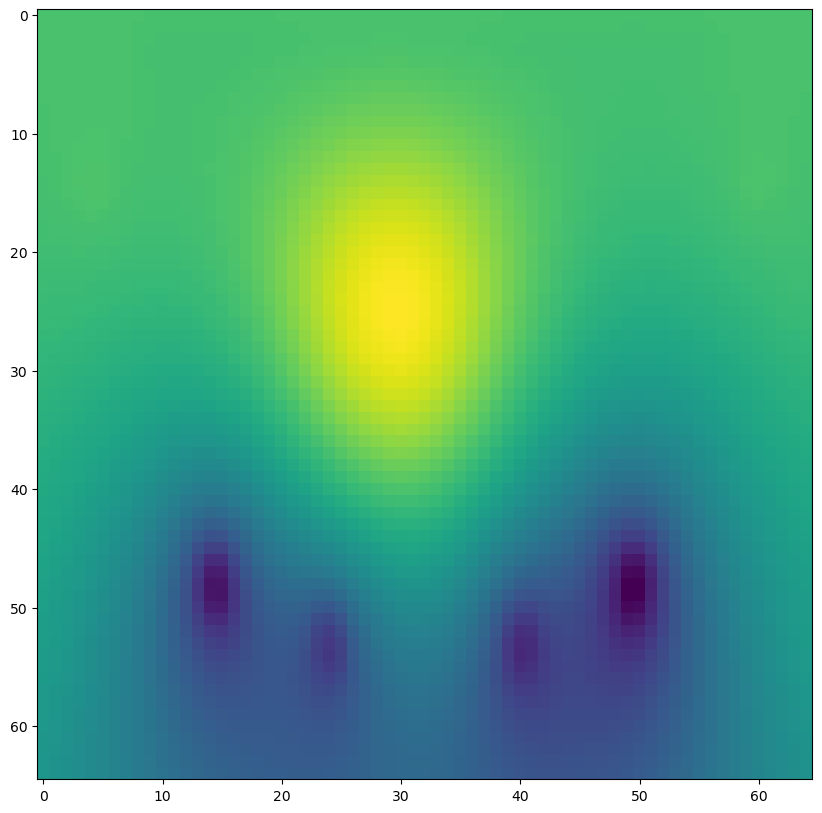

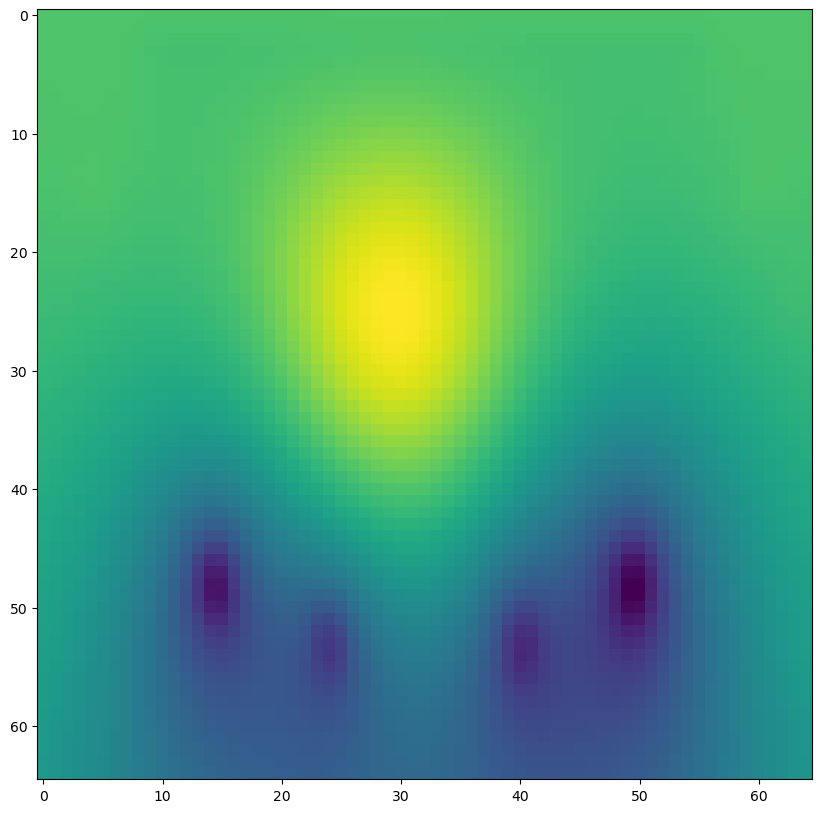

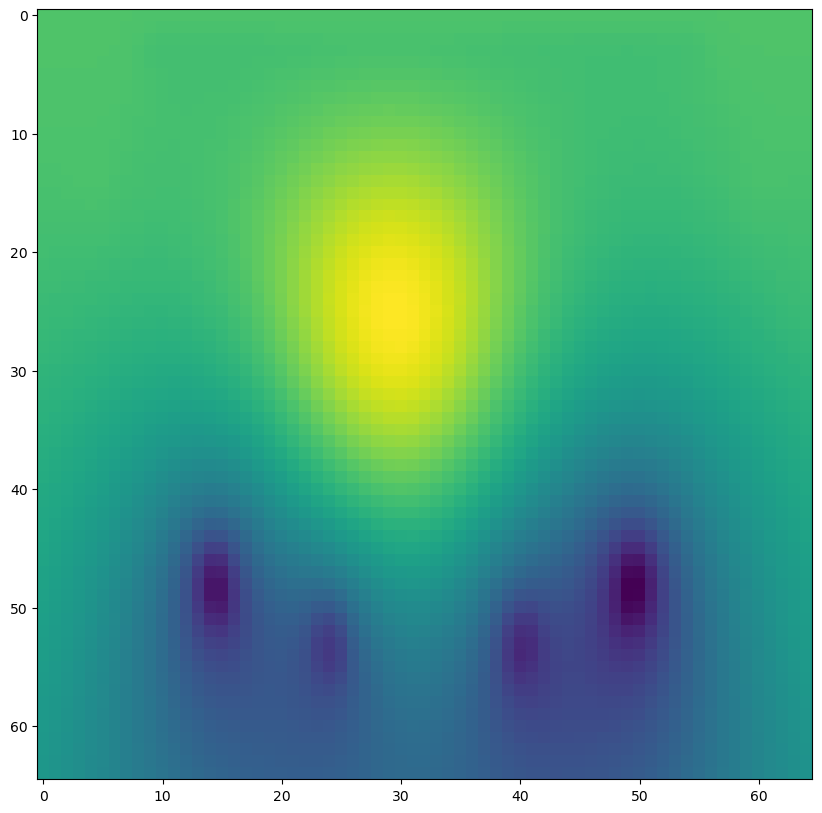

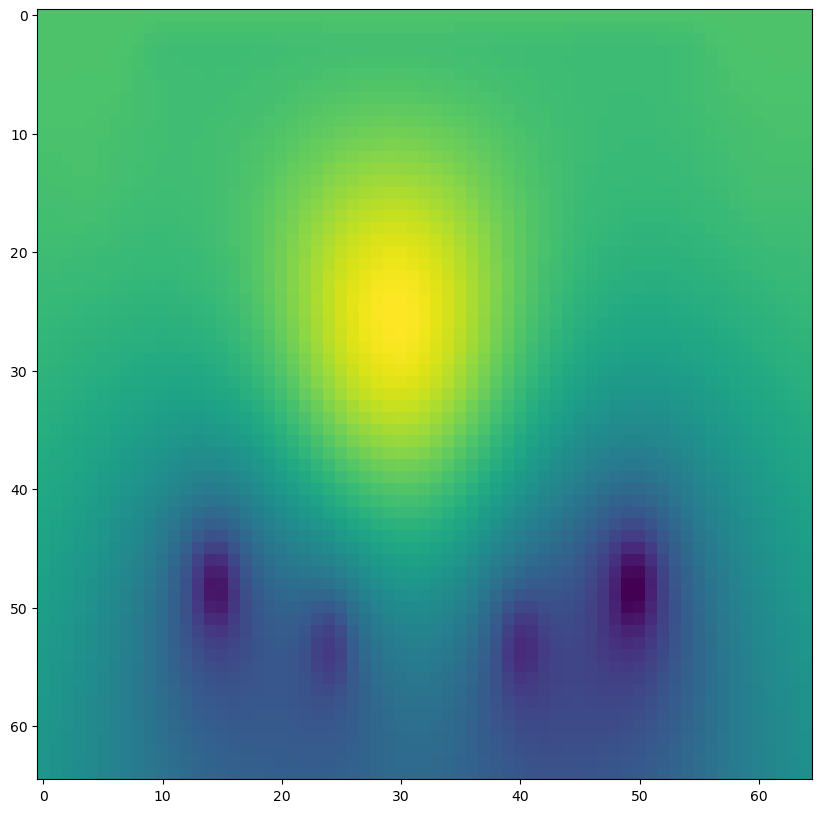

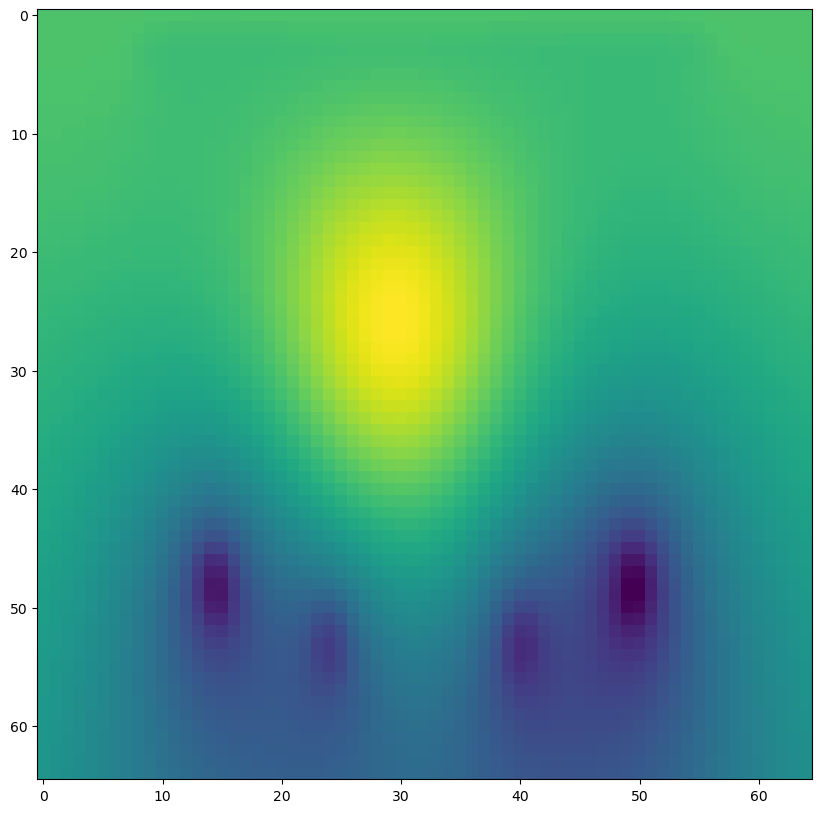

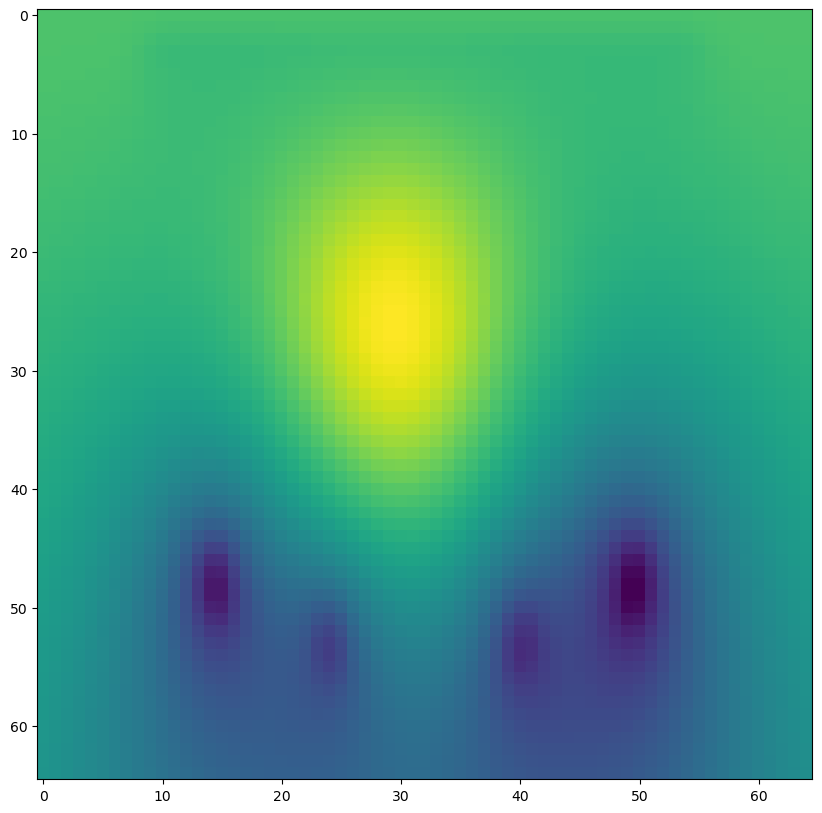

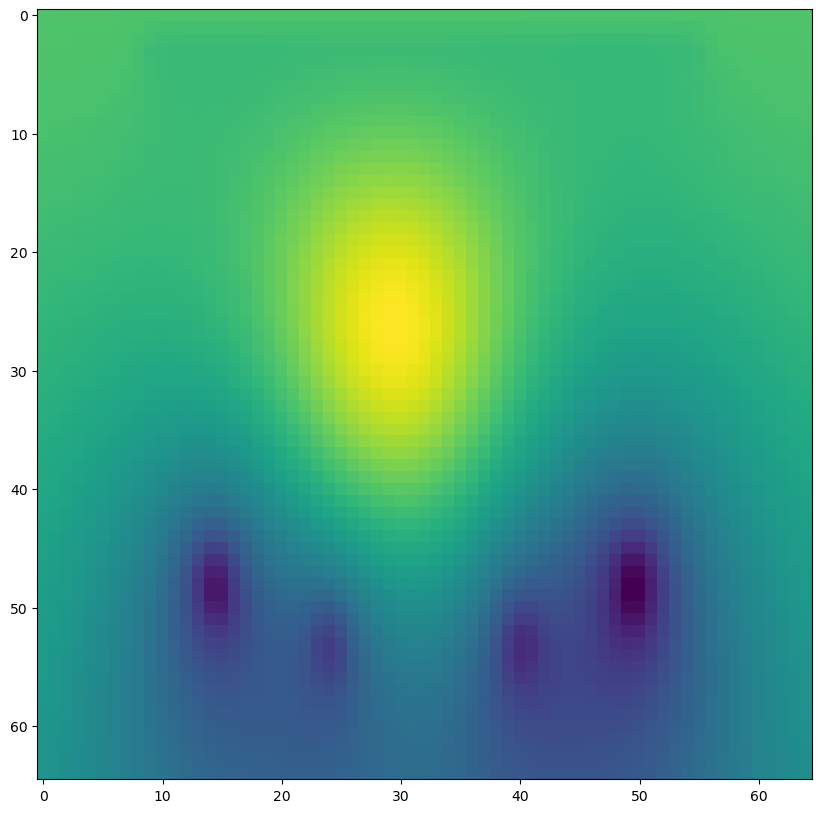

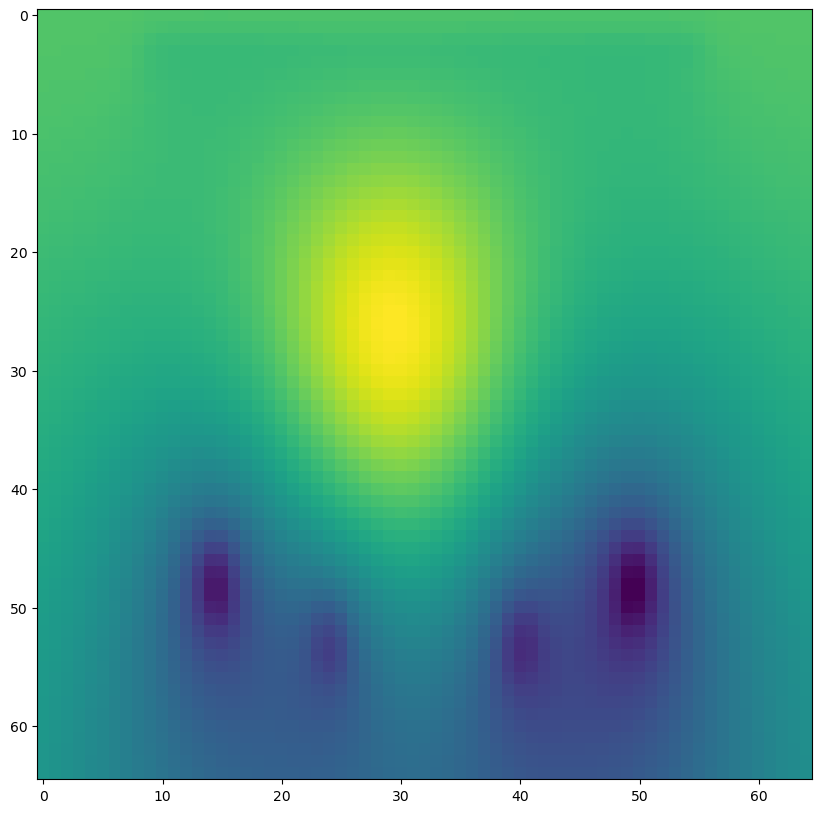

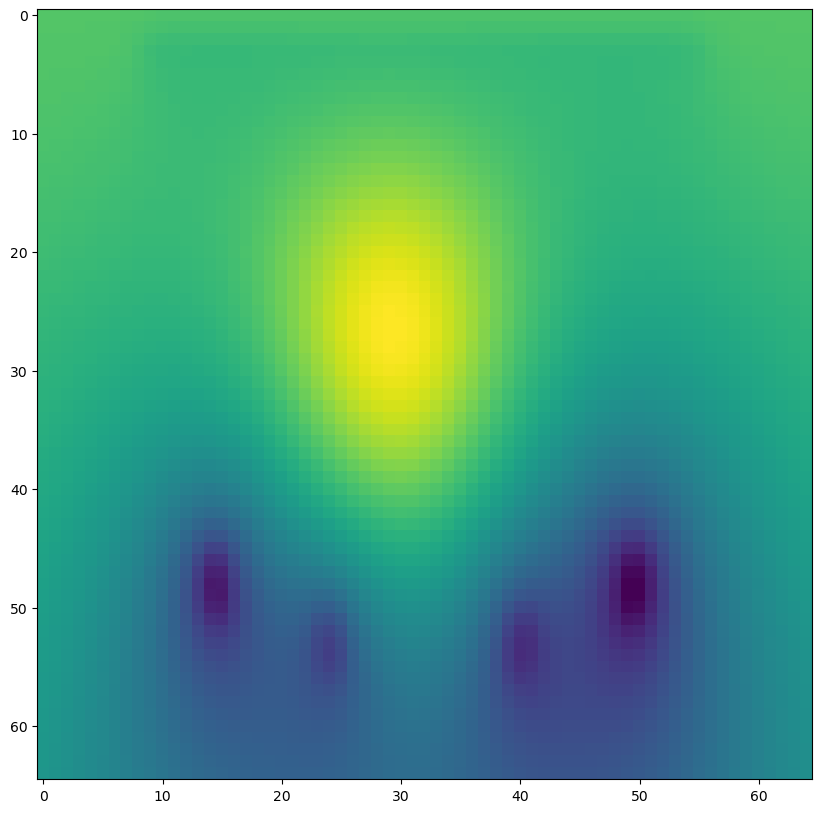

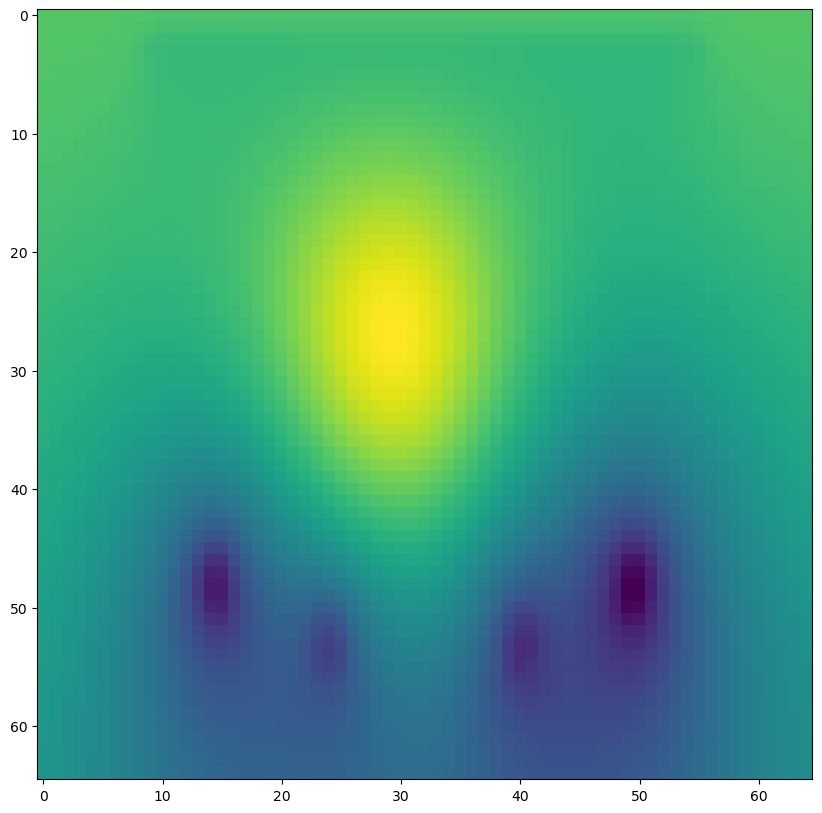

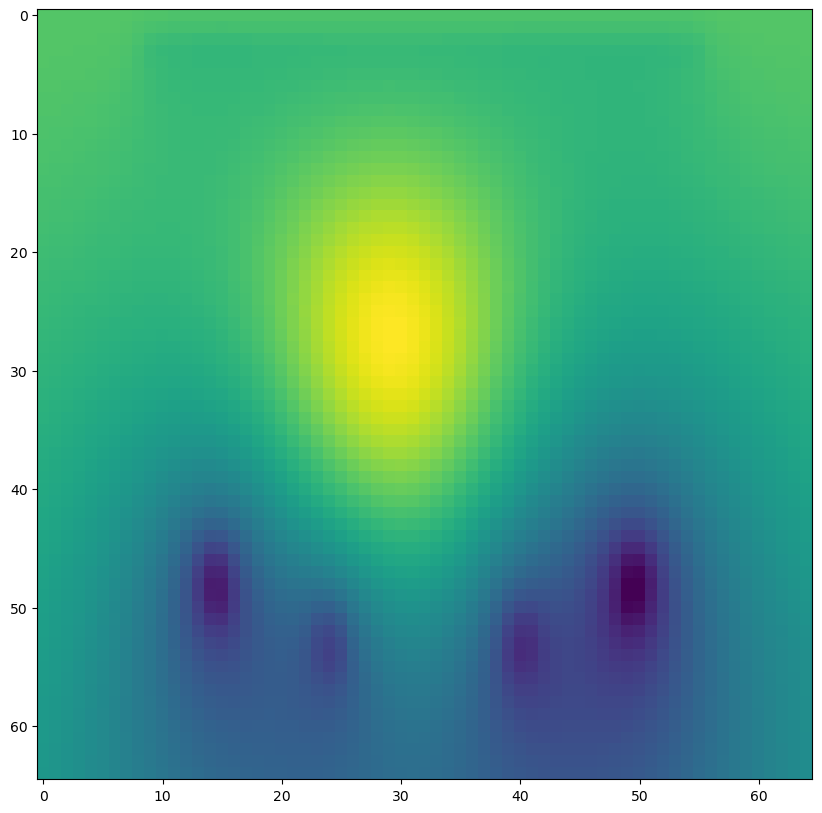

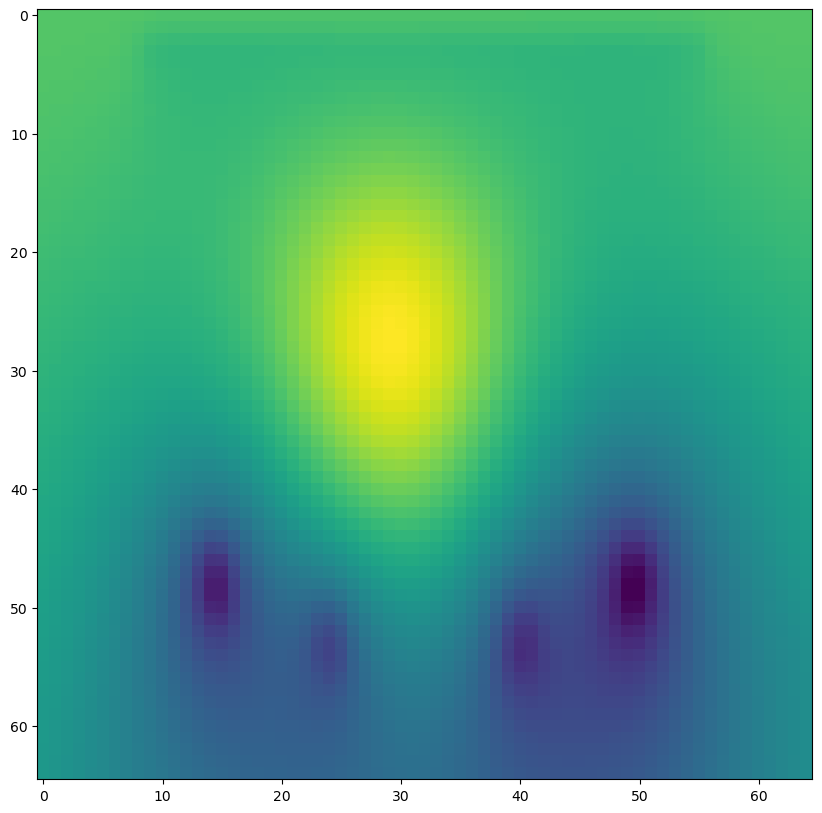

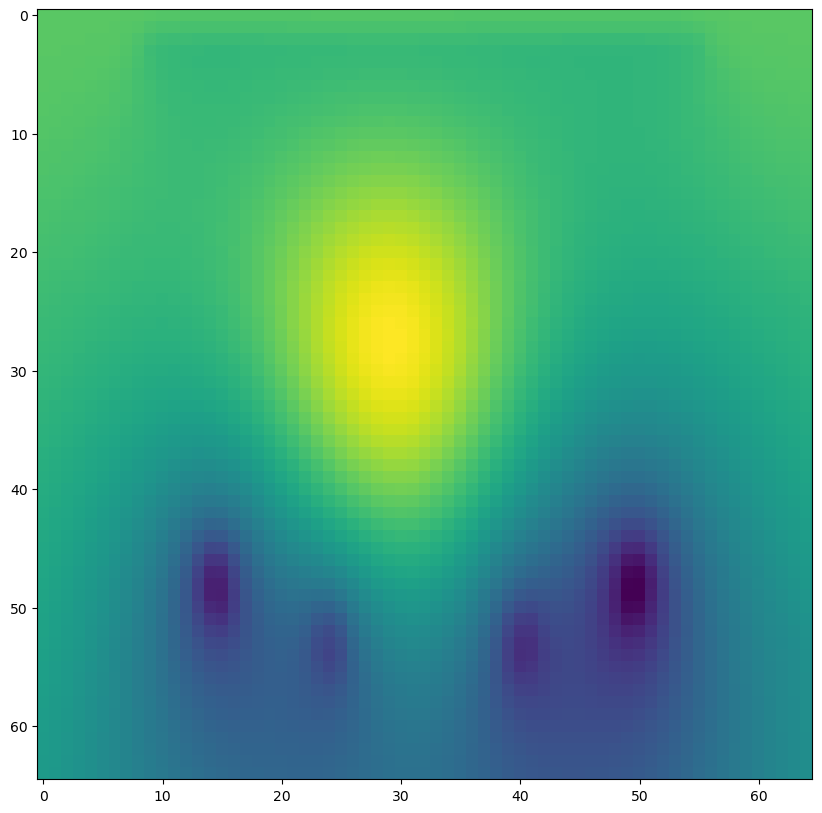

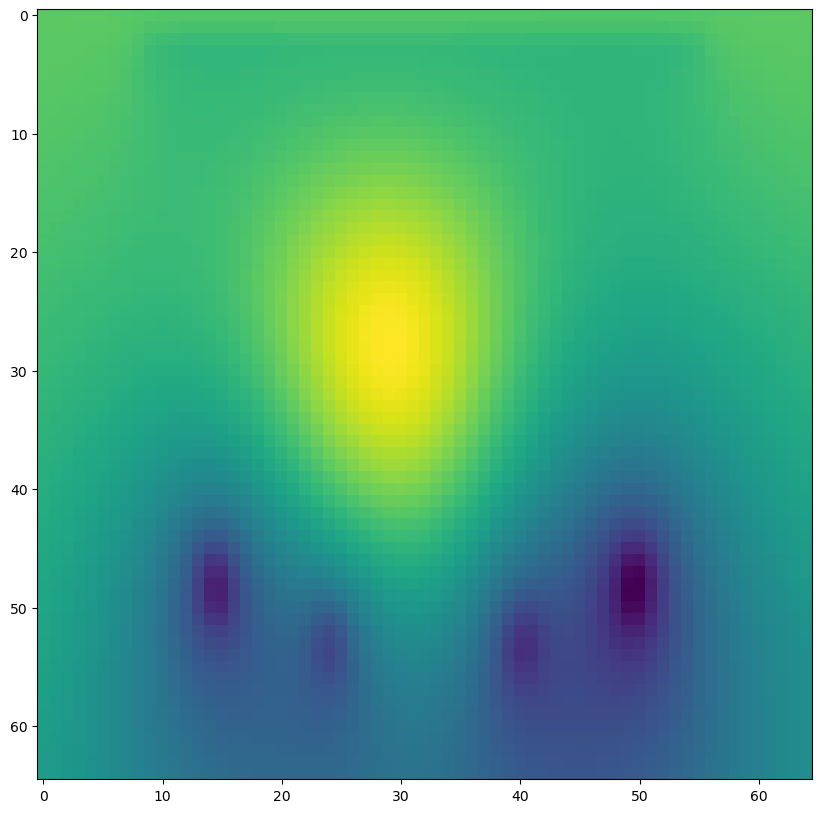

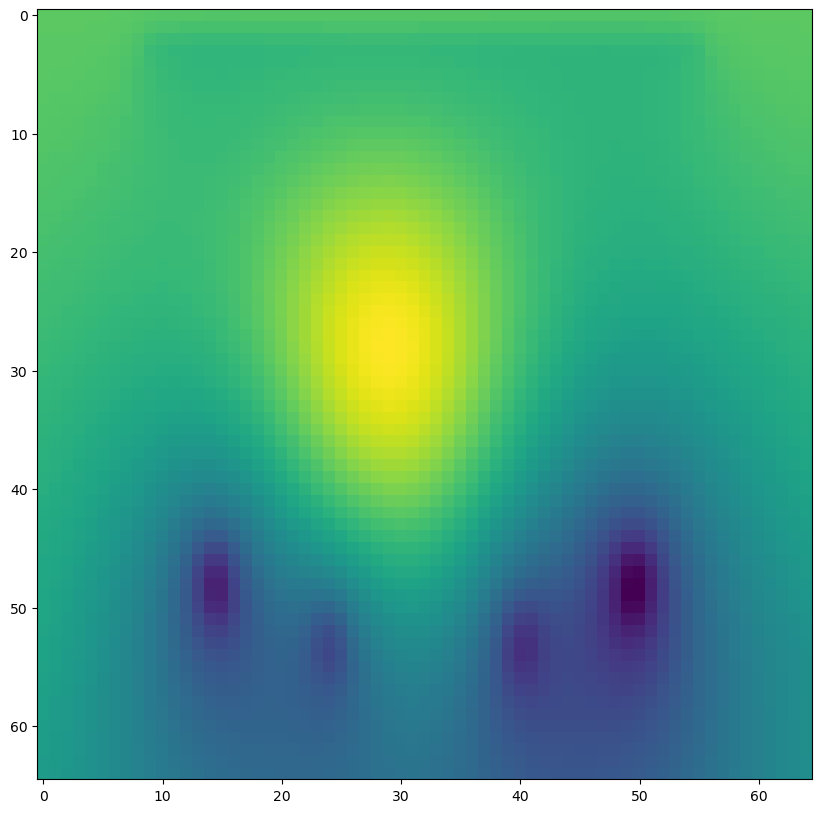

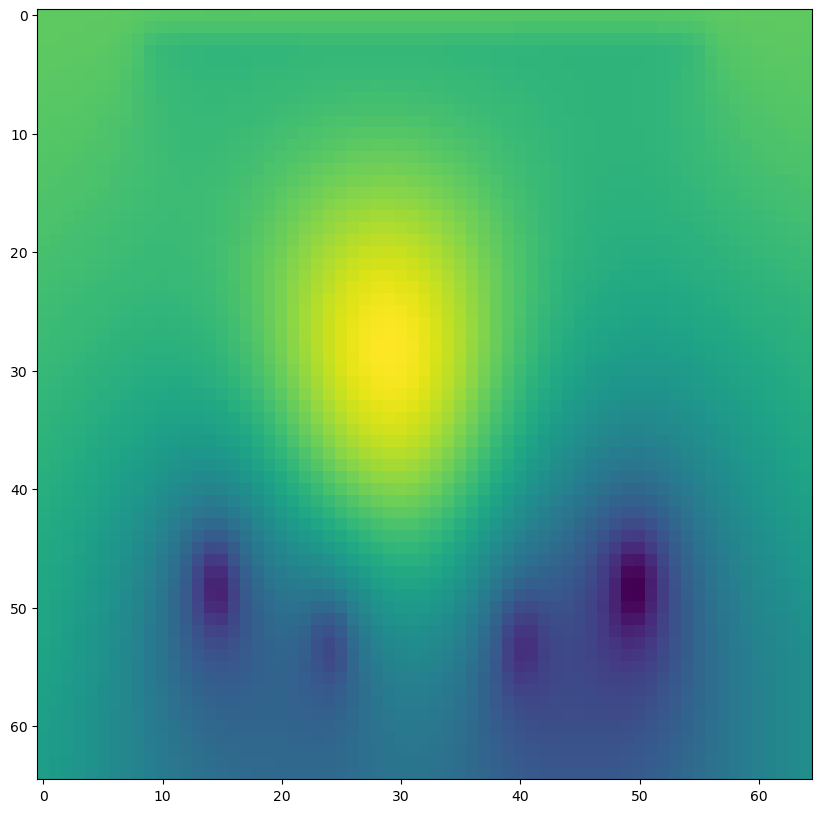

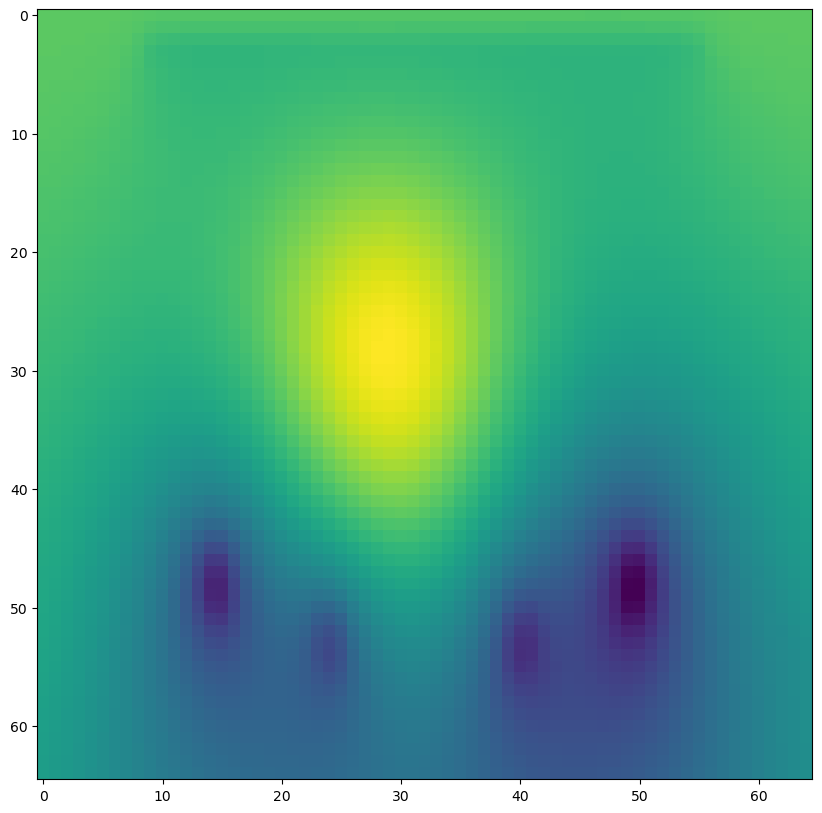

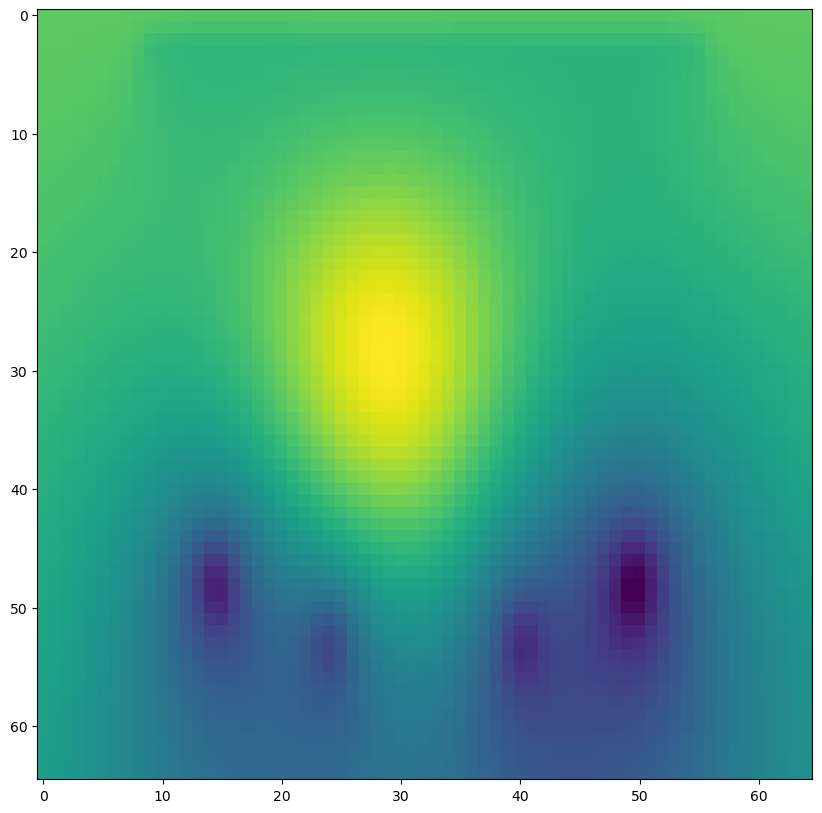

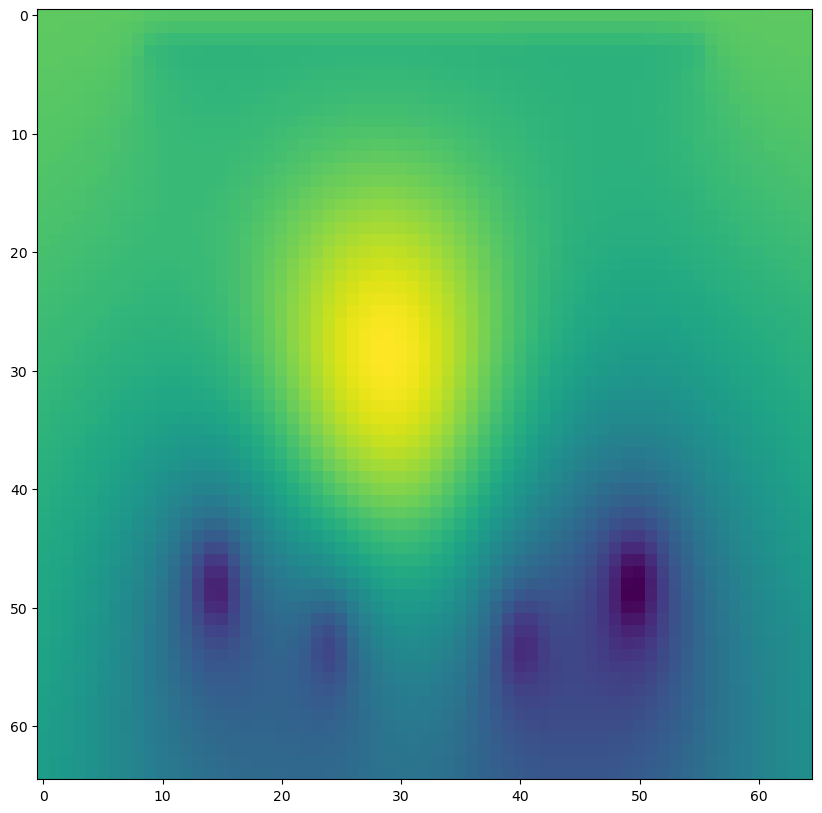

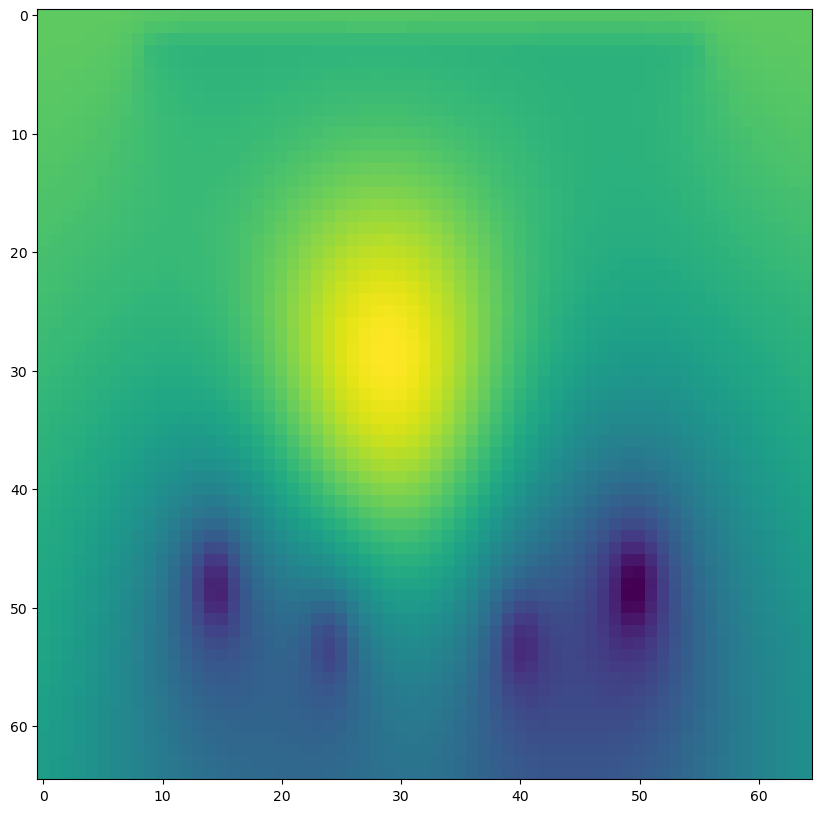

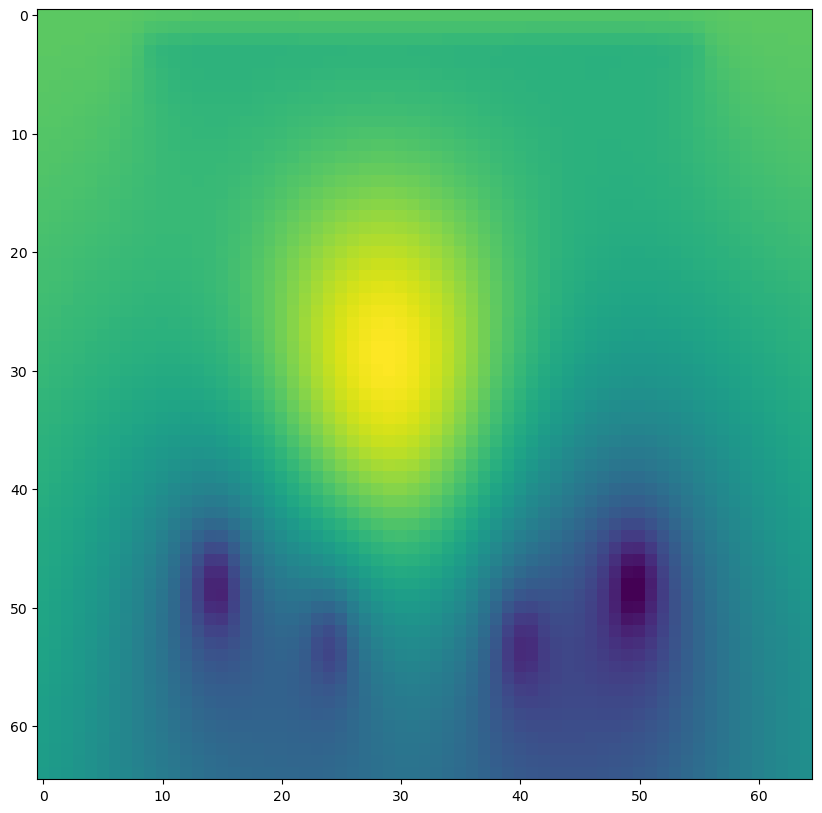

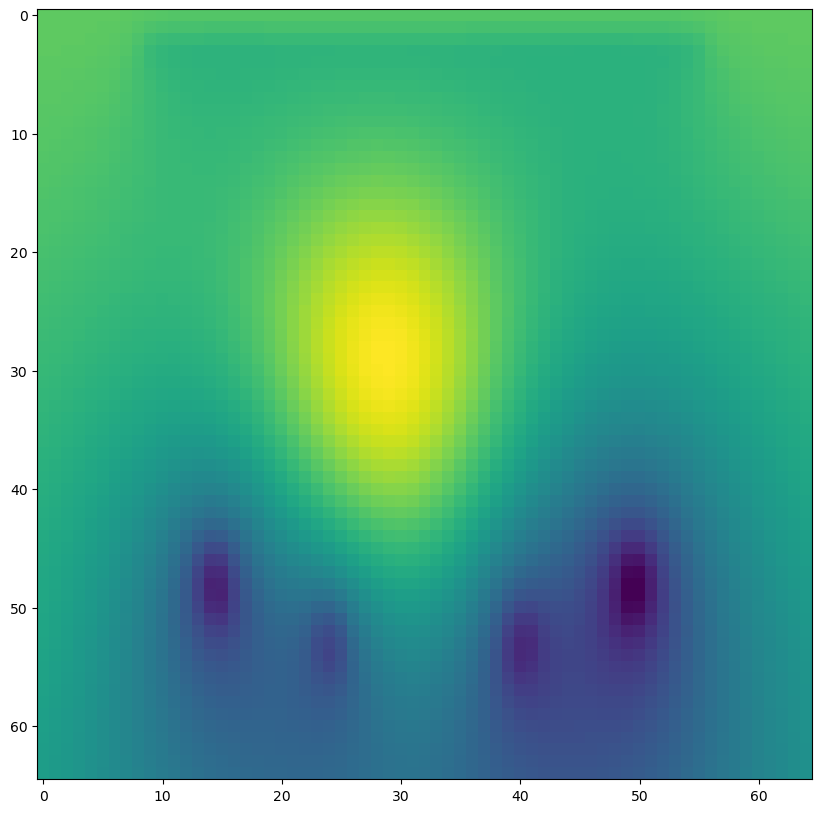

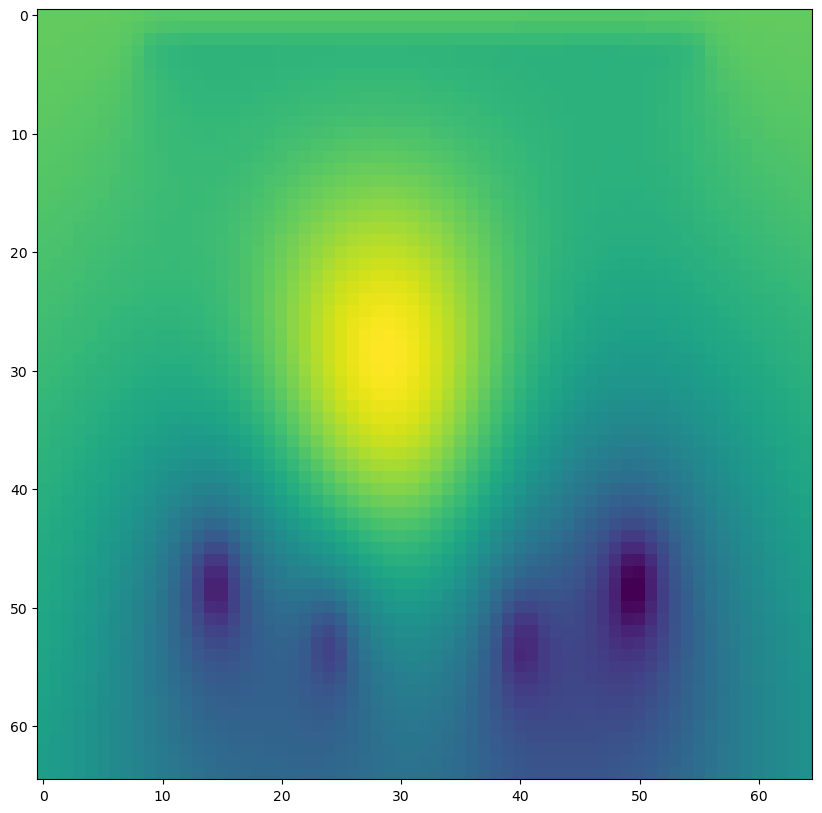

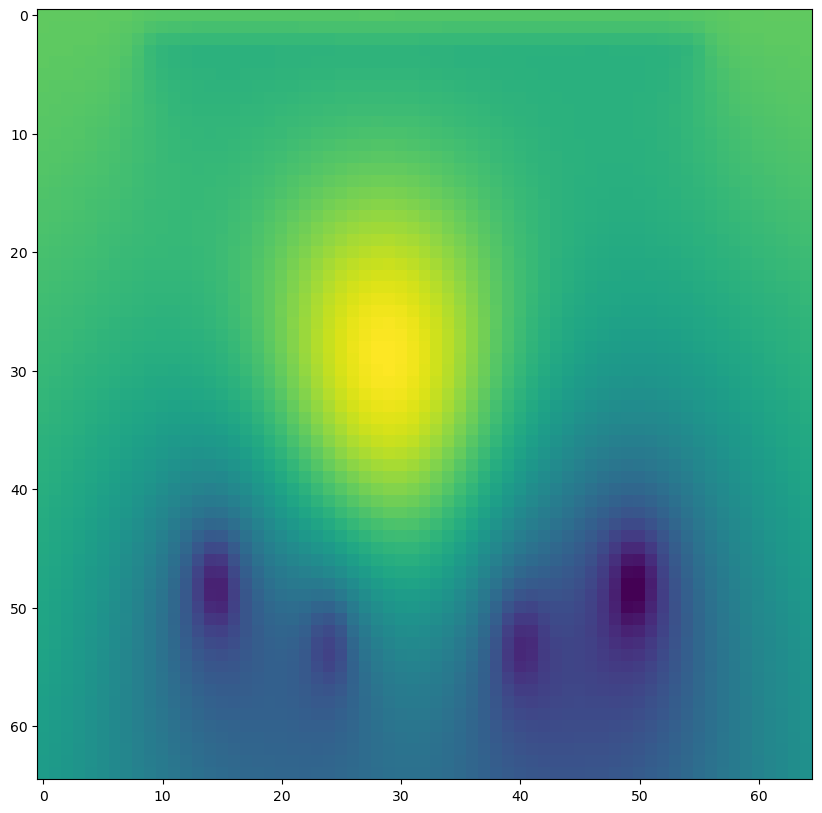

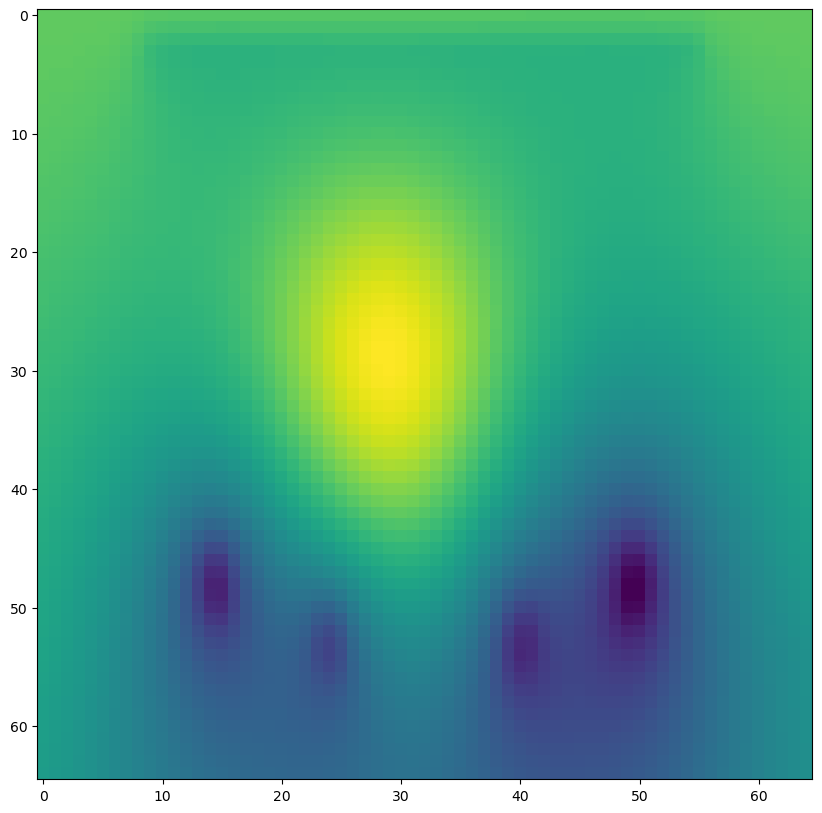

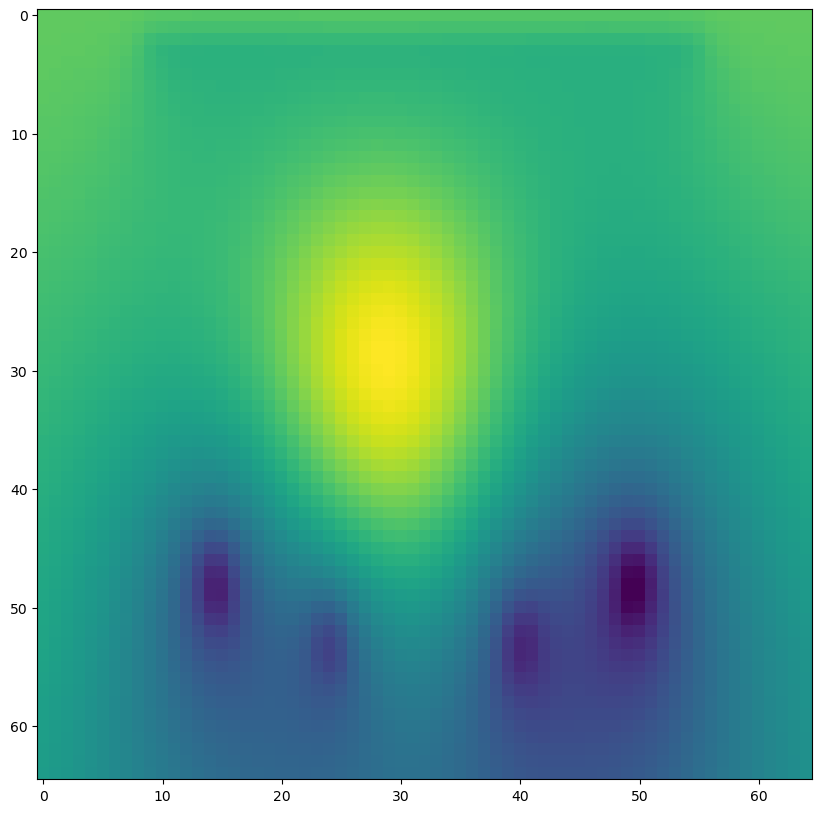

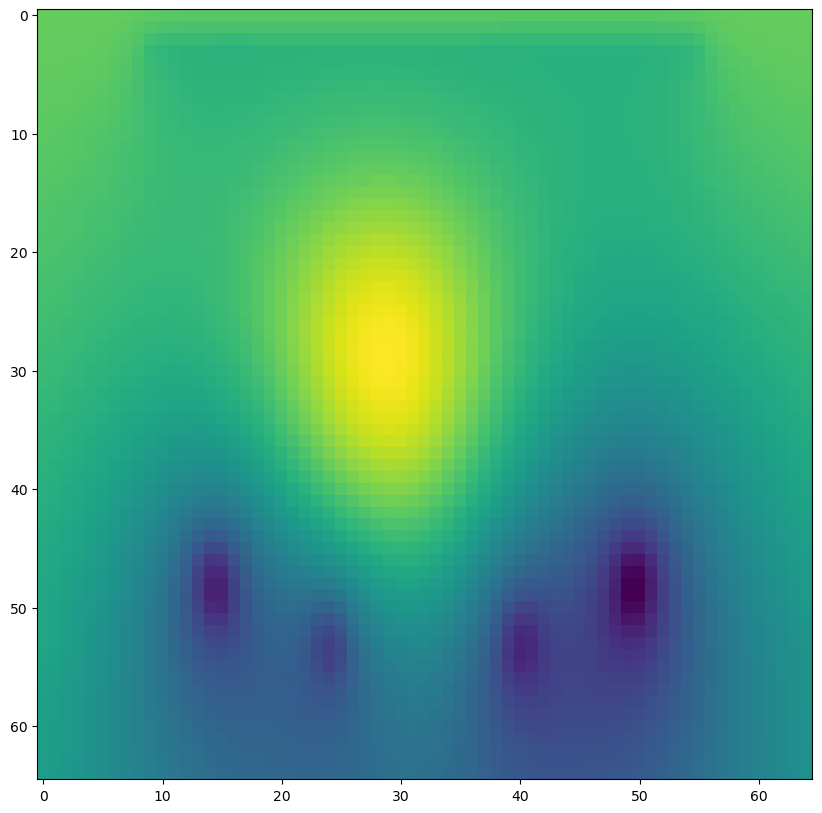

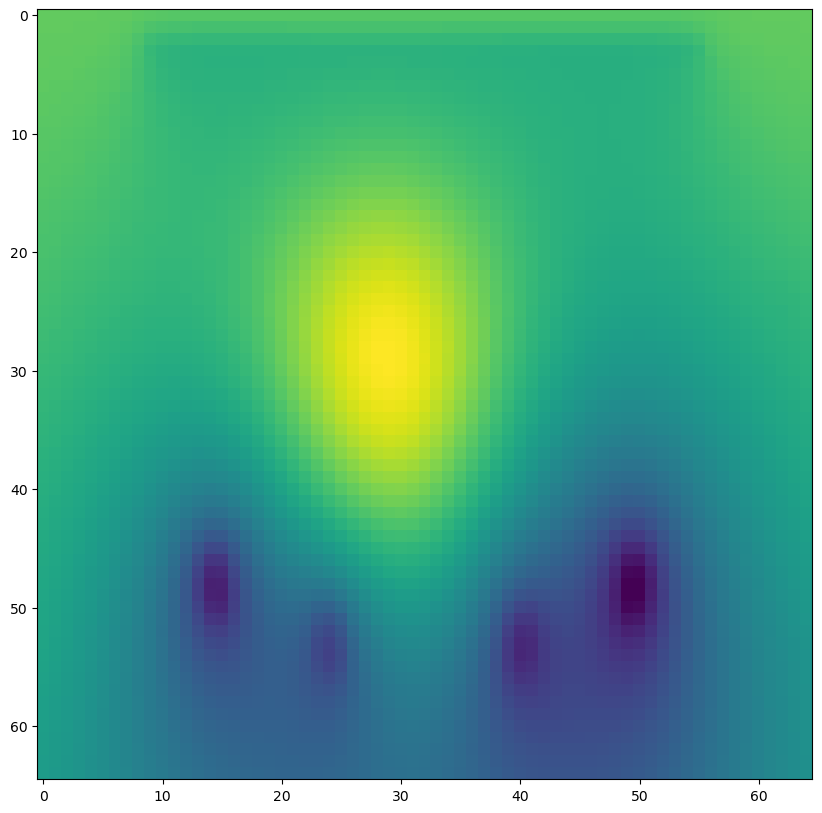

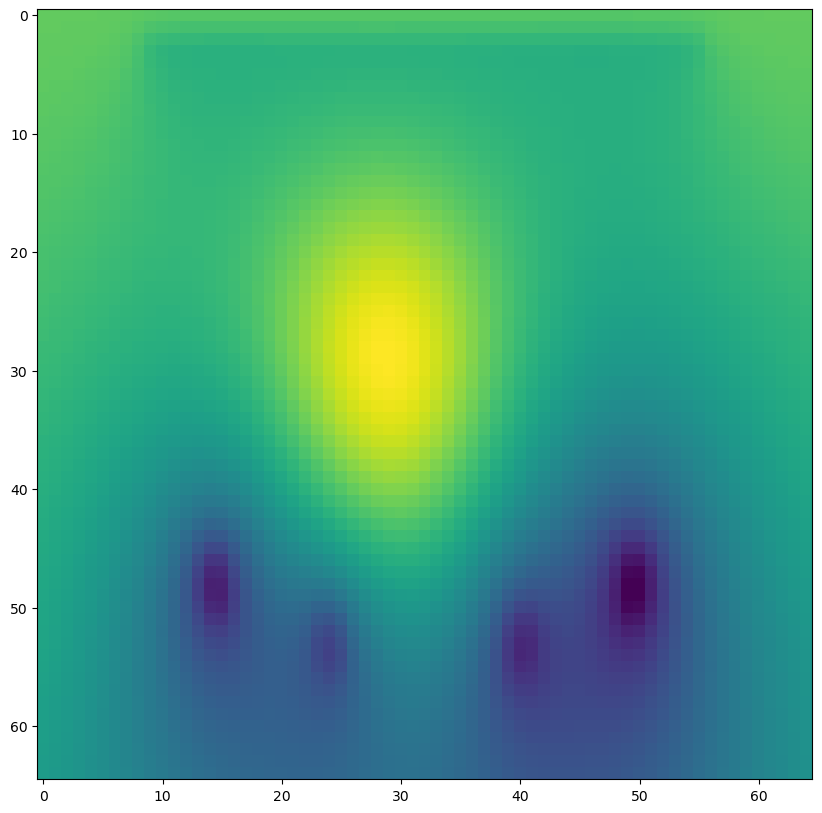

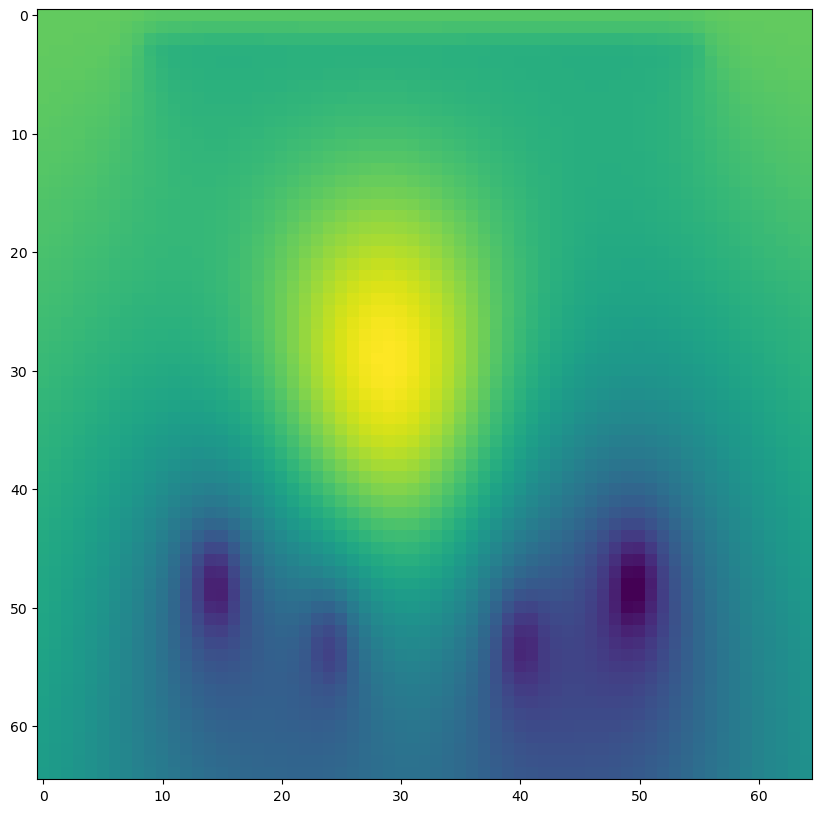

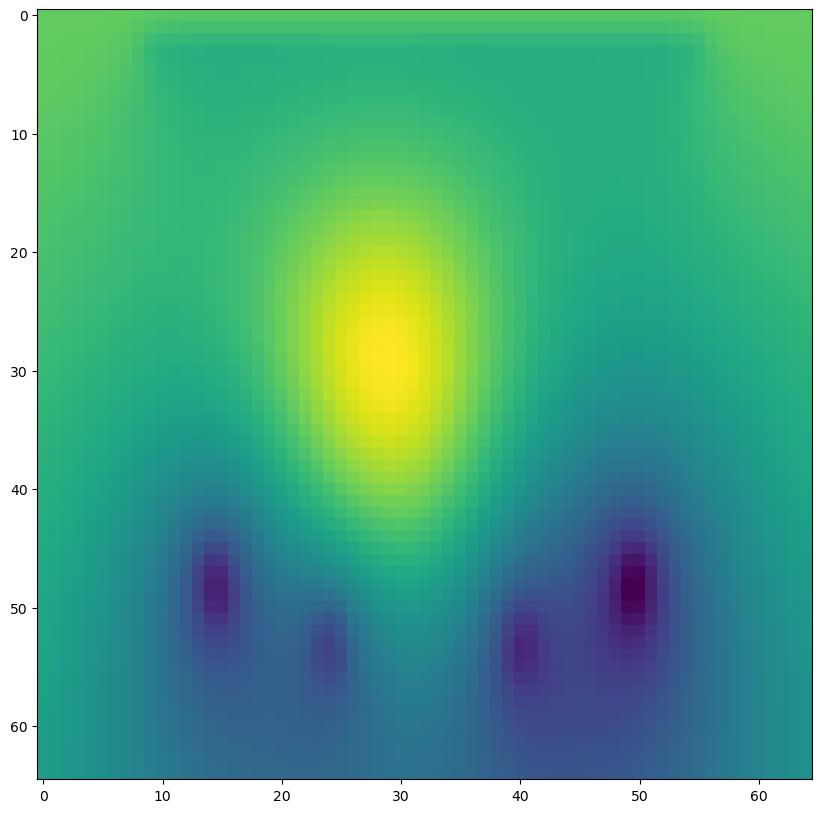

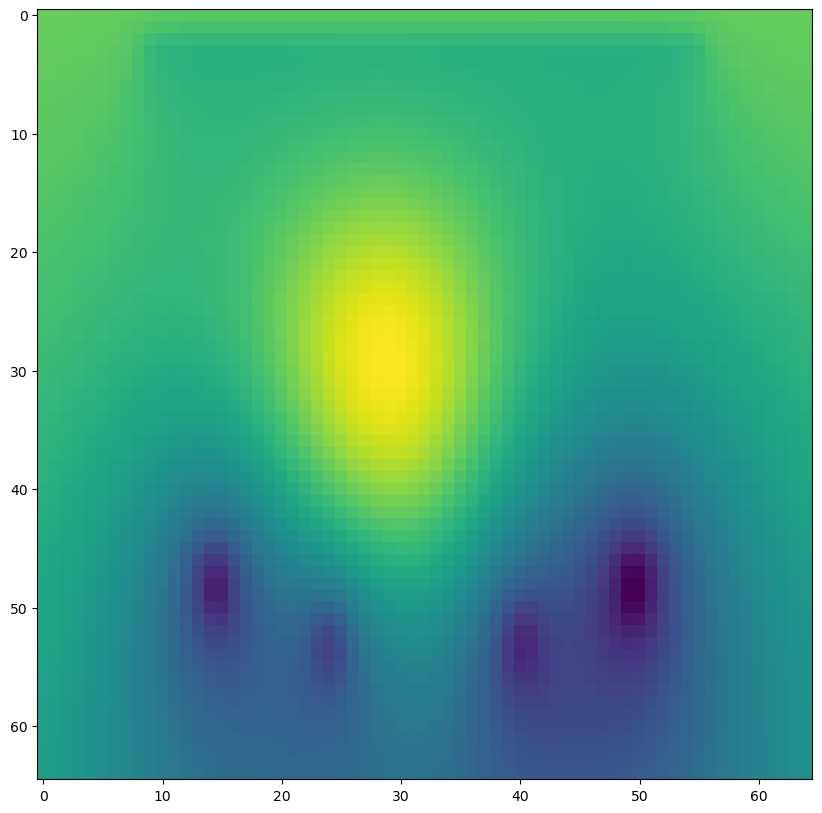

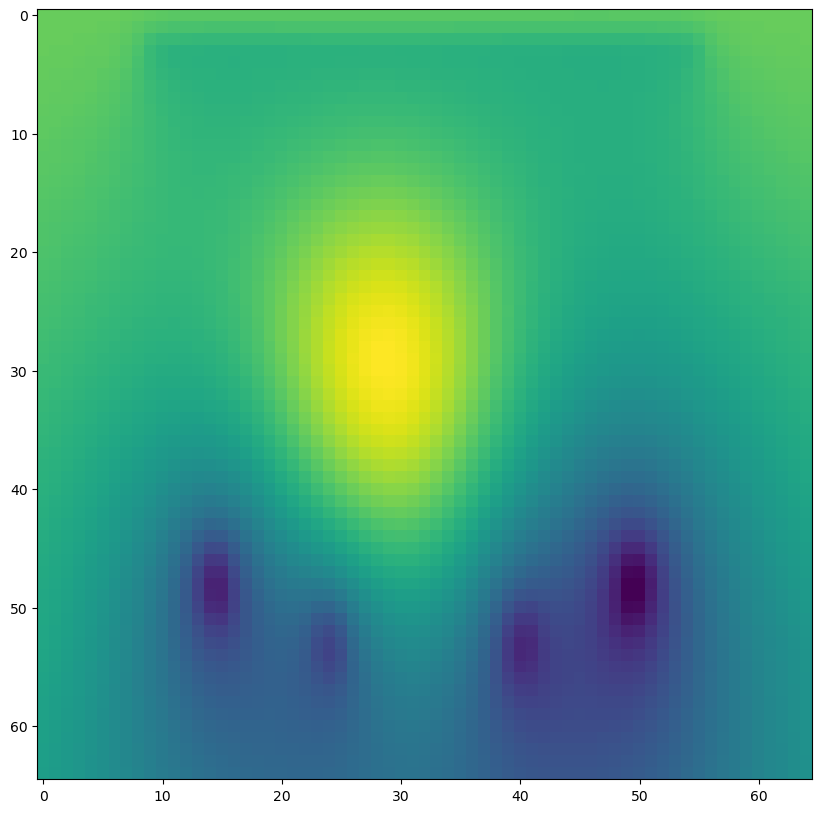

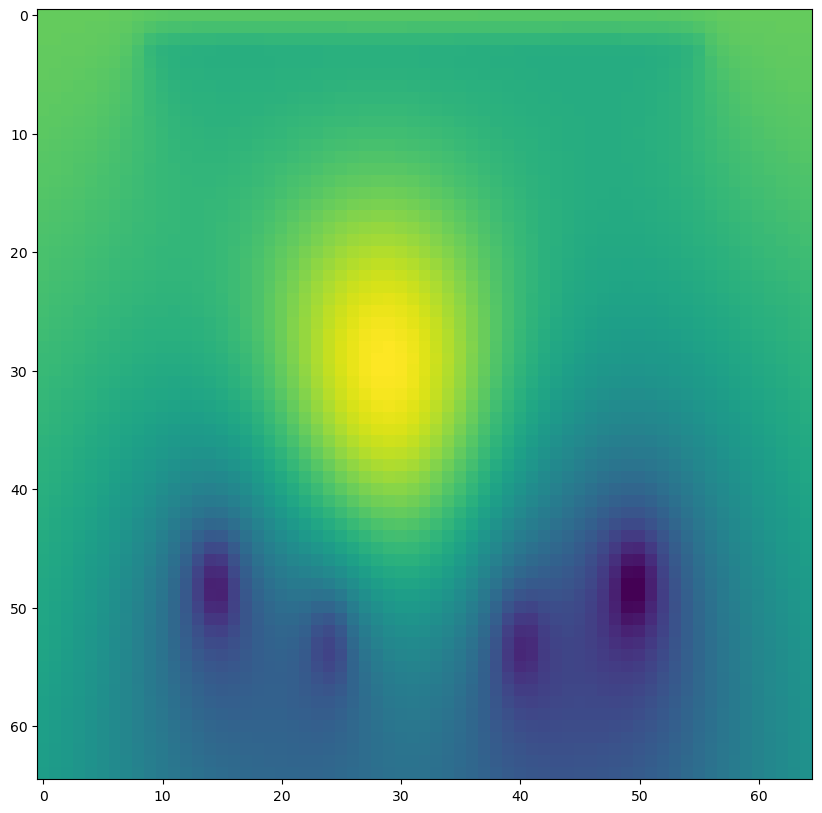

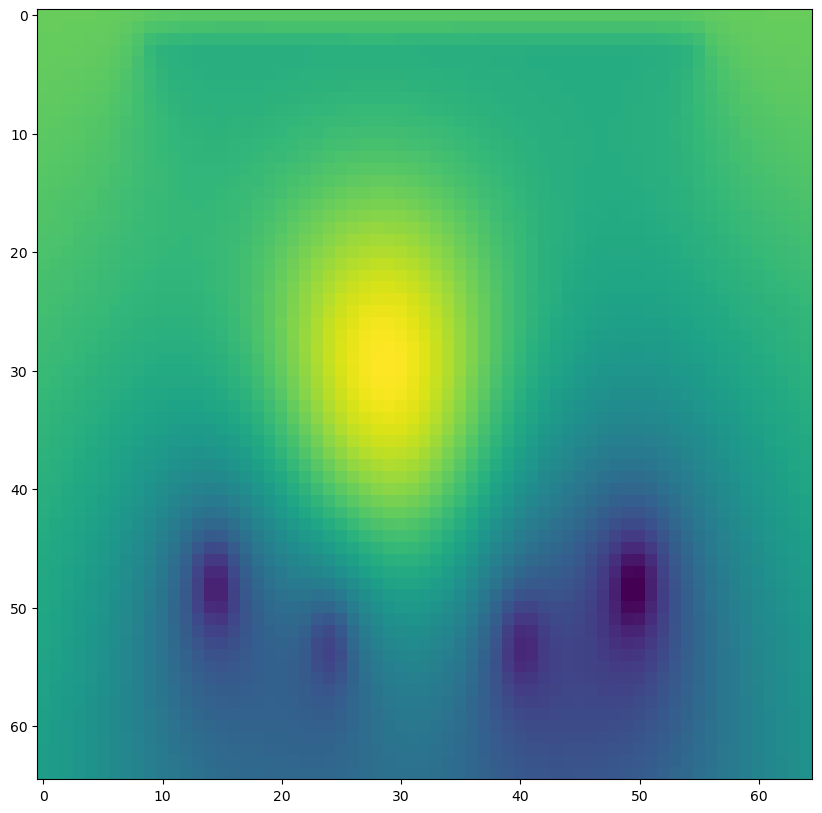

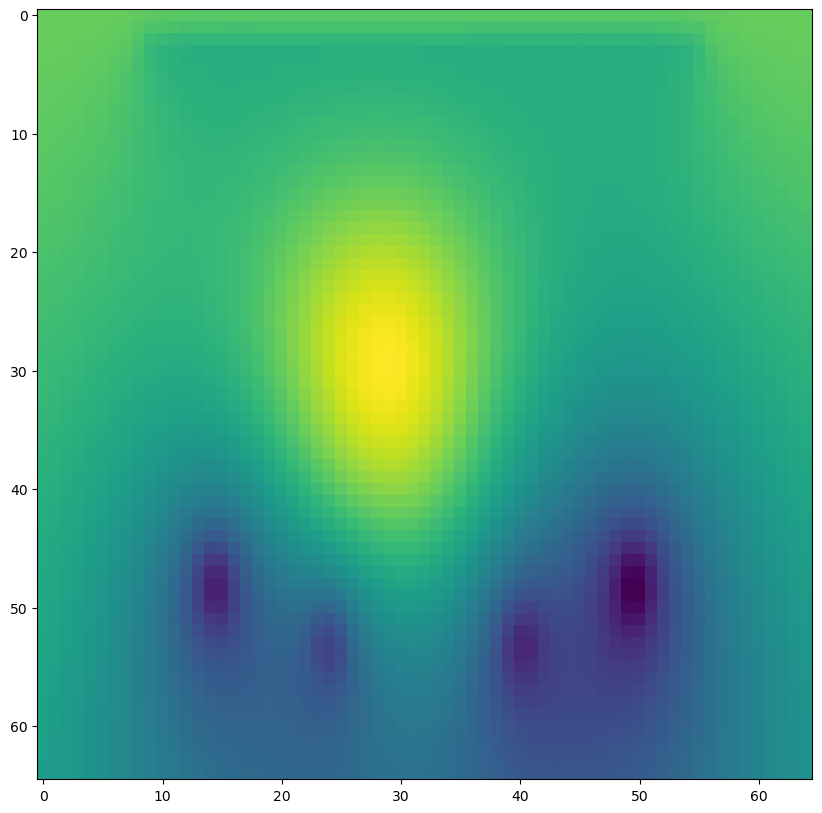

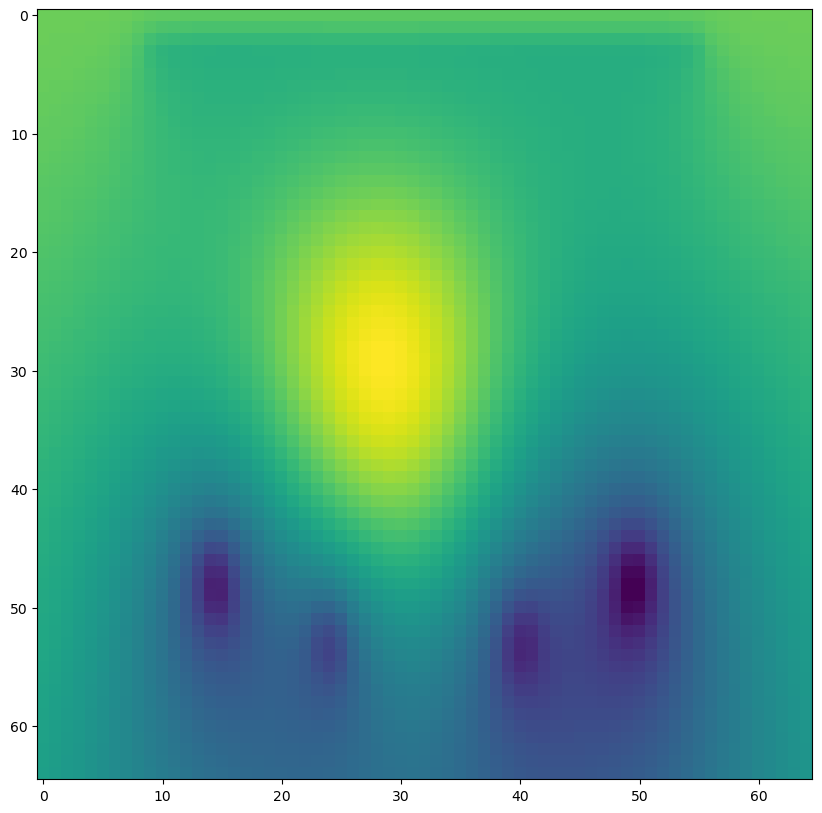

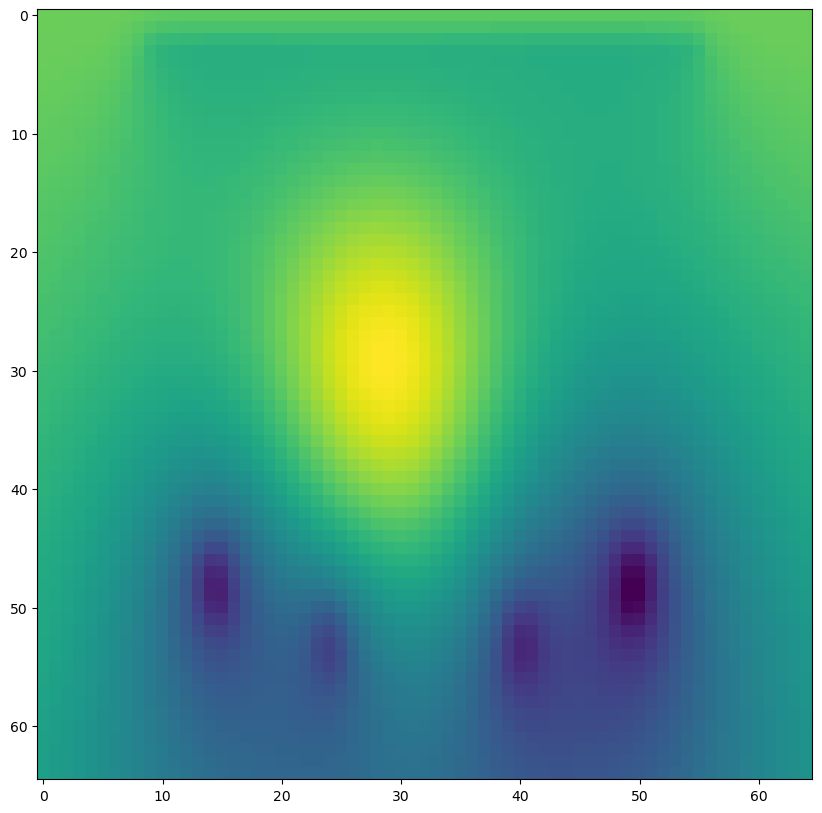

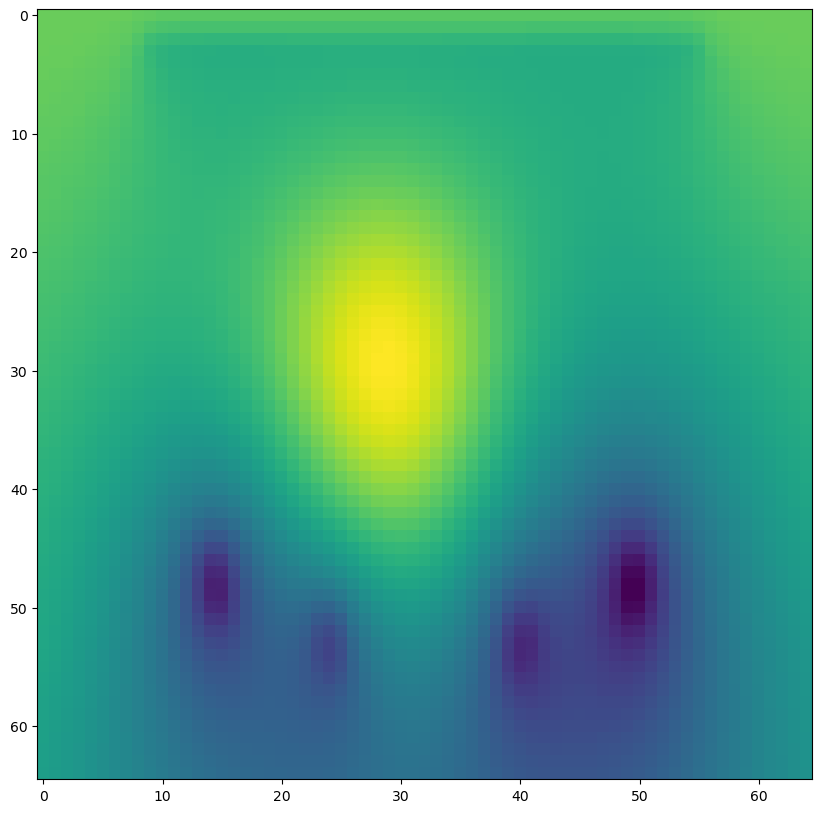

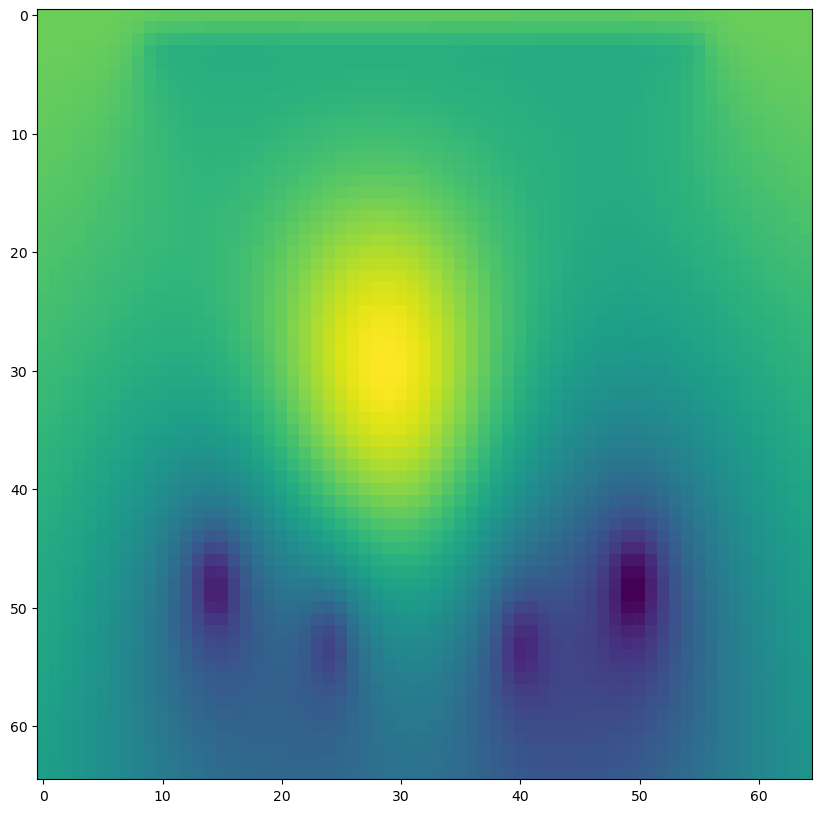

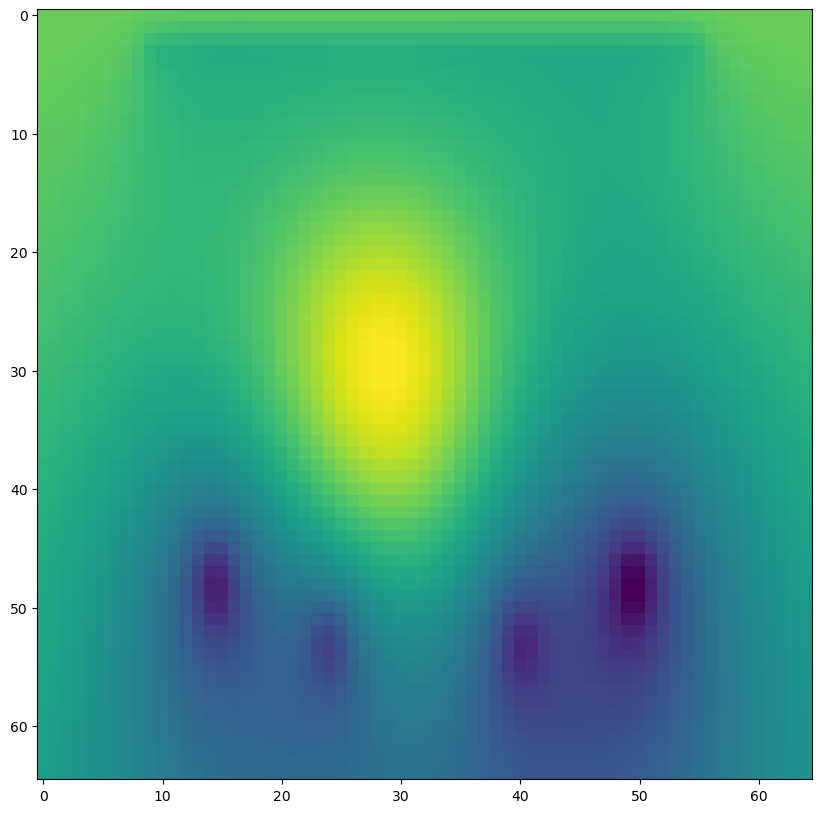

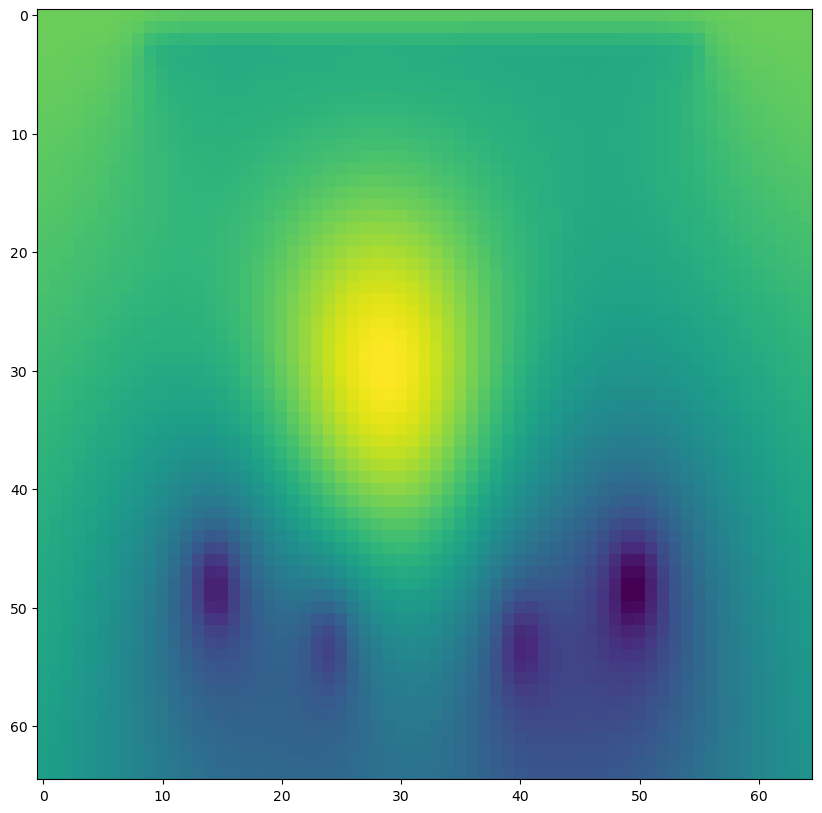

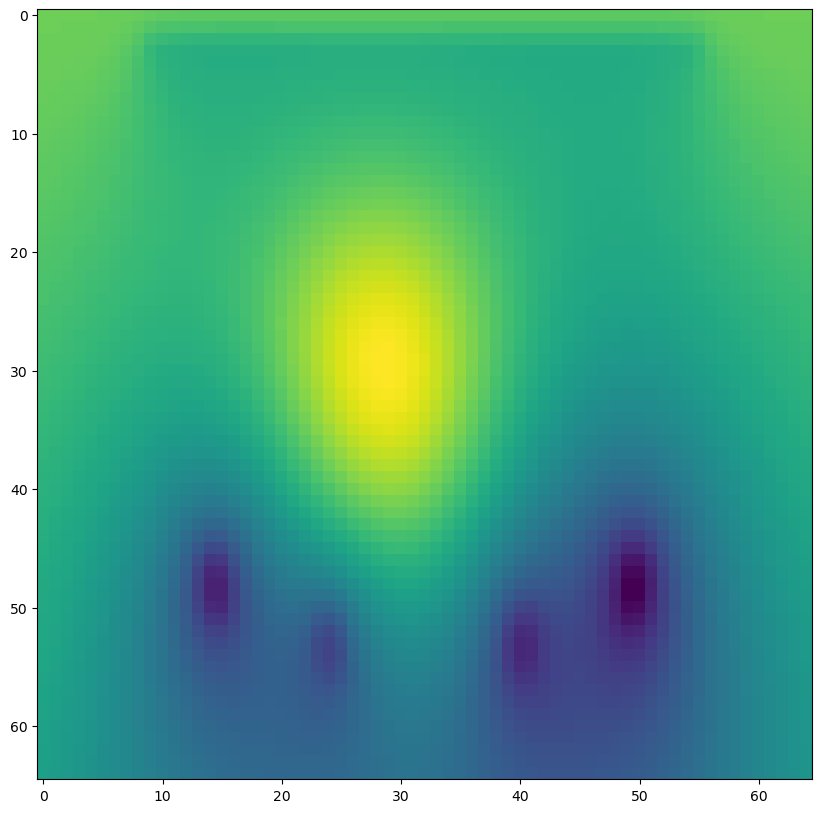

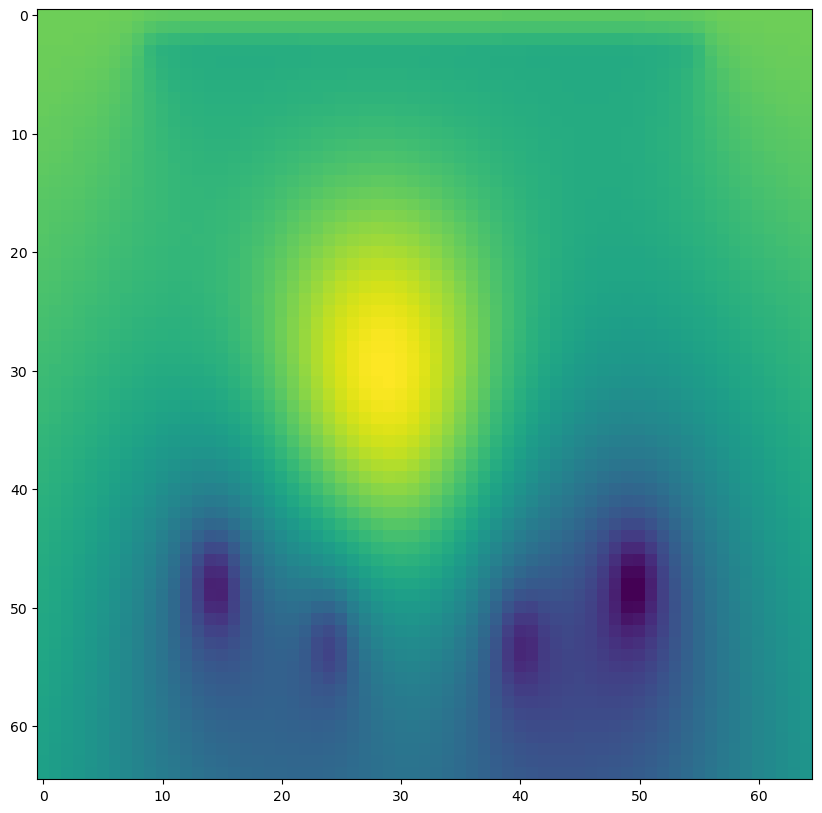

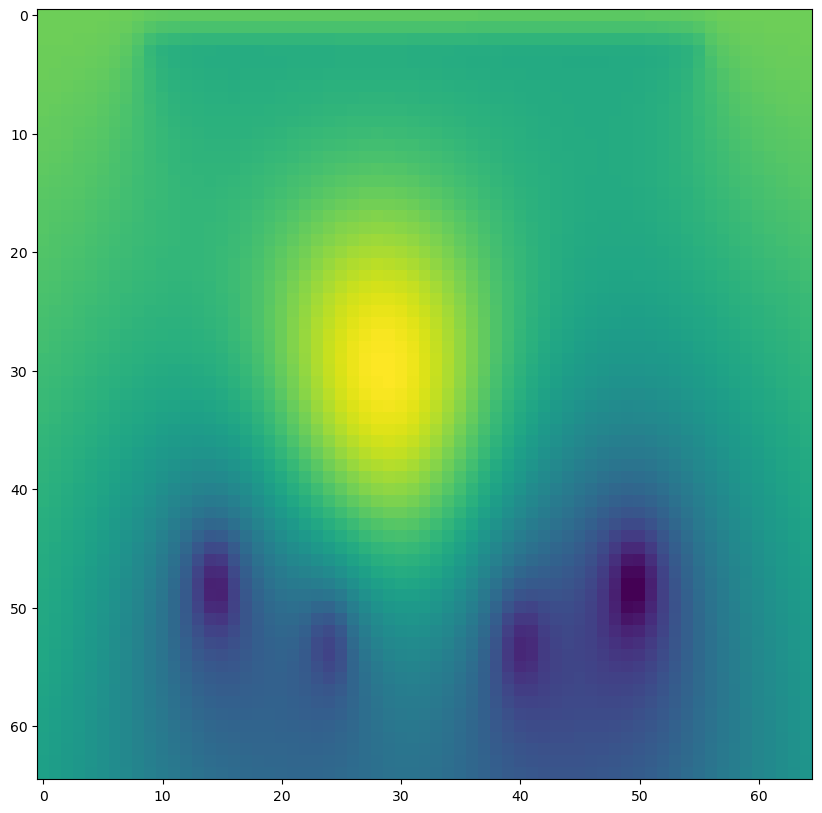

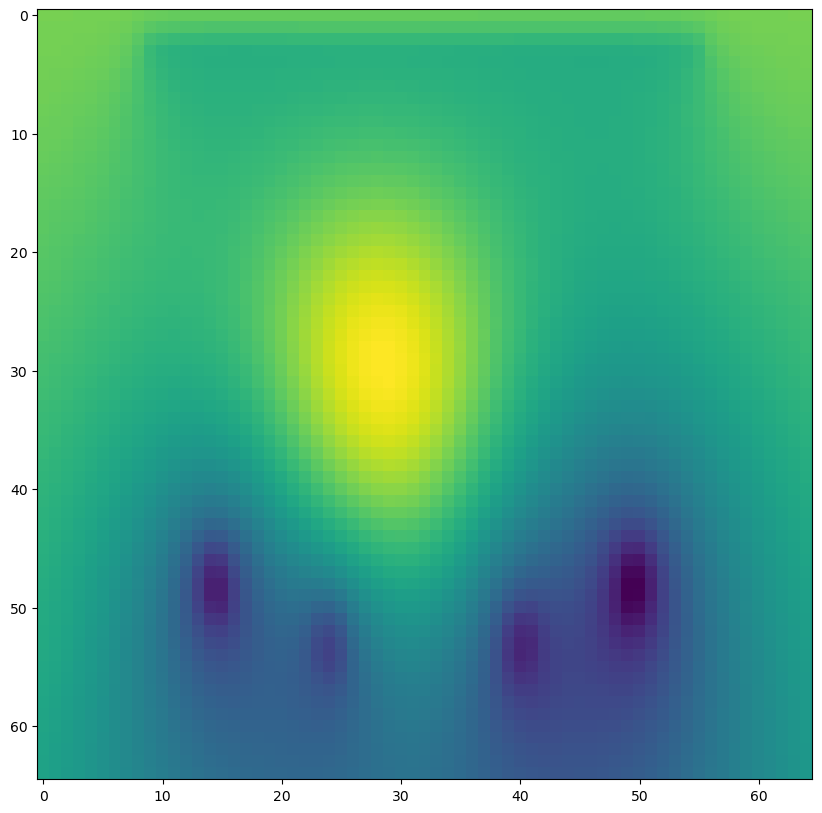

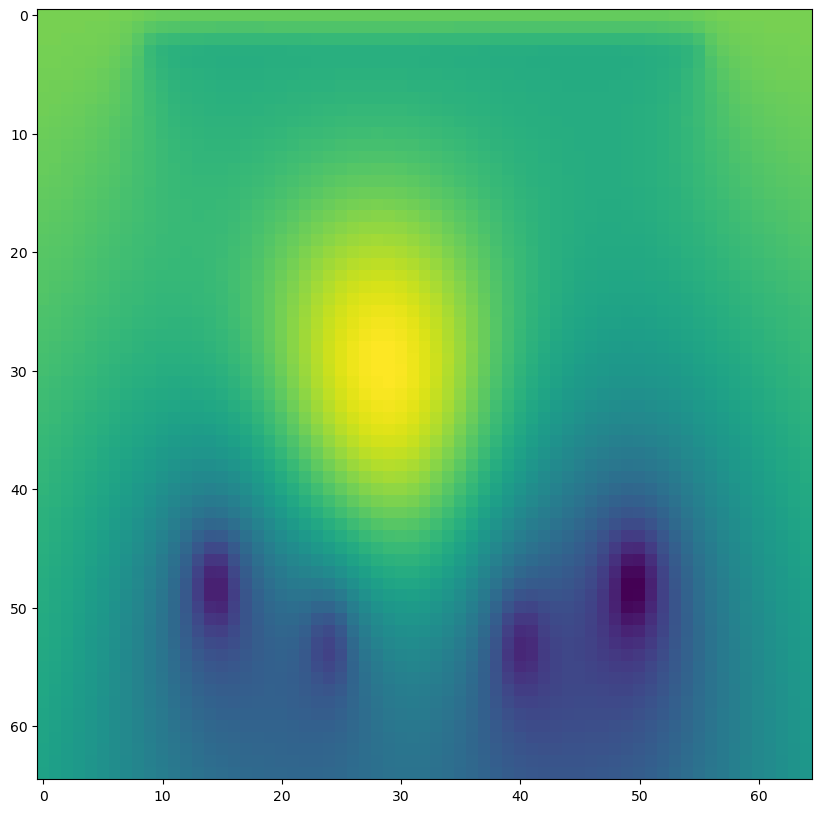

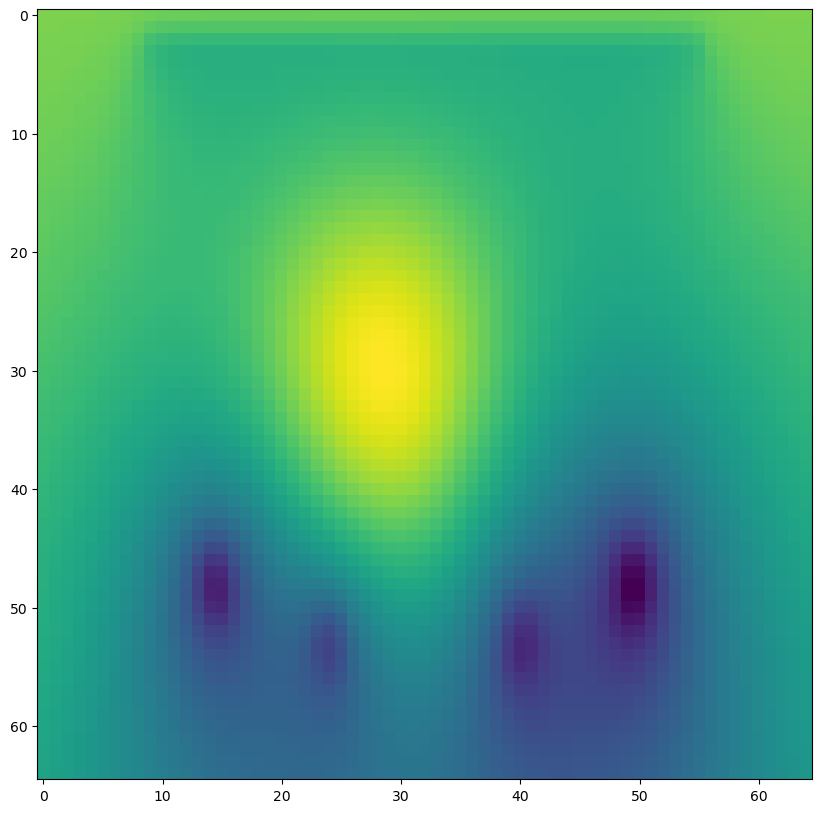

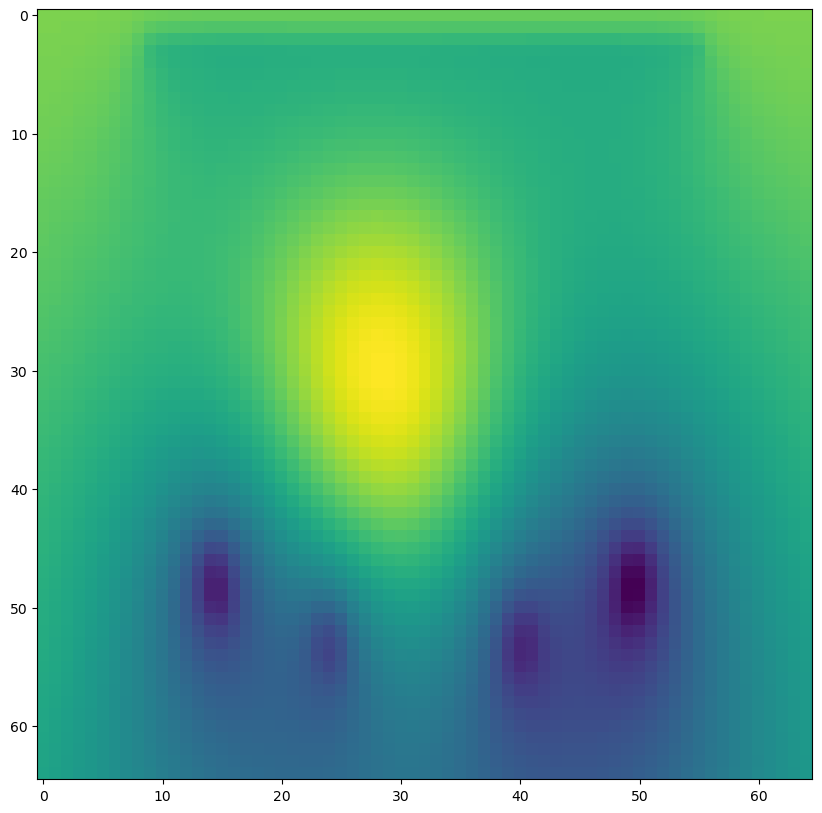

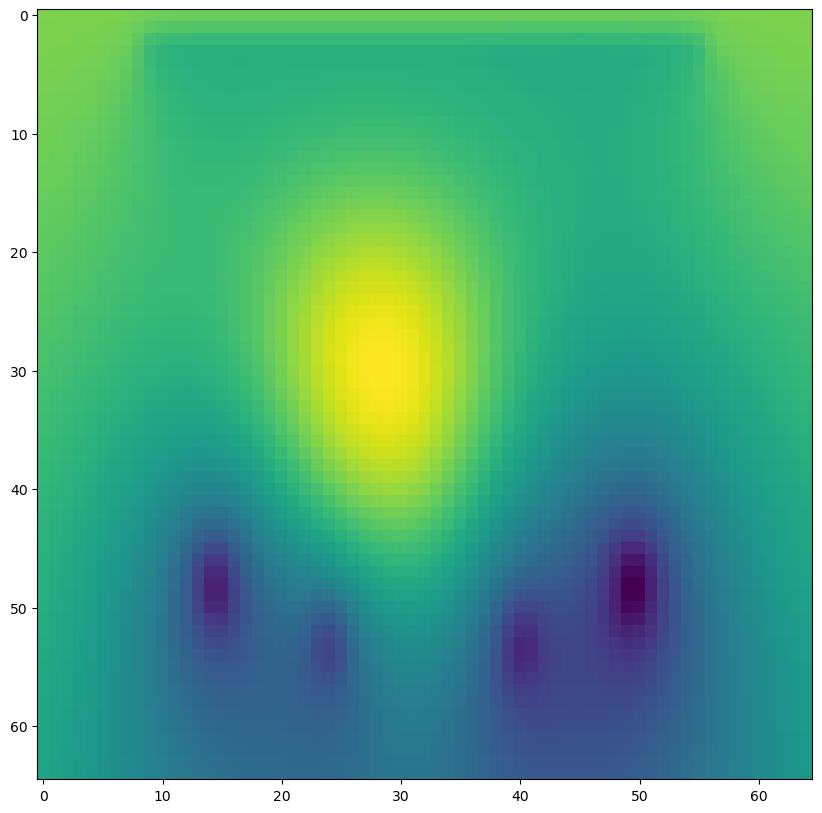

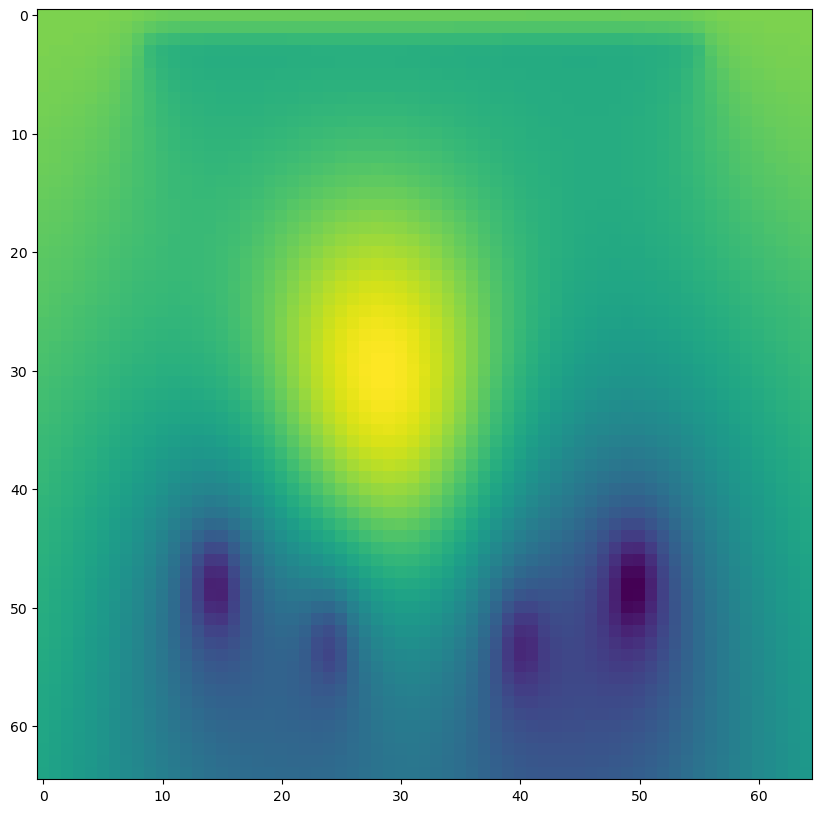

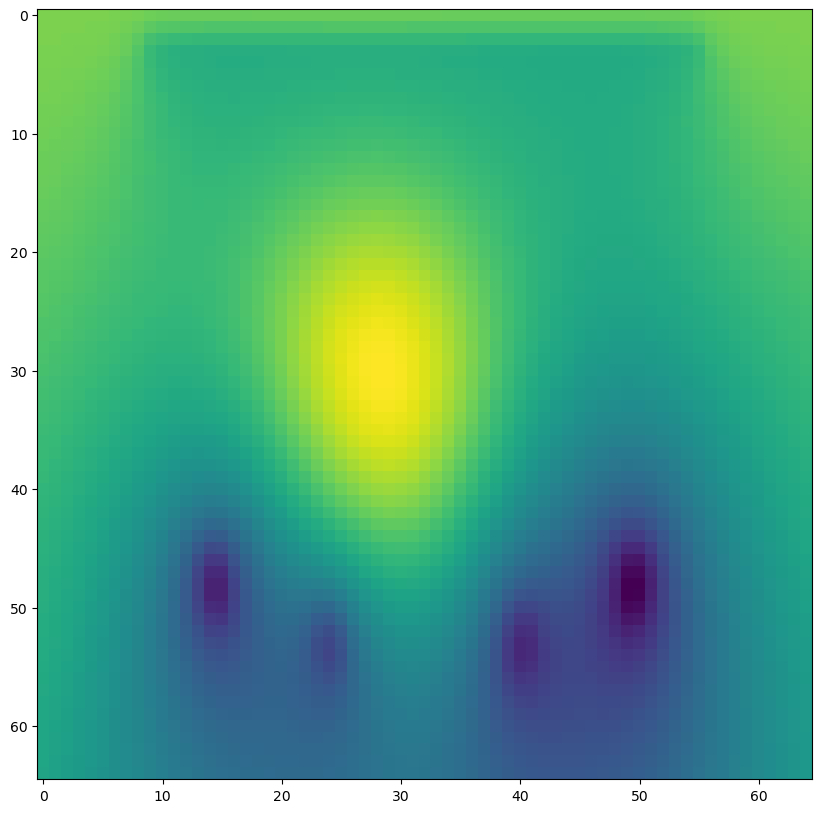

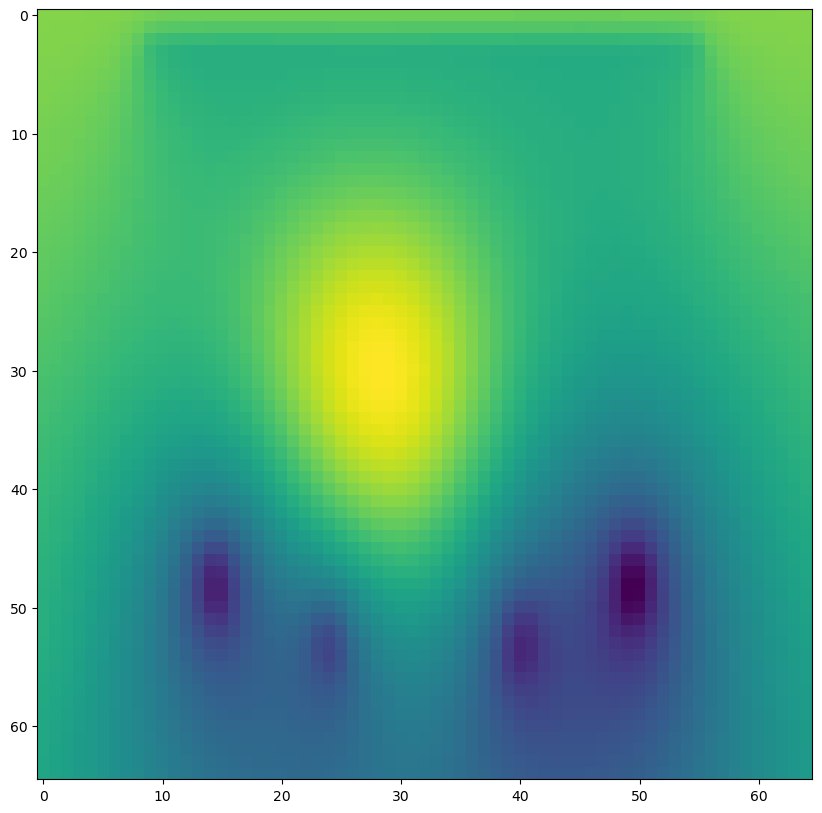

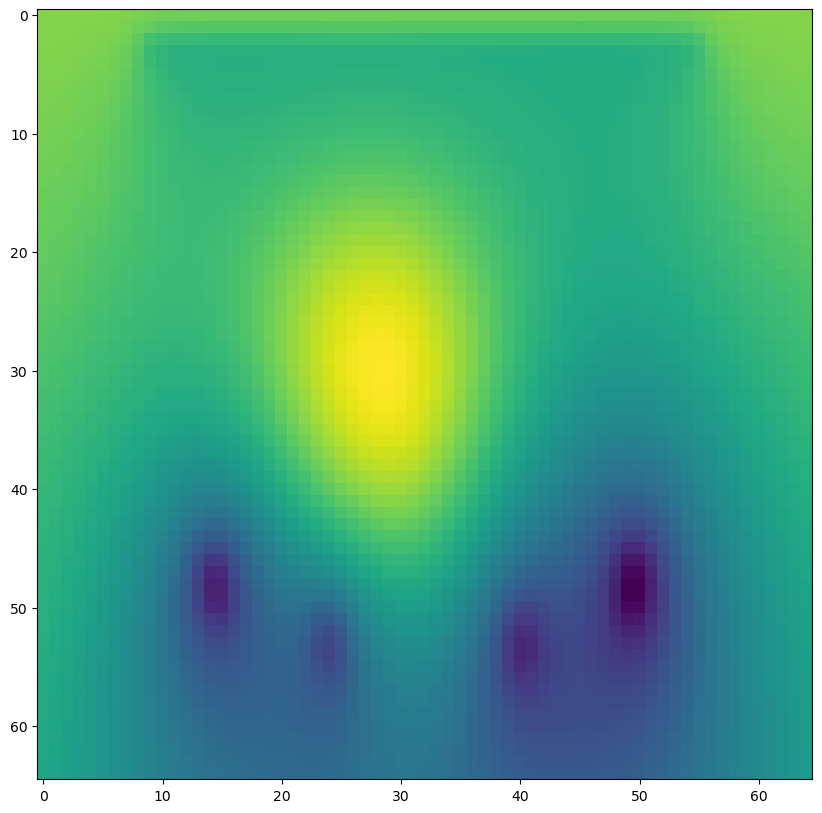

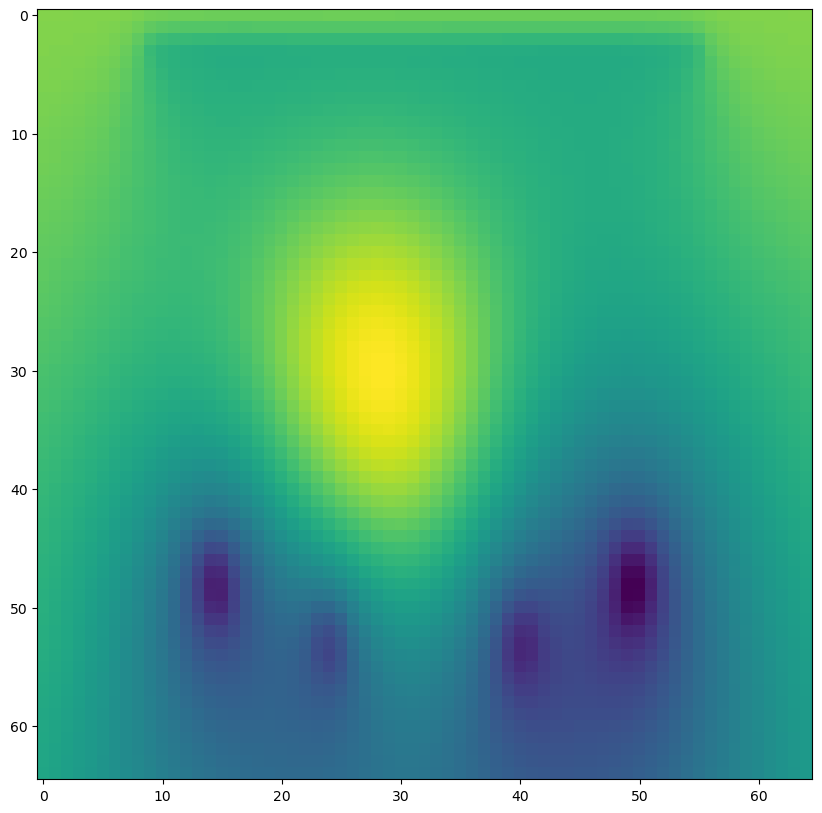

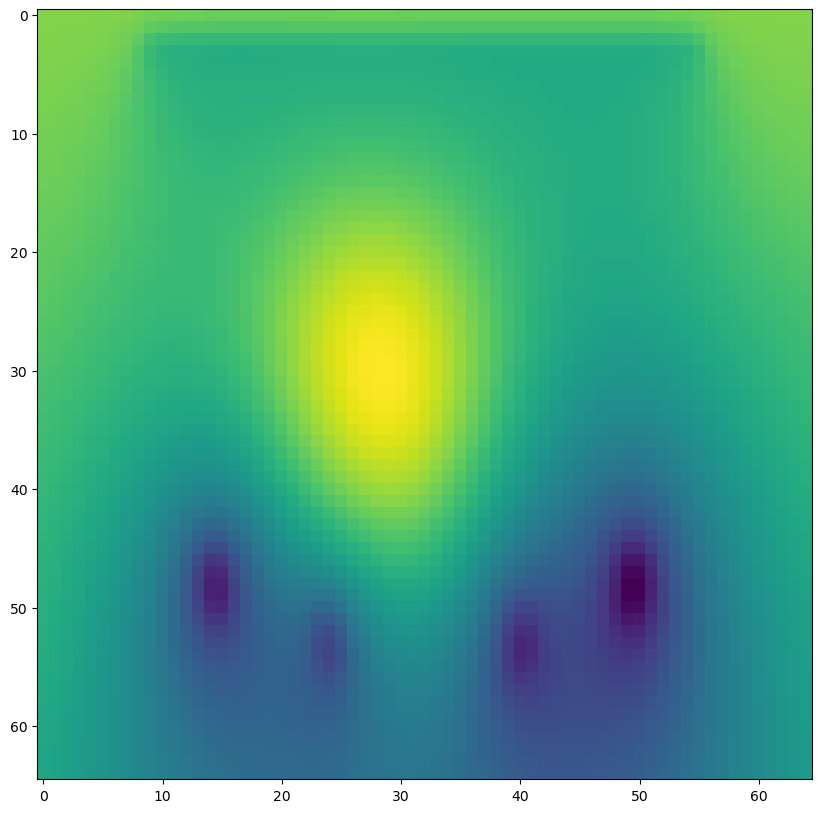

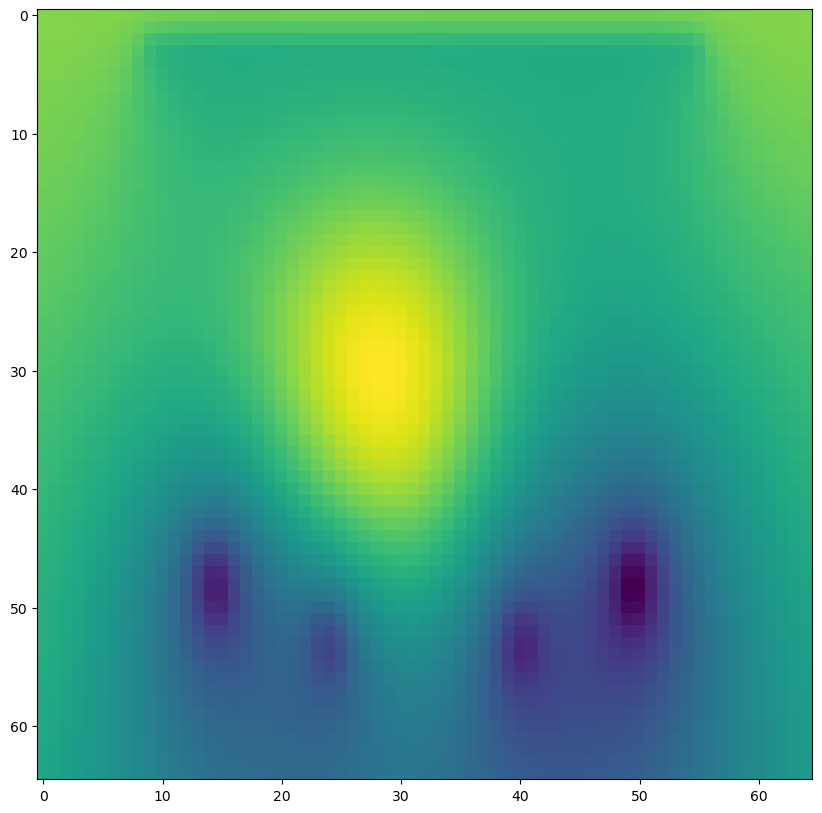

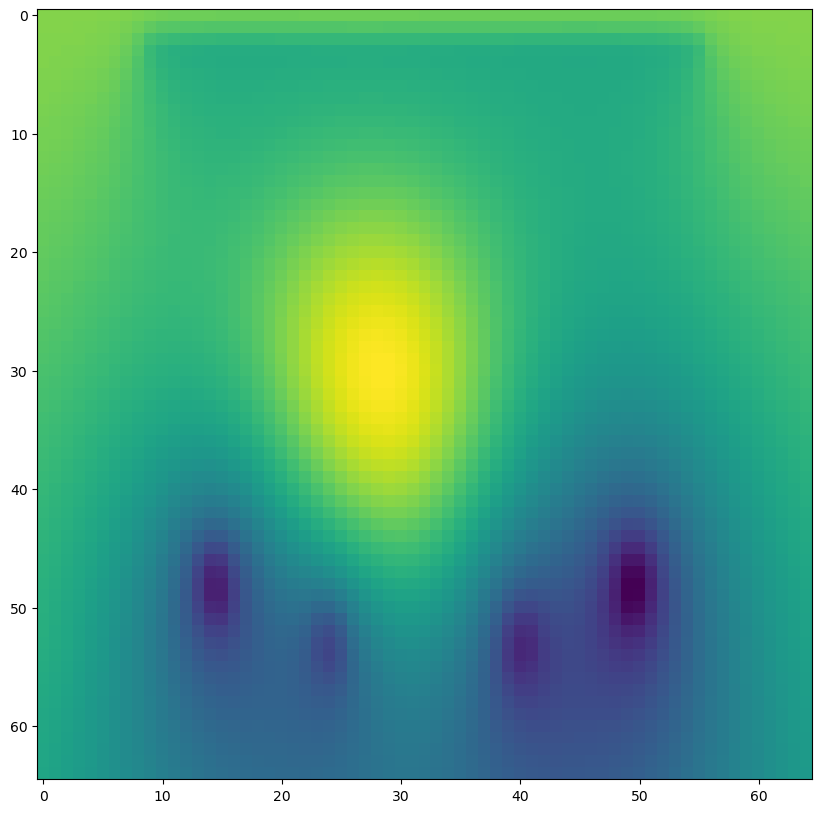

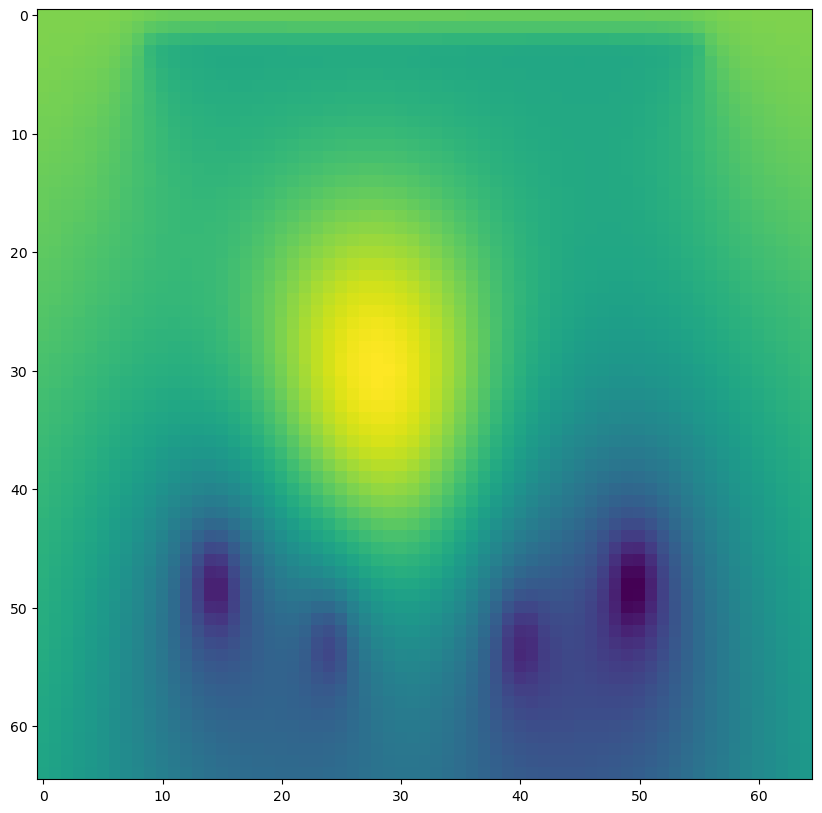

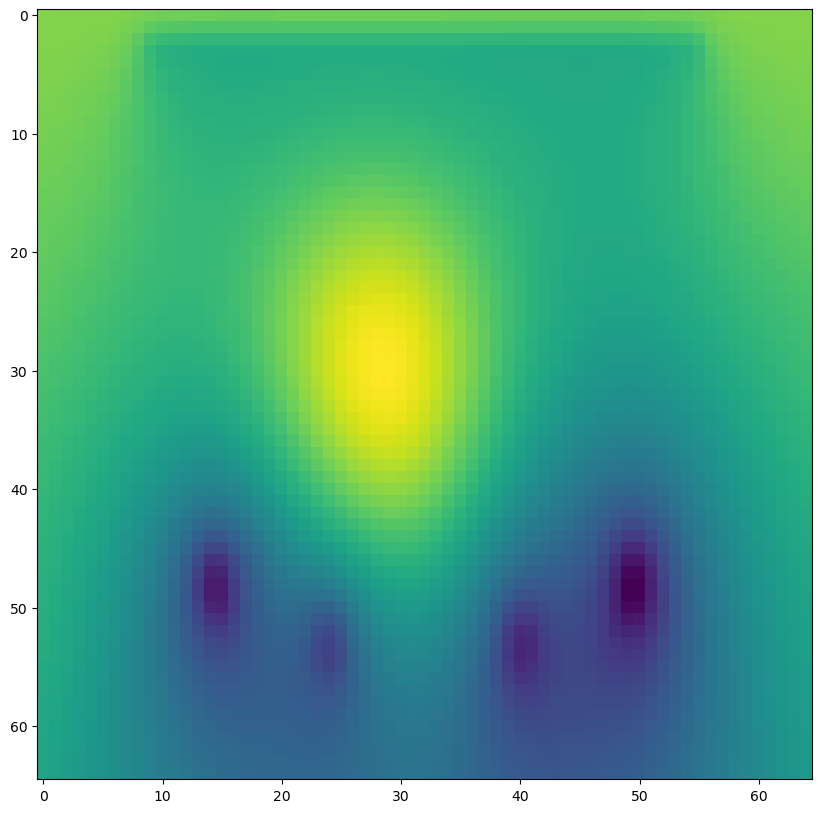

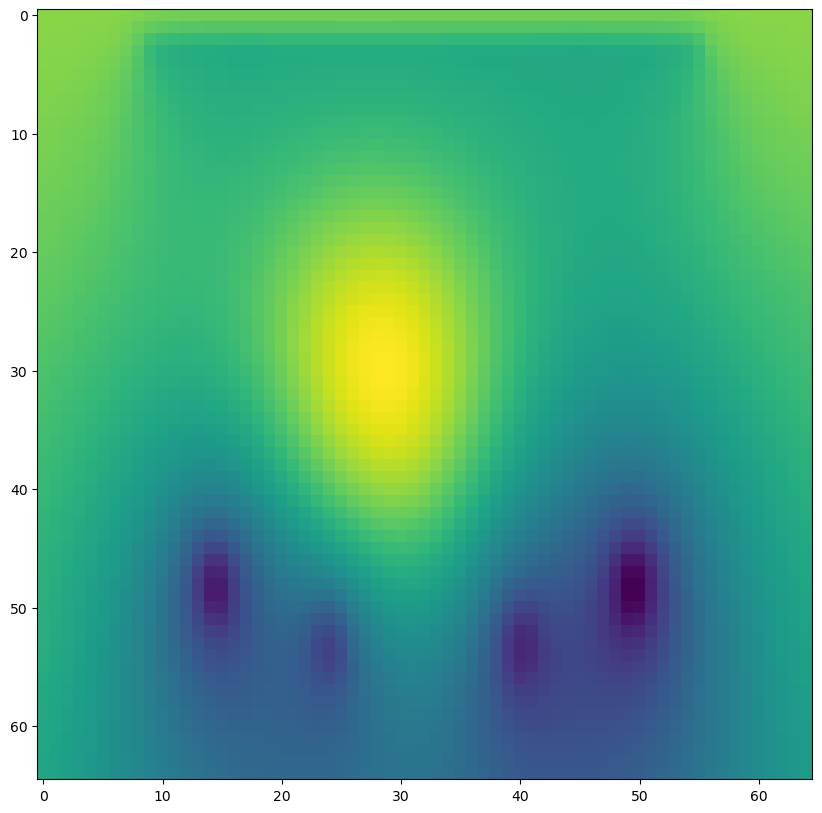

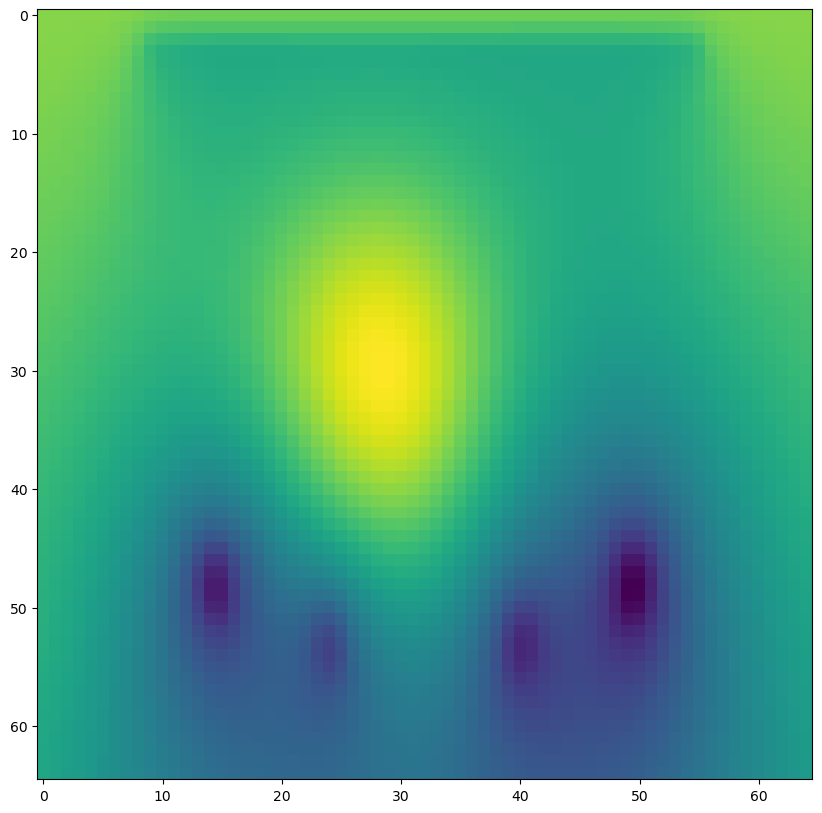

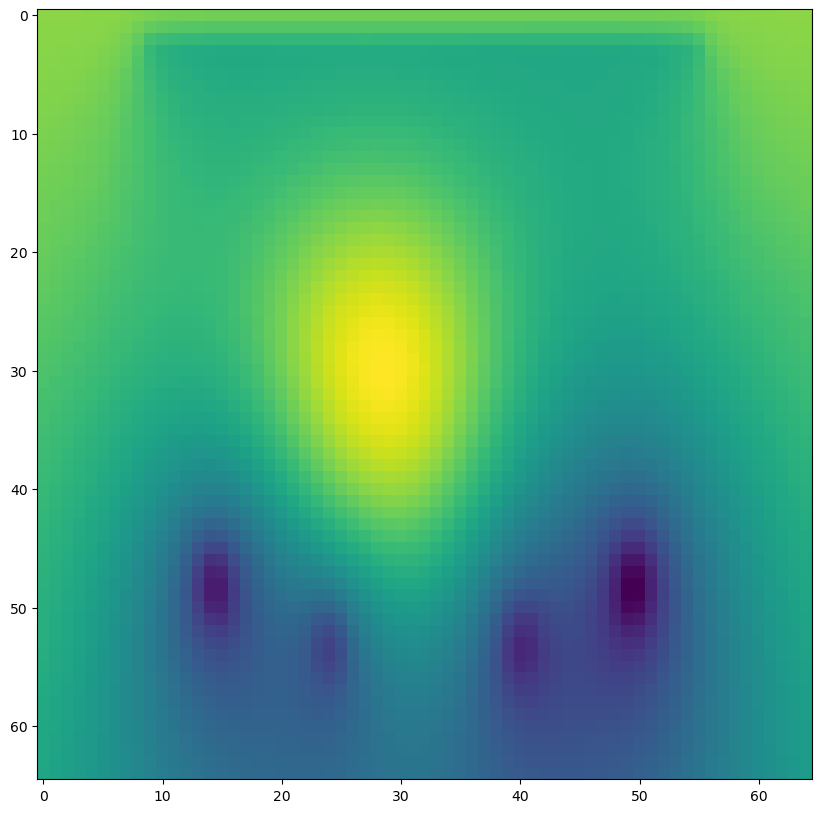

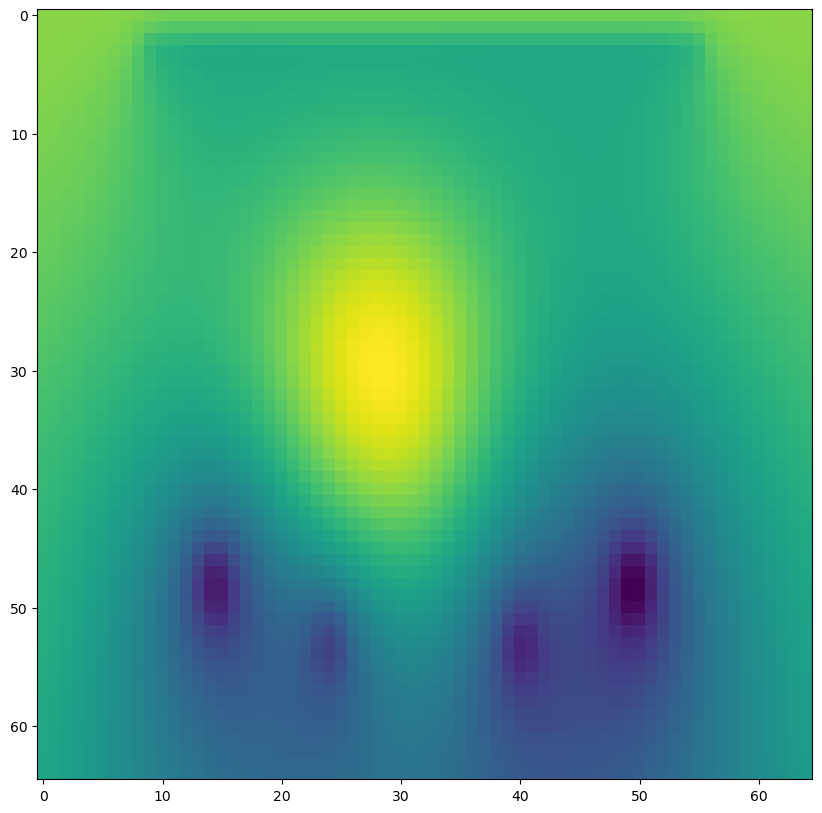

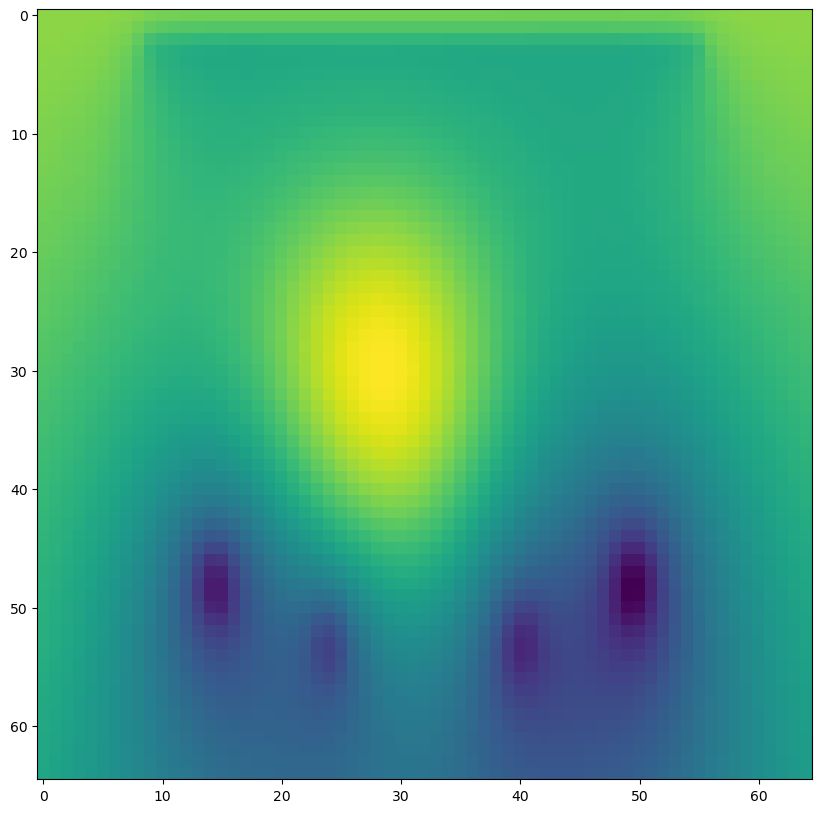

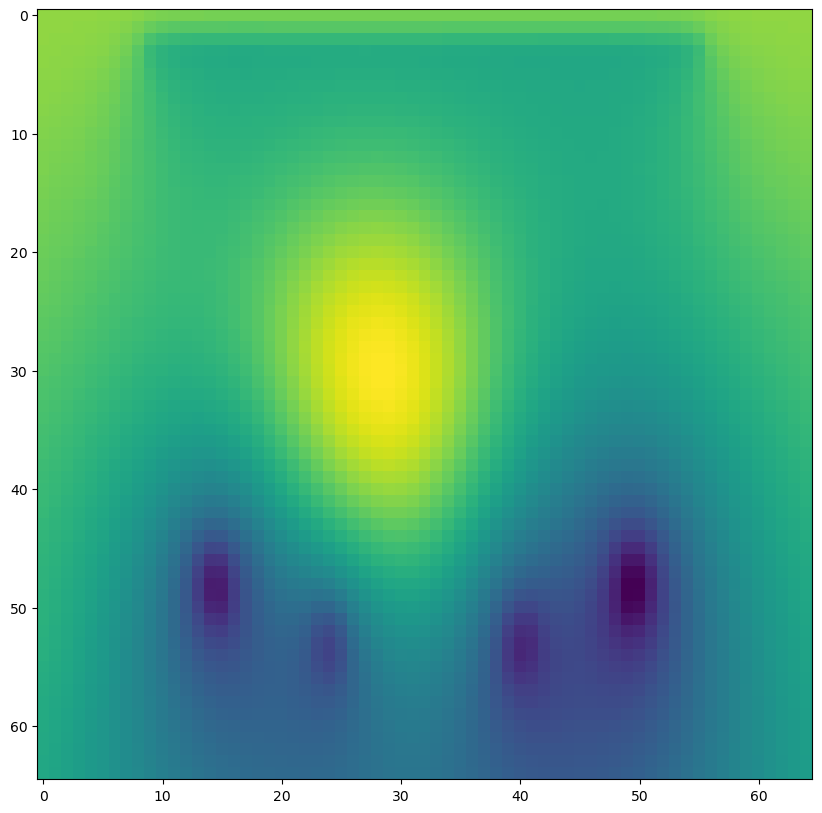

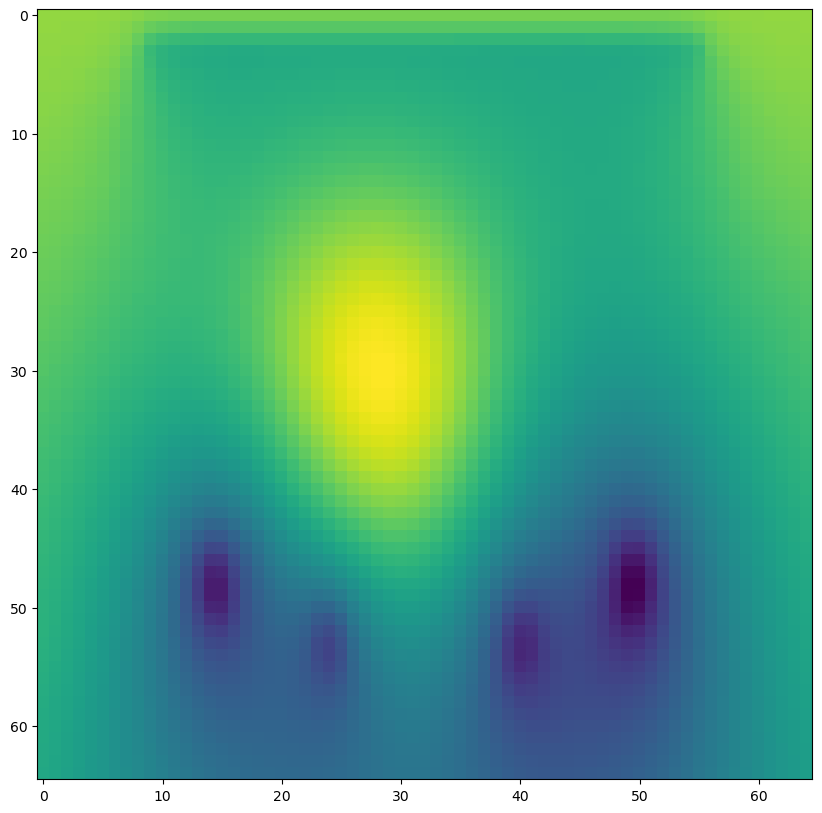

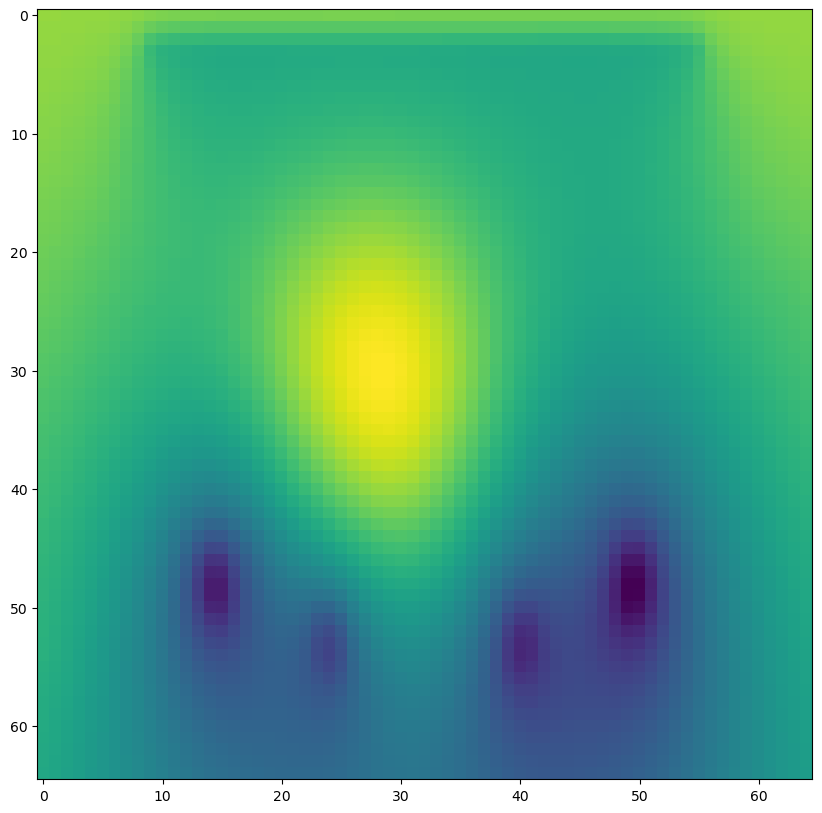

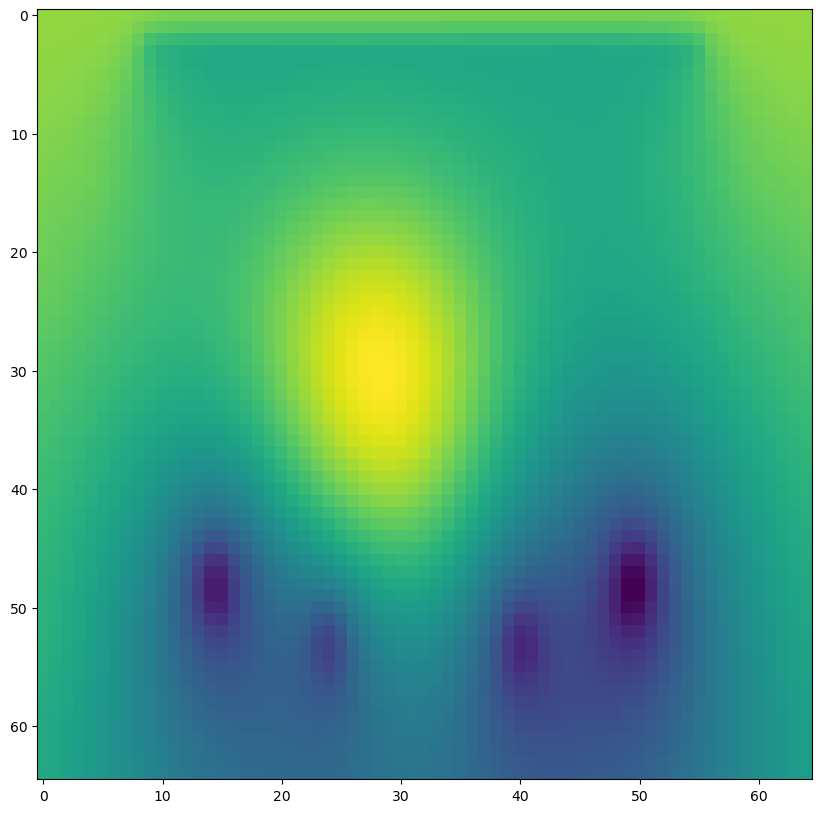

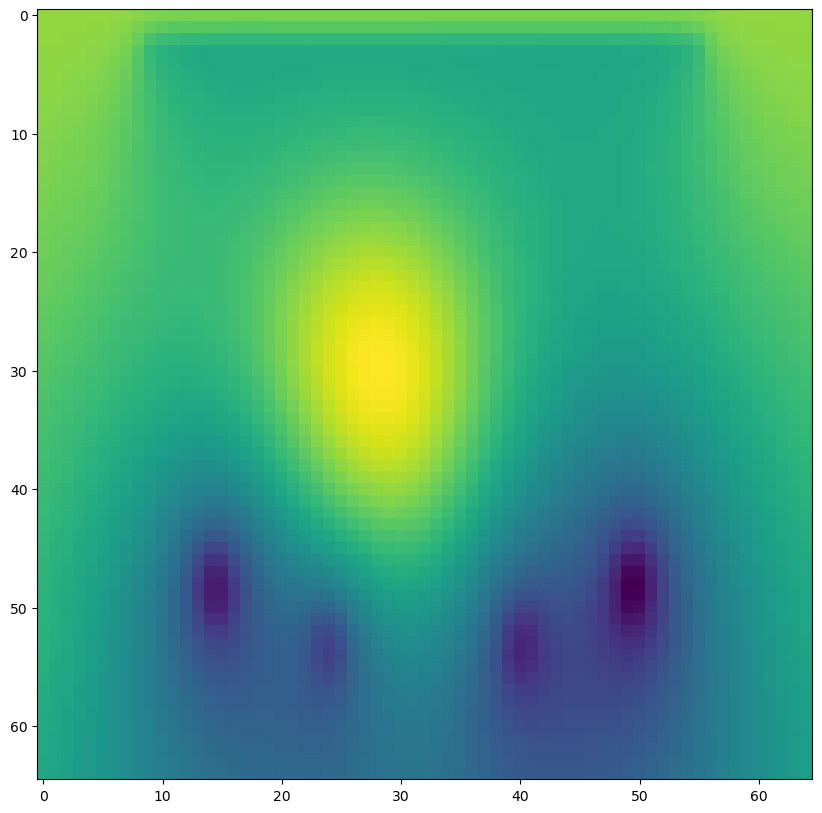

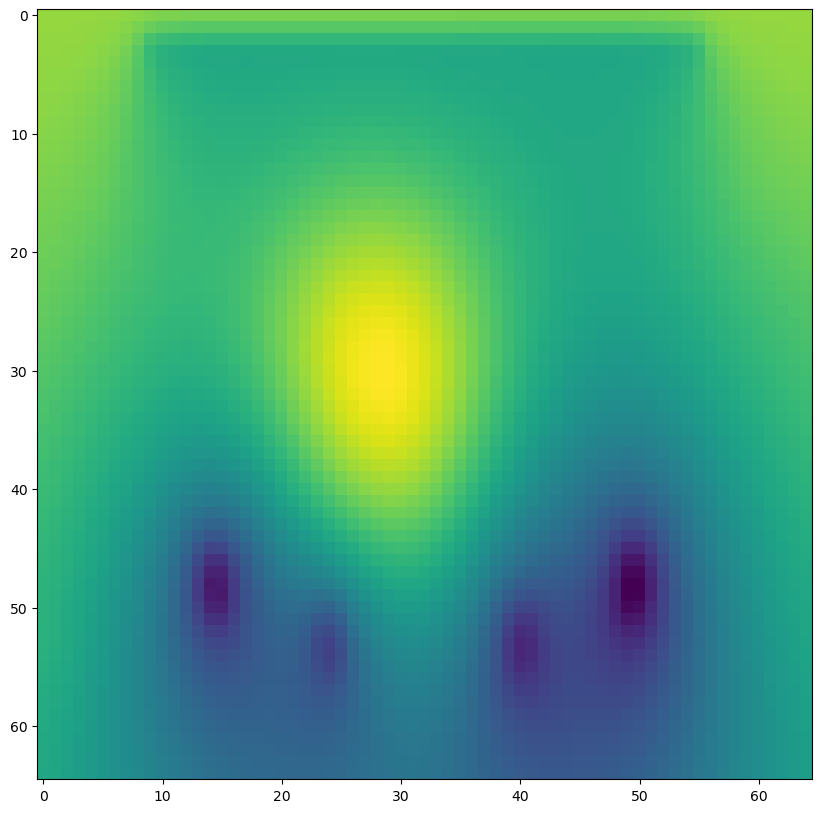

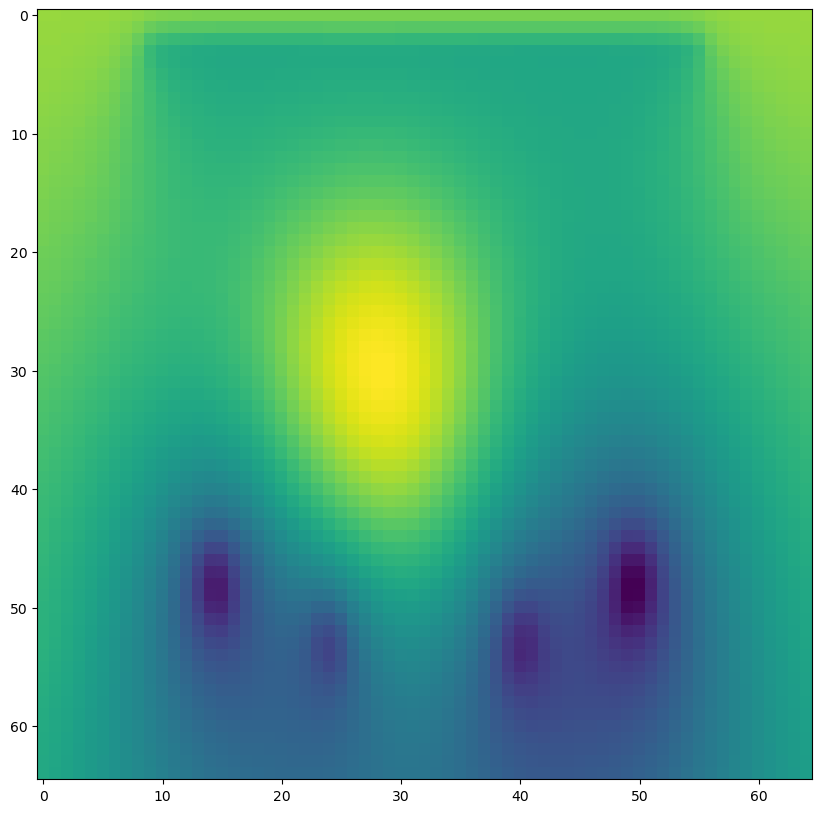

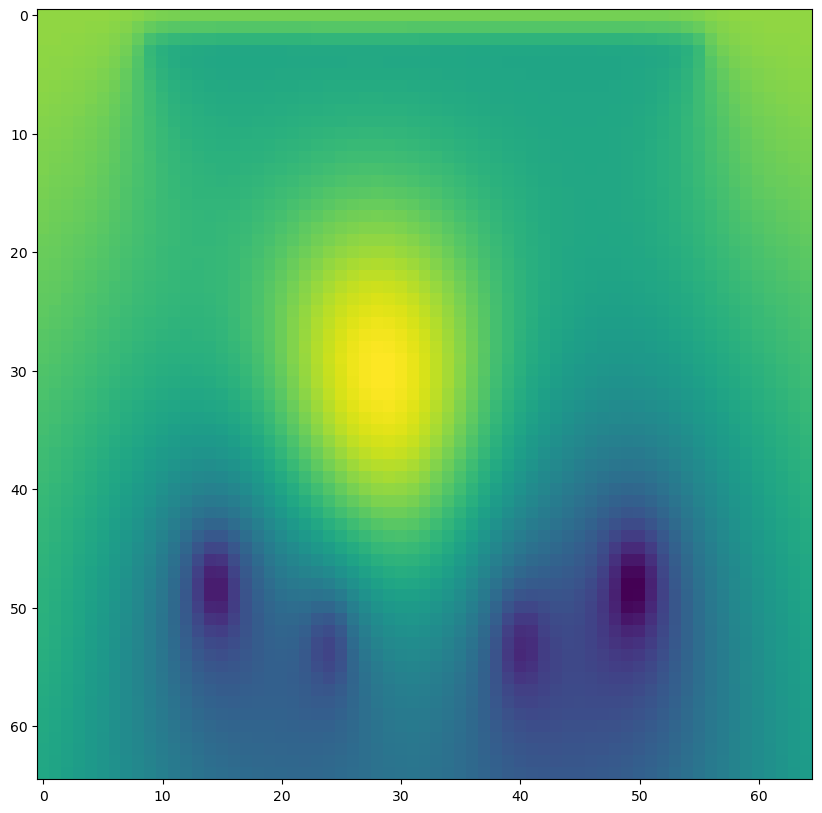

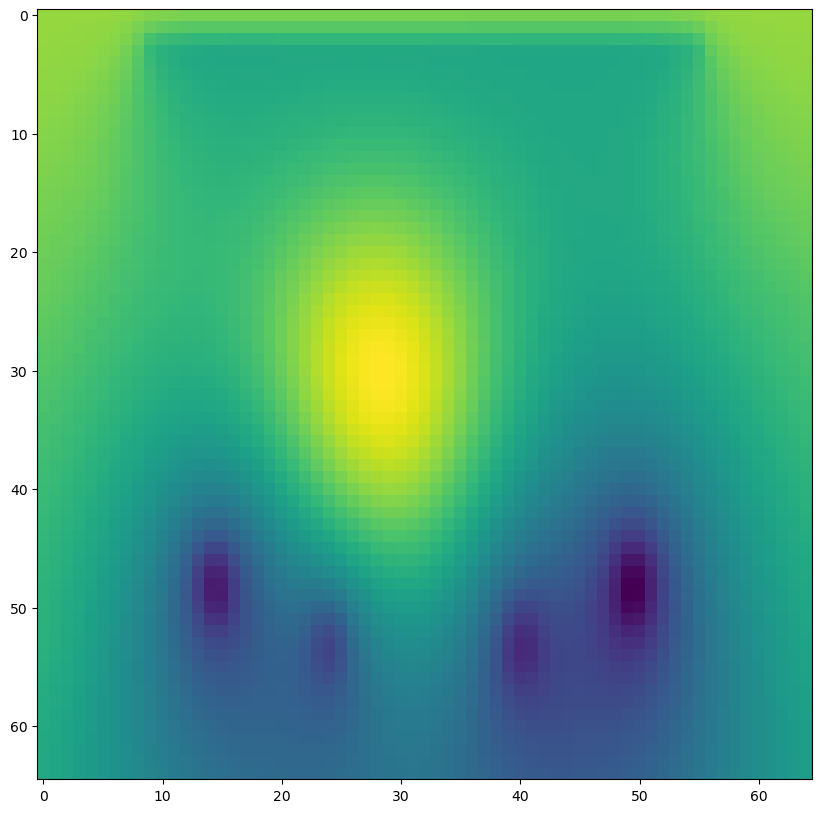

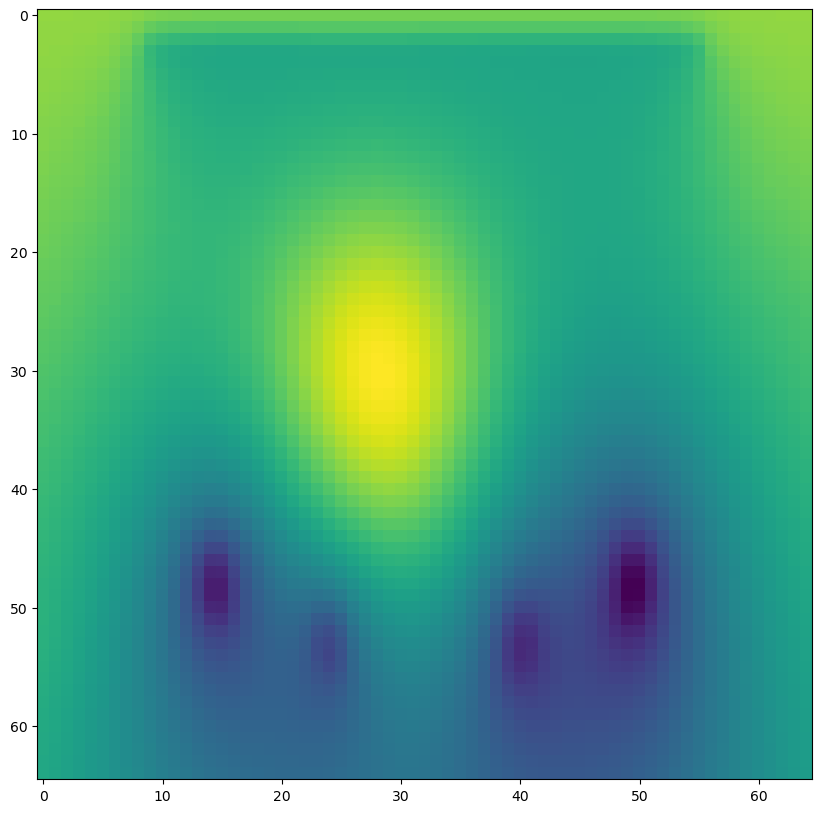

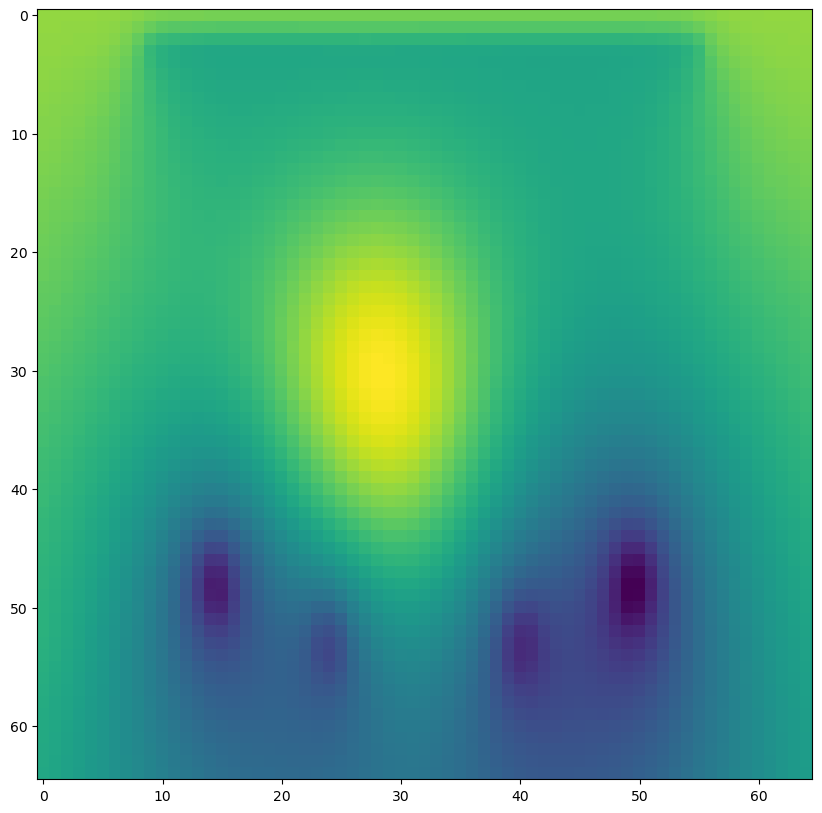

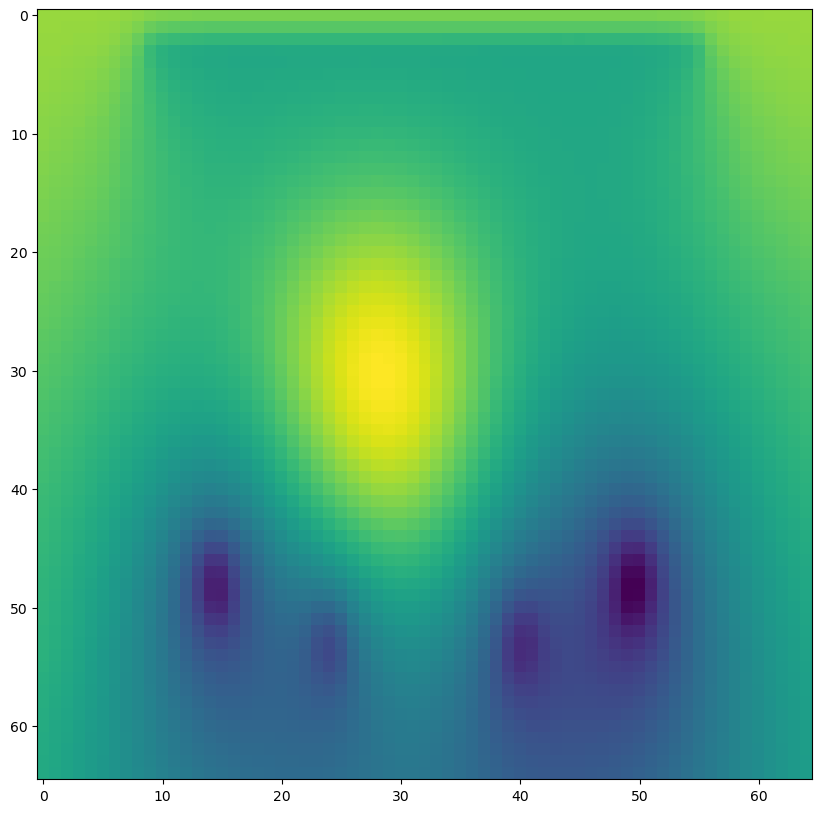

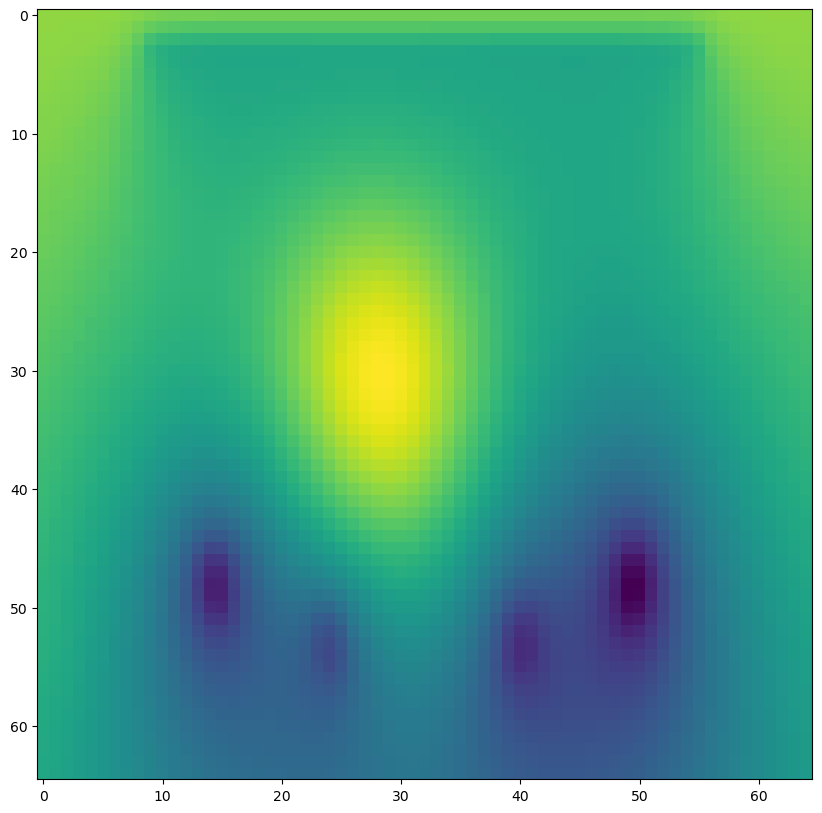

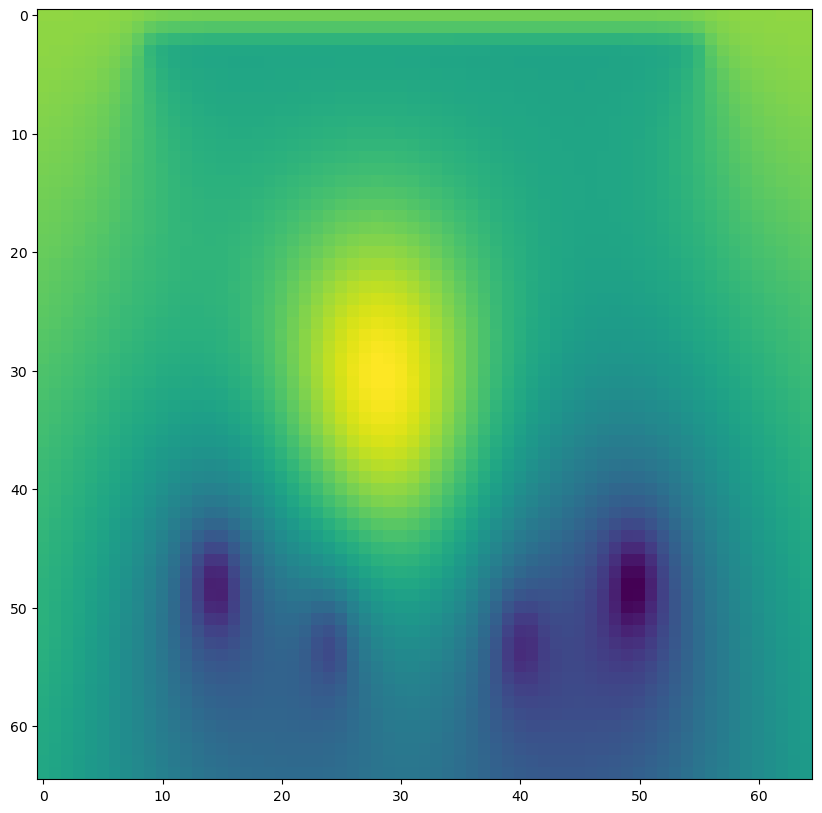

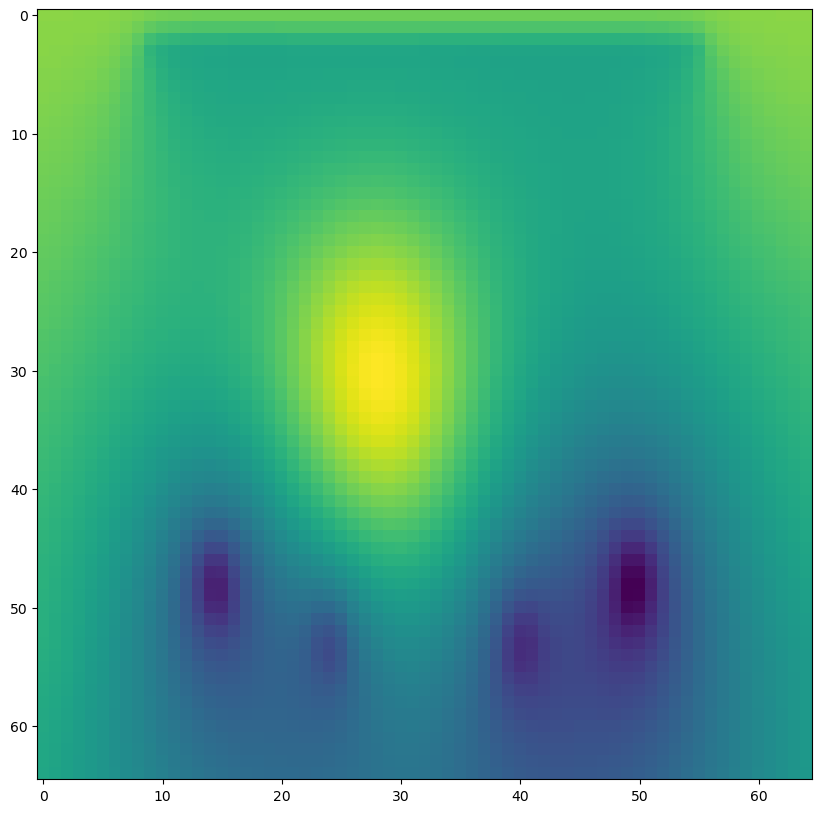

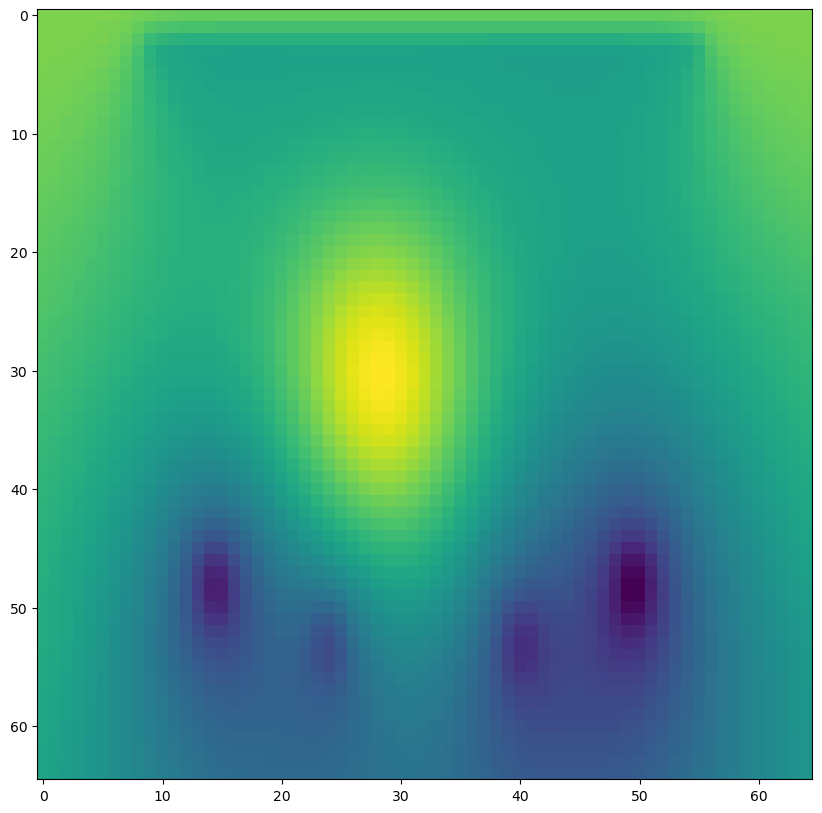

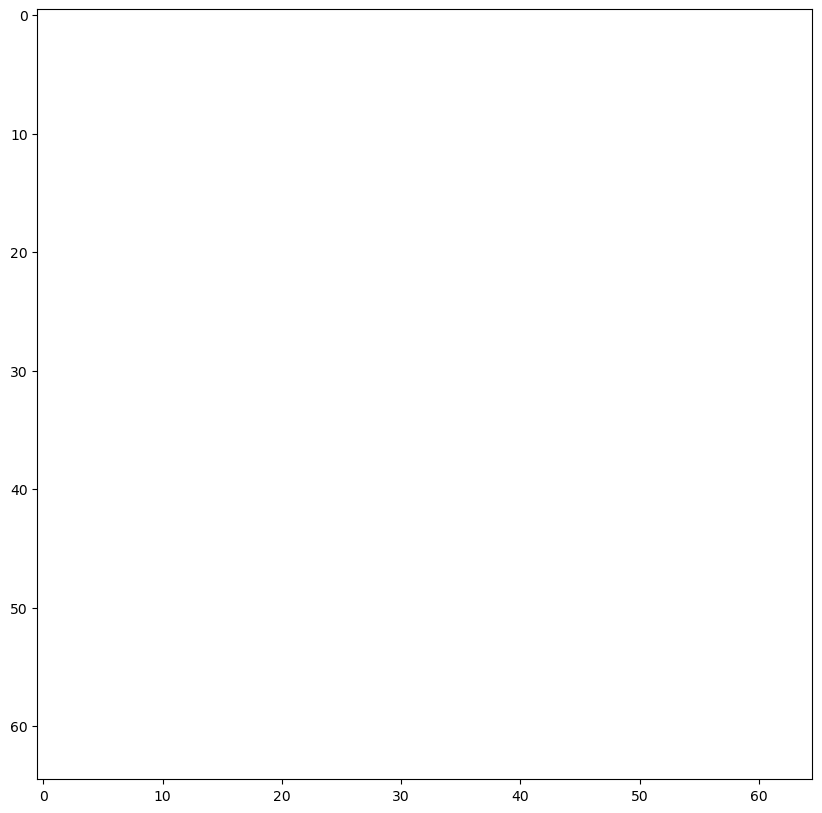

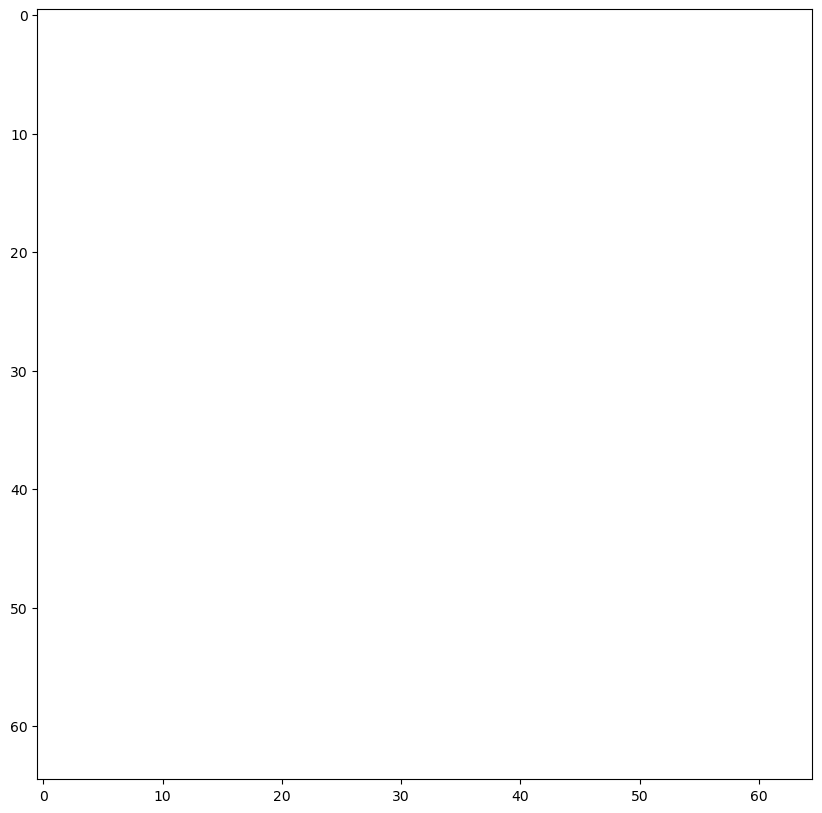

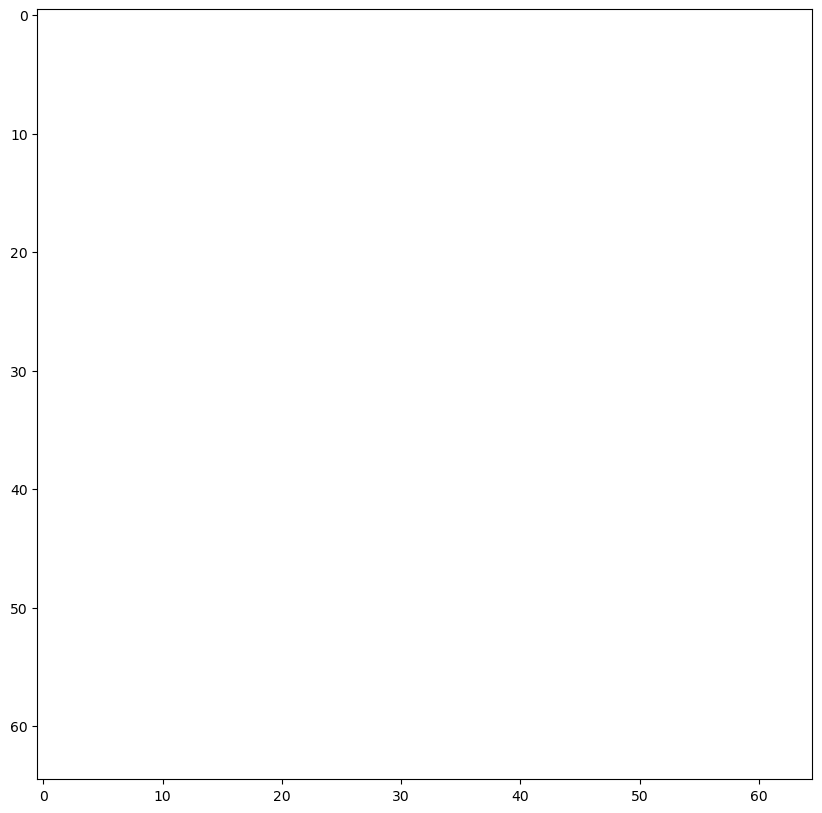

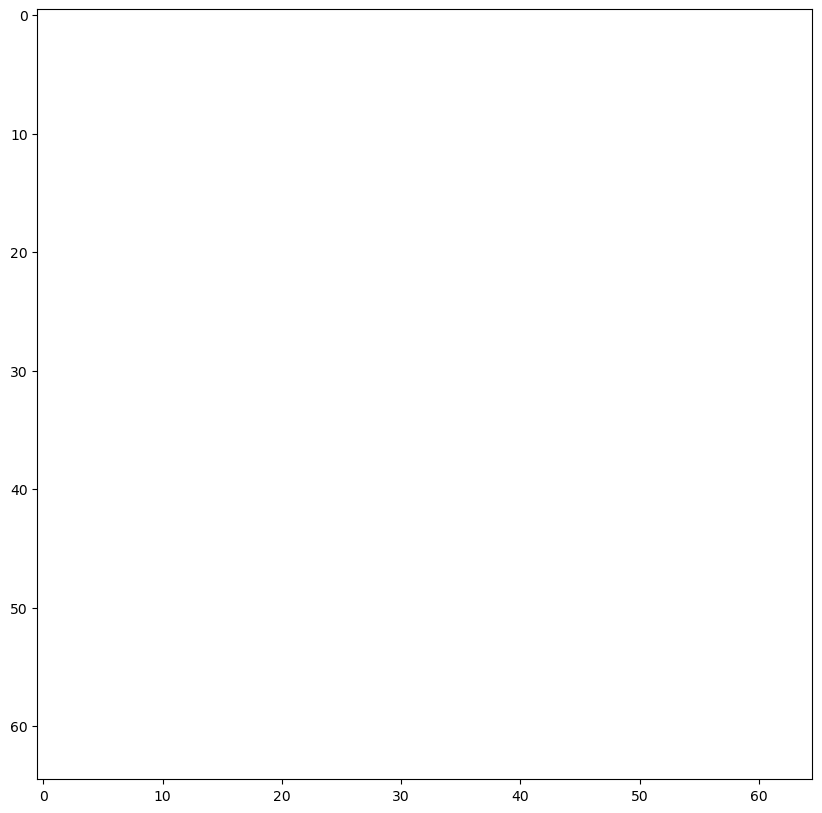

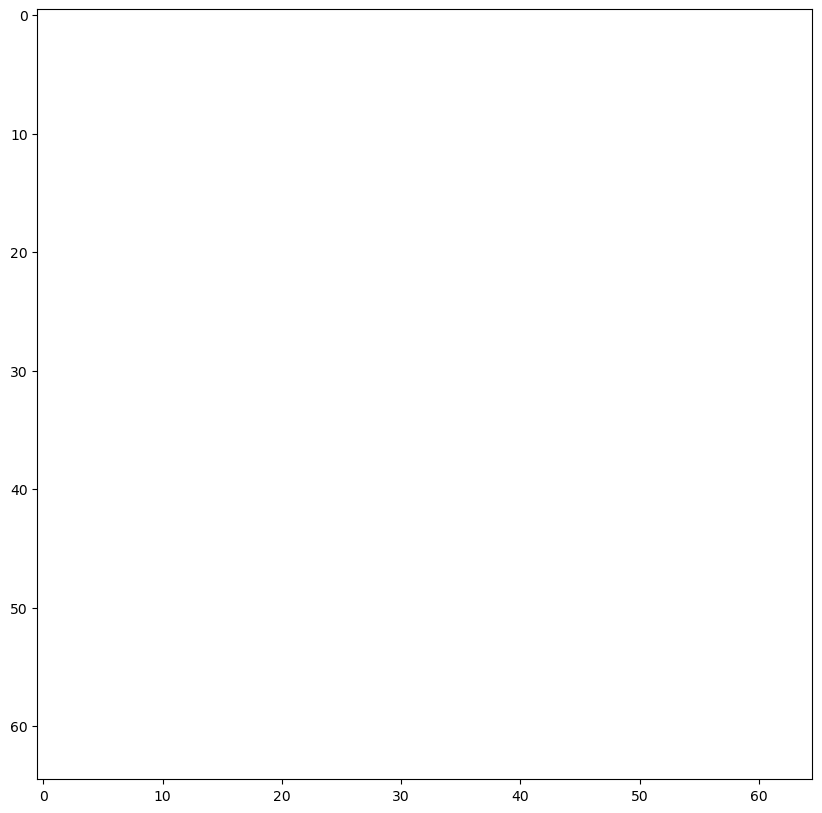

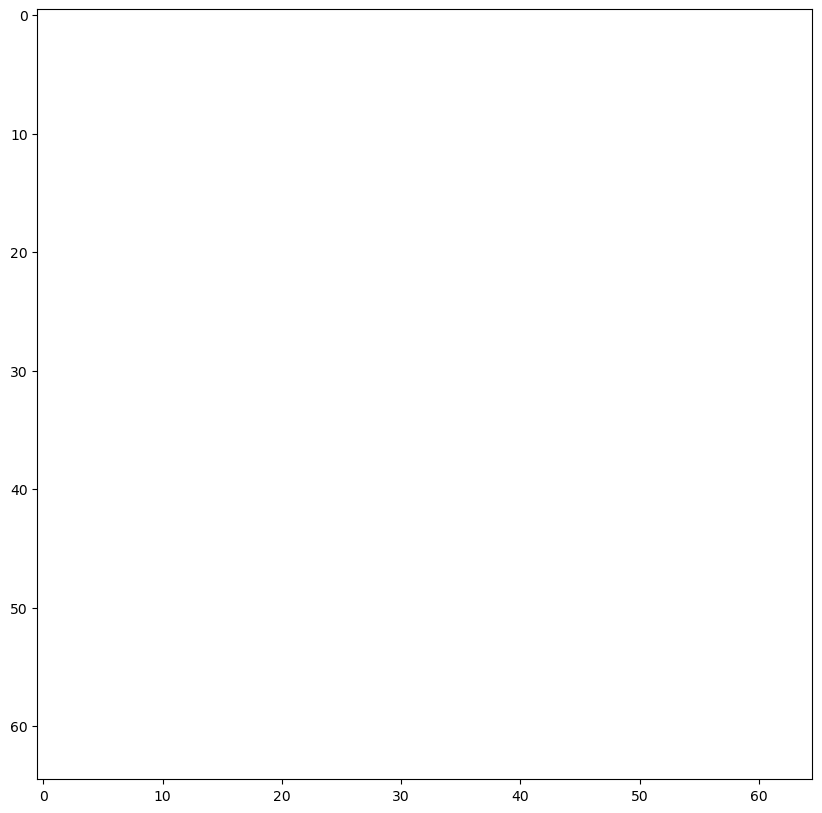

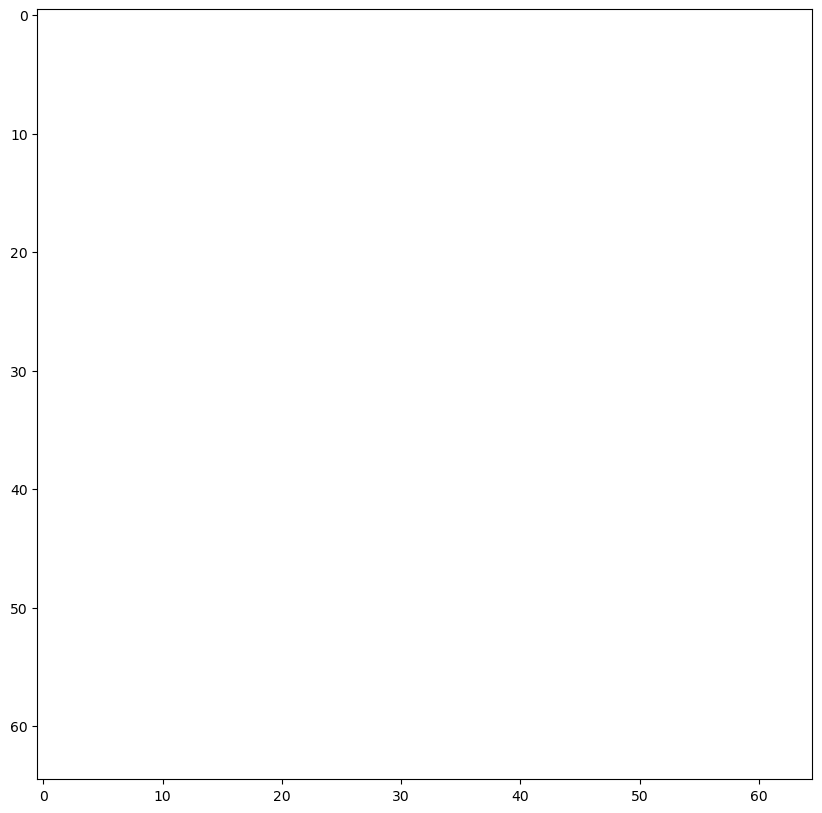

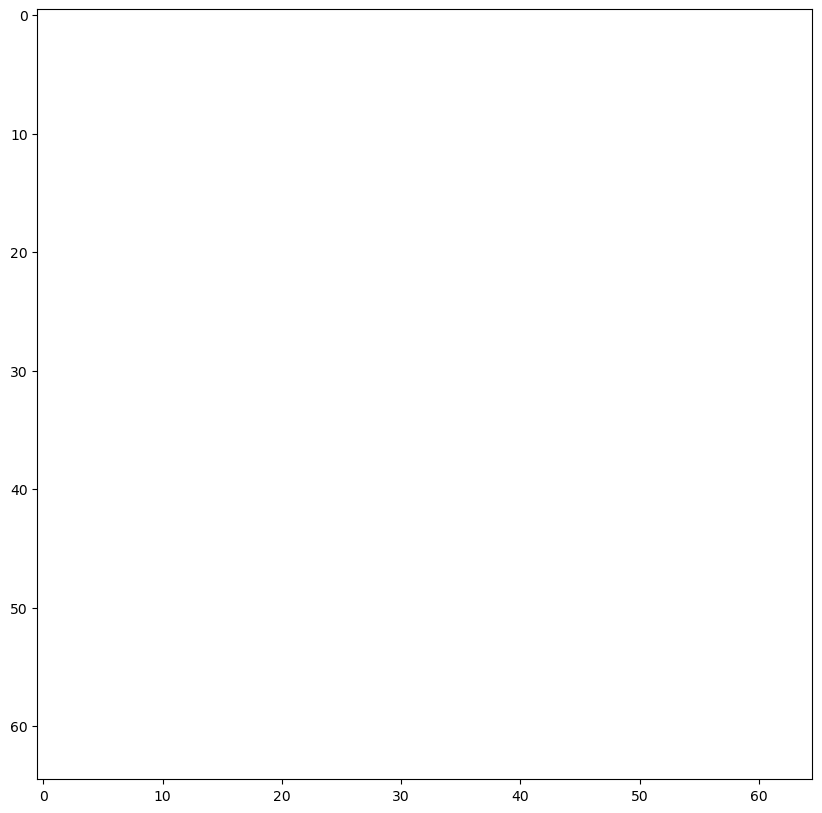

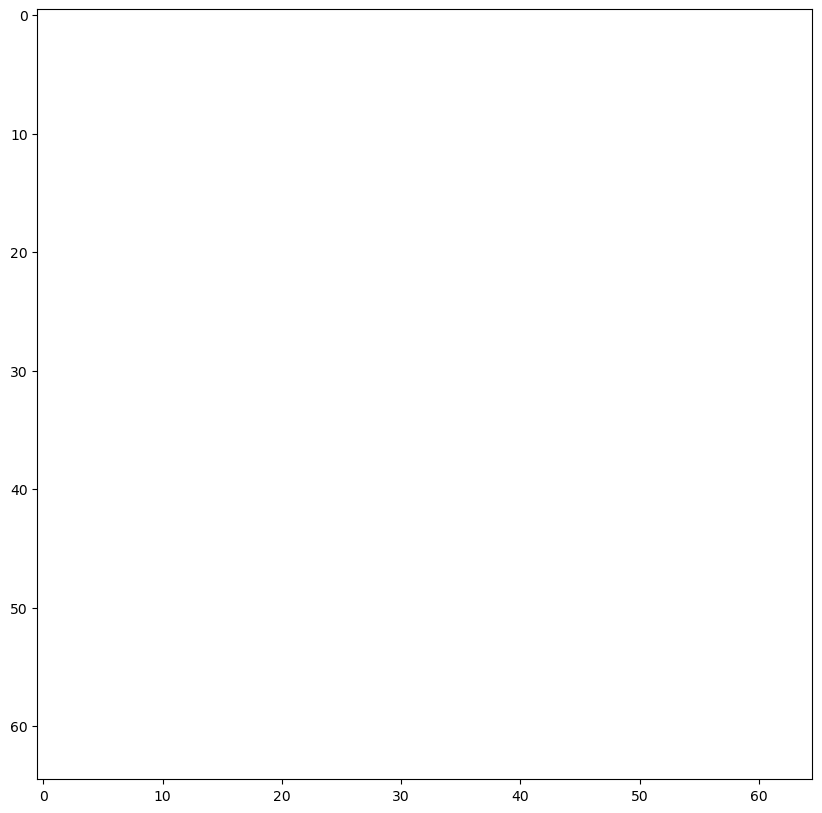

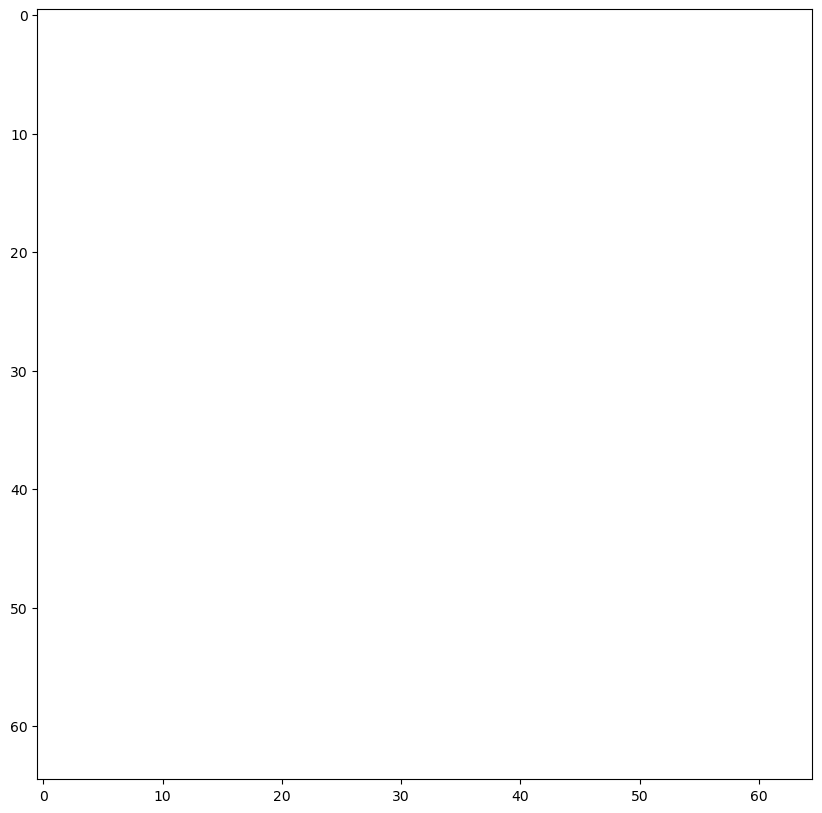

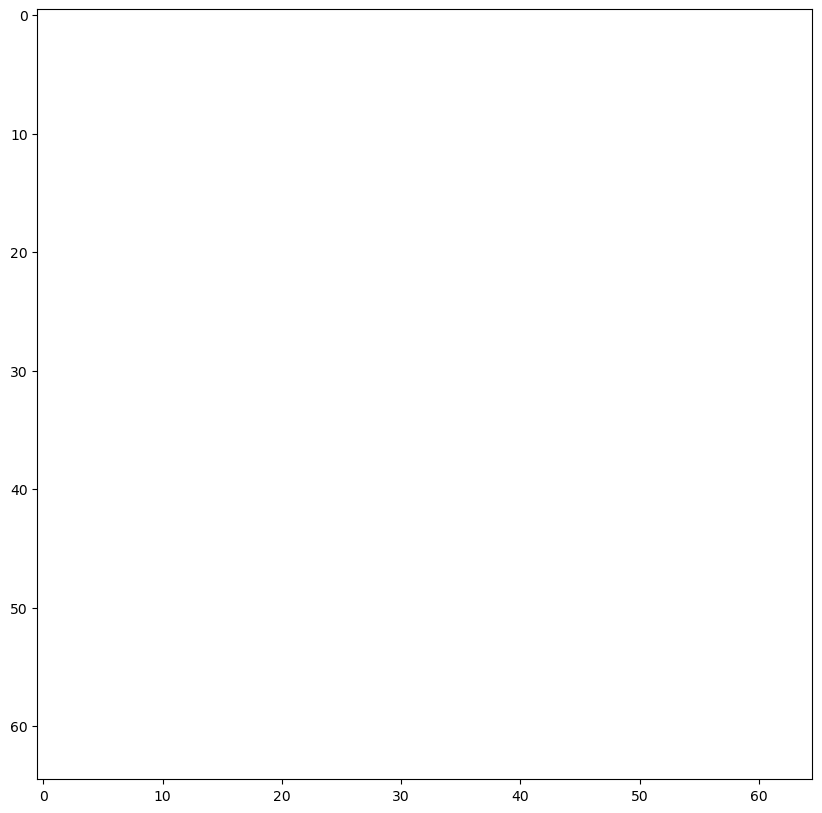

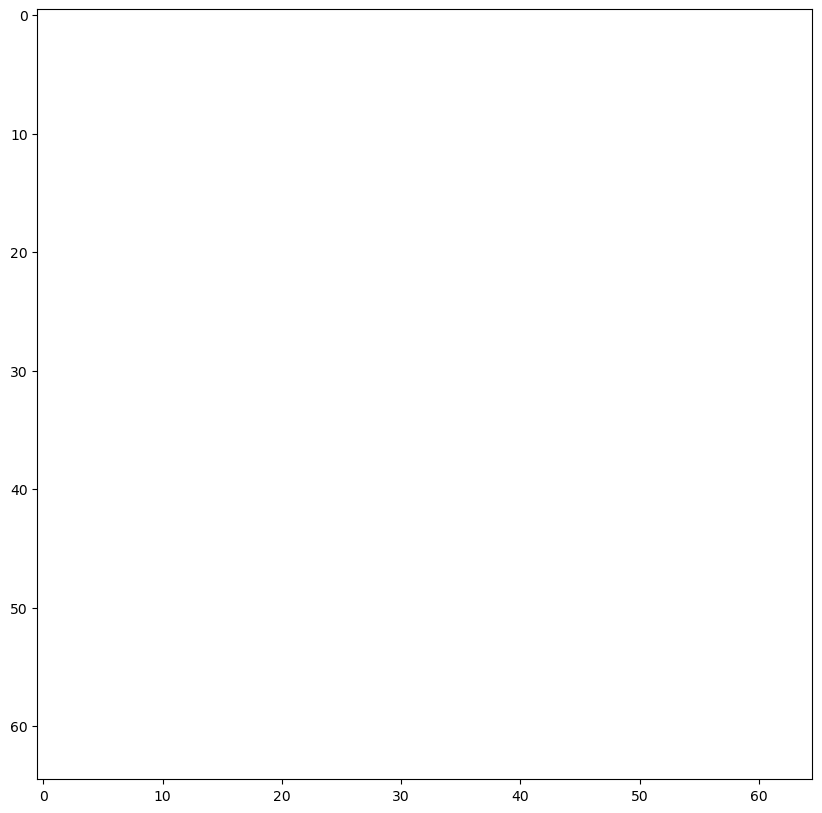

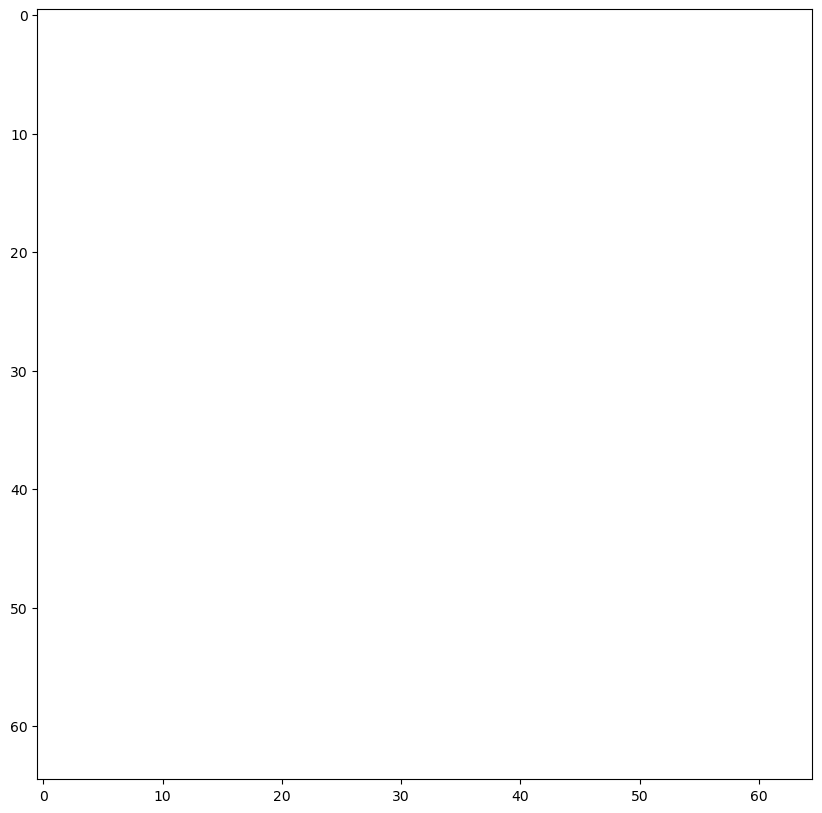

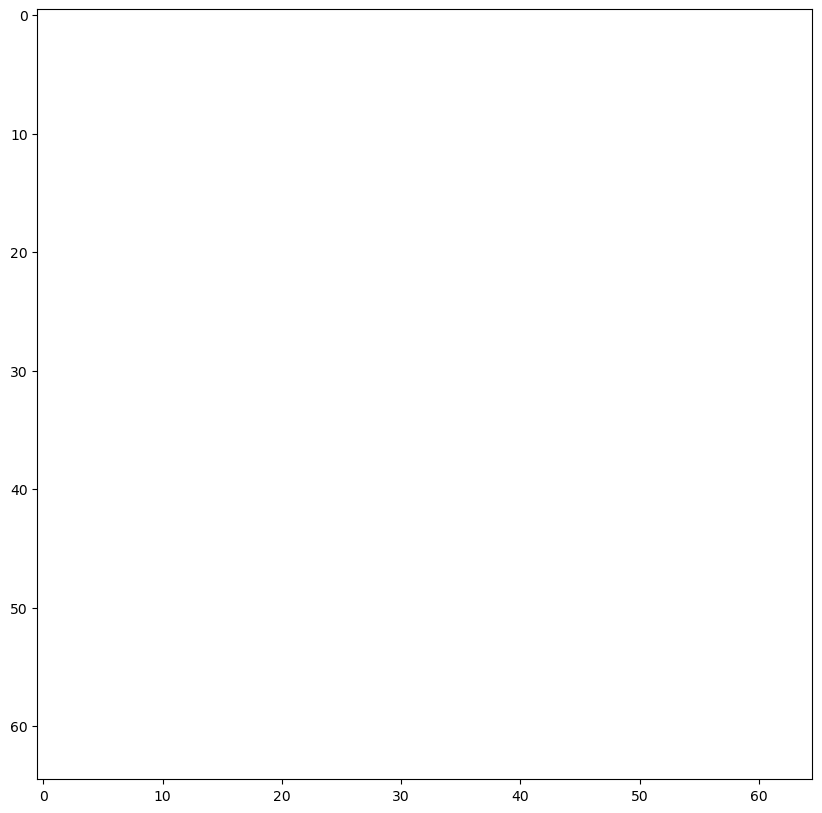

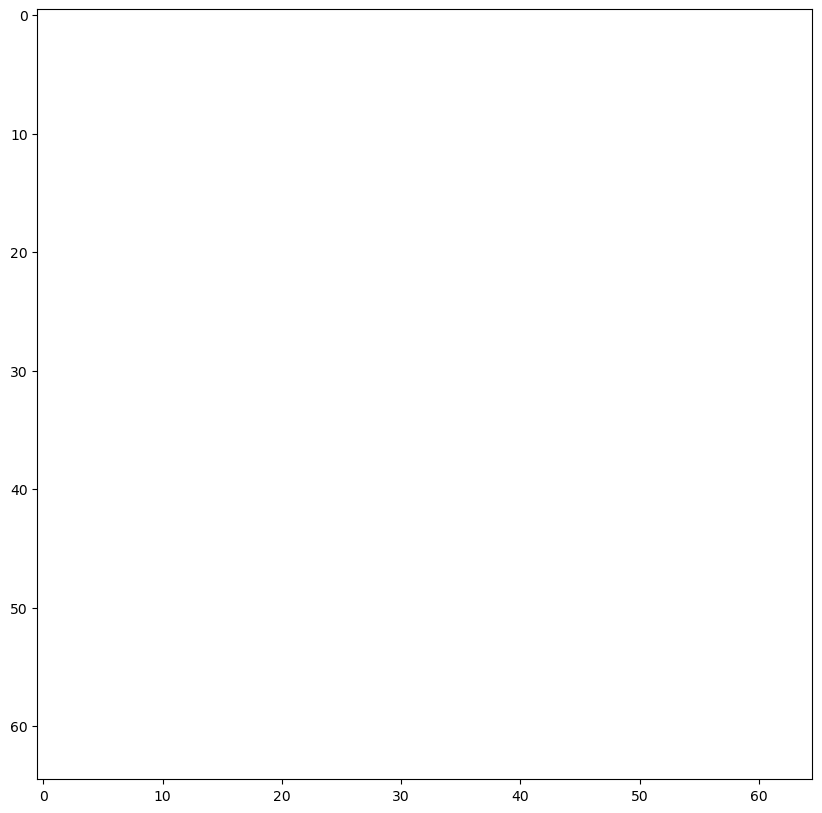

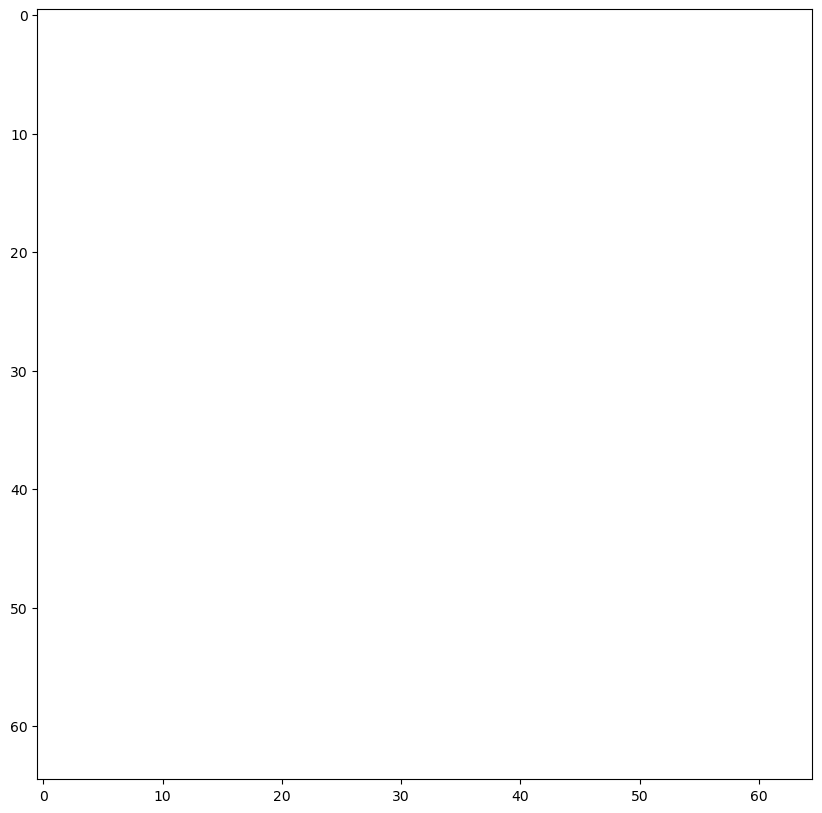

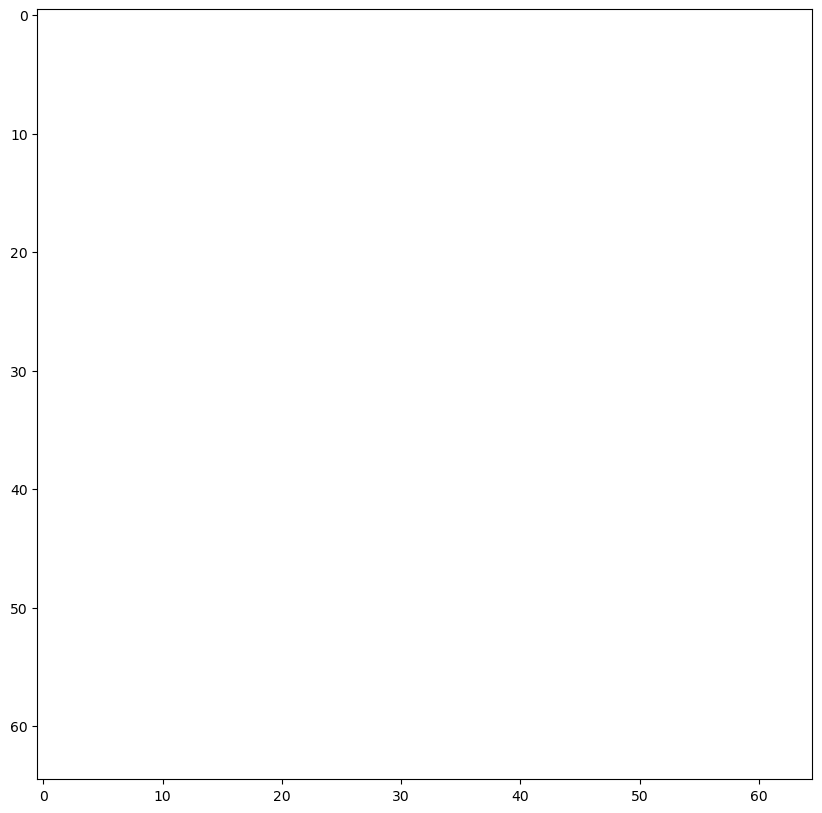

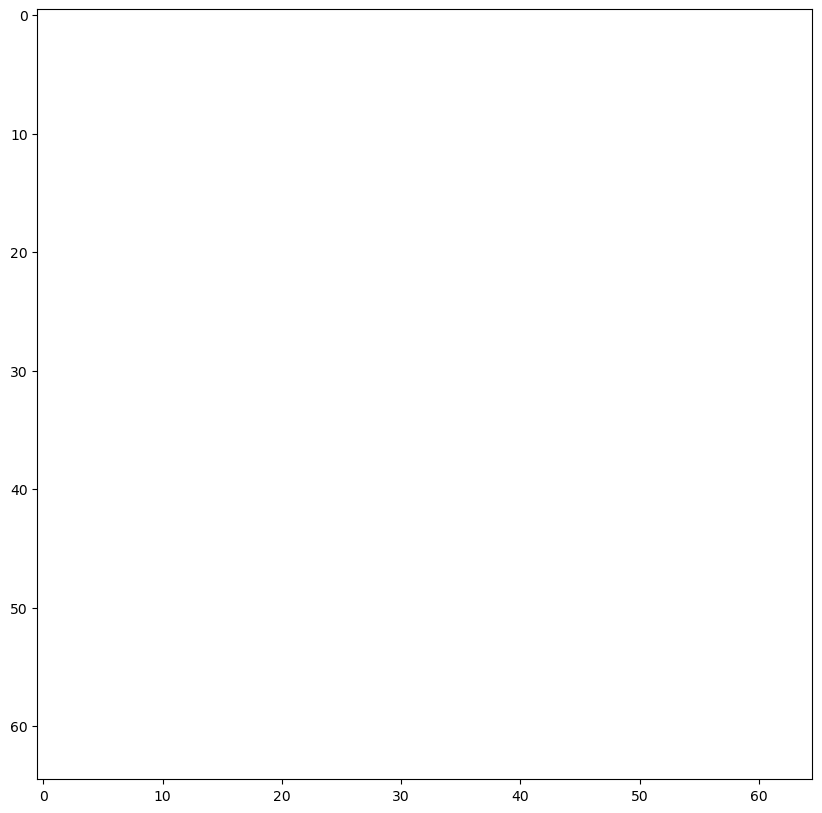

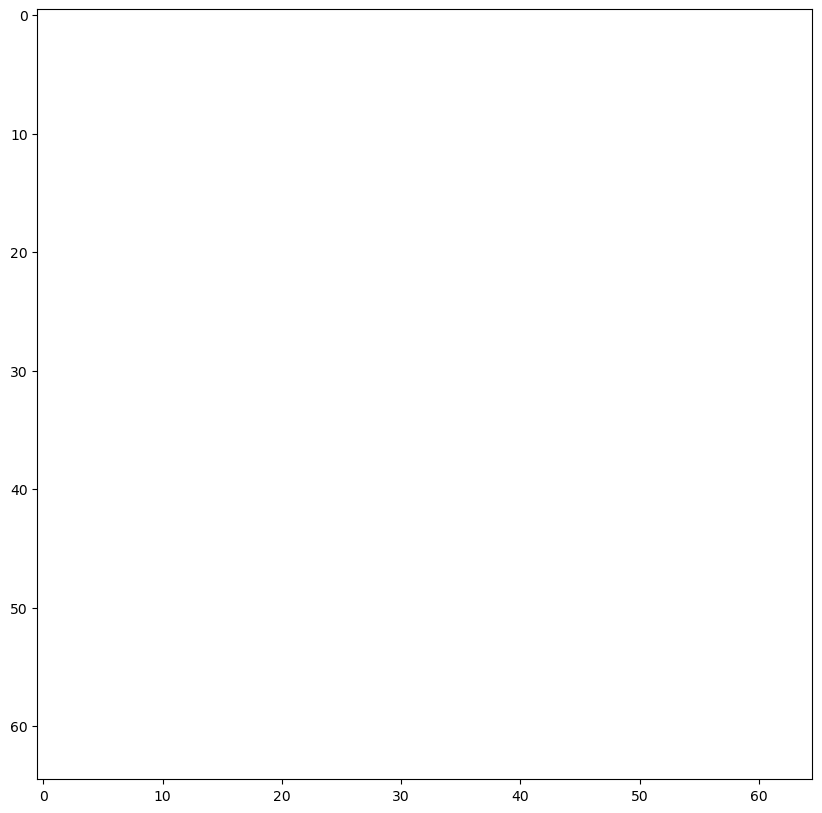

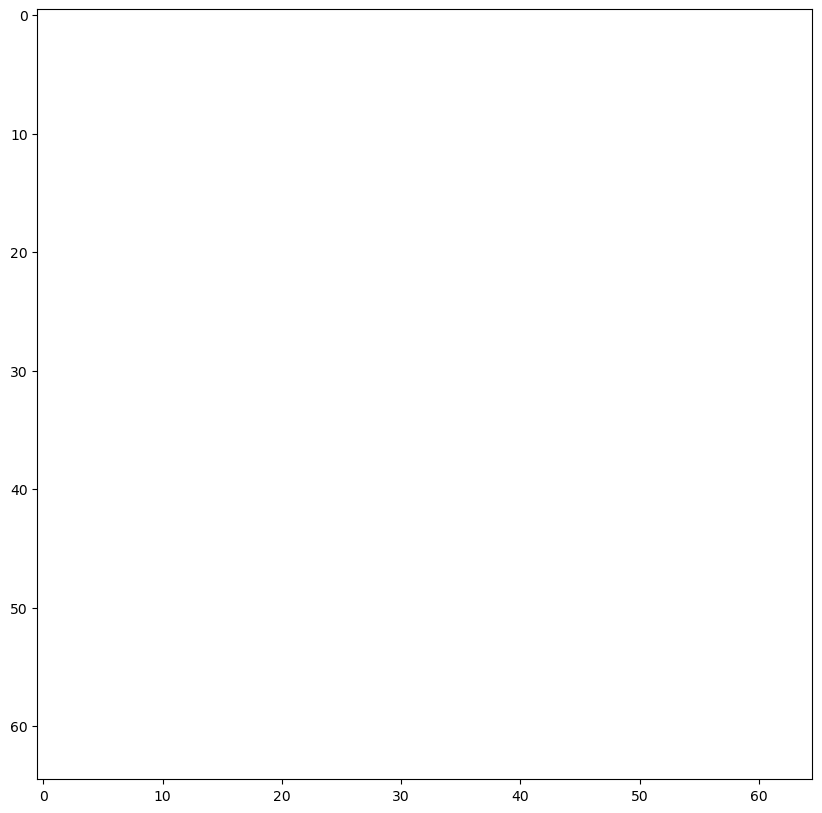

In [9]:
import matplotlib.pyplot as plt

for data_shot in train_dataset:
    for var in data_shot.keys():
        for t in range(data_shot[var]['time'].shape[0]):
            fig, ax = plt.subplots(figsize=(10, 10))
            ax.imshow(data_shot[var]['values'][t].T, aspect='auto')
        # plt.tight_layout()


## Tranform "WindowSegmenterTransform" --> creating windows 

In [ ]:
from scripts.main_pipeline.utils.utils import ComposeTransforms
from scripts.main_pipeline.transforms.shot_level_transforms.window_segmenter_transform import (
    WindowSegmenterTransform
)

PARAMETERS_WINDOWS_SEGMENTER = {
    'x_keys': [
        'magnetics-flux_loop_flux',
    ],
    'y_keys': [
        'magnetics-flux_loop_flux',
    ],
    'x_window_sec': 0.1,
    'y_window_sec': 0.05,
    'dt_sec': 0.0,
    'stride_sec': None,
    'stride_unitary': True,
    'min_samples_per_window': 1,
    'verbose': True,
}

shot_level_trans = ComposeTransforms([  # shape-consistent transform
        WindowSegmenterTransform(**PARAMETERS_WINDOWS_SEGMENTER),  # shape-modifying transform
        PCA_x(parm={'x' = {signla1}, 
                    'y' = {signla1}),
        PCA_y(parm={signla1}),
        # CNNTransform()  # shape-modifying transform
        ])

In [38]:
train_dataset = MastDataset(
                            local=LOCAL_FLAG,
                            shots_list=train_sh,
                            source_signal_list=source_signal_list,
                            signal_level_transform_map=None,
                            shot_level_transform=shot_level_trans
                        )

In [39]:
MAST_windows = train_dataset[0]

Δt for magnetics-flux_loop_flux: 0.000200 s
Δt for magnetics-flux_loop_flux: 0.000200 s
→ Min Δt across all signals: 0.000200 s
→ Max Δt across all signals: 0.000200 s
📦 Final stride used: 0.000200 s
📦 Required total window span: 0.150000 seconds
📦 Using stride: 0.000200 seconds

[DEBUG] Signal time ranges and sampling intervals:
  - magnetics-flux_loop_flux       spans -0.05580 → 0.48480, Δt ≈ 0.000200, N = 2704

[INFO] Expected x-window duration: 0.100000 s
[INFO] Expected y-window duration: 0.050000 s
[INFO] Total coverage per window:  0.150000 s

[Window 0] x_window: -0.05580–0.04420, y_window: 0.04420–0.09420, x_len: {'magnetics-flux_loop_flux': 501}, y_len: {'magnetics-flux_loop_flux': 250}
[Window 1] x_window: -0.05560–0.04440, y_window: 0.04440–0.09440, x_len: {'magnetics-flux_loop_flux': 501}, y_len: {'magnetics-flux_loop_flux': 250}
[Window 2] x_window: -0.05540–0.04460, y_window: 0.04460–0.09460, x_len: {'magnetics-flux_loop_flux': 501}, y_len: {'magnetics-flux_loop_flux': 2

In [40]:
len(MAST_windows)

1954

In [41]:
MAST_windows[0].keys()

dict_keys(['x', 'y', 'window_index'])

In [47]:
MAST_windows[0]['x'].keys()


dict_keys(['magnetics-flux_loop_flux'])

## All-signal transform --> Create X and Y instances

In [56]:
import numpy as np 

# ======================================================================================================================
class CreateXandYInstances:

    def __init__(
        self,
        x_keys,
        y_keys,
        x_transforms = None,
        y_transforms = None
    ):

        self.x_keys = x_keys
        self.y_keys = y_keys
        self.x_transforms = x_transforms
        self.y_transforms = y_transforms

    # ------------------------------------------------------------------------------------------------------------------
    def __call__(self, shot):

        x = {}
        y = {}

        # Apply transforms to x
        for x_signal in self.x_keys :
            # print(x_signal)
            if self.x_transforms:
                x[x_signal] = self.x_transforms(shot[x_signal])
            else:
                x[x_signal] = shot[x_signal]
        
        # Apply transforms to y
        for y_signal in self.y_keys :
            # print(y_signal)
            if self.y_transforms:
                y[y_signal] = self.y_transforms(shot[y_signal])
            else:
                y[y_signal] = shot[y_signal]

        return {'x': x,
                'y': y}

    # ------------------------------------------------------------------------------------------------------------------


    

In [89]:
from scripts.main_pipeline.utils.utils import ComposeTransforms
from scripts.main_pipeline.transforms.signal_level_transforms.sampling_reference_time_transform import (
    SamplingToReferenceTimeTransform
)

REF_FREQ = 0.001

PARAMETERS_X_Y_CREATOR = {
    'x_keys': [
        'magnetics-flux_loop_flux',
        'equilibrium-elongation',
        'equilibrium-elongation_axis',
        'equilibrium-triangularity_upper',
    ],
    'y_keys': [
        'equilibrium-elongation',
        'equilibrium-elongation_axis'
    ],
    'x_transforms': ComposeTransforms([ SamplingToReferenceTimeTransform(REF_FREQ)]), # here you can have your model-specific transform
    'y_transforms': ComposeTransforms([ SamplingToReferenceTimeTransform(REF_FREQ)]), # here you can have your model-specific transform
    
}

shot_level_trans = ComposeTransforms([ CreateXandYInstances(**PARAMETERS_X_Y_CREATOR) ])

train_dataset = MastDataset(
                            local=LOCAL_FLAG,
                            shots_list=train_sh,
                            source_signal_list=source_signal_list,
                            signal_level_transform_map=None,
                            shot_level_transform=shot_level_trans
                        )

new_data_example = train_dataset[0]
new_data_example.keys()

print("--- Shape for X data ---")

for signal in new_data_example['x'].keys():
    print(signal)
    print(new_data_example['x'][signal]['values'].shape)


print("\n--- Shape for Y data ---")

for signal in new_data_example['y'].keys():
    print(signal)
    print(new_data_example['y'][signal]['values'].shape)


--- Shape for X data ---
magnetics-flux_loop_flux
(15, 542)
equilibrium-elongation
(1, 541)
equilibrium-elongation_axis
(1, 541)
equilibrium-triangularity_upper
(1, 541)

--- Shape for Y data ---
equilibrium-elongation
(1, 541)
equilibrium-elongation_axis
(1, 541)


In [92]:
new_data_example['x'].keys()

dict_keys(['magnetics-flux_loop_flux', 'equilibrium-elongation', 'equilibrium-elongation_axis', 'equilibrium-triangularity_upper'])

In [ ]:
REF_FREQ = 0.001

PARAMETERS_X_Y_CREATOR = {
    'x_keys': [
        'magnetics-flux_loop_flux',
        'equilibrium-elongation',
        'equilibrium-elongation_axis',
        'equilibrium-triangularity_upper',
    ],
    'y_keys': [
        'equilibrium-elongation',
        'equilibrium-elongation_axis'
    ],
    'x_transforms': ComposeTransforms([ SamplingToReferenceTimeTransform(REF_FREQ)]), # here you can have your model-specific transform
    'y_transforms': ComposeTransforms([ ]), # here you can have your model-specific transform
    
}

shot_level_trans = ComposeTransforms([ CreateXandYInstances(**PARAMETERS_X_Y_CREATOR) ])

train_dataset = MastDataset(
                            local=LOCAL_FLAG,
                            shots_list=train_sh,
                            source_signal_list=source_signal_list,
                            signal_level_transform_map=None,
                            shot_level_transform=shot_level_trans
                        )

new_data_example = train_dataset[0]
new_data_example.keys()

print("--- Shape for X data ---")

for signal in new_data_example['x'].keys():
    print(signal)
    print(new_data_example['x'][signal]['values'].shape)


print("\n--- Shape for Y data ---")

for signal in new_data_example['y'].keys():
    print(signal)
    print(new_data_example['y'][signal]['values'].shape)

--- Shape for X data ---
magnetics-flux_loop_flux
(15, 542)
equilibrium-elongation
(1, 541)
equilibrium-elongation_axis
(1, 541)
equilibrium-triangularity_upper
(1, 541)

--- Shape for Y data ---
equilibrium-elongation
(1, 109)
equilibrium-elongation_axis
(1, 109)
